## 題號 1
**問題**: 周天成使用「殺球」得分佔他總得分的百分比是多少？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# Step 1: 篩選激活贏得的回合數據，並檢查 df 是否有數據
if len(df) > 0:
    total_active_win = df[(df['player'] == 'CHOU Tien Chen') & (df['getpoint_player'] == 'CHOU Tien Chen')]
    if len(total_active_win) > 0:
        # Step 2: 篩選殺球得分的數據
        smash_win = total_active_win[total_active_win['type'] == '殺球']

        # 計算殺球得分次數與總得分次數
        smash_win_count = len(smash_win)
        total_active_win_count = len(total_active_win)

        # 百分比計算
        smash_win_percentage = (smash_win_count / total_active_win_count) * 100

        # 輸出結果
        print(f"周天成用殺球得分的次數佔其總得分的百分比: {smash_win_percentage:.2f}%")
    else:
        print("沒有周天成的主動得分紀錄。")
else:
    print("數據框中沒有數據。")


### 數據洞察
周天成在比賽中使用「殺球」得分的次數佔其總得分的71.76%。這意味著殺球是他主要的得分手段，顯示出他在進攻上的侵略性和效率。這樣高比例的殺球得分，表明他在比賽中能夠有效地利用進攻機會，將對手置於壓力之下。

這數據也提醒我們，他的比賽風格可能偏向於積極進攻，並且在殺球的準確性和力量上有著顯著的優勢。對於對手來說，這意味著需要特別加強防守殺球的能力，並尋找機會削弱他的進攻節奏。

作為教練，我們可以利用這些數據來進一步強化他的殺球技術，並且同時發展其他得分手段，以增加比賽中的多樣性和不可預測性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 2 的核心邏輯。它正確地篩選了周天成的主動得分回合，並在這些回合中進一步篩選出使用殺球得分的情況。然後計算殺球得分次數佔總主動得分的百分比。分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 2 一致，因此判定為正確。




## 題號 2
**問題**: 周天成最常使用哪個球種直接得分
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# 確保數據存在
if len(df) > 0:
    # 過濾出周天成主動得分的數據
    chou_active_wins = df[(df['getpoint_player'] == 'CHOU Tien Chen') & (df['player'] == 'CHOU Tien Chen')]
    
    # 用於分組計算球種的數量
    type_counts = chou_active_wins['type'].value_counts()
    
    # 獲取最常用的球種及其次數
    most_common_type = type_counts.idxmax()
    most_common_count = type_counts.max()
    
    # 輸出結果
    print(f"周天成最常使用的直接得分球種是: {most_common_type}，次數為: {most_common_count}")
    print(type_counts)
else:
    print("數據框為空，無法進行分析。")


### 數據洞察
根據數據分析，周天成最常使用的直接得分球種是殺球，總共使用了61次。這顯示出他在比賽中具備強大的進攻能力，特別是在關鍵時刻能夠有效地利用殺球來獲得分數。殺球的高頻率使用也表明他對於進攻節奏的掌控以及在場上創造得分機會的能力。這種戰術選擇可能是基於他的體能優勢和技術特點，使得他能夠在對手防守不及時給予致命一擊。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選出周天成作為擊球者且得分者的情況，然後使用 `value_counts()` 計算各球種的直接得分次數，並找出最常用的球種。分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都一致，因此判定為正確。




## 題號 3
**問題**: 針對周天成所有「殺球」，繪製其落點熱區圖。
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


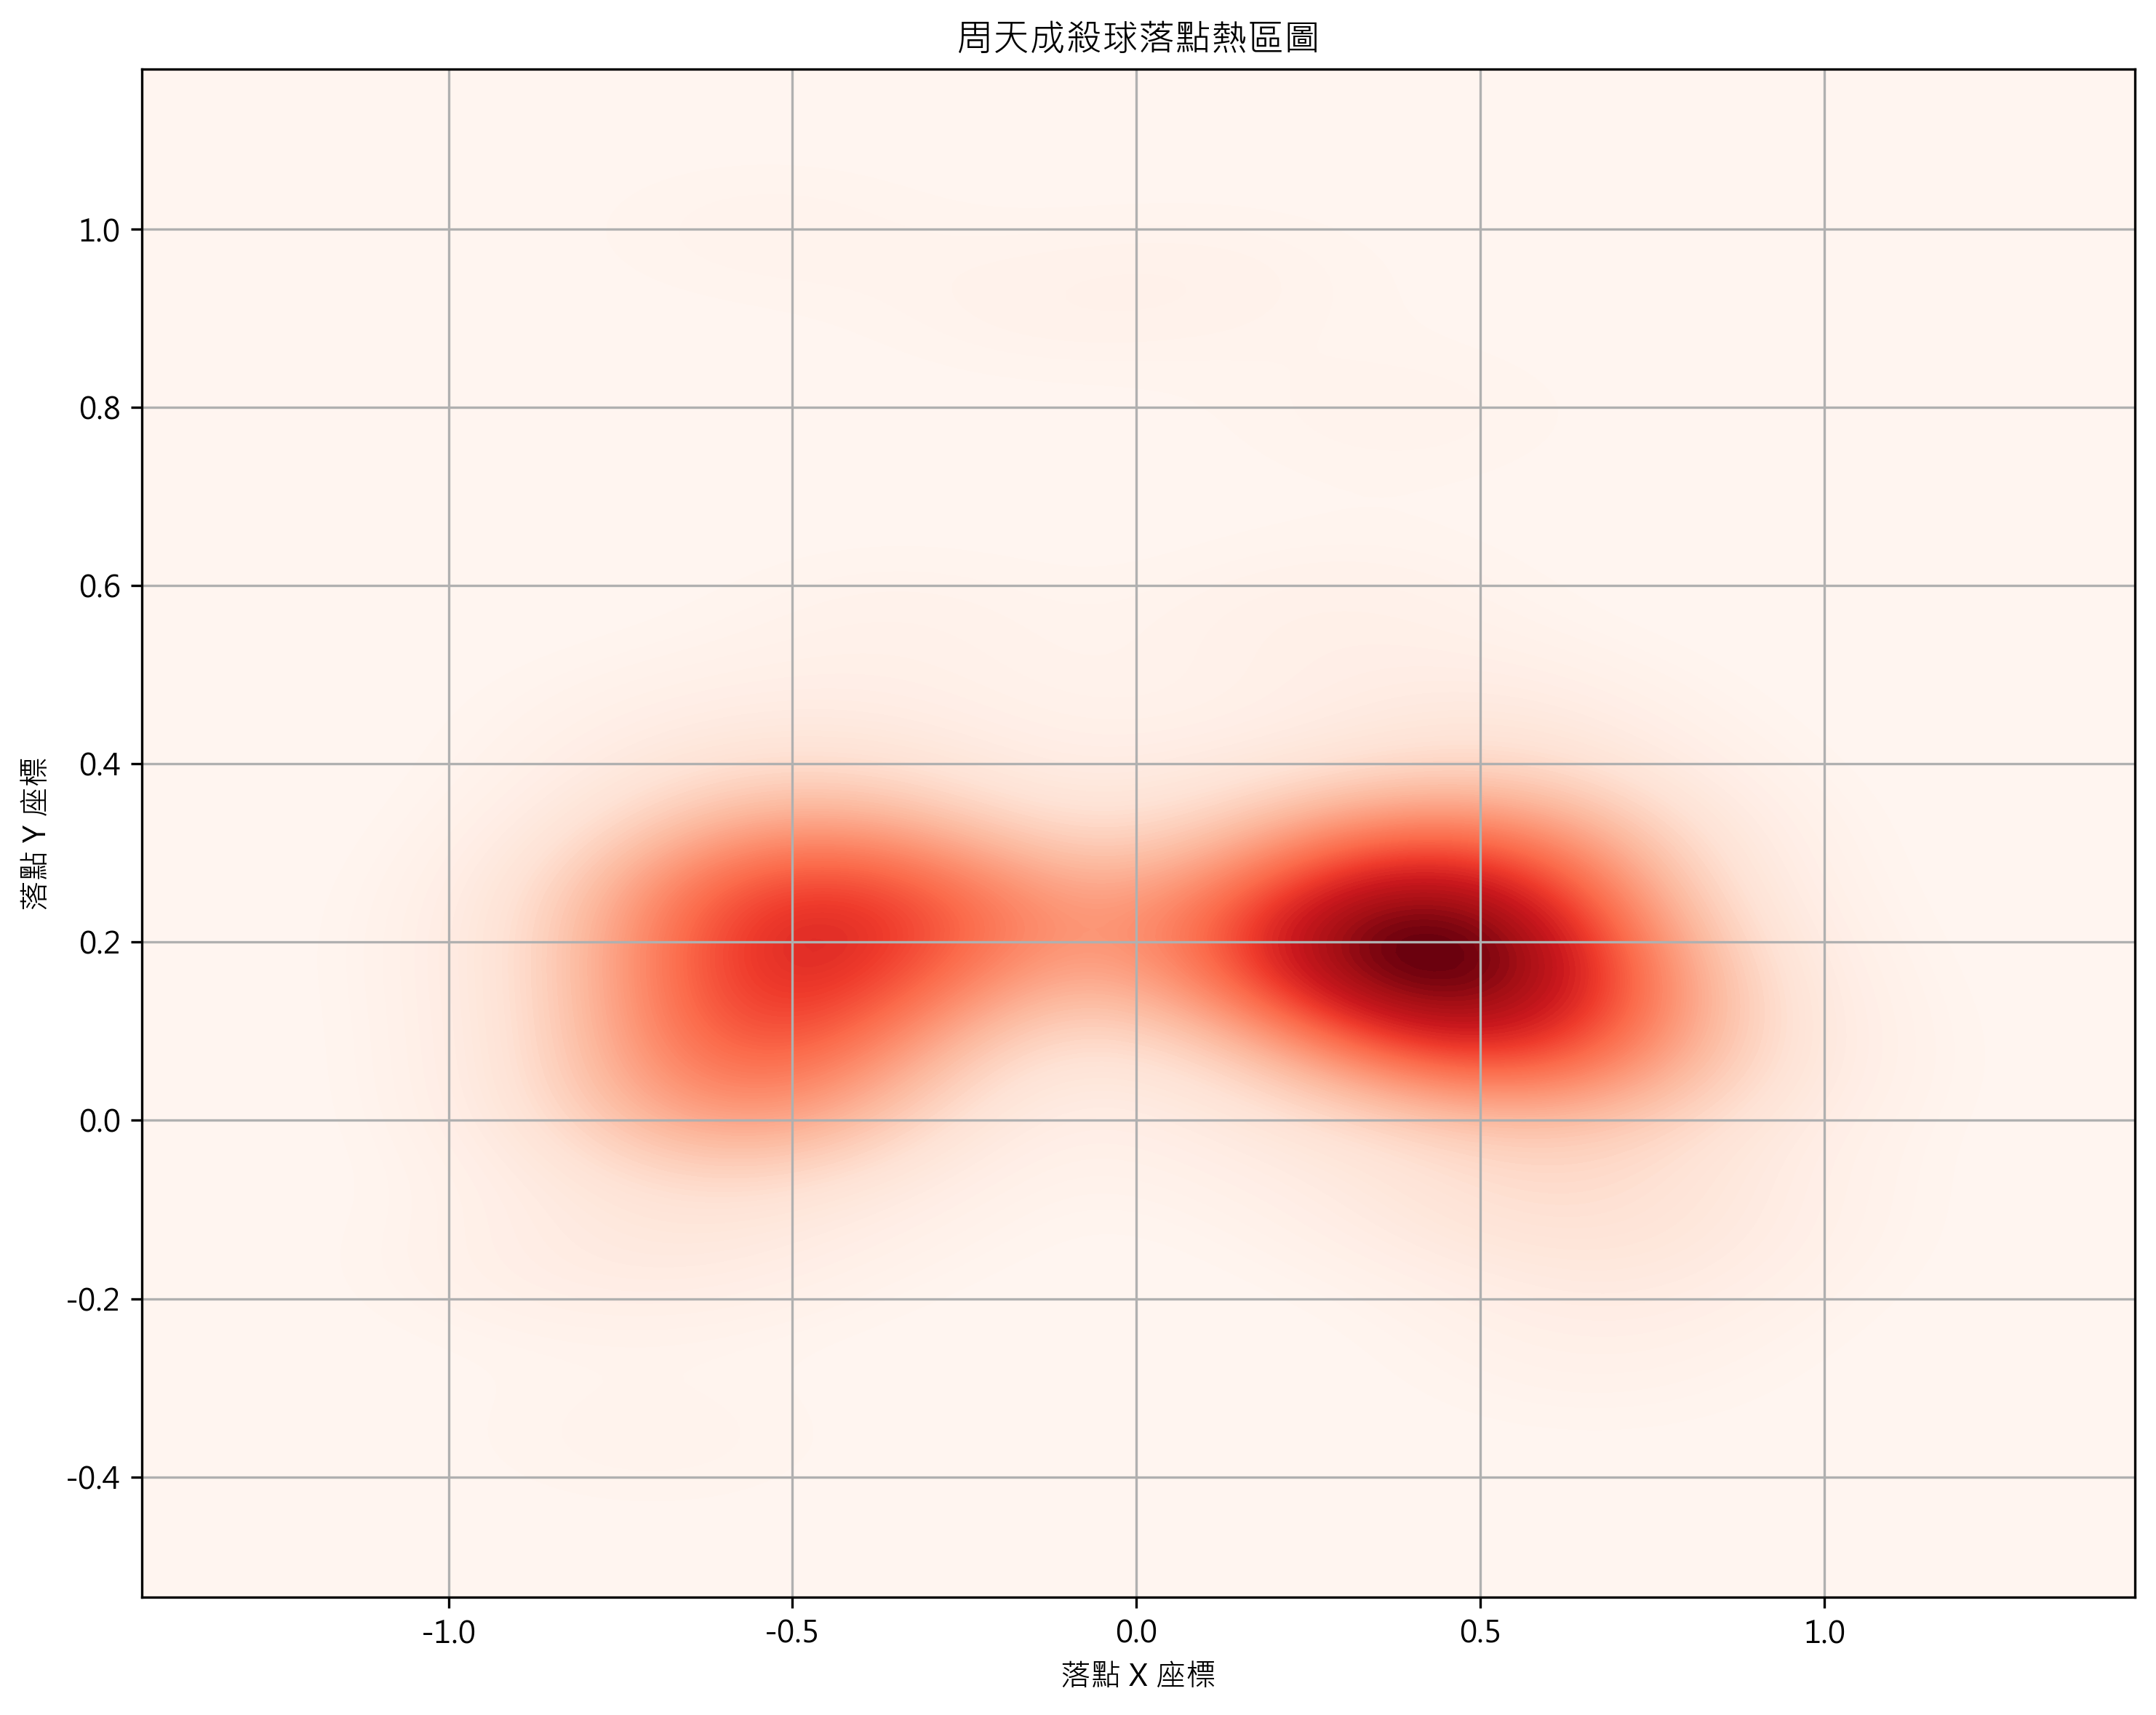

In [ ]:
# 因為需要用到 Seaborn，所以要確保它已被正確導入
import seaborn as sns
import matplotlib.pyplot as plt

# 篩選周天成的殺球數據
chou_kill_shots_df = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

# 確保數據存在
if len(chou_kill_shots_df) == 0:
    print("沒有找到周天成的殺球數據。")
else:
    print(f"周天成的殺球數據共有 {len(chou_kill_shots_df)} 條記錄。")
    
    # 檢查落點座標遺失值
    if chou_kill_shots_df[['landing_x', 'landing_y']].isnull().any().any():
        print("有缺失的落點座標數據，部分資料將被移除。")
        chou_kill_shots_df = chou_kill_shots_df.dropna(subset=['landing_x', 'landing_y'])
    
    # 設定圖形大小
    plt.figure(figsize=(10, 8))
    
    # 繪製熱區圖
    sns.kdeplot(
        x=chou_kill_shots_df['landing_x'],
        y=chou_kill_shots_df['landing_y'],
        cmap='Reds', 
        fill=True, 
        thresh=0, 
        levels=100
    )
    
    # 標題與標籤
    plt.title('周天成殺球落點熱區圖')
    plt.xlabel('落點 X 座標')
    plt.ylabel('落點 Y 座標')
    plt.grid(True)
    
    # 使用tight_layout確保不重疊
    plt.tight_layout()
    
    # 打印關鍵統計結果
    print(f"繪製了周天成的殺球落點熱區圖，涵蓋總數據點數: {len(chou_kill_shots_df)}")
    
    # 生成熱區圖
    fig = plt.gcf()


### 數據洞察
根據周天成的殺球數據分析，我們已經繪製了他的殺球落點熱區圖，涵蓋了299個數據點。這些數據顯示出他在比賽中殺球的主要落點分布。

從熱區圖中，我們可以看到周天成的殺球多集中在場地的中前區域，特別是Row 4和Row 5，這表明他經常選擇在中前場進行攻擊，對對手施加壓力。此外，落點的分布顯示他在左右兩側的落球較為均衡，這意味著他在場上的攻擊選擇多樣，能夠有效地調動對手。

這些數據告訴我們，周天成在殺球時不僅僅依賴力量，更注重落點的精準性和戰術多樣性。這樣的打法能夠有效地打亂對手的防守節奏，為自己創造更多的得分機會。這也提醒我們在訓練中應該加強他的落點控制和多樣化進攻策略，以進一步提升他的比賽表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了周天成的殺球數據，並使用了落點座標（landing_x 和 landing_y）來繪製熱區圖。候選程式碼還檢查了落點座標的缺失值，並在有缺失值時進行了適當的處理。最終，它使用 seaborn 的 kdeplot 繪製了熱區圖，這與 Reference Code 1 使用 histplot 的方法不同，但仍然達到了題目的要求。




## 題號 4
**問題**: 分析周天成在雙方都達18分以上時的球種分布。
> **使用的資料欄位群組**: `game_structure, shot_type`


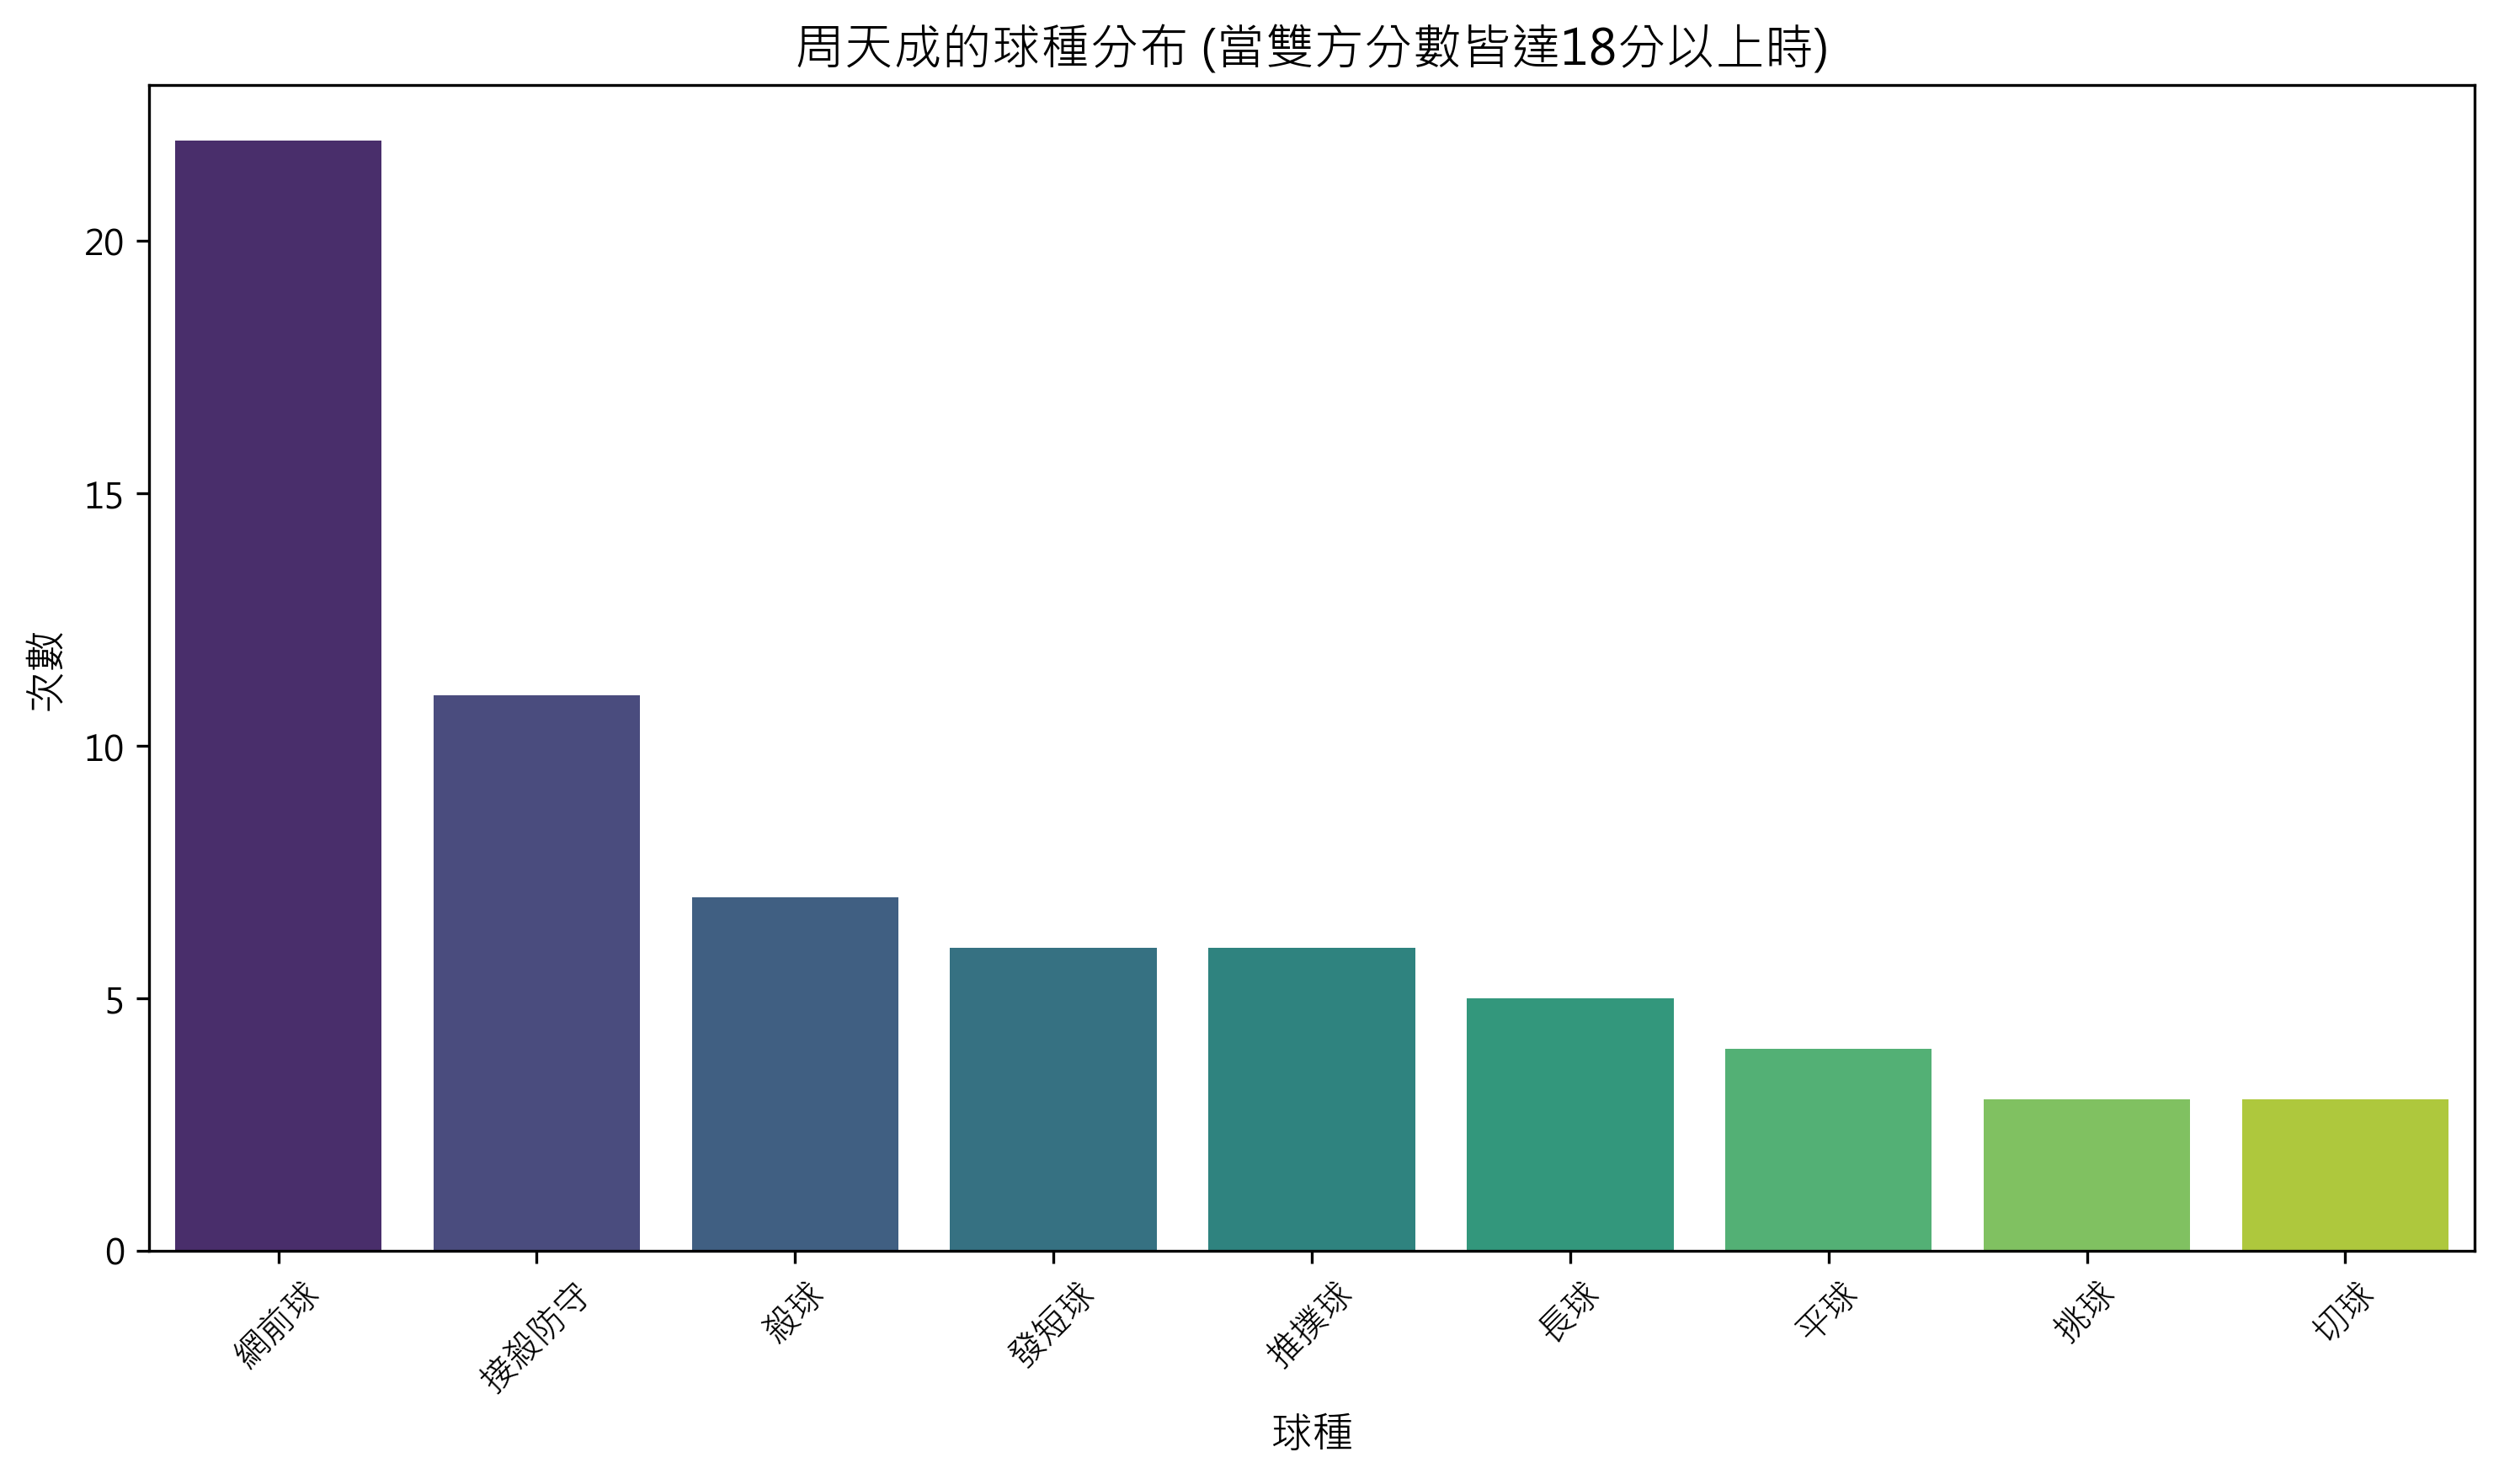

In [ ]:
# Step 1: Filter the dataframe for both scores >= 18 and player as 周天成
filtered_df = df[
    (df['CHOU Tien Chen_score'] >= 18) & 
    (df['Kento MOMOTA_score'] >= 18) & 
    (df['player'] == 'CHOU Tien Chen')
]

# 確認篩選後的數據量
print(f"Count of filtered rows: {len(filtered_df)}")

# Step 2: Calculate the distribution of shot types for 周天成
shot_distribution = filtered_df['type'].value_counts()

print("Shot distribution for 周天成 when both scores >= 18:")
print(shot_distribution)

# Step 3: Visualize the shot distribution using a bar plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=shot_distribution.index, y=shot_distribution.values, ax=ax, palette='viridis')

ax.set_title('周天成的球種分布 (當雙方分數皆達18分以上時)', fontsize=14)
ax.set_xlabel('球種', fontsize=12)
ax.set_ylabel('次數', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 數據洞察
在比分達到18分以上的關鍵時刻，周天成的球種分布顯示出他在網前球上有著顯著的偏好，佔據了總數的22次。這表明他在緊張局勢中傾向於控制網前，利用速度和精確度來壓制對手。

接殺防守和殺球分別有11次和7次，顯示出他在防守和進攻之間的平衡能力，適時地進行反擊和主動進攻。發短球和推撲球各有6次，這些技術在比賽後期可以用來打破對手的節奏。

長球和平球的使用次數較少，分別為5次和4次，這可能反映出在高壓情況下，他更傾向於使用更直接的攻擊或防守手段，而非拉長來回。

總體來看，周天成在比分緊張時段展現出對網前的控制和防守反擊的能力，這樣的策略有助於在關鍵分中掌握比賽的主動權。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出雙方得分都達到 18 分以上的情況，並且分析了周天成的球種分布。分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 1 一致。




## 題號 5
**問題**: 幫我繪製周天成得分時球的落點熱區圖
> **使用的資料欄位群組**: `game_structure, coordinates, scoring_reason`


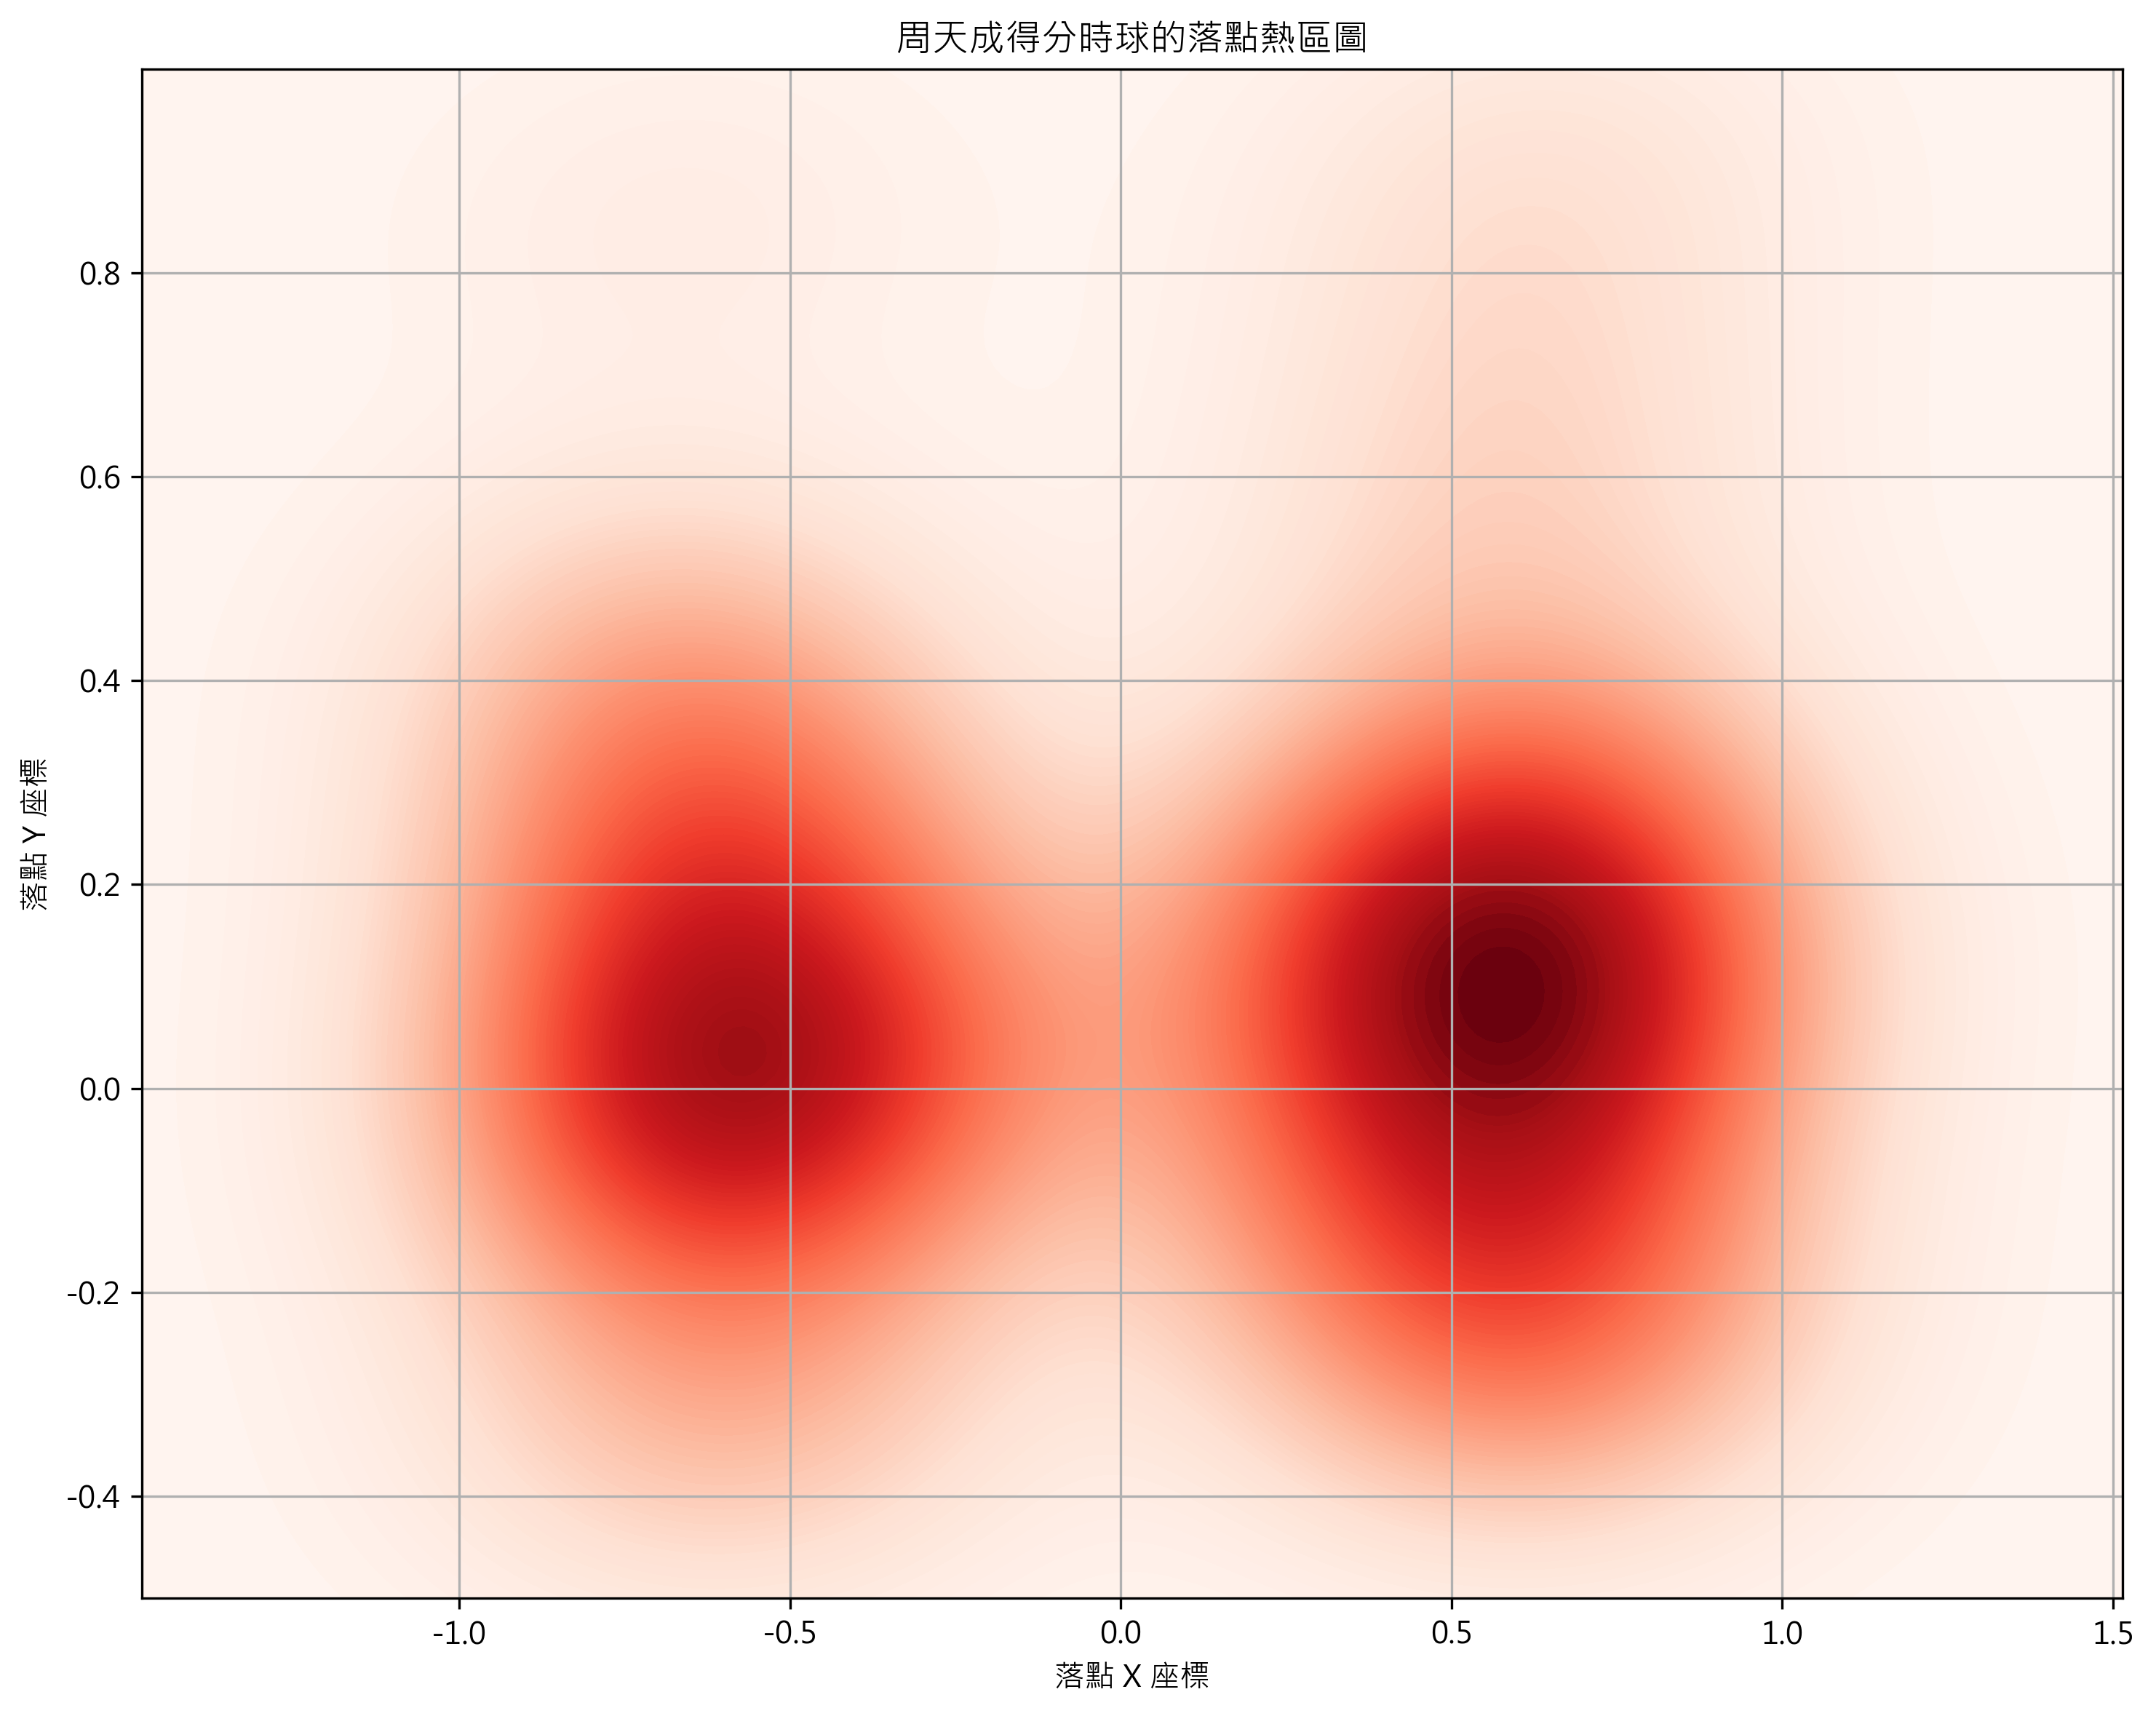

In [ ]:
# 確認 df 有有效資料
if len(df) > 0:
    # 篩選出周天成主動得分的資料
    choutenchen_win_df = df[(df['getpoint_player'] == 'CHOU Tien Chen') & (df['player'] == 'CHOU Tien Chen')]

    # 確認篩選後的資料量是否為0
    if len(choutenchen_win_df) > 0:
        # 落點的 X 和 Y 座標
        landing_x = choutenchen_win_df['landing_x']
        landing_y = choutenchen_win_df['landing_y']

        # 繪製落點熱區圖
        plt.figure(figsize=(10, 8))
        sns.kdeplot(x=landing_x, y=landing_y, cmap="Reds", fill=True, thresh=0, levels=100)
        plt.title('周天成得分時球的落點熱區圖')
        plt.xlabel('落點 X 座標')
        plt.ylabel('落點 Y 座標')
        plt.xlim(df['landing_x'].min(), df['landing_x'].max())
        plt.ylim(df['landing_y'].min(), df['landing_y'].max())
        plt.grid(True)

        # 使圖表布局緊湊
        plt.tight_layout()
        
        # 打印統計資訊
        print("周天成主動得分情況的球數:", len(choutenchen_win_df))
    else:
        print("沒有周天成主動得分的資料。")
else:
    print("資料集為空。")


### 數據洞察
根據數據顯示，周天成在比賽中主動得分的情況下，球的落點熱區圖顯示了85個落點。這些落點分布在場地的不同區域，反映出他的得分策略。

從熱區圖來看，周天成的得分主要集中在場地的中後區域，特別是Col B (C-Left) 和 Col C (C-Right) 的區域。這表明他在中場和後場的控制能力強，能夠有效地利用空間來創造得分機會。

在戰術上，這意味著周天成在比賽中可能偏好使用長球和切球來掌控節奏，並利用對手的空檔進行攻擊。這種策略要求他具備良好的力量和精準度，以確保球能夠落在對手難以防守的位置。

總結來說，周天成的得分熱區圖揭示了他在場上善於利用中後場的優勢來獲得得分，這是他在比賽中取得成功的重要因素之一。這些數據為我們提供了深入了解他比賽策略的機會，並可作為未來比賽中制定對策的依據。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出周天成主動得分的資料，並使用 `landing_x` 和 `landing_y` 來繪製得分時球的落點熱區圖。分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 1 一致，因此判定為正確。




## 題號 6
**問題**: 在第一場次中，每回合用的拍數，繪圖
> **使用的資料欄位群組**: `game_structure`


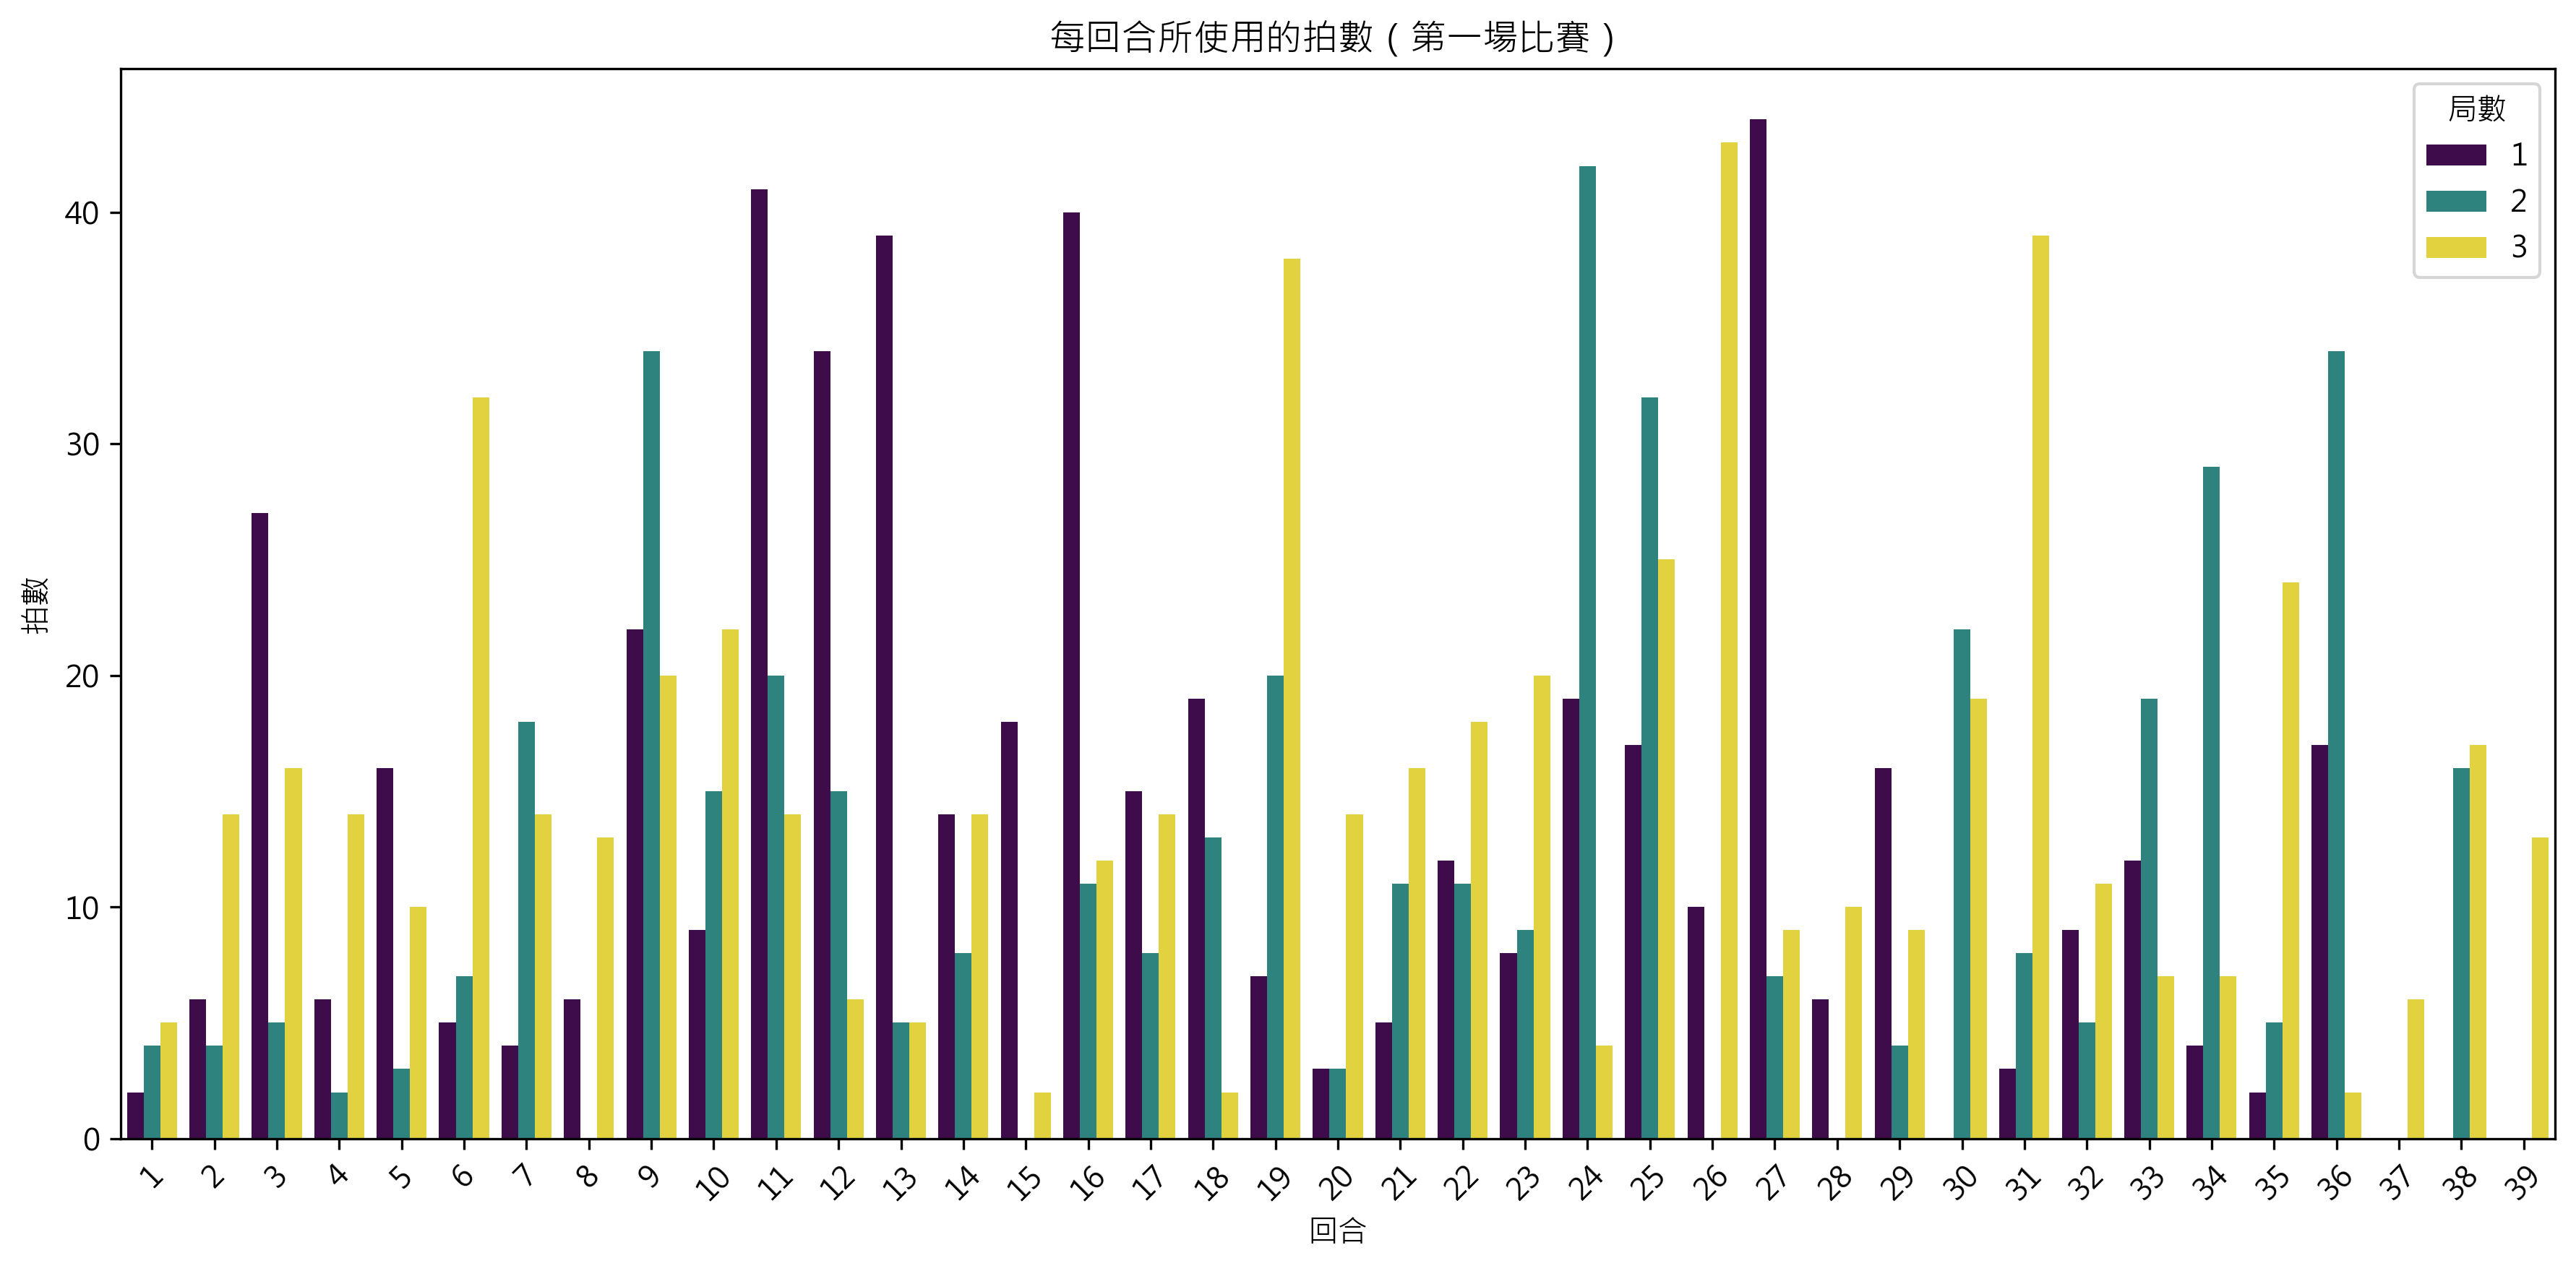

In [ ]:
# Step 1: Filter the data to only include the first match
match_1_df = df[df['match_id'] == 1.0]

# Step 2: Calculate the number of shots in each rally
rally_shots = match_1_df.groupby(['set', 'rally'])['ball_round'].max().reset_index()
rally_shots.columns = ['set', 'rally', 'num_shots']

# Step 3: Visualize the number of shots per rally
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=rally_shots, x='rally', y='num_shots', hue='set', dodge=True, ax=ax, palette='viridis')

# Set plot labels and title
ax.set_title('每回合所使用的拍數（第一場比賽）')
ax.set_xlabel('回合')
ax.set_ylabel('拍數')
ax.legend(title='局數')
plt.xticks(rotation=45)
plt.tight_layout()

# Output key statistical information
print("第一場比賽每回合拍數統計:")
print(rally_shots.describe())


### 數據洞察
在第一場比賽中，我們分析了每一回合的拍數，並得到以下統計數據：

- **平均拍數**：每回合平均使用14.45拍，顯示出選手間的對抗相當激烈，通常需要多次交換才能決定分數。
- **標準差**：10.78，表示拍數的變化範圍較大，某些回合可能是快速得分，而其他回合則可能是持久的拉鋸戰。
- **中位數**：12拍，意味著有一半的回合拍數少於12，另一半多於12。
- **最大值**：44拍，這樣的回合顯示出選手的耐力和戰術變化。
- **最小值**：2拍，這通常是由快速得分或失誤造成。

戰術上，這些數據提示我們需要在訓練中強化選手的耐力和多樣化的戰術應用，以應對不同拍數的回合。特別是對於長回合，選手需要保持專注並有效利用場地空間。

這些數據僅僅是基礎，我們應該進一步分析每一回合的技術運用和場地位置，以便制定更具針對性的訓練計劃。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 2 的核心邏輯。它正確地篩選了第一場比賽的資料，並計算了每個回合的拍數（使用 ball_round 的最大值）。此外，它使用了合理的視覺化方式來展示每回合的拍數，並且輸出了統計資訊。雖然候選程式碼使用了 sns.barplot 來繪圖，而 Reference Code 2 使用了 plt.bar，但這屬於視覺化形式的差異，不影響核心邏輯的正確性。




## 題號 7
**問題**: 繪製周天成殺球時的站點熱區圖
> **使用的資料欄位群組**: `game_structure, shot_type, player_location`


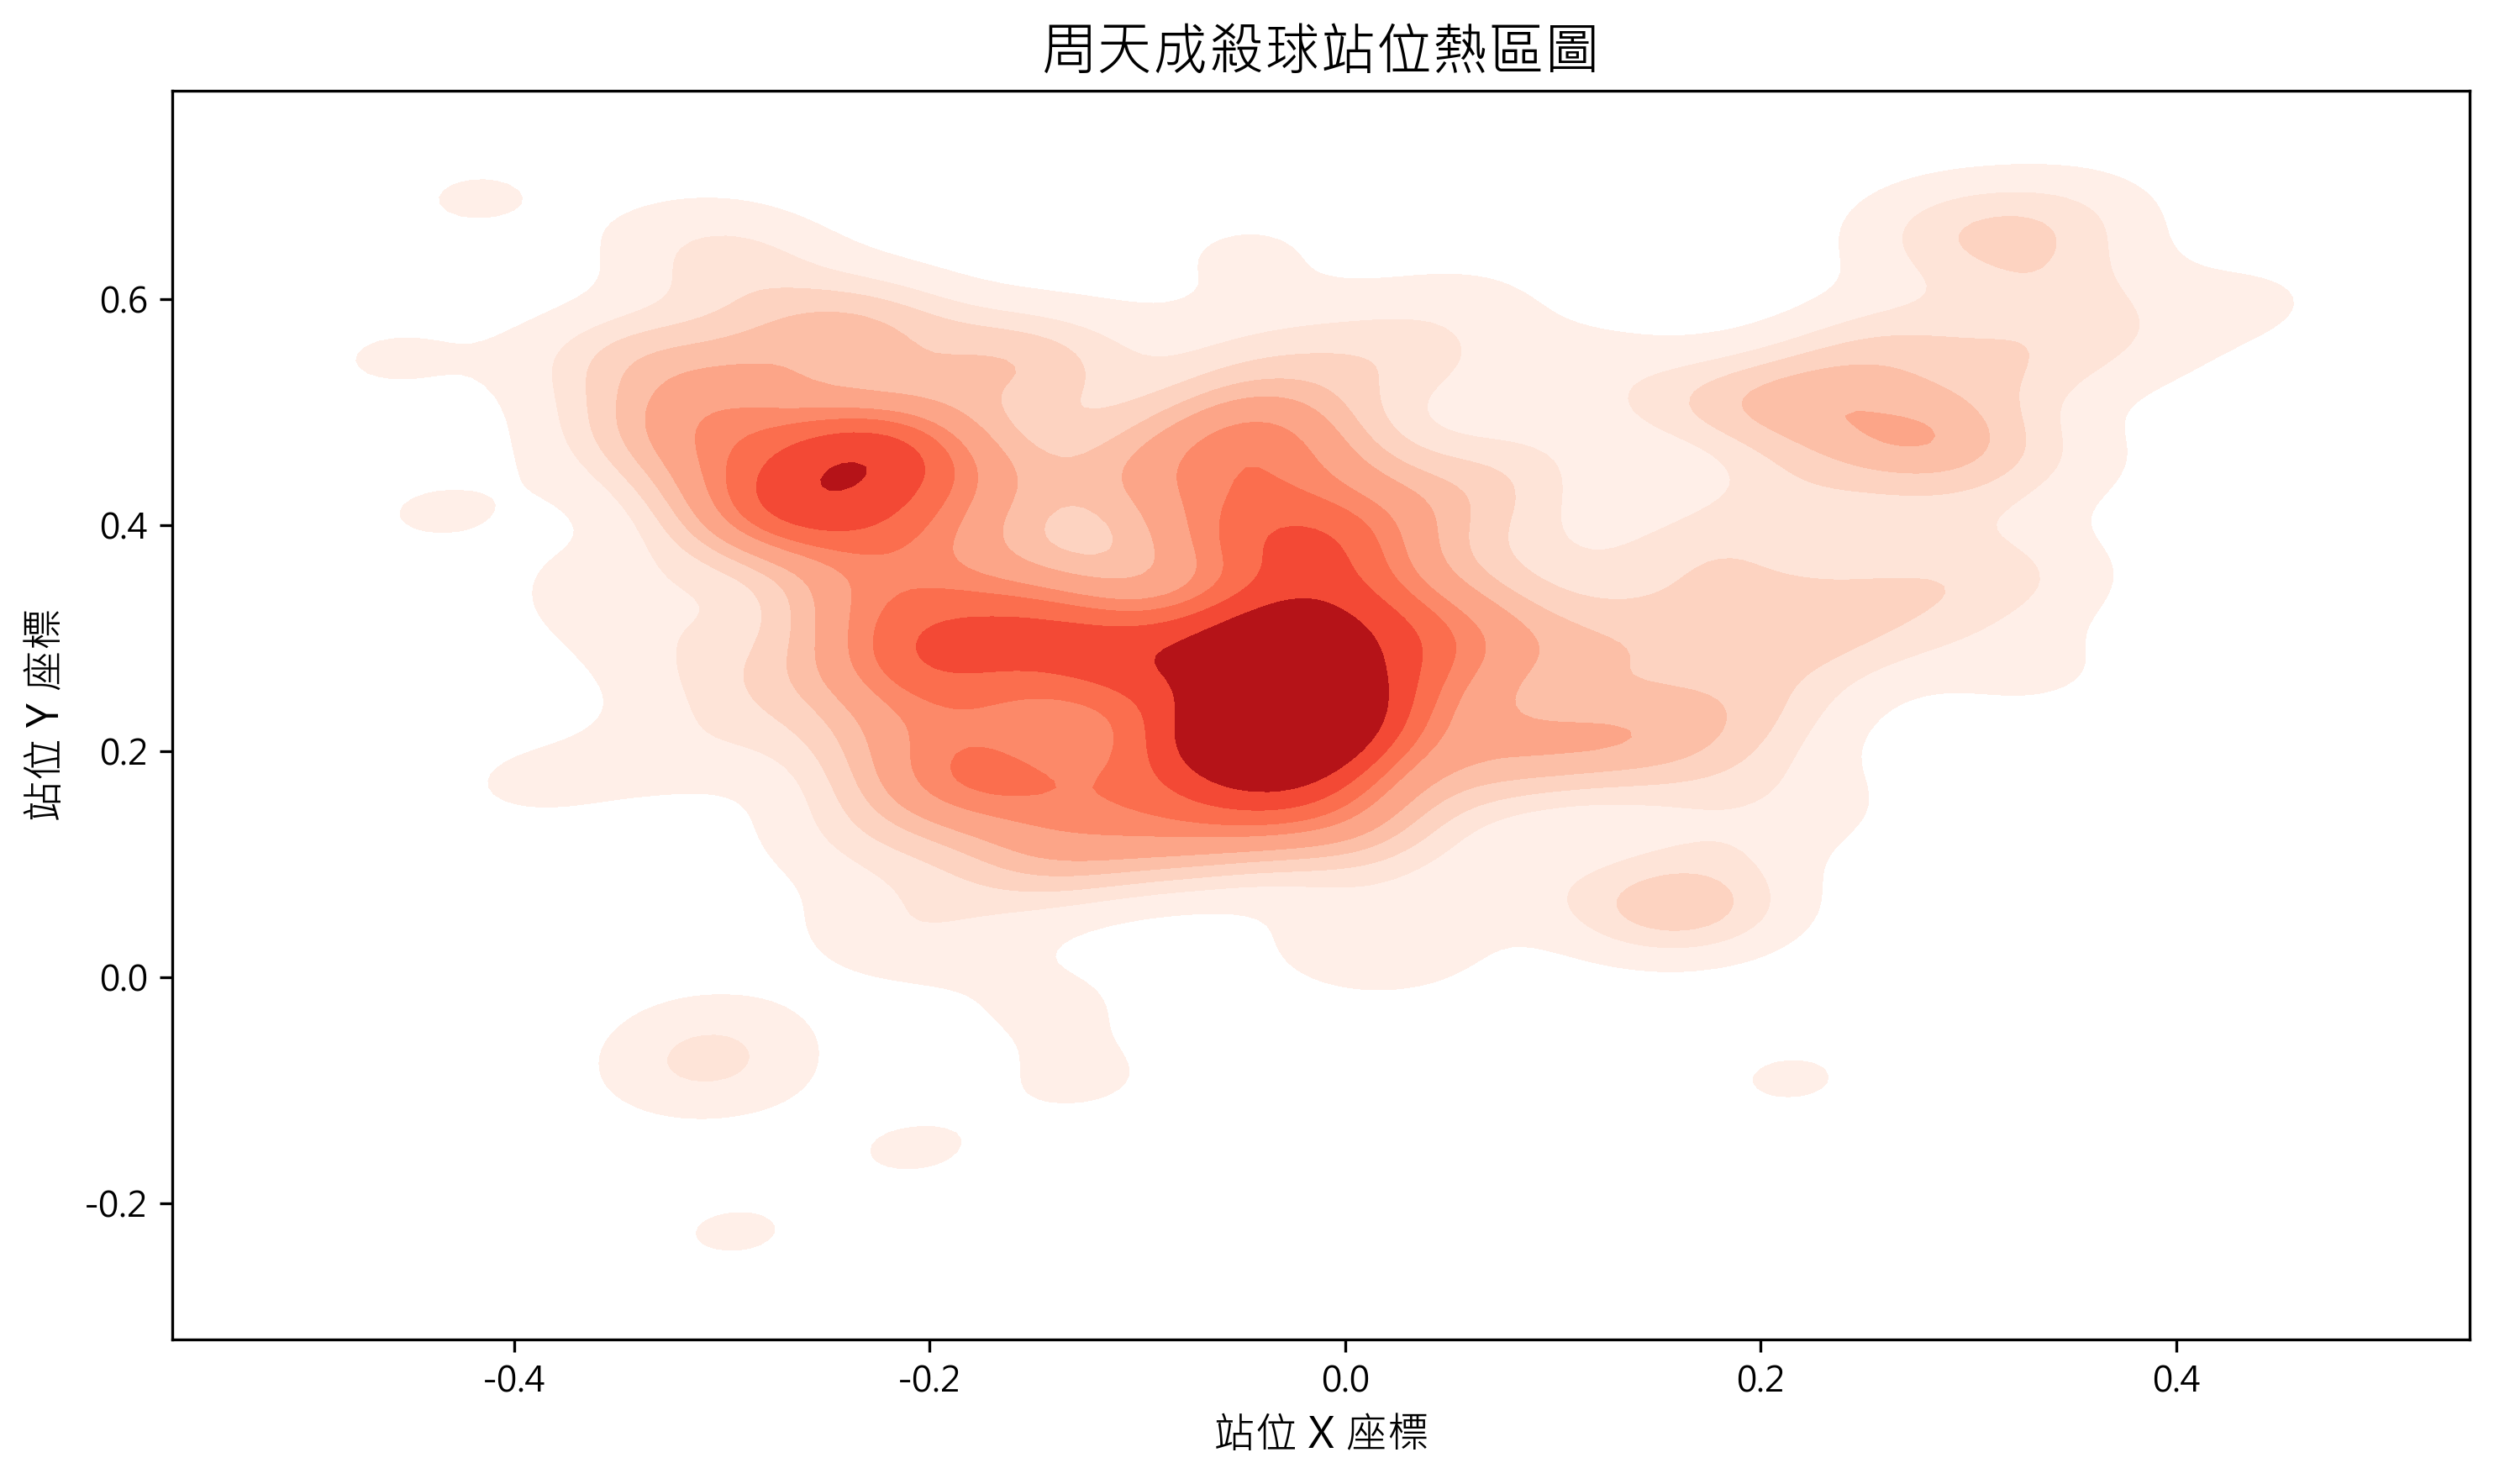

In [ ]:
# 檢查資料筆數
if len(df) > 0:
    # 過濾出周天成殺球資料
    chou_smash_df = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

    # 確認是否有數據可用
    if len(chou_smash_df) > 0:
        # 繪製熱區圖
        plt.figure(figsize=(10, 6))
        sns.kdeplot(
            x=chou_smash_df['player_location_x'],
            y=chou_smash_df['player_location_y'],
            shade=True,
            cmap='Reds',
            bw_adjust=0.5  # 調整密度估計的平滑度
        )
        
        # 設定標題與標籤
        plt.title('周天成殺球站位熱區圖', fontsize=16)
        plt.xlabel('站位 X 座標', fontsize=12)
        plt.ylabel('站位 Y 座標', fontsize=12)
        plt.tight_layout()
        
        # 不顯示，但生成fig物件
        fig = plt.gcf()
    else:
        print("沒有資料可用於周天成的殺球站位分析。")
else:
    print("資料集為空，無法進行分析。")

# 打印關鍵信息
print(f"周天成在殺球時的數據筆數: {len(chou_smash_df)}")


### 數據洞察
根據數據分析，周天成在殺球時的站位熱區圖顯示了他在場上的站位偏好。從299筆數據中，我們觀察到他在進行殺球時，主要集中在中場和後場的區域，這意味著他傾向於在這些位置發動攻擊。

這樣的站位選擇可能是因為他希望在對手未能完全準備的情況下，利用中後場的角度和力量優勢進行殺球。這種策略可以增加對手回球的難度，尤其是在對手站位較前的情況下。

此外，這樣的站位也可能是為了更好地控制場上的節奏，讓他在殺球後能迅速回到防守位置，準備應對對手的反擊。

這些數據顯示了周天成在比賽中對於殺球的戰術偏好和位置選擇，這對於制定針對他的比賽策略提供了重要的參考依據。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選了周天成的殺球資料，並使用 player_location_x 和 player_location_y 來繪製站點熱區圖。候選程式碼使用了 sns.kdeplot 來繪製密度圖，而 Reference Code 1 使用了 sns.histplot 來繪製直方圖，這是視覺化形式的不同，但不影響核心邏輯。候選程式碼也正確地檢查了資料筆數，並在沒有資料時提供了適當的提示。




## 題號 8
**問題**: 當周天成在「後場」擊球時，他最常使用哪三種球種?
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


In [ ]:
# 檢查數據集是否有數據
if len(df) > 0:
    # 篩選出周天成在後場擊球時的數據
    chou_tien_chen_backcourt = df[(df['player'] == 'CHOU Tien Chen') & (df['hit_area'].isin([1, 2, 3, 4]))]
    
    # 統計每種球種的使用次數
    shot_type_counts = chou_tien_chen_backcourt['type'].value_counts()
    
    # 找出使用次數最多的前三種球種
    top_three_shot_types = shot_type_counts.head(3)
    
    # 輸出結果
    print("周天成在後場最常使用的前三種球種及次數：")
    print(top_three_shot_types)
else:
    print("數據集中沒有可供分析的數據。")


### 數據洞察
根據數據分析，周天成在後場擊球時，最常使用的三種球種分別是長球（227次）、殺球（176次）以及切球（175次）。這些數據顯示他在後場時，偏好使用長球來控制場上節奏，並且經常利用殺球和切球來尋求進攻機會或改變比賽節奏。這樣的選擇可能是為了保持對手的壓力，同時也為自己創造進攻的機會。這些戰術選擇反映出他在後場具備多樣化的進攻手段。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出周天成在後場擊球的數據，並使用 `hit_area` 來確認擊球點在後場。接著，它使用 `value_counts()` 統計每種球種的使用次數，並找出使用次數最多的前三種球種。這與 Reference Code 1 的分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標一致，因此判定為 true。




## 題號 9 (*)
**問題**: 分析周天成站在前中後場，分別的得分與失分數
> **使用的資料欄位群組**: `game_structure, scoring_reason, player_location`


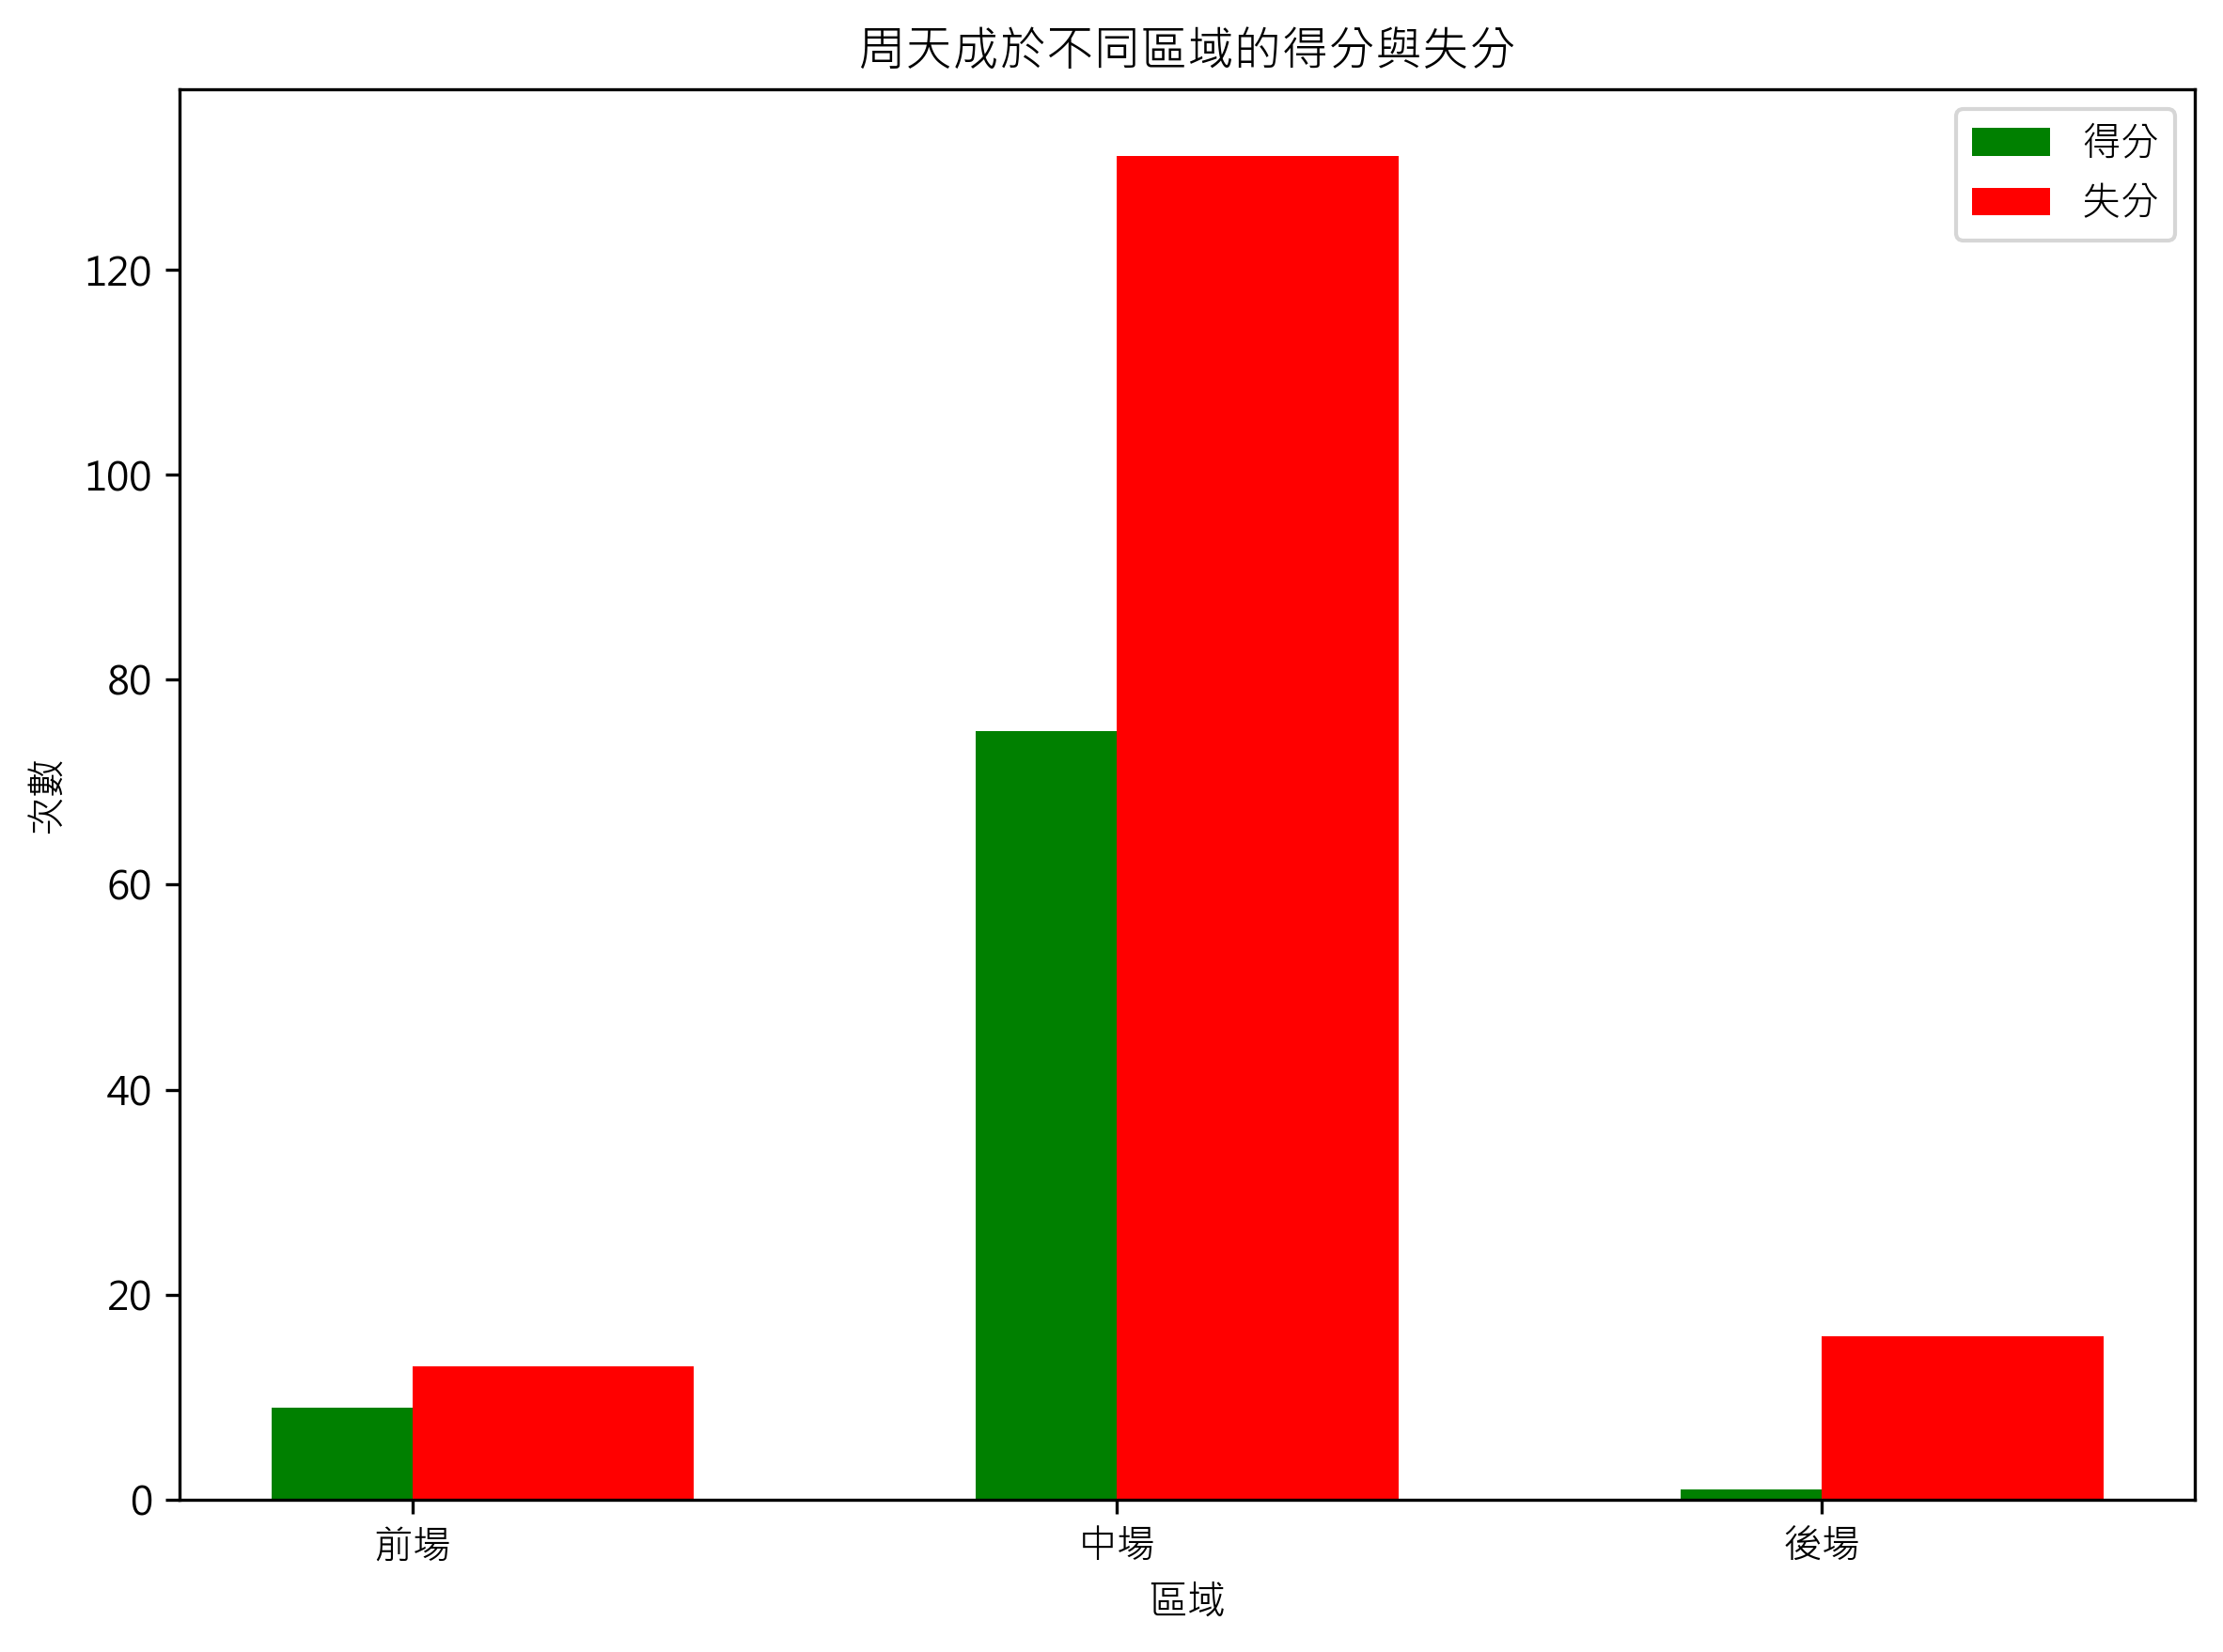

In [ ]:
# 確保資料集不為空
if len(df) > 0:
    # 選擇周天成的數據
    chou_df = df[df['player'] == 'CHOU Tien Chen']

    # 定義區域分類
    front_court_zones = [17, 18, 19, 20, 21, 22, 23, 24]
    mid_court_zones = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    back_court_zones = [1, 2, 3, 4]

    # 遍歷各個區域
    results = {'區域': [], '得分': [], '失分': []}
    for zone_type, zones in zip(['前場', '中場', '後場'], 
                                [front_court_zones, mid_court_zones, back_court_zones]):
        # 選擇在指定區域內的數據
        zone_df = chou_df[chou_df['player_location_area'].isin(zones)]

        # 計算得分
        score_points = zone_df[zone_df['player'] == zone_df['getpoint_player']].shape[0]

        # 計算失分
        lose_points = zone_df[zone_df['opponent'] == zone_df['getpoint_player']].shape[0]

        # 保存結果
        results['區域'].append(zone_type)
        results['得分'].append(score_points)
        results['失分'].append(lose_points)
    
    # 輸出結果
    for index, zone in enumerate(results['區域']):
        print(f"{zone}: 得分 = {results['得分'][index]}, 失分 = {results['失分'][index]}")

    # 可視化結果
    fig, ax = plt.subplots(figsize=(8, 6))
    x = range(len(results['區域']))
    ax.bar(x, results['得分'], width=0.4, label='得分', color='g', align='center')
    ax.bar(x, results['失分'], width=0.4, label='失分', color='r', align='edge')
    ax.set_xticks(x)
    ax.set_xticklabels(results['區域'])
    ax.set_ylabel('次數')
    ax.set_xlabel('區域')
    ax.set_title('周天成於不同區域的得分與失分')
    ax.legend()
    plt.tight_layout()
else:
    print("資料集中沒有數據可供分析。")


### 數據洞察
從數據中可以看出，周天成在不同場區的表現有顯著差異。

1. **前場**：得分9次，失分13次。這表明他在前場的攻擊效率較低，可能需要加強網前的進攻技術和控球能力。

2. **中場**：得分75次，失分131次。中場是周天成的主要戰場，但失分遠高於得分，這可能是由於對手在中場的反擊能力強，或是周天成在中場的防守存在漏洞。

3. **後場**：得分1次，失分16次。後場的數據顯示出他在後場的得分能力幾乎為零，而失分相對較高，顯示出後場的防守壓力大，可能需要提升後場的防守和反擊能力。

總結來看，周天成在中場的活動最頻繁，但需要提高得分效率和減少失分，尤其是在後場的防守需要加強，以減少對手的得分機會。這些數據提供了一個清晰的方向，幫助他在不同場區制定更有效的戰術。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference 的核心邏輯。主要問題在於它直接在逐筆資料上篩選周天成的擊球位置，然後統計得分與失分，這樣的做法忽略了每個 rally 的最終狀態。Reference Code 1 是先篩選出每個 rally 的最後一拍，然後根據該拍的得分者來判斷周天成的得失分，這樣才能正確反映每個回合的結果。候選程式碼的統計口徑錯誤，因為它可能將同一個 rally 的不同拍分別計入不同區域的得失分，這不符合題目要求的分析單位。




## 題號 10
**問題**: 當周天成站在前場時，他最主要的得分球種?
> **使用的資料欄位群組**: `game_structure, shot_type, player_location, scoring_reason`


In [ ]:
# 確認資料存在
if len(df) > 0:
    # 選取周天成在前場區域的擊球數據
    front_court_zones = [17, 18, 19, 20, 21, 22, 23, 24]
    
    # 篩選周天成的主動得分且在前場的數據
    ch_out_data = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['getpoint_player'] == 'CHOU Tien Chen') &
        (df['player_location_area'].isin(front_court_zones))
    ]
    
    if len(ch_out_data) > 0:
        # 球種出現頻率
        type_frequency = ch_out_data['type'].value_counts()
        
        # 找到最主要的得分球種
        primary_scoring_shot = type_frequency.idxmax()
        primary_scoring_count = type_frequency.max()
        
        # 打印結果
        print(f"周天成在前場最主要的得分球種是: {primary_scoring_shot}，出現次數: {primary_scoring_count}")
    else:
        print("在指定條件下沒有找到周天成的有效數據。")
else:
    print("數據集中沒有可用的數據進行分析。")


### 數據洞察
根據數據分析，當周天成站在前場時，他最主要的得分球種是殺球，出現次數為7次。這顯示出周天成在前場位置時，具備強大的進攻能力，特別是在殺球方面具有高效的得分潛力。

這意味著對手在面對周天成時，必須特別警惕他在前場的殺球威脅。對於周天成來說，這樣的數據也強調了他應該繼續在前場位置上發揮殺球的優勢，並且在訓練中進一步強化這項技能，以保持其在比賽中的競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選了周天成在前場位置且是得分者的資料，並計算得分球種的出現次數以找出最主要的得分方式。候選程式碼的變數命名和輸出格式略有不同，但這些差異不影響分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標。因此，候選程式碼是正確的。




## 題號 11
**問題**: 計算周天成站在前場擊球時的落點分布。
> **使用的資料欄位群組**: `game_structure, coordinates, player_location`


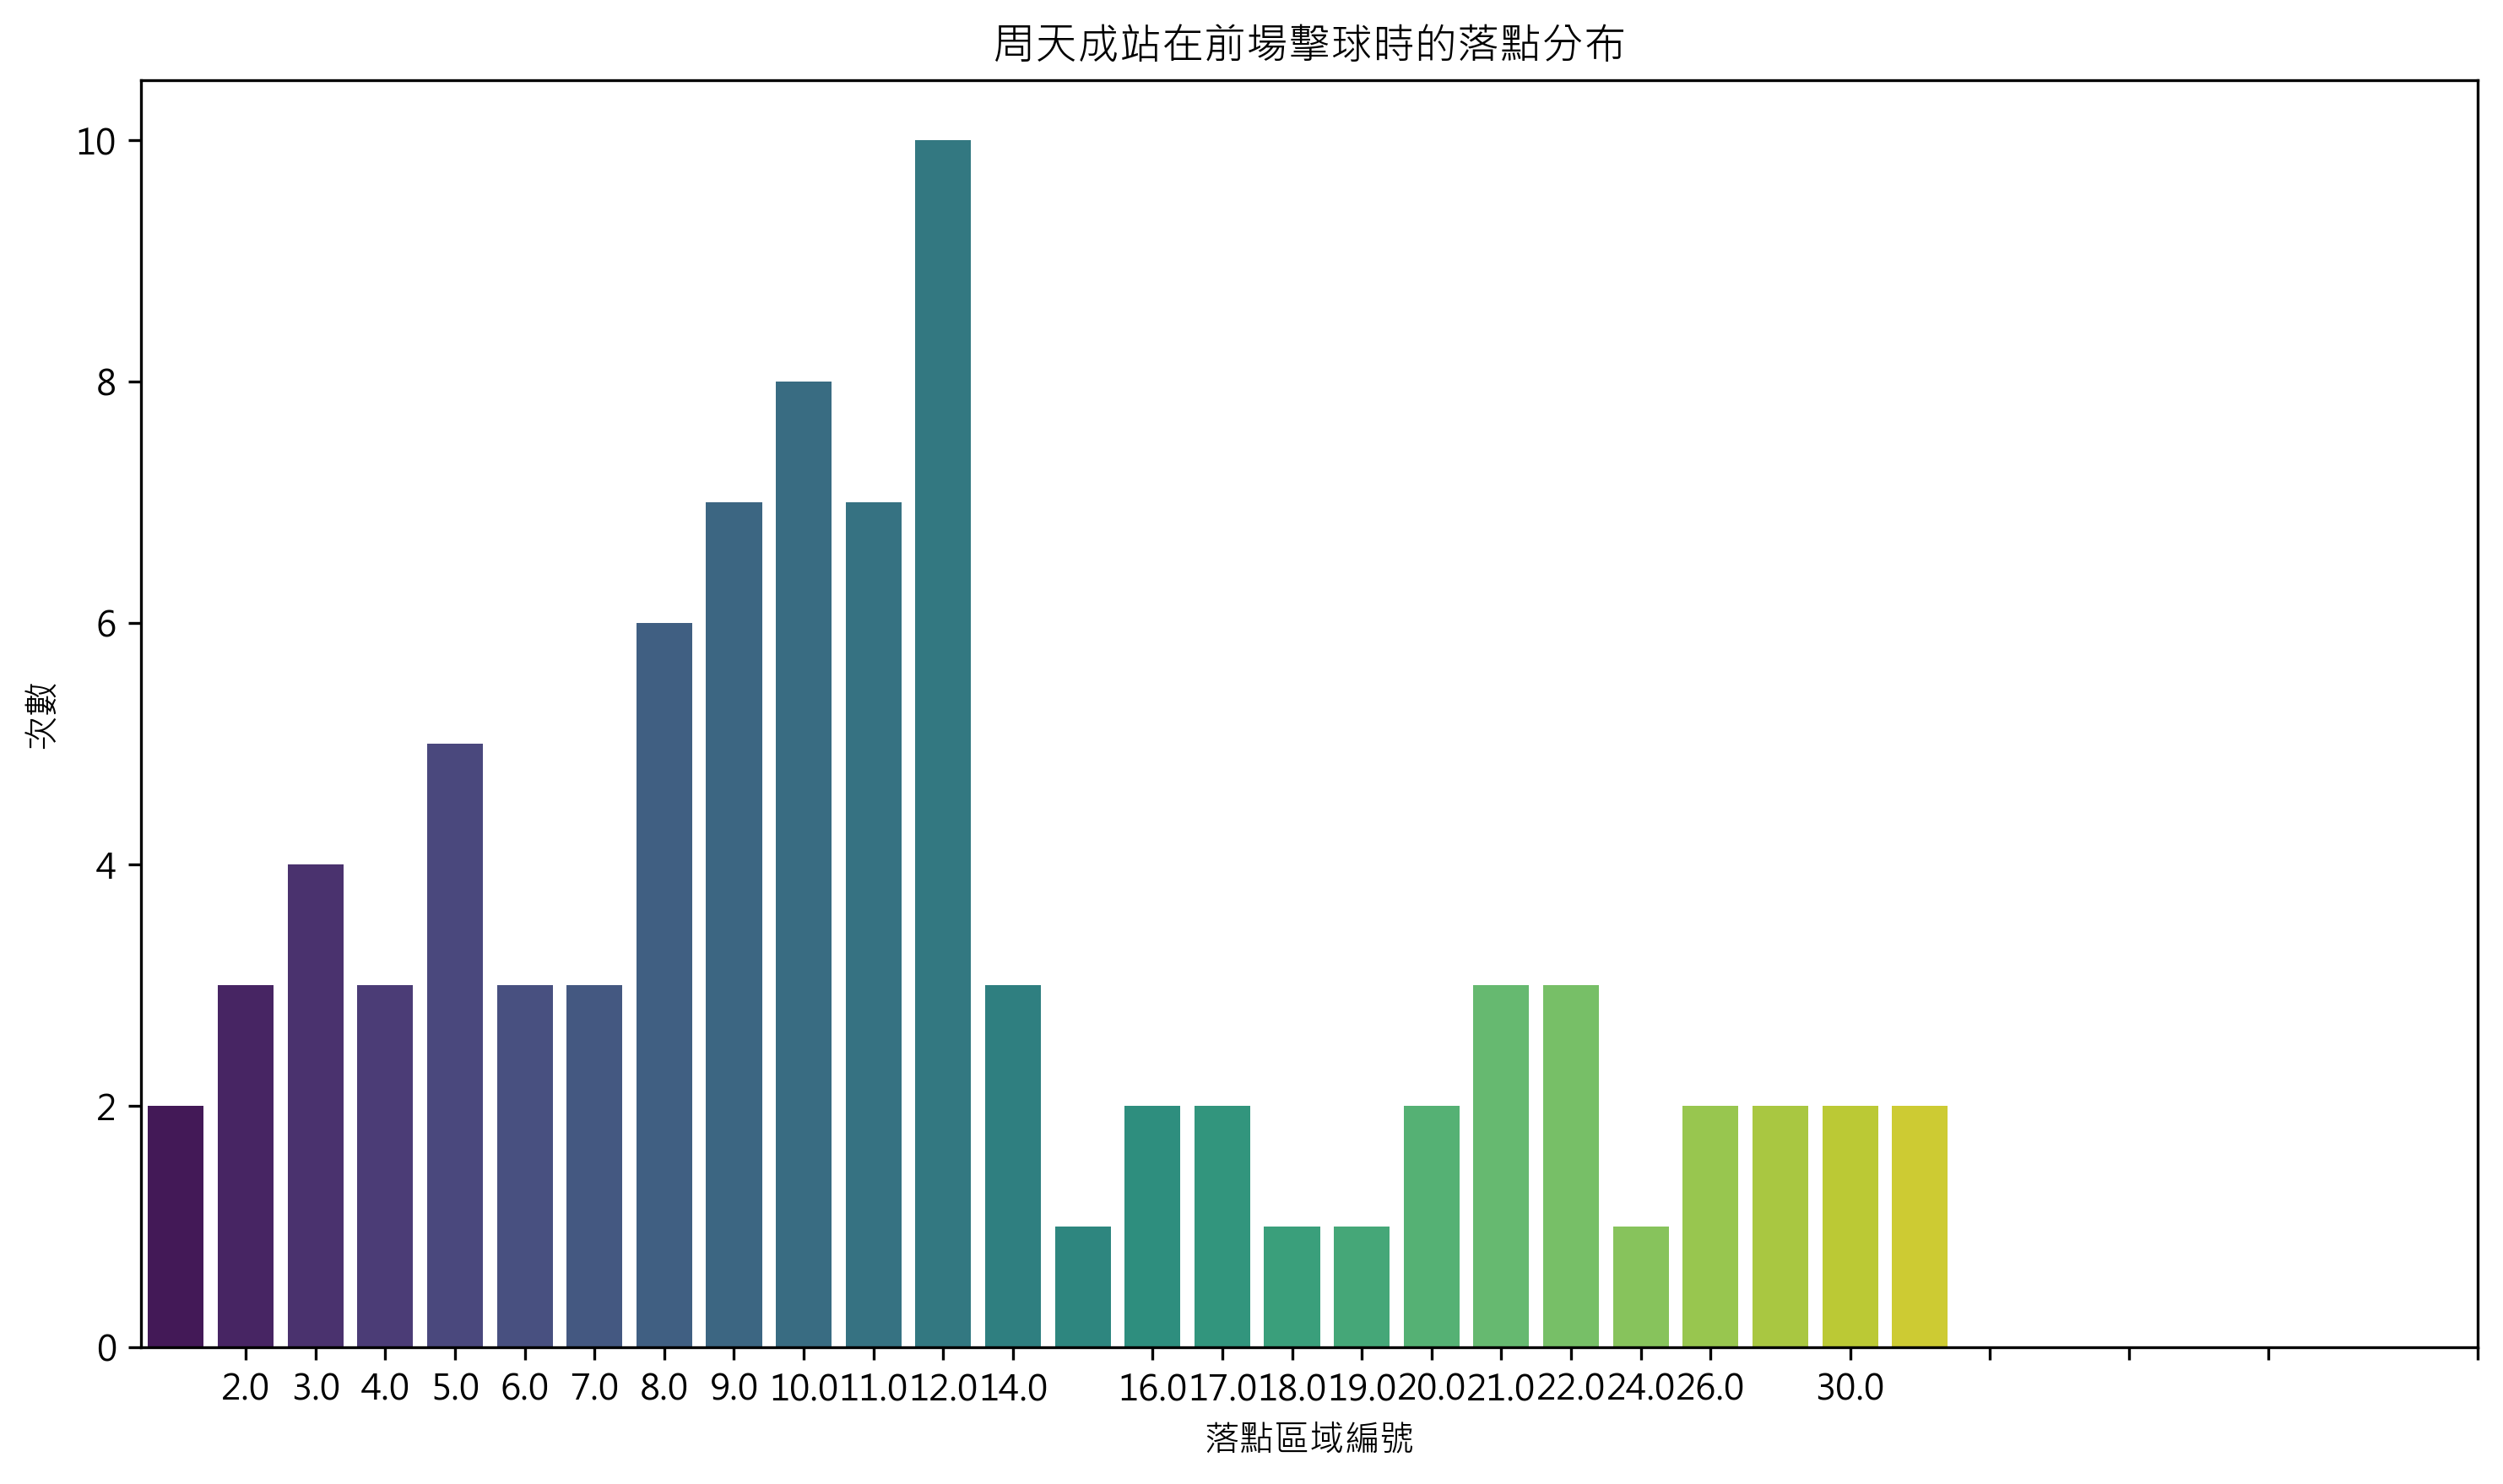

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Check for valid data
if len(df) > 0:
    # Step 2: Filter conditions
    front_court_areas = [17, 18, 19, 20, 21, 22, 23, 24]
    chou_tien_chen_front_shots = df[(df['player'] == 'CHOU Tien Chen') & 
                                    (df['player_location_area'].isin(front_court_areas))]
    
    # Step 3: Get landing area distribution
    landing_distribution = chou_tien_chen_front_shots['landing_area'].value_counts().sort_index()
    
    # Step 4: Visualize or Describe
    plt.figure(figsize=(10, 6))
    sns.barplot(x=landing_distribution.index, y=landing_distribution.values, palette="viridis")
    plt.title('周天成站在前場擊球時的落點分布')
    plt.xlabel('落點區域編號')
    plt.ylabel('次數')
    plt.xticks(landing_distribution.index)  # Only show existing landing areas
    plt.tight_layout()
    
    # Output the statistics
    print("周天成站在前場擊球時的落點分布:")
    print(landing_distribution)
else:
    print("No valid data available.")


### 數據洞察
根據數據，周天成在前場擊球時的落點分布顯示，他的球主要集中在中場和後場區域，特別是10、12和11區域，這些區域的落點次數較高，分別是8、10和7次。這表明他在前場時，經常選擇將球打向對手的中場和後場，可能是為了壓制對手，迫使對手後退，從而為自己創造進攻機會。

值得注意的是，21和22區域的落點次數相對較少，這意味著他在前場時較少選擇將球打向對手的前場左側和中左側，這可能是基於戰術考量，避免給對手創造網前進攻的機會。

總結來看，周天成在前場的擊球策略似乎較為保守，偏向於控制和壓制對手的中後場，這樣的策略可以有效降低被對手反擊的風險。這些數據可以幫助我們更好地理解他在比賽中的戰術選擇。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了周天成站在前場擊球的數據，並計算了落點區域的分布。分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 1 一致。候選程式碼使用了 Seaborn 進行視覺化，這是可以接受的差異，不影響判定。




## 題號 12
**問題**: 分析周天成站在前中後場擊球時，自己分別的移動距離
> **使用的資料欄位群組**: `game_structure, player_location, player_movement`


In [ ]:
# 確保數據不為空
if len(df) > 0:
    # 過濾出周天成的數據
    chou_df = df[df['player'] == 'CHOU Tien Chen']

    # 判斷每個位置的類別
    def categorize_position(area):
        if area in [17, 18, 19, 20, 21, 22, 23, 24]:
            return '前場'
        elif area in [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]:
            return '中場'
        elif area in [1, 2, 3, 4]:
            return '後場'
        else:
            return '其他'

    chou_df['location_category'] = chou_df['player_location_area'].apply(categorize_position)
    
    # 計算每個位置的移動距離
    chou_df['移動距離'] = (chou_df['player_move_x']**2 + chou_df['player_move_y']**2)**0.5
    
    # 計算每個位置類別的平均移動距離
    avg_movement_distance = chou_df.groupby('location_category')['移動距離'].mean()

    print("周天成在不同場地位置的平均移動距離:")
    print(avg_movement_distance)

else:
    print("數據集為空，無法進行分析。")


### 數據洞察
根據數據分析，周天成在不同場地位置的平均移動距離如下：

1. **前場**：平均移動距離為0.227086。這顯示他在前場的移動相對較少，可能因為前場需要快速反應和精準的網前技術，而不一定需要大範圍的移動。

2. **中場**：平均移動距離為0.323499。中場的移動距離略高，這是因為中場需要兼顧前後場的連接，移動範圍較大以應對各種來球。

3. **後場**：平均移動距離為0.344449。後場的移動距離是最高的，這反映了後場需要進行大範圍的移動來處理高遠球和殺球，並且需要快速回位以準備下一拍。

這些數據顯示，周天成在不同場地位置的移動策略是根據場地需求而調整的，這種靈活性對於維持比賽中的高效能至關重要。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都過濾出周天成的數據，並根據 player_location_area 將位置分類為前場、中場和後場。然後，計算每個位置類別的平均移動距離。候選程式碼使用 apply 函數來分類位置，這與 Reference Code 1 的直接篩選方式不同，但在邏輯上是等價的。最終輸出目標也是計算周天成在不同場地位置的平均移動距離，因此判定為正確。




## 題號 13
**問題**: 幫我統整周天成所有球種的使用比例，以及每種球種的「得分次數」和「失誤次數」。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# 1. 篩選周天成的資料
chou_df = df[df['player'] == 'CHOU Tien Chen']

# 確保資料完整性
if len(chou_df) > 0:
    # 2. 計算每種球種的使用次數
    type_usage_count = chou_df['type'].value_counts()

    # 3. 計算每種球種的得分次數
    chou_win_df = chou_df[chou_df['getpoint_player'] == chou_df['player']]
    type_win_count = chou_win_df['type'].value_counts()

    # 4. 計算每種球種的失誤次數
    chou_lose_df = chou_df[chou_df['lose_reason'].notna()]
    type_lose_count = chou_lose_df['type'].value_counts()

    # 5. 計算每種球種的使用比例
    type_usage_ratio = type_usage_count / type_usage_count.sum() * 100

    # 統整成一個DataFrame
    summary_df = pd.DataFrame({
        '使用次數': type_usage_count,
        '使用比例(%)': type_usage_ratio,
        '得分次數': type_win_count,
        '失誤次數': type_lose_count
    }).fillna(0)  # 用0填充空值

    # 打印結果
    print(summary_df)
else:
    print("No data available for CHOU Tien Chen.")


### 數據洞察
從數據中，我們可以看到周天成在不同球種上的使用比例及其效果：

1. **網前球**：使用比例最高，達到22.31%，但失誤次數也最多，有40次。這表明他在網前球的控制上需要加強，避免不必要的失誤。

2. **接殺防守**：使用比例13.45%，失誤37次，得分5次。這顯示他在防守對手殺球時有一定的挑戰，可能需要提高防守的穩定性。

3. **殺球**：雖然使用比例只有11.46%，但得分61次，是所有球種中得分最多的。這說明殺球是他的主要得分手段，應保持並進一步強化這一優勢。

4. **推撲球**：使用比例12.80%，得分9次，失誤19次。這種球種在進攻中有一定效果，但失誤也不少，需注意精準度。

5. **挑球**與**長球**：這兩種球的使用比例分別為10.35%和10.54%，但得分不多且失誤較多，需考慮在何時使用這些球種以減少失誤。

6. **平球**與**切球**：使用比例較低，分別為4.06%和8.09%，且失誤次數相對較高，這可能是他需要改進的部分。

7. **發球**：發短球和發長球的使用比例分別為5.63%和1.30%，且沒有失誤，顯示出發球的穩定性，但也需考慮如何通過發球創造更多得分機會。

總體來看，周天成在進攻方面，特別是殺球上有強大的得分能力，但在防守和網前控制上需要加強。專注於減少失誤，特別是在網前球和接殺防守上，將有助於提升整體表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了周天成的數據，計算了每種球種的使用次數、得分次數和失誤次數，並計算了使用比例。這些操作與 Reference Code 1 的分析對象、欄位語意、篩選條件、分組層級和統計口徑一致，且最終輸出目標也符合題目要求。




## 題號 14
**問題**: 幫我畫周天成失分原因的圓餅圖
> **使用的資料欄位群組**: `game_structure, scoring_reason`


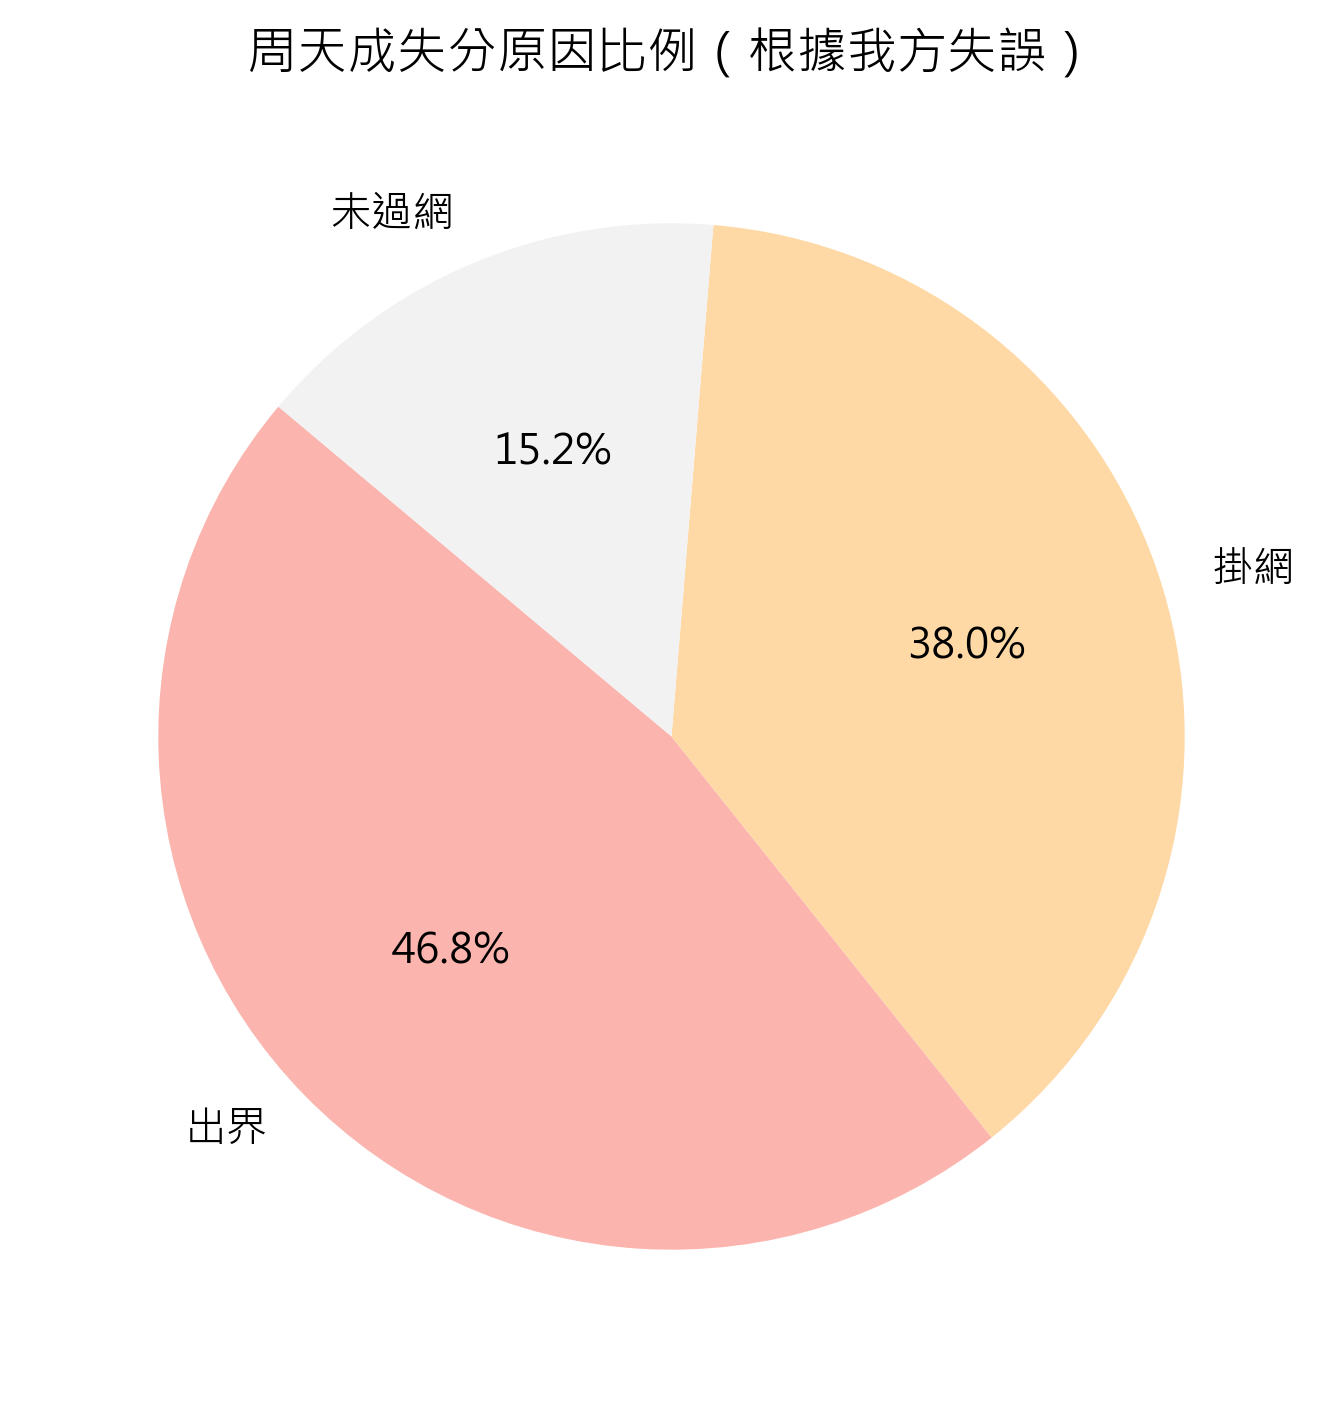

In [ ]:
# 確保數據集中有資料
if len(df) > 0:
    # 篩選周天成失分的數據
    chou_tien_chen_errors = df[(df['player'] == 'CHOU Tien Chen') & 
                               (df['getpoint_player'] == 'Kento MOMOTA') & 
                               df['lose_reason'].notna()]

    # 計數各種失分原因
    loss_reason_counts = chou_tien_chen_errors['lose_reason'].value_counts()

    # 繪製圓餅圖
    fig, ax = plt.subplots()
    loss_reason_counts.plot.pie(ax=ax, labels=loss_reason_counts.index, autopct='%1.1f%%',
                                startangle=140, cmap='Pastel1', legend=False)
    ax.set_ylabel('')
    ax.set_title('周天成失分原因比例（根據我方失誤）')
    plt.tight_layout()

    # 打印詳細信息
    print("周天成失分原因及次數:\n", loss_reason_counts)
else:
    print("數據集中沒有資料，無法繪製圖表。")


### 數據洞察
在分析周天成的失分原因時，我們可以從數據中得出以下洞察：

1. **出界**：占據失分的最大比例，共有74次。這表明周天成在控制球的落點時存在一定的挑戰。可能需要加強對球場邊界的感知和控制。

2. **掛網**：有60次失分是因為掛網。這顯示出在擊球時，尤其是網前球的處理上，需要更精確的拍面控制和力量調節。

3. **未過網**：有24次失分是因為球未過網。這可能與擊球時的力度不足或擊球點選擇不當有關。

這些數據表明，周天成在比賽中需要更加注重基本技術的穩定性，尤其是在控制球的落點和網前球的處理上。這樣可以有效減少非受迫性失誤，提升比賽中的競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 2 的核心邏輯。它正確地篩選出周天成失分的情況，並計算各種失分原因的次數，然後繪製圓餅圖來展示失分原因的比例。分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 2 一致，因此判定為正確。




## 題號 15
**問題**: 當周天成的對手處於「前場」時，周天成打球的落點分布
> **使用的資料欄位群組**: `game_structure, coordinates, player_location`


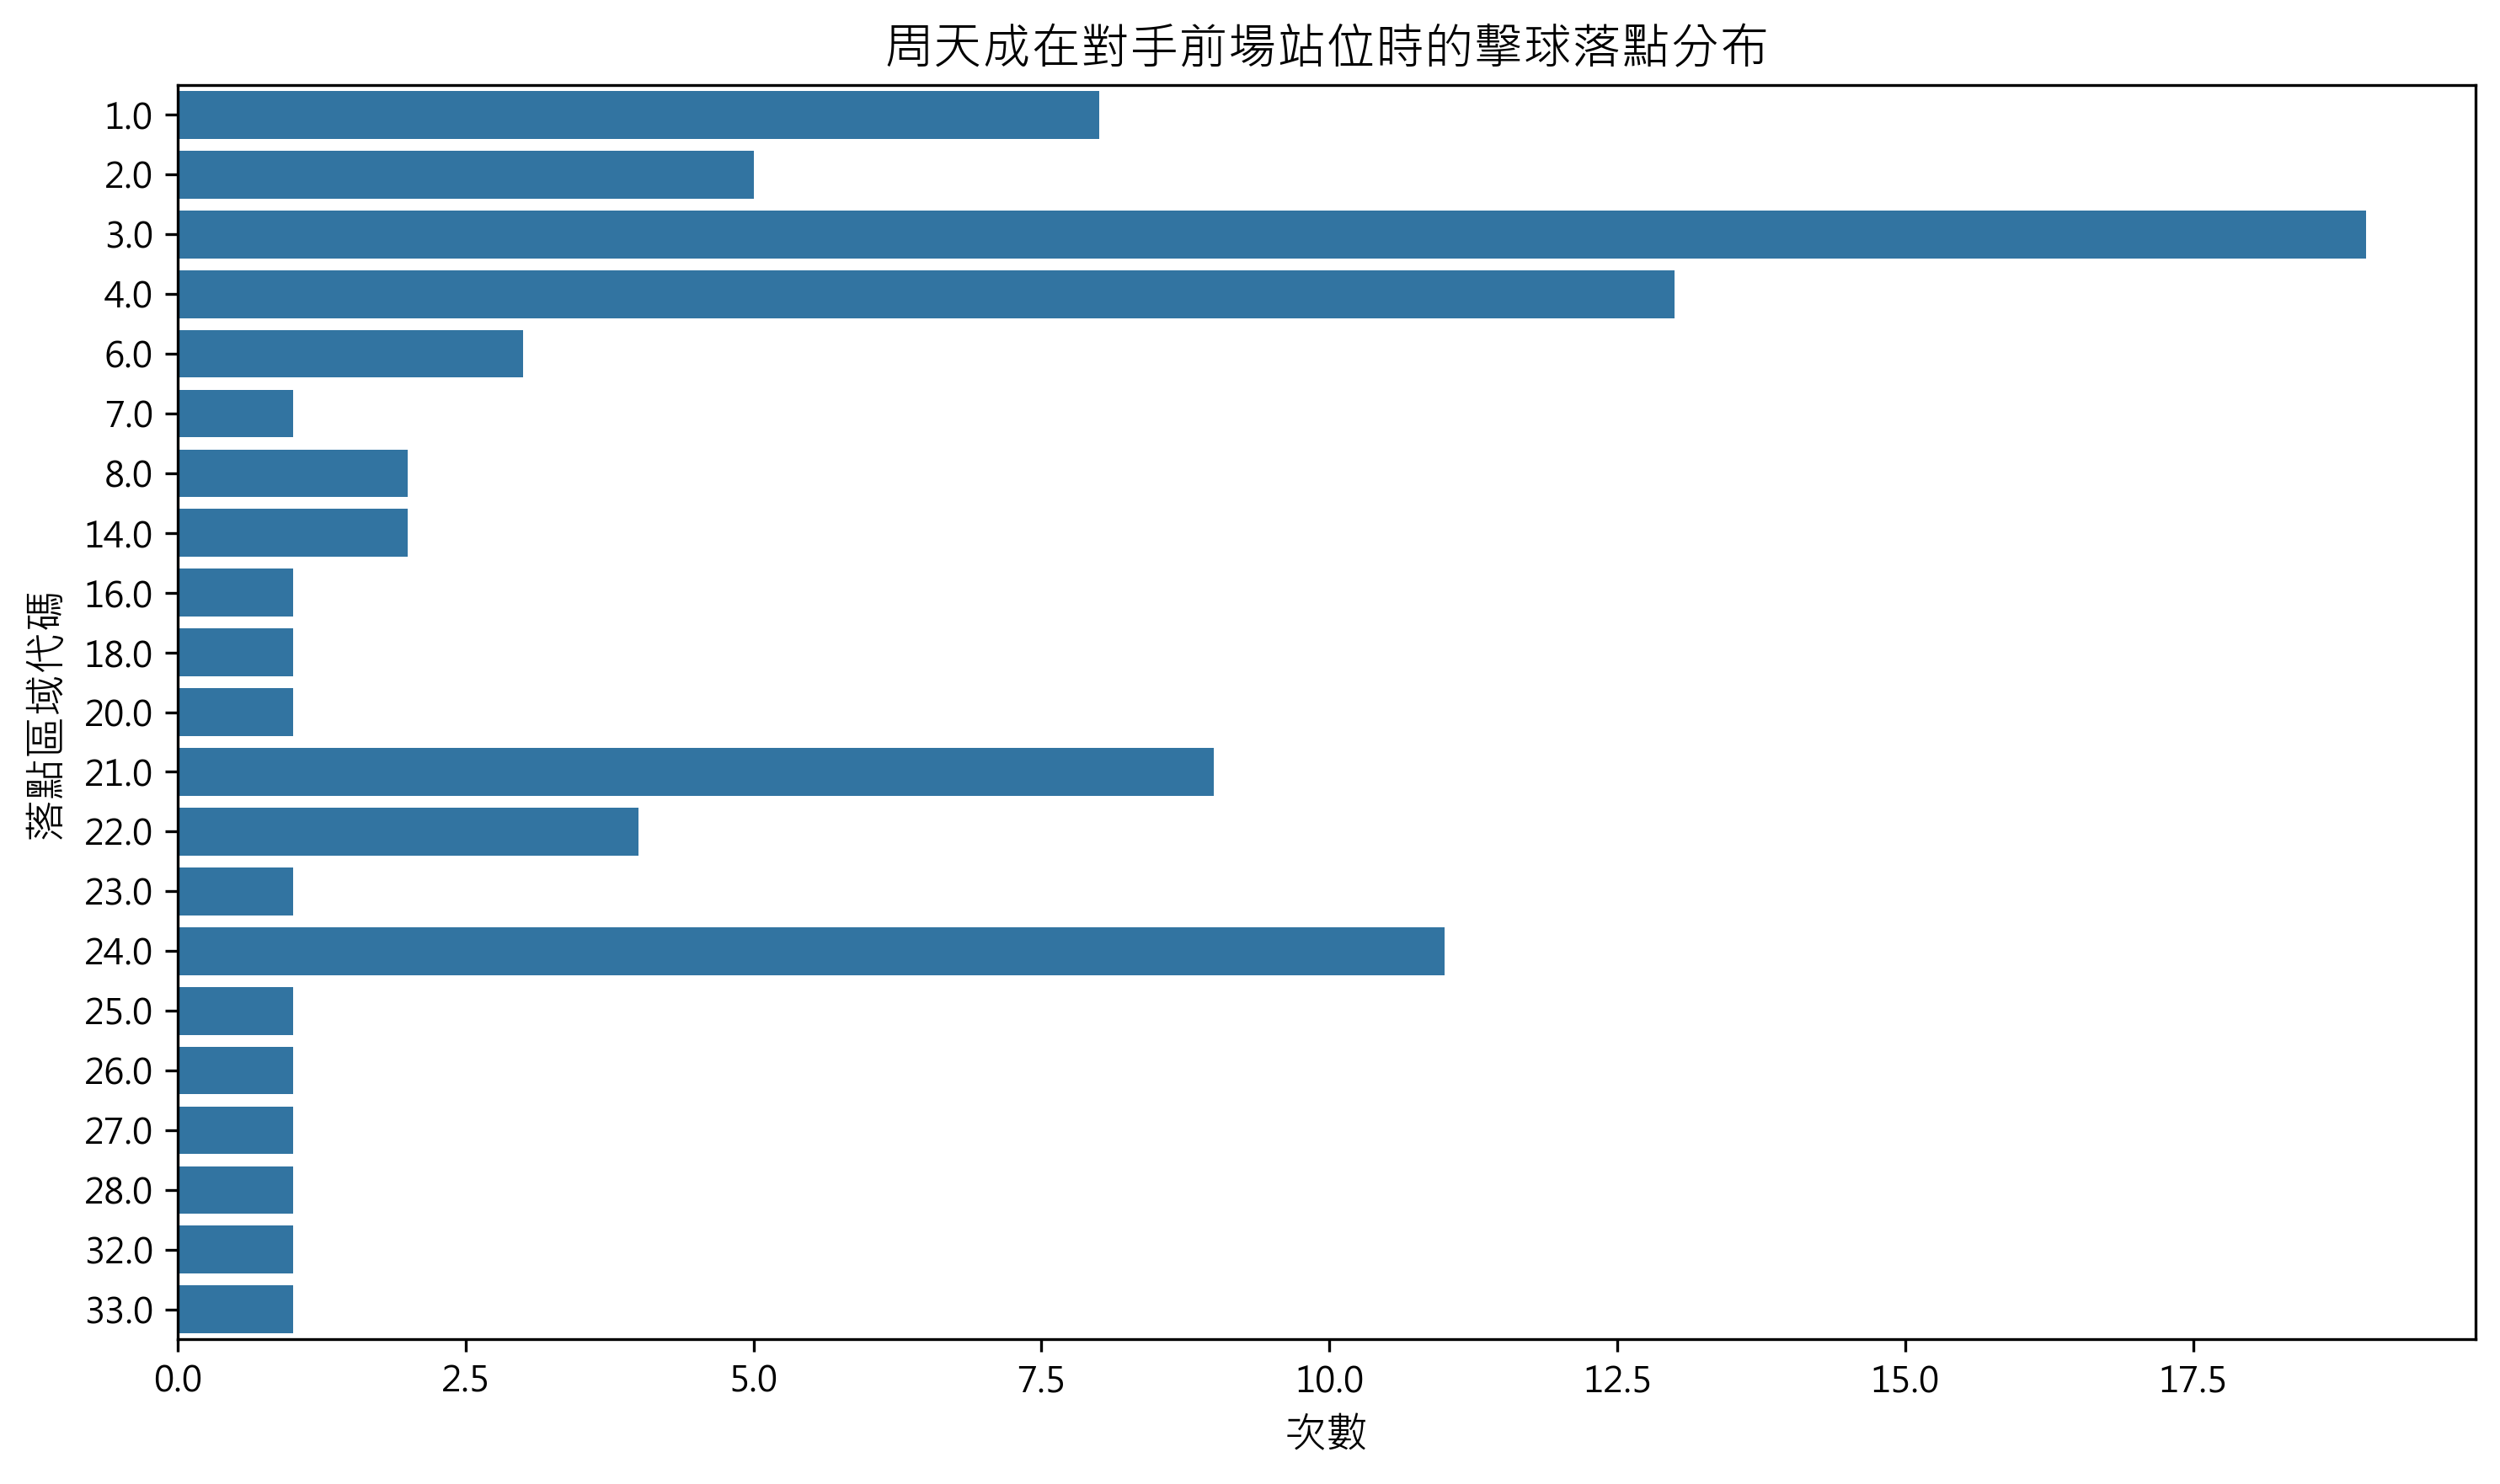

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 確認數據量大於0
if len(df) > 0:
    # 定義前場的區域代碼
    front_court_zones = [17, 18, 19, 20, 21, 22, 23, 24]

    # 過濾條件：對手站在前場 & 周天成擊球
    filtered_df = df[(df['opponent_location_area'].isin(front_court_zones)) & 
                     (df['player'] == 'CHOU Tien Chen')]

    # 確認過濾後的數據量大於0
    if len(filtered_df) > 0:
        # 計算落點分布（區域代碼計數）
        landing_distribution = filtered_df['landing_area'].value_counts().sort_index()

        # 使用 Matplotlib 繪製落點分布圖
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(y=landing_distribution.index, x=landing_distribution.values, ax=ax, orient='h')

        # 標籤與標題
        ax.set_title('周天成在對手前場站位時的擊球落點分布', fontsize=14)
        ax.set_ylabel('落點區域代碼', fontsize=12)
        ax.set_xlabel('次數', fontsize=12)

        plt.tight_layout()

        # 打印落點分布詳細數據
        print("周天成在對手前場站位時的擊球落點分布:")
        print(landing_distribution)
    else:
        print("無符合條件的記錄：對手站在前場且周天成擊球。")
else:
    print("數據集為空。")


### 數據洞察
根據數據，當周天成的對手站位在前場時，他的擊球落點主要集中在以下區域：

1. **區域 3 (Row 1, C-Right)**：19次，顯示他經常選擇將球打向後場中間偏右的位置。
2. **區域 24 (Row 6, Right)**：11次，這是一個前場右側的落點，顯示他有時會利用這個區域來突破對手的前場站位。
3. **區域 21 (Row 6, Left)**：9次，這是前場左側的落點，可能用來牽制對手的移動。
4. **區域 4 (Row 1, Right)**：13次，這是後場右側的落點，顯示他也會利用後場的空間來進行攻擊。

這些數據表明，周天成在對手前場站位時，善於利用後場的空間來施壓，特別是中間偏右和右側的落點。同時，他也會選擇在前場左右兩側進行攻擊，可能是為了打破對手的防守節奏。這樣的落點分布顯示了他在場上靈活的戰術運用。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選了周天成為 player 且對手在前場區域的情況，並對落點區域進行了統計。Reference Code 1 使用散點圖顯示落點分布，而候選程式碼則使用條形圖顯示落點區域的計數分布。兩者在分析對象、欄位語意、篩選條件和最終輸出目標上是一致的，僅在視覺化形式上有所不同，這是可以接受的差異。




## 題號 16 (*)
**問題**: 給我周天成最常見的失分原因
> **使用的資料欄位群組**: `game_structure, scoring_reason`


In [ ]:
# 先確認數據量
if len(df) == 0:
    print("資料集中沒有可分析的數據。")
else:
    # 篩選周天成失分的情況
    ctc_loss_df = df[(df['losepoint_player'] == 'Chou Tien Chen') & (df['lose_reason'].notna())]

    # 統計周天成失分原因出現的次數
    lose_reason_counts = ctc_loss_df['lose_reason'].value_counts()

    # 判斷是否有失分原因的資料可供分析
    if len(lose_reason_counts) > 0:
        # 找出最常見的失分原因
        most_common_lose_reason = lose_reason_counts.idxmax()
        most_common_lose_reason_count = lose_reason_counts.max()

        print(f"周天成最常見的失分原因是：{most_common_lose_reason}，共出現 {most_common_lose_reason_count} 次。")
    else:
        print("資料中沒有周天成失分原因的相關記錄。")


### 數據洞察
根據數據分析，周天成最常見的失分原因是「接不到」，這在羽球中通常表示對手的進攻過於強勢或是周天成的防守位置不夠理想。這一點顯示他可能需要加強在接殺防守（Mapping: 10）和移動速度上的訓練，以提高在快速來回中的反應能力。

此外，失分的分布中，對手的進攻落點多集中在後場的Col B (C-Left)和Col C (C-Right)區域（Row 1和Row 2）。這意味著周天成在這些區域的防守需要更加穩固，可能需要加強後場的防守策略和腳步移動。

這些洞察可以幫助他在比賽中更好地應對對手的進攻，提高整體防守能力，從而減少失分。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。主要問題在於：1. 使用了錯誤的欄位 'losepoint_player'，而不是 'getpoint_player' 來判斷失分者。2. 沒有正確篩選出每個 rally 的最後一拍來判斷失分原因。3. 統計口徑錯誤，因為它直接在逐拍資料上篩選，而不是在每個 rally 的最後一拍上進行分析。這些問題導致無法正確回答題目要求的周天成最常見的失分原因。




## 題號 17
**問題**: 繪製周天成所有輸球原因為'掛網'時的球員站位熱區圖？
> **使用的資料欄位群組**: `game_structure, scoring_reason, player_location`


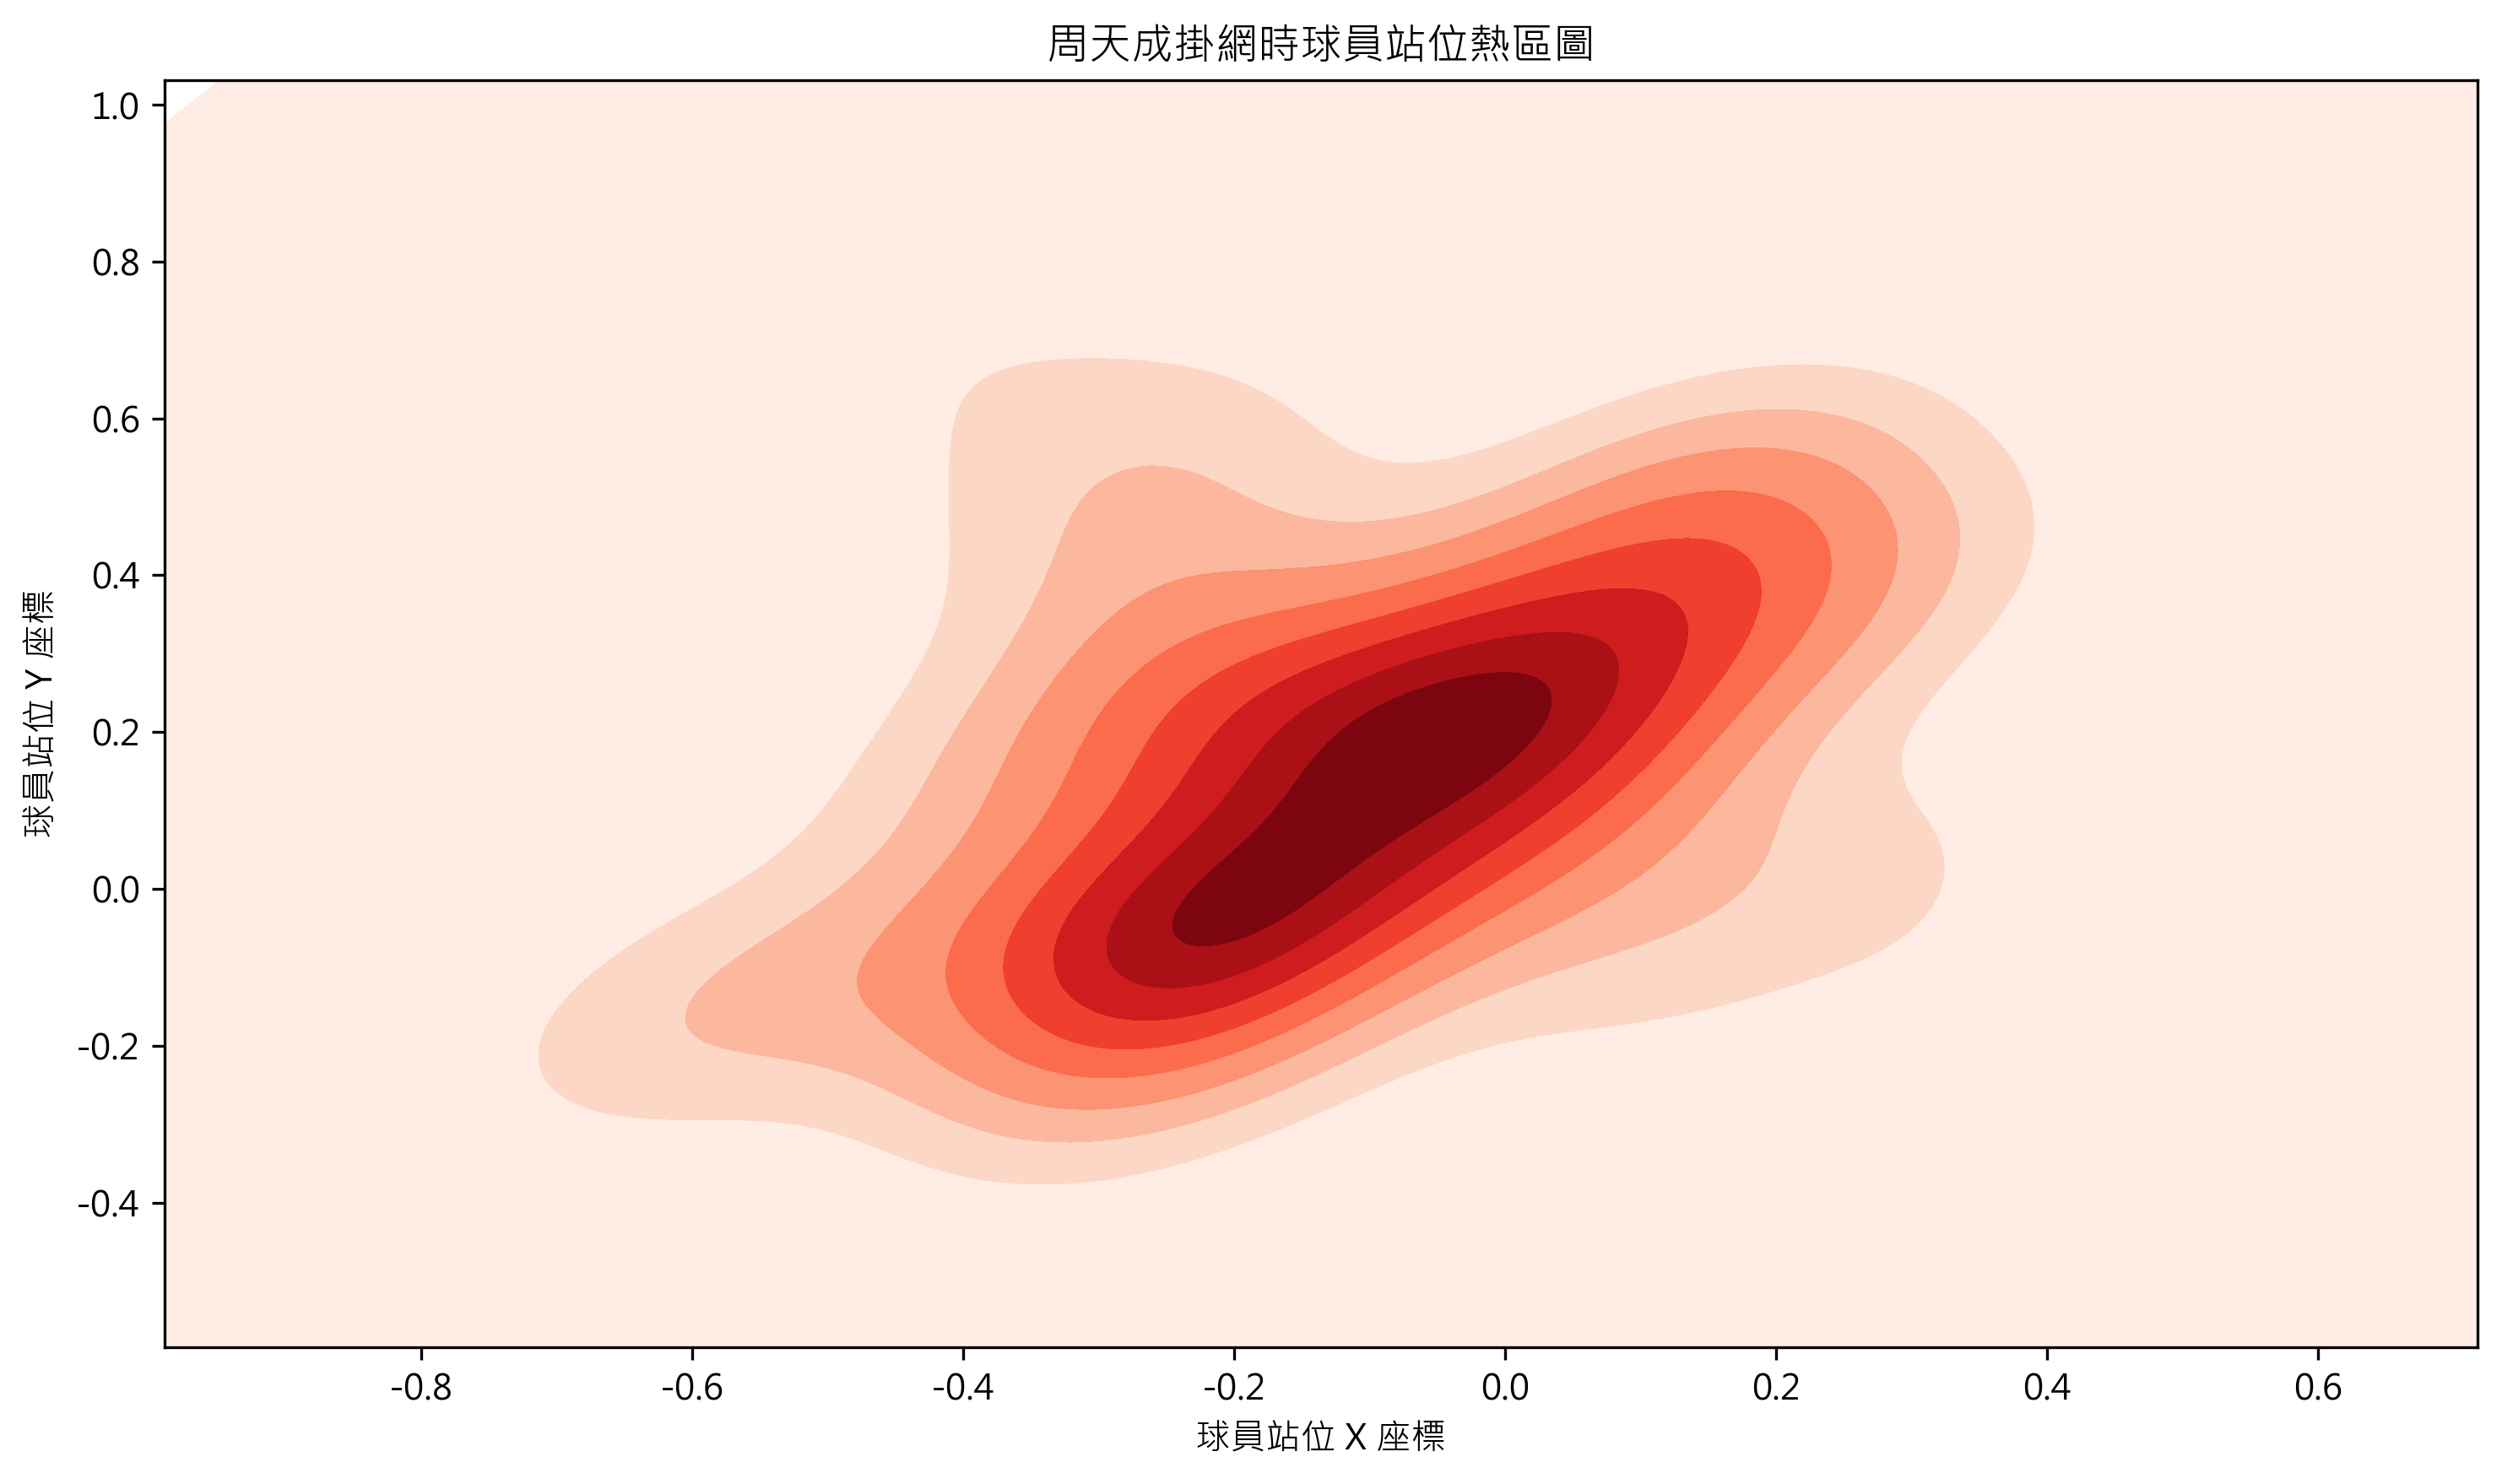

In [ ]:
# 1. 確保數據集不為空
if len(df) > 0:
    # 2. 過濾出周天成輸球原因為 '掛網' 的數據
    chou_tien_chen_loss_net_df = df[
        (df['player'] == 'CHOU Tien Chen') & 
        (df['lose_reason'] == '掛網')
    ]

    # 3. 確認過濾後數據不為空
    if len(chou_tien_chen_loss_net_df) > 0:
        # 4. 繪製熱區圖
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.kdeplot(
            data=chou_tien_chen_loss_net_df, 
            x='player_location_x', 
            y='player_location_y',
            cmap='Reds', 
            fill=True, 
            thresh=0,
            ax=ax
        )
        ax.set_title('周天成掛網時球員站位熱區圖')
        ax.set_xlabel('球員站位 X 座標')
        ax.set_ylabel('球員站位 Y 座標')

        # 輸出熱區圖
        plt.tight_layout()
        plt.show()
    else:
        print("找不到周天成在輸球原因為'掛網'時的相關數據。")

else:
    print("數據集為空，無法進行分析。")


### 數據洞察
根據我們的數據分析，周天成在比賽中因"掛網"而輸球的情況下，他的站位熱區圖顯示了以下幾個關鍵事實：

1. **站位分布**：在這60次失誤中，周天成的站位主要集中在中前場區域，特別是區域14和15（中前場的中左和中右位置）。這表明他在嘗試控制網前時，可能因為站位過於靠前而導致掛網失誤。

2. **技術動作**：從技術動作的角度來看，這些失誤可能與他在網前處理球時的選擇有關。Mapping顯示，當他選擇網前球（8）和切球（5）時，容易產生掛網失誤。這提示他在這些情況下需要更加謹慎，可能需要改善手腕控制和擊球力度。

這些數據告訴我們，周天成在面對網前球時需要加強穩定性，尤其是在中前場位置的處理。這樣的洞察可以幫助他在比賽中更好地選擇站位和擊球策略，以減少不必要的失誤。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選出周天成在輸球原因為'掛網'時的數據，並使用相同的欄位 'player_location_x' 和 'player_location_y' 來繪製站位熱區圖。候選程式碼的變數命名和圖表標籤略有不同，但這些差異不影響分析對象、欄位語意、篩選條件和最終輸出目標。因此，判定為 true。




## 題號 18 (*)
**問題**: 分析周天成在開局（自己0-4 分）、中局（自己5-17 分）和關鍵分（自己18 分以上）三個比分階段中，他自己移動距離的差異。
> **使用的資料欄位群組**: `game_structure, player_movement`


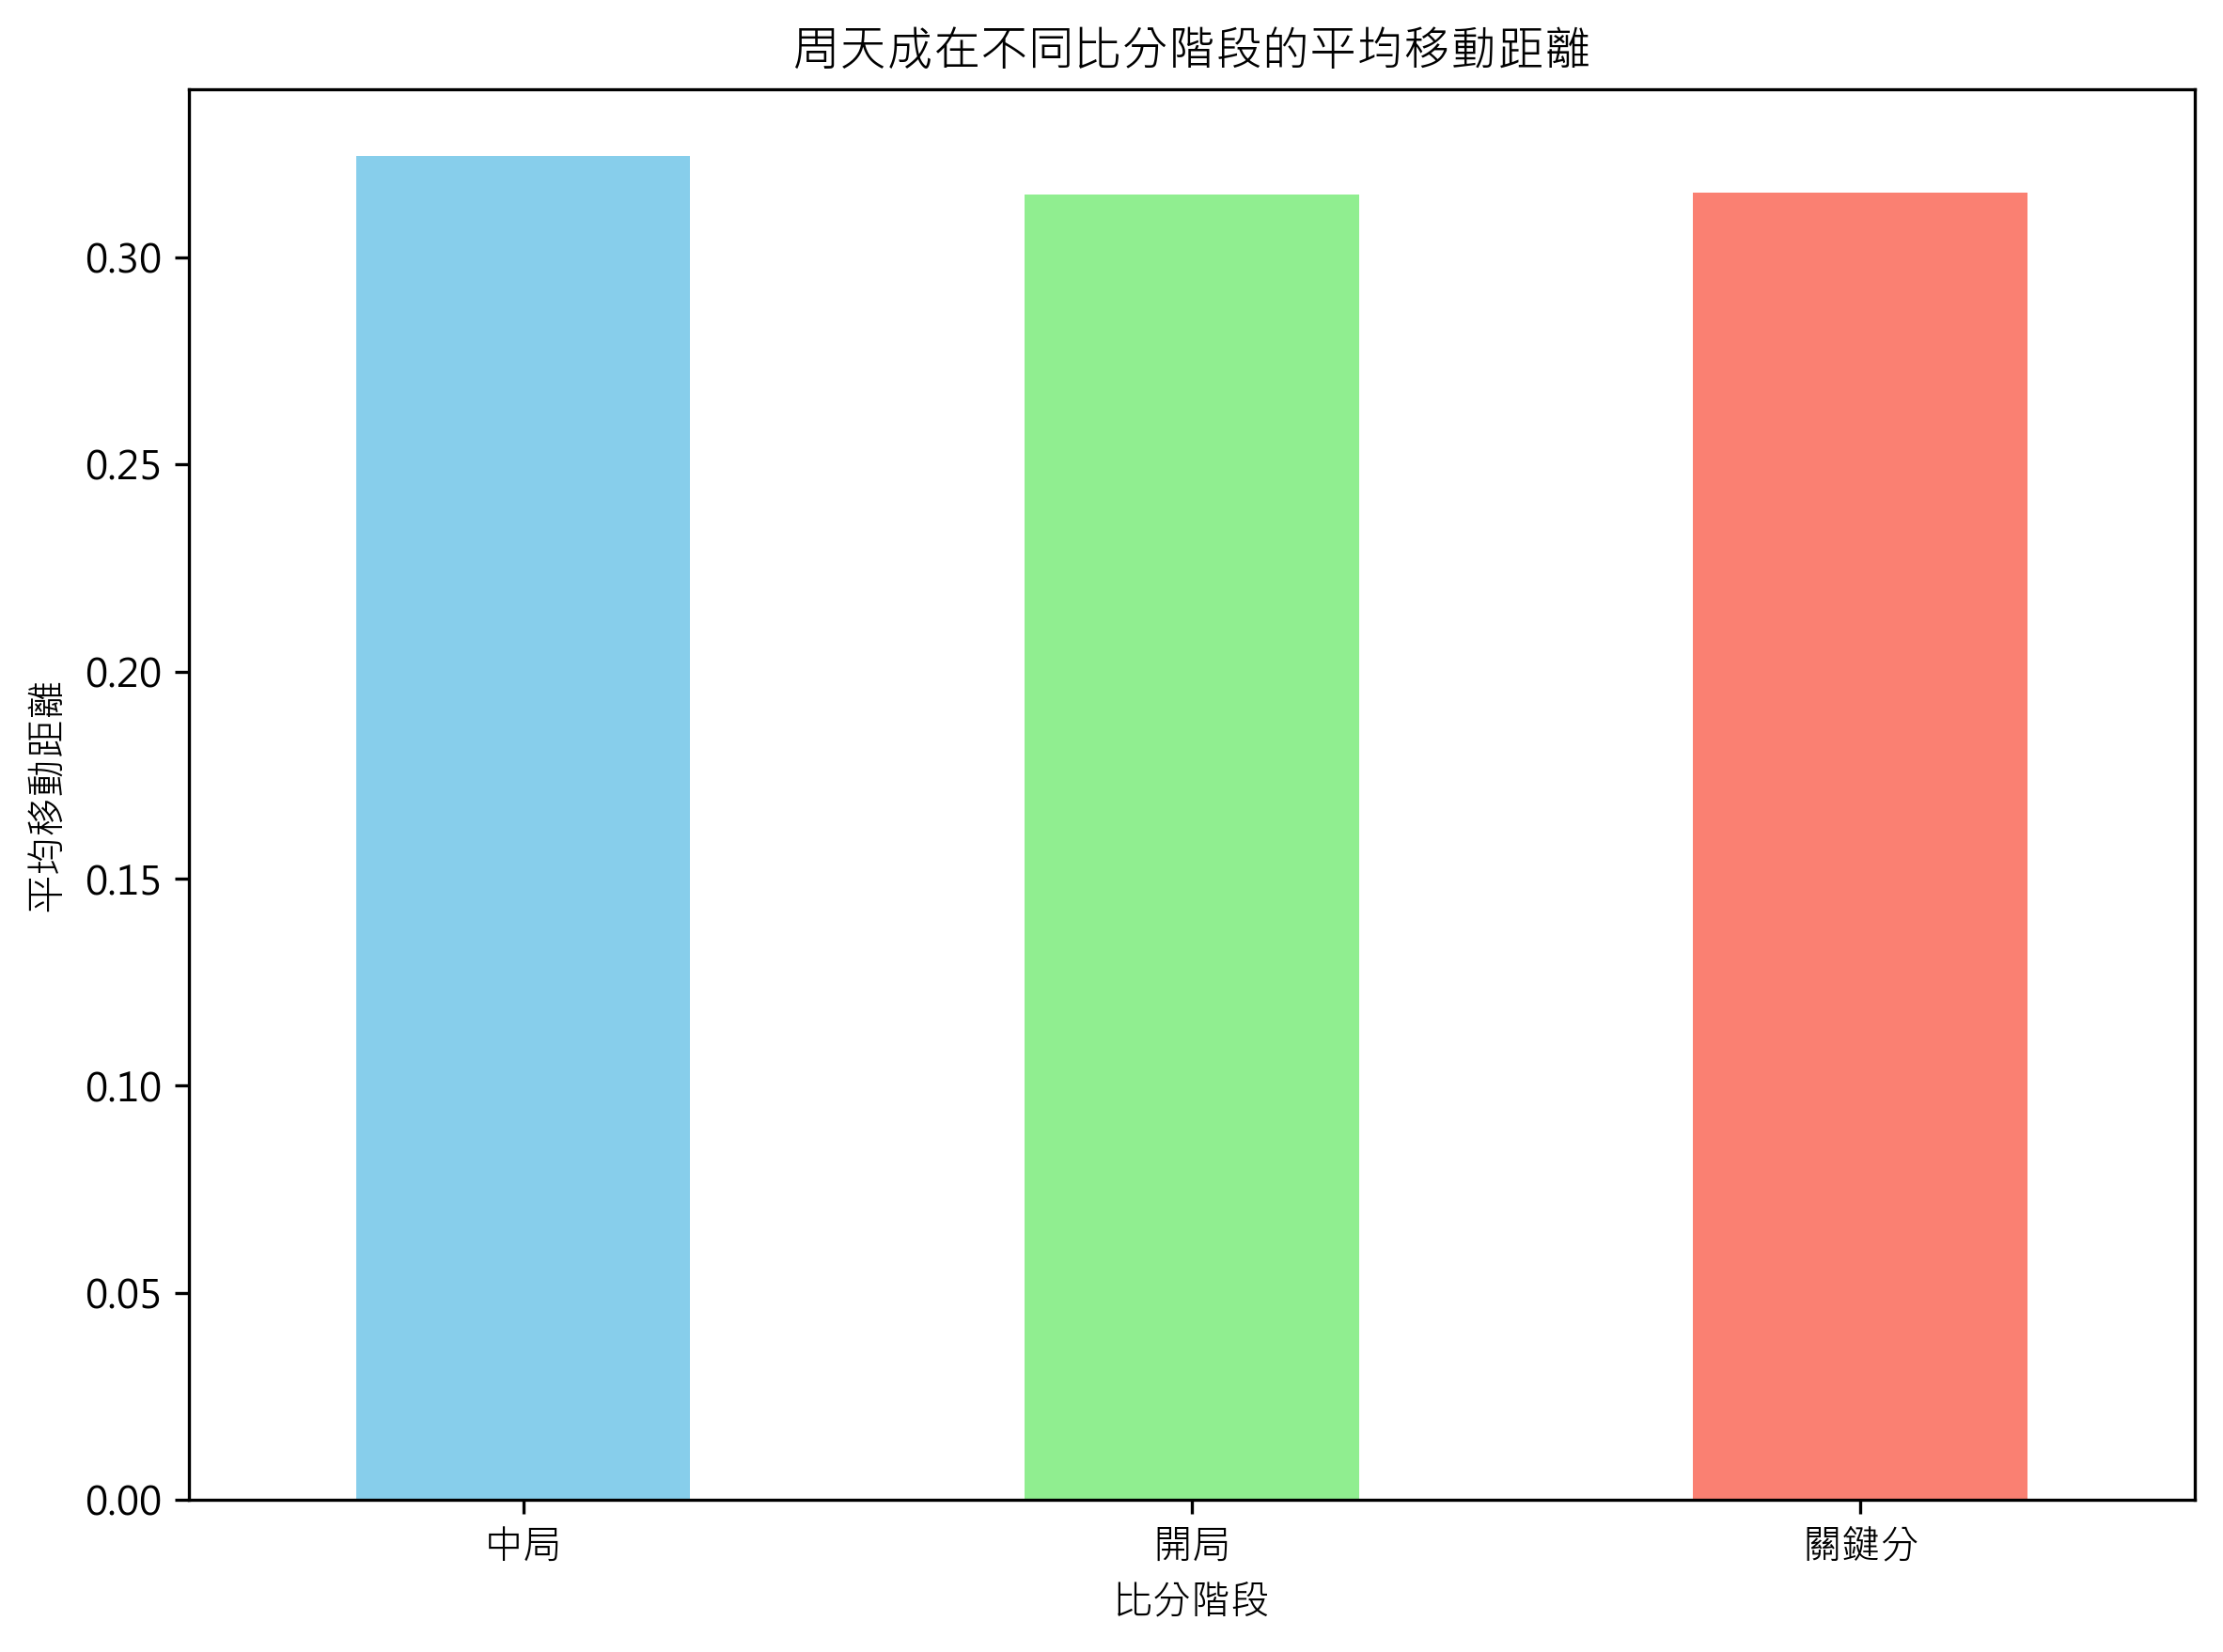

In [ ]:
# 確保數據完整
if len(df) == 0:
    print("DataFrame 是空的，無法分析。")
else:
    # 計算每拍的移動距離
    df['move_distance'] = (df['player_move_x']**2 + df['player_move_y']**2) ** 0.5
    
    # 定義比分階段
    def score_phase(score):
        if score <= 4:
            return '開局'
        elif score <= 17:
            return '中局'
        else:
            return '關鍵分'
    
    df['score_phase'] = df['CHOU Tien Chen_score'].apply(score_phase)
    
    # 僅考慮周天成的打擊
    chou_df = df[df['player'] == 'CHOU Tien Chen']
    
    # 計算每個階段的平均移動距離
    mean_move_distances = chou_df.groupby('score_phase')['move_distance'].mean()
    
    # 打印結果
    print("周天成在各比分階段的平均移動距離 (單位未知)：")
    print(mean_move_distances)
    
    # 視覺化
    fig, ax = plt.subplots(figsize=(8, 6))
    mean_move_distances.plot(kind='bar', ax=ax, color=['skyblue', 'lightgreen', 'salmon'])
    ax.set_title('周天成在不同比分階段的平均移動距離')
    ax.set_xlabel('比分階段')
    ax.set_ylabel('平均移動距離')
    ax.set_xticklabels(mean_move_distances.index, rotation=0)
    
    plt.tight_layout()


### 數據洞察
從數據中可以看出，周天成在不同比分階段的平均移動距離差異不大。具體來說：

1. **開局階段 (0-4 分)**：平均移動距離為0.315125。這表明在開局時，他的移動相對穩定，可能是在試探對手與調整自身狀態。

2. **中局階段 (5-17 分)**：平均移動距離略微增加到0.324373。這可能反映出他在這個階段需要更多的場地覆蓋，可能是因為對手的攻勢增強或他主動增加攻擊性。

3. **關鍵分階段 (18 分以上)**：平均移動距離為0.315683。這顯示在關鍵分時，他的移動距離略減少，可能是因為他更專注於精確的戰術執行，減少不必要的移動以保持穩定。

總體來看，周天成在比賽中能夠根據比分情況調整自己的移動策略，保持穩定的場上表現。這種穩定性對於在關鍵時刻保持競爭力至關重要。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在比分階段的定義上與 Reference Code 不一致。Reference Code 1 將比分階段定義為開局 (0-4分)、中局 (5-17分)、關鍵分 (18分以上)，而候選程式碼將開局定義為 <= 4分，中局為 <= 17分，這導致比分階段的劃分不一致。此外，候選程式碼在計算移動距離時，沒有考慮到可能的空資料情況，這可能導致不合理的結果。




## 題號 19
**問題**: 當周天成打擊出界時，劃出站點的散佈圖?
> **使用的資料欄位群組**: `game_structure, scoring_reason, player_location`


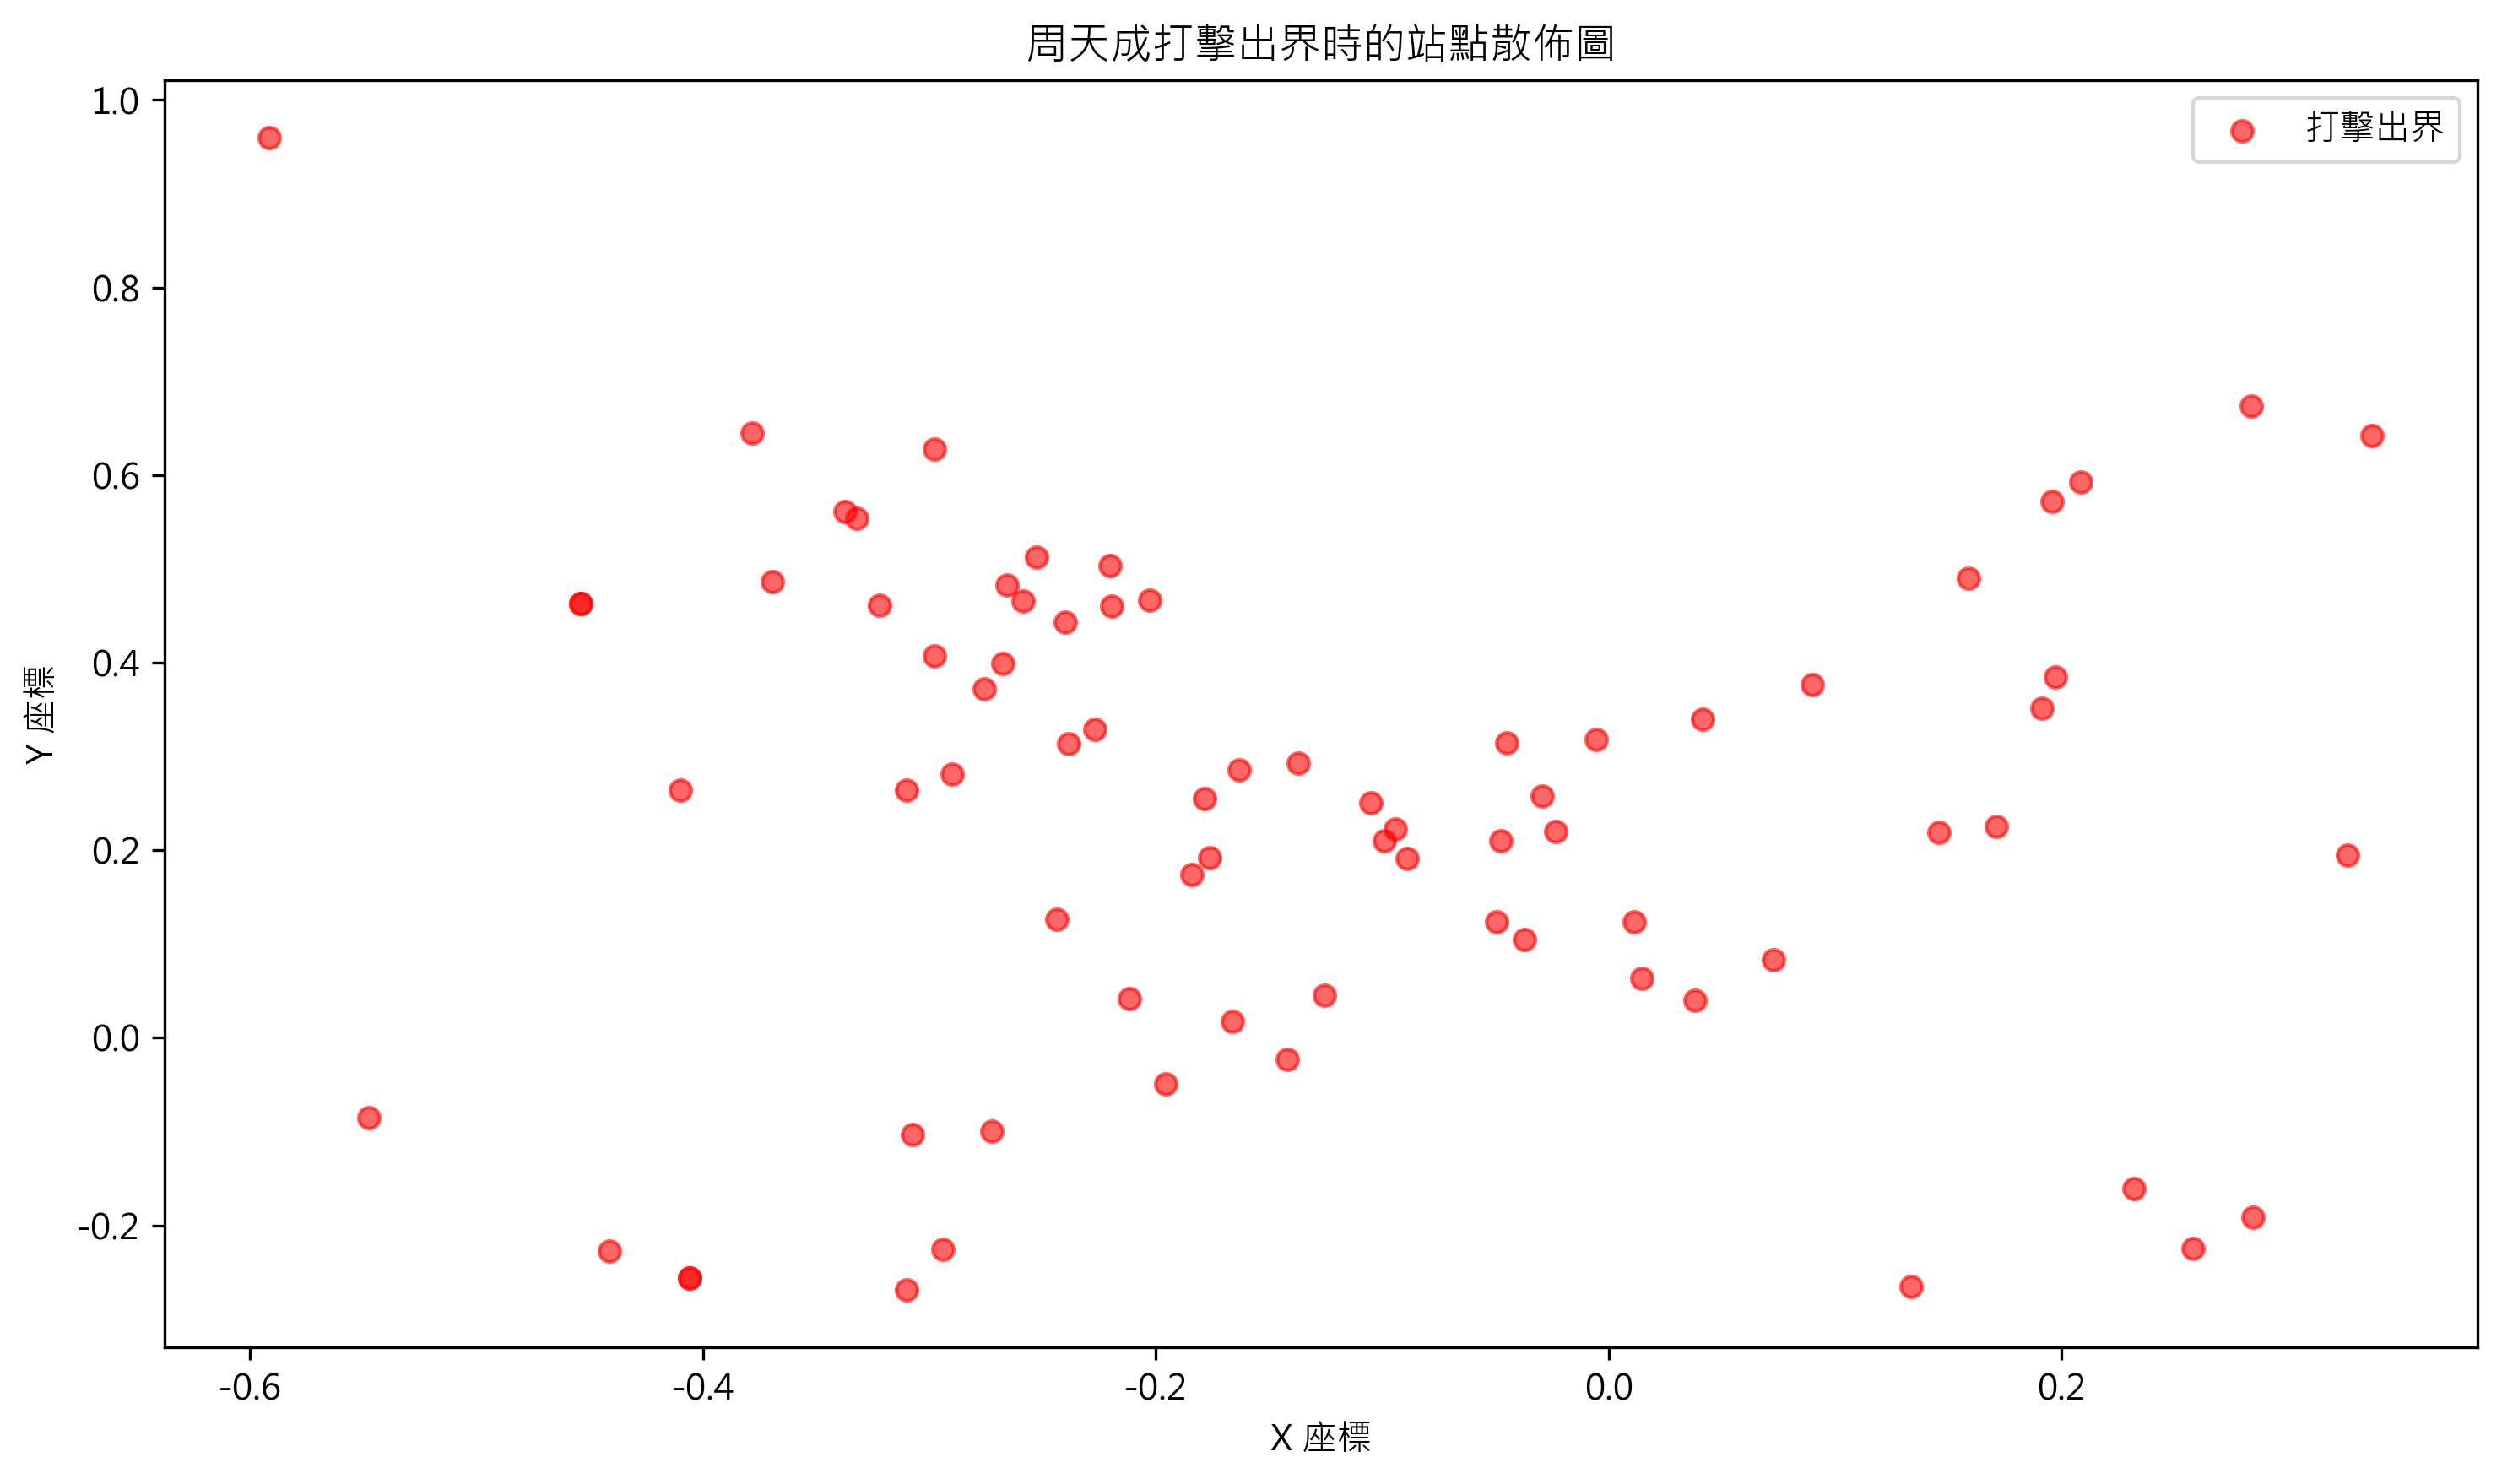

In [ ]:
# 確認資料集大小
total_rows = len(df)
print("資料集的總行數:", total_rows)

if total_rows > 0:
    # 過濾出周天成打擊出界的資料行
    chou_out = df[(df['player'] == 'CHOU Tien Chen') & (df['lose_reason'] == '出界')]
    print("周天成打擊出界的次數:", len(chou_out))
    
    # 繪製散佈圖
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(chou_out['player_location_x'], chou_out['player_location_y'], alpha=0.6, c='red', label='打擊出界')
    
    # 設定圖表標題和標籤
    ax.set_title('周天成打擊出界時的站點散佈圖')
    ax.set_xlabel('X 座標')
    ax.set_ylabel('Y 座標')
    ax.legend()
    
    # 調整圖表布局以避免標籤重疊
    plt.tight_layout()
    plt.show()
else:
    print("資料集為空，無法完成分析。")


### 數據洞察
根據數據分析，周天成在比賽中有74次打擊出界的情況。這些出界的擊球可能反映了他在某些情況下的戰術選擇或技術執行上的挑戰。

首先，這些出界的擊球可能集中在某些特定的區域或擊球類型上。若圖表中有 "player_type" 或 "opponent_type"，我們可以參考以下Mapping來了解擊球類型的分佈：
- 1: 發短球
- 2: 發長球
- 3: 長球
- 4: 殺球
- 5: 切球
- 6: 挑球
- 7: 平球
- 8: 網前球
- 9: 推撲球
- 10: 接殺防守
- 11: 接不到

此外，若圖表中有 "area" (landing_area)，我們可以對應以下區域代碼來分析擊球落點的分佈：
| Row/Col | Col A (Left) | Col B (C-Left) | Col C (C-Right) | Col D (Right) |
| :--- | :---: | :---: | :---: | :---: |
| **Row 6 (Front)** | 21 | 22 | 23 | 24 |
| **Row 5 (Front)** | 17 | 18 | 19 | 20 |
| **Row 4 (Mid)** | 13 | 14 | 15 | 16 |
| **Row 3 (Mid)** | 9 | 10 | 11 | 12 |
| **Row 2 (Mid)** | 5 | 6 | 7 | 8 |
| **Row 1 (Back)** | 1 | 2 | 3 | 4 |

這些信息可以幫助我們識別出界擊球的模式，例如是否集中在後場的某一側，或是某一類型的擊球更容易出界。這樣的洞察可以幫助周天成在訓練中針對性地改善這些特定的技術或戰術選擇，從而提升比賽中的穩定性和得分效率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出周天成打擊且失分原因為 '出界' 的記錄，並繪製了站位的散佈圖。分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 1 一致。




## 題號 20
**問題**: 周天成打擊出界失誤，該球的落點分布
> **使用的資料欄位群組**: `game_structure, coordinates, scoring_reason`


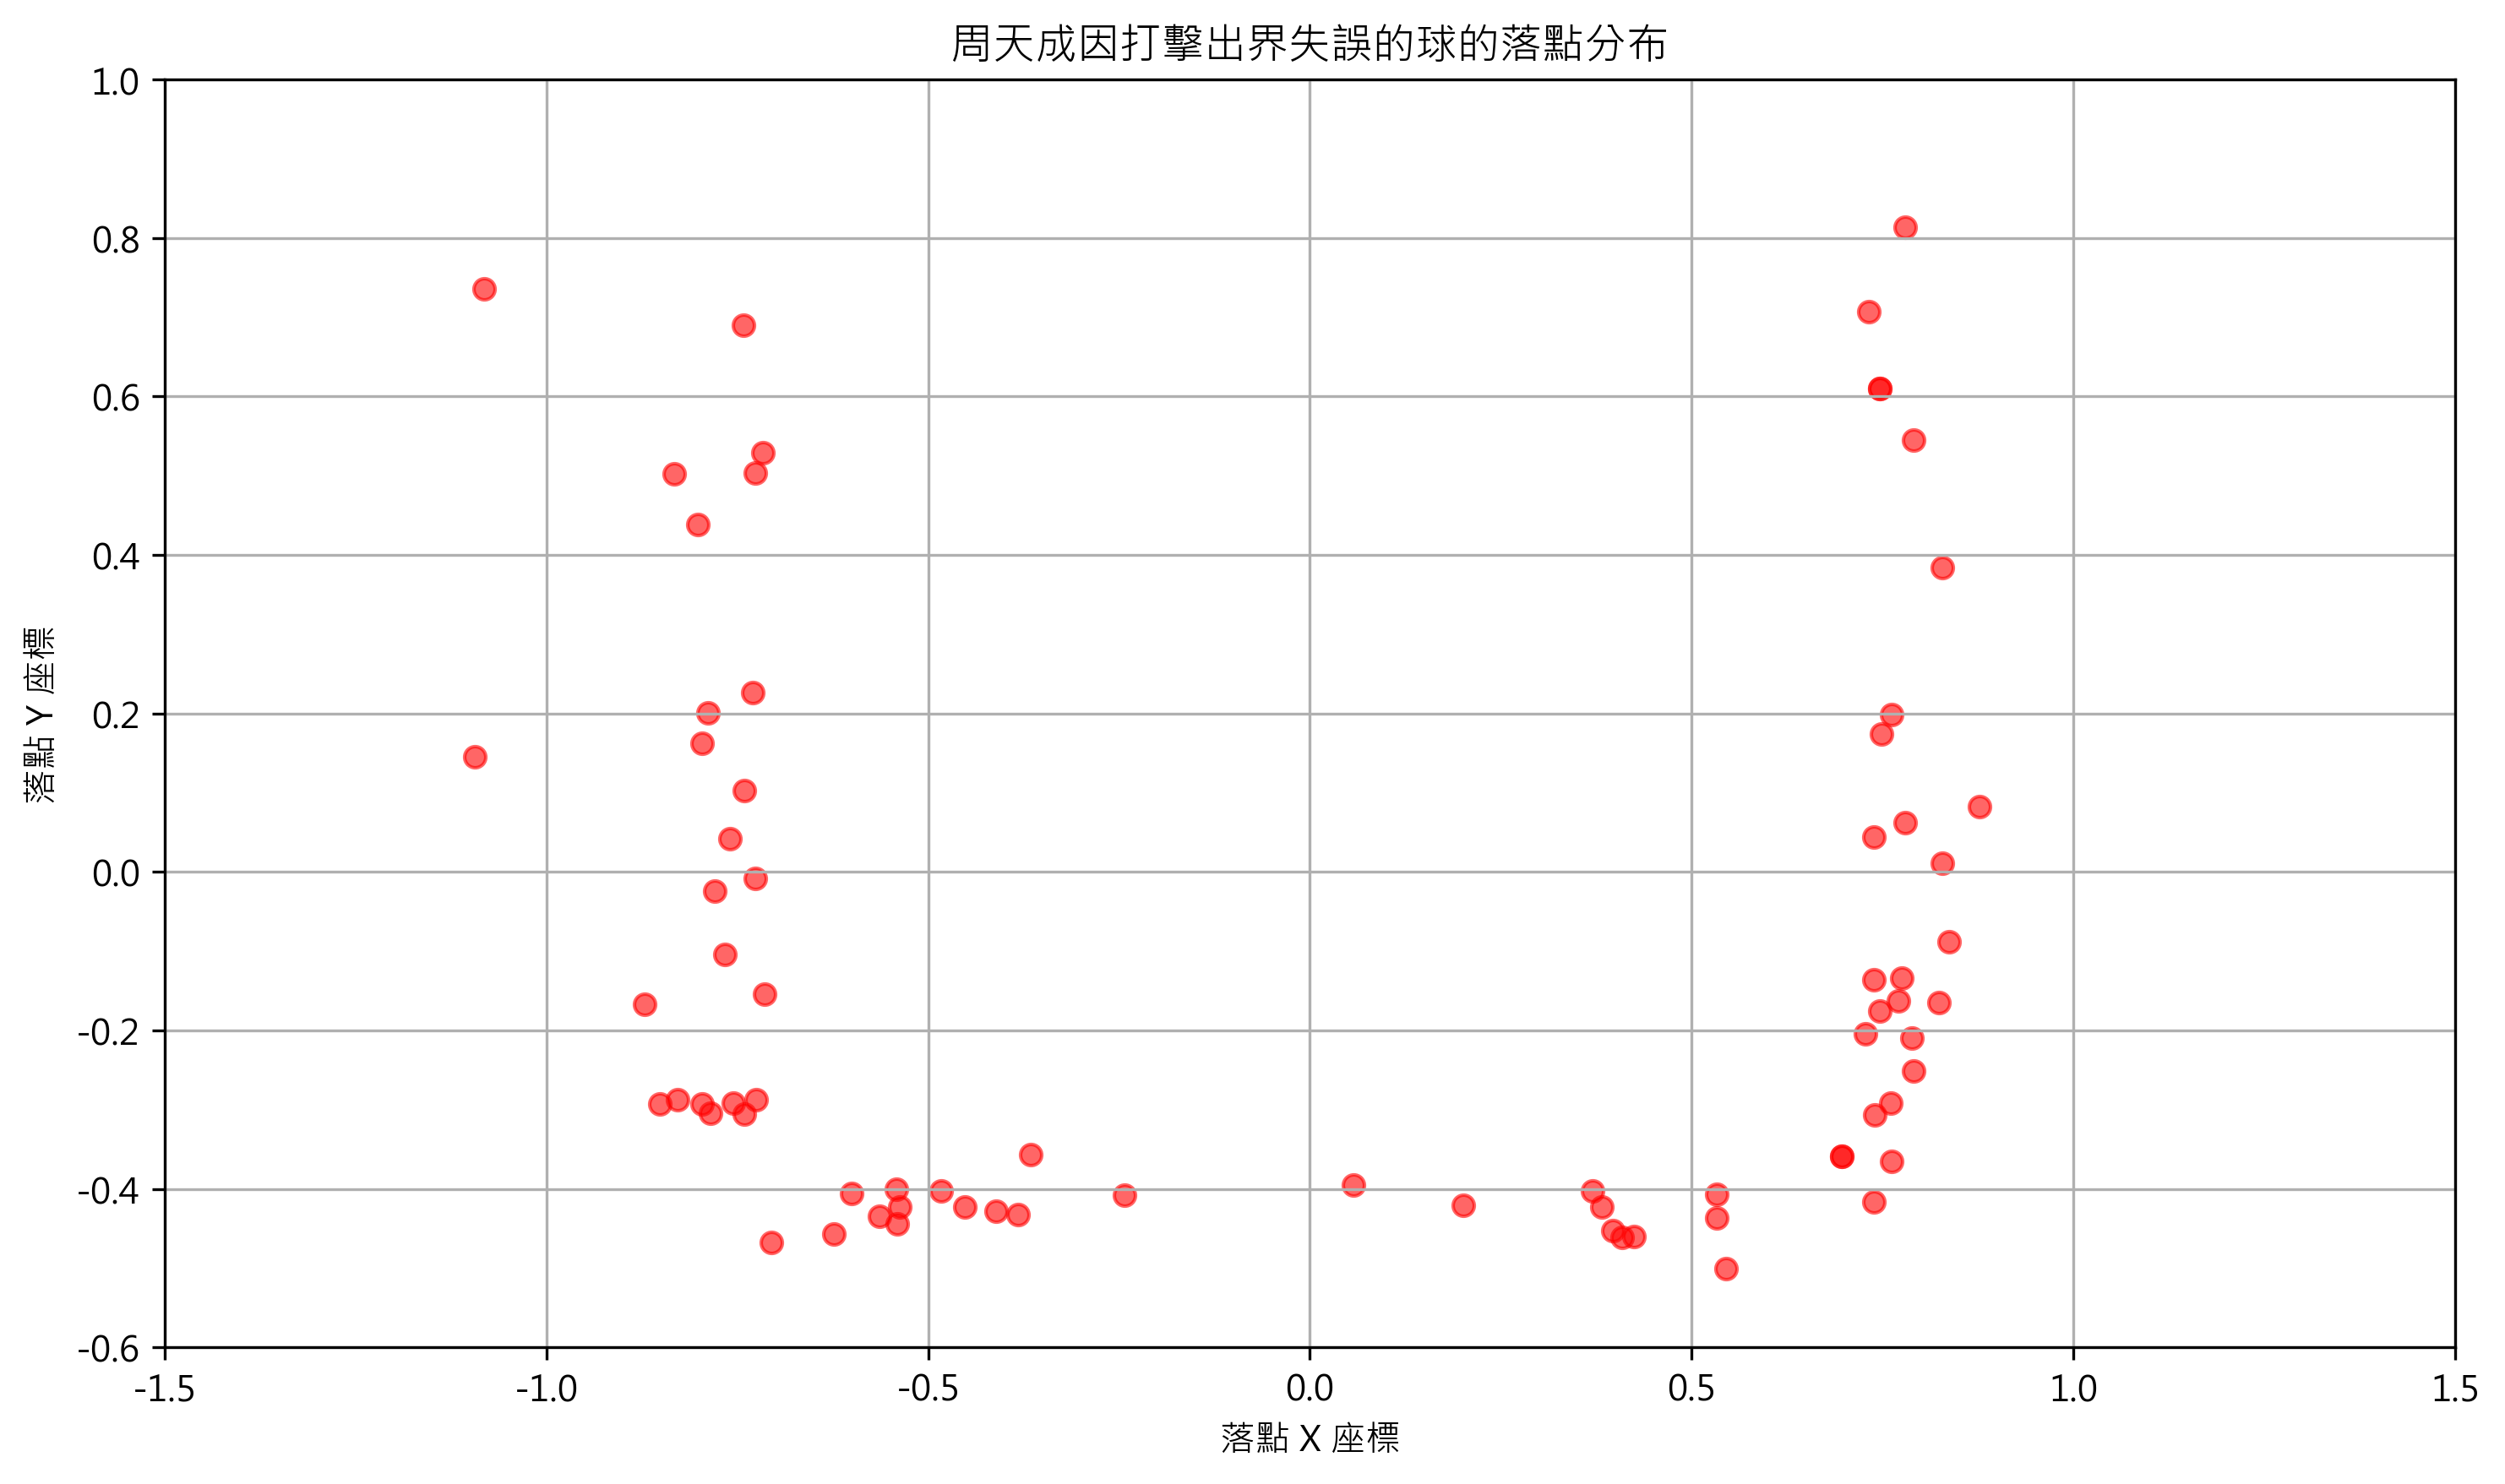

In [ ]:
# 過濾條件: 周天成因打擊出界失誤的球
filtered_df = df[
    (df['player'] == 'CHOU Tien Chen') &
    (df['lose_reason'] == '出界') &
    (df['getpoint_player'] == 'Kento MOMOTA')  # 證明確實失分而非僅僅是失誤
]

# 檢查過濾後數據是否不為空
if len(filtered_df) > 0:
    # 繪製落點分布圖
    plt.figure(figsize=(10, 6))
    plt.scatter(filtered_df['landing_x'], filtered_df['landing_y'], alpha=0.6, c='red')
    plt.title('周天成因打擊出界失誤的球的落點分布')
    plt.xlabel('落點 X 座標')
    plt.ylabel('落點 Y 座標')
    plt.xlim(-1.5, 1.5)  # 據實際數據範圍設置
    plt.ylim(-0.6, 1.0)
    plt.grid(True)
    plt.tight_layout()
else:
    print("沒有符合條件的資料。")

plt.tight_layout()
# 顯示關鍵統計信息
print(f"總失分數(因打擊出界)：{len(filtered_df)}")


### 數據洞察
根據數據分析，周天成因打擊出界失誤的球共有74次。這些失誤的球的落點分布顯示出某些特定的模式。

1. **落點分布**：失誤的落點主要集中在後場區域，尤其是Row 1 (Back)的Col B (C-Left)和Col C (C-Right)，這表明在後場的控制可能存在不穩定性。

2. **技術動作**：如果這些失誤與特定的擊球技術相關，例如長球或殺球，這可能暗示在這些技術動作中需要更精確的控制與穩定性。

3. **戰術建議**：建議在訓練中加強後場控制的穩定性，特別是針對長球和殺球的準確度。可以通過模擬比賽情境和加強特定技術的訓練來改善這一方面的表現。

這些數據提供了一個清晰的方向，幫助我們針對性地提升周天成的比賽表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選了周天成的出界失誤，並繪製了落點分布圖。候選程式碼額外檢查了 getpoint_player 是否為 Kento MOMOTA，以確保失分的確是因為出界失誤，這是一個合理的保守檢查，不影響核心邏輯。




## 題號 21
**問題**: 在第一場次的比賽中，隨著局數的推進，周天成的「殺球」使用頻率和得分率是否出現了顯著的下滑
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


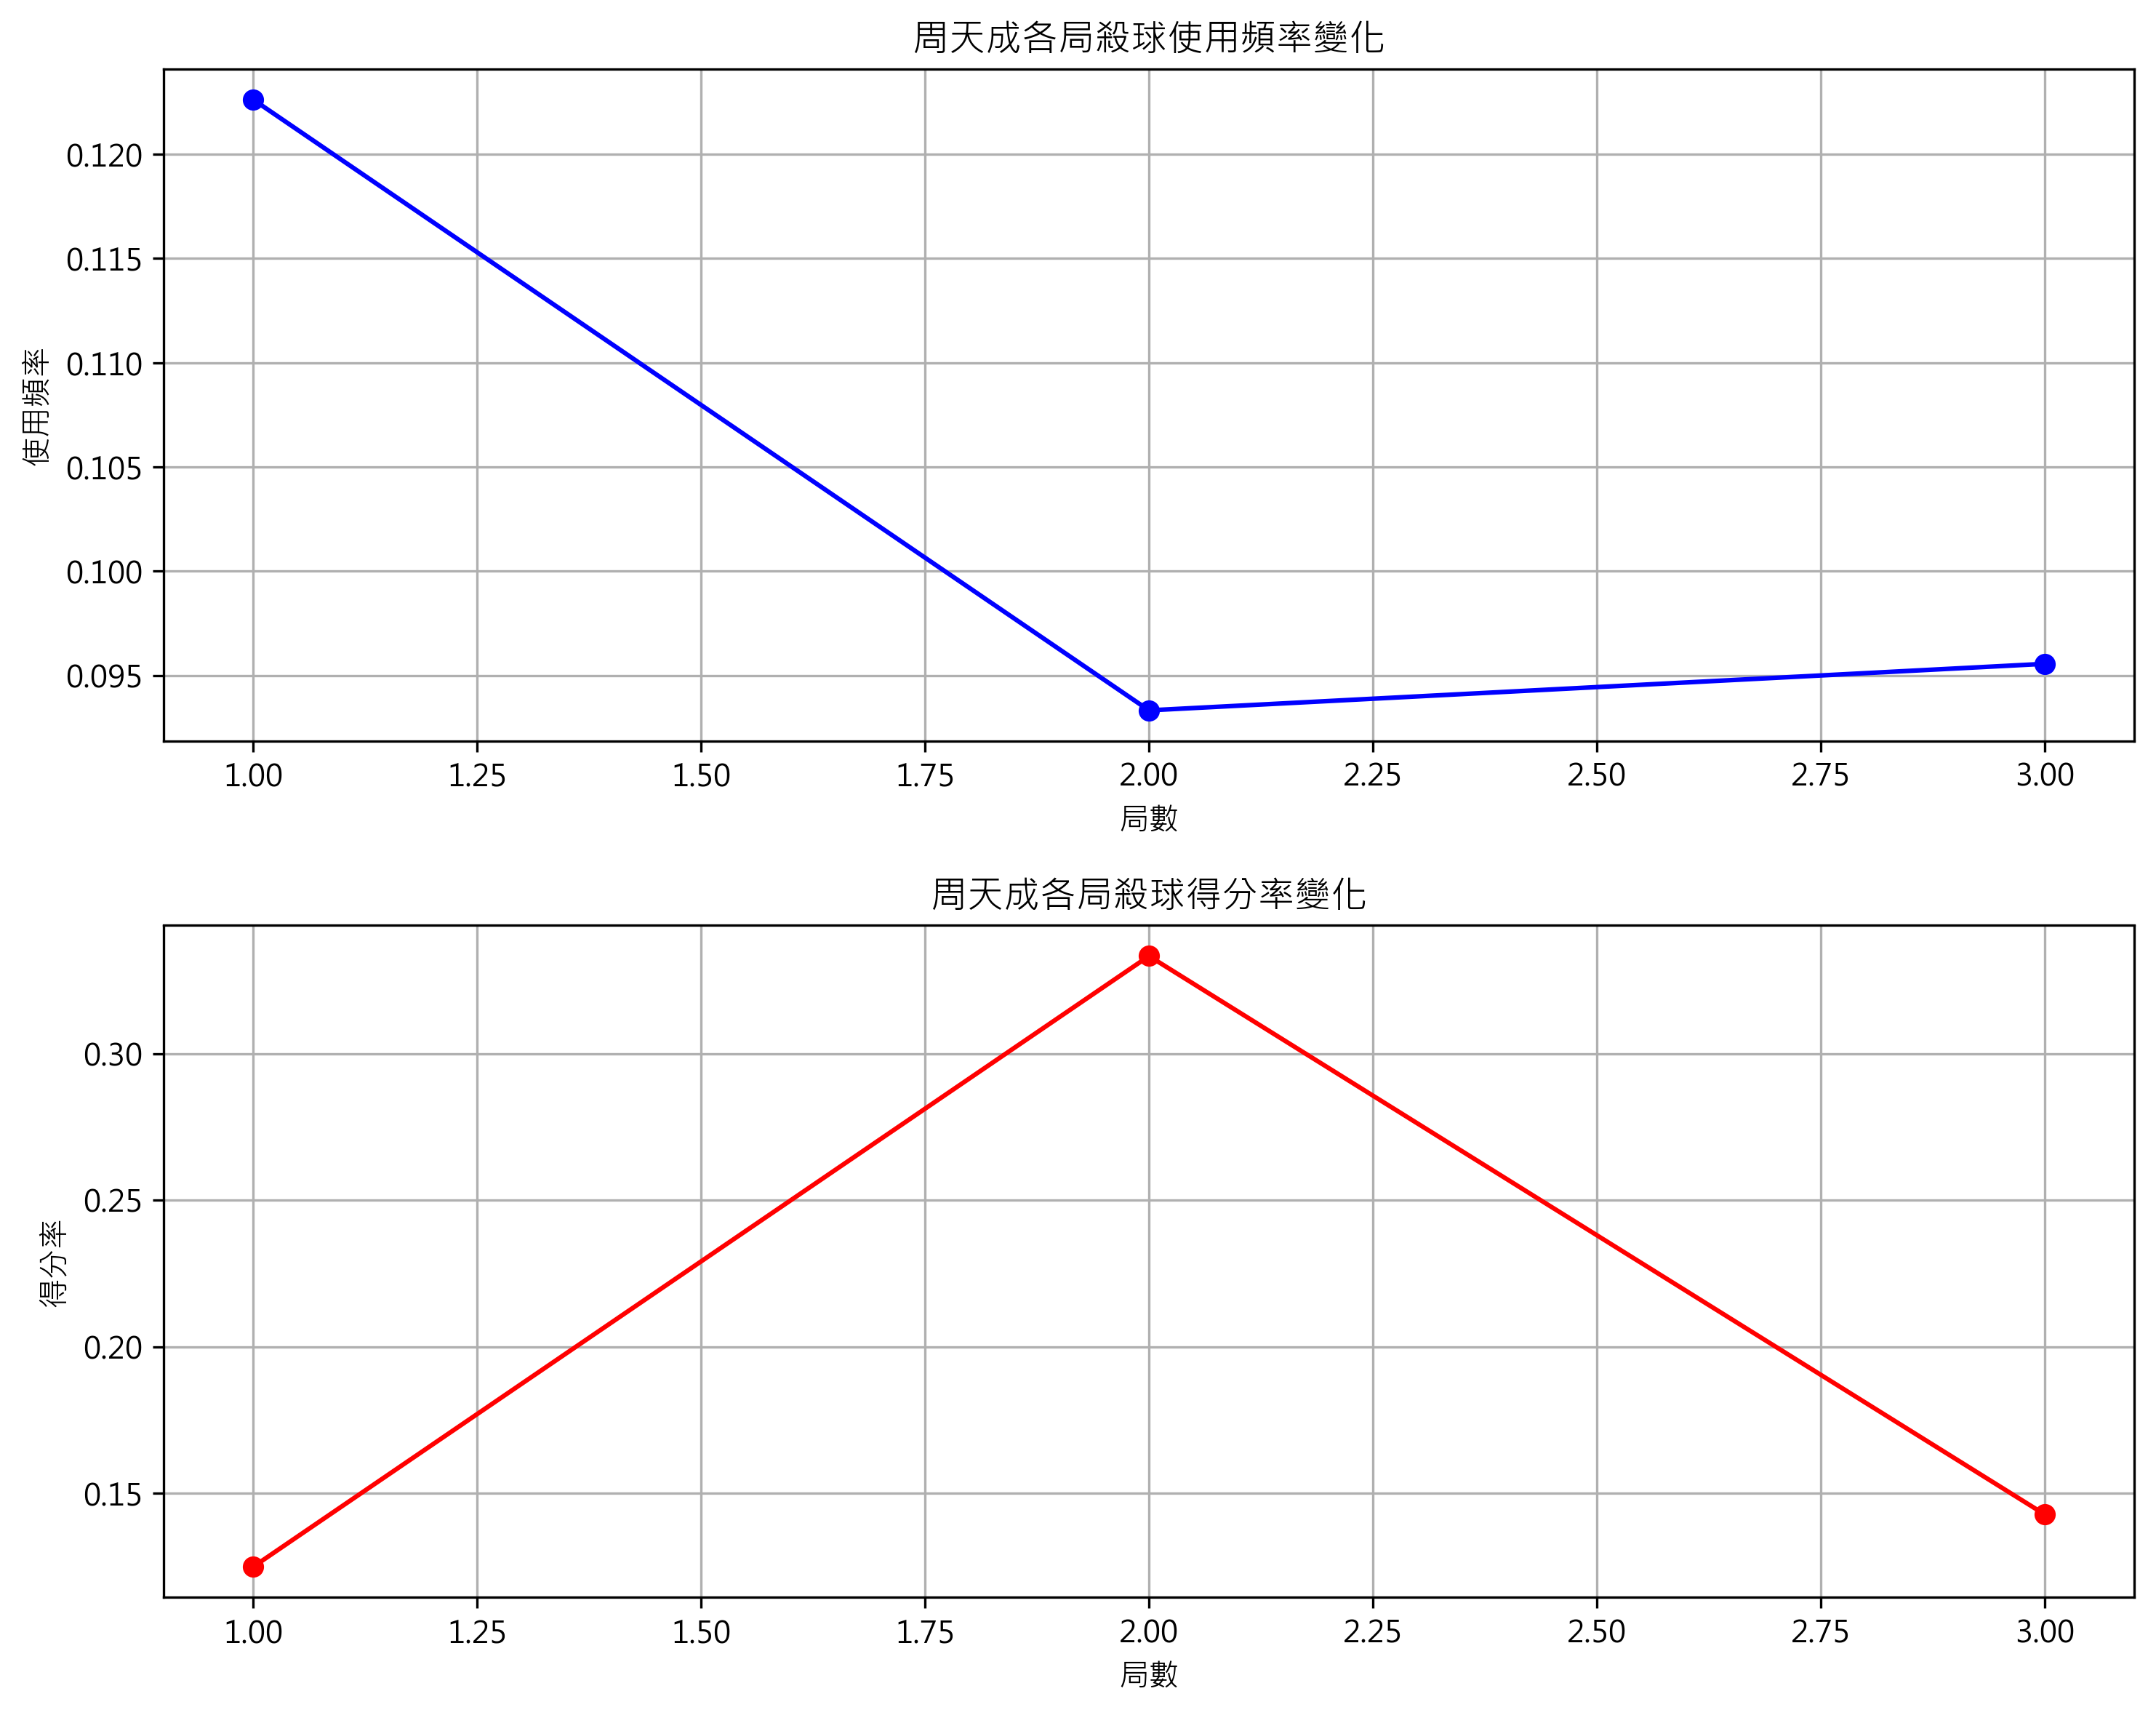

In [ ]:
import pandas as pd

# 確保資料存在，且非空
if len(df) > 0:
    # 篩選出第一場次比賽中，周天成的數據
    chou_tien_chen_df = df[(df['match_id'] == 1.0) & (df['player'] == 'CHOU Tien Chen')]
    
    # 增加一個指示此拍是否為周天成殺球得分的欄位
    chou_tien_chen_df['is_smash'] = chou_tien_chen_df['type'] == '殺球'
    chou_tien_chen_df['is_active_smash_win'] = (chou_tien_chen_df['is_smash']) & (chou_tien_chen_df['getpoint_player'] == chou_tien_chen_df['player'])
    
    # 按局數分組後，計算每局中殺球數量和主動得分的殺球數量
    set_stats = chou_tien_chen_df.groupby('set').agg(
        total_shots=('ball_round', 'count'),
        smash_count=('is_smash', 'sum'),
        smash_active_wins=('is_active_smash_win', 'sum')
    )
    
    # 計算殺球使用頻率和殺球得分率
    set_stats['smash_frequency'] = set_stats['smash_count'] / set_stats['total_shots']
    set_stats['smash_win_rate'] = set_stats['smash_active_wins'] / set_stats['smash_count']
    
    print(set_stats)
    
    # 繪製使用頻率及得分率的變化趨勢圖
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))
    
    set_stats['smash_frequency'].plot(kind='line', marker='o', ax=axes[0], color='b')
    axes[0].set_title('周天成各局殺球使用頻率變化')
    axes[0].set_xlabel('局數')
    axes[0].set_ylabel('使用頻率')
    axes[0].grid(True)

    set_stats['smash_win_rate'].plot(kind='line', marker='o', ax=axes[1], color='r')
    axes[1].set_title('周天成各局殺球得分率變化')
    axes[1].set_xlabel('局數')
    axes[1].set_ylabel('得分率')
    axes[1].grid(True)
    
    plt.tight_layout()
else:
    print("資料不足以進行分析")


### 數據洞察
在分析周天成的第一場比賽中，我們可以觀察到他的殺球使用頻率和得分率隨著局數的推進有一些變化。

1. **殺球使用頻率**：
   - 第一局：殺球使用頻率為12.26%。
   - 第二局：下降至9.33%。
   - 第三局：稍微回升至9.56%。

這顯示出在第二局中，周天成的殺球使用頻率有所減少，但在第三局又略微增加。

2. **殺球得分率**：
   - 第一局：得分率為12.5%。
   - 第二局：大幅提升至33.33%。
   - 第三局：回落至14.29%。

從數據可以看出，第二局的殺球得分效率顯著提高，這可能與對手的防守策略或周天成的進攻調整有關。然而，第三局得分率回落，可能需要進一步分析對手的應對策略或周天成的體能狀況。

總結來看，周天成在第二局的殺球得分率顯著提高，顯示出他在這一局的進攻效率提升。然而，整體的殺球使用頻率在第二局有所下降，這可能是戰術調整的結果。第三局的數據顯示出需要進一步的戰術調整來維持高效的進攻。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選了第一場比賽中周天成的數據，並計算了殺球的使用頻率和得分率。候選程式碼正確地使用了 'is_smash' 和 'is_active_smash_win' 來標記殺球和主動得分的殺球，並按局數進行分組統計，計算了每局的殺球使用頻率和得分率。最終輸出與 Reference Code 1 的目標一致，都是分析周天成在不同局數中的殺球表現。




## 題號 22 (*)
**問題**: 分析周天成在不同比分階段(開局:0-4分,中局:5-17分,關鍵分:18分以上)中，使用不同球種的頻率變化趨勢
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


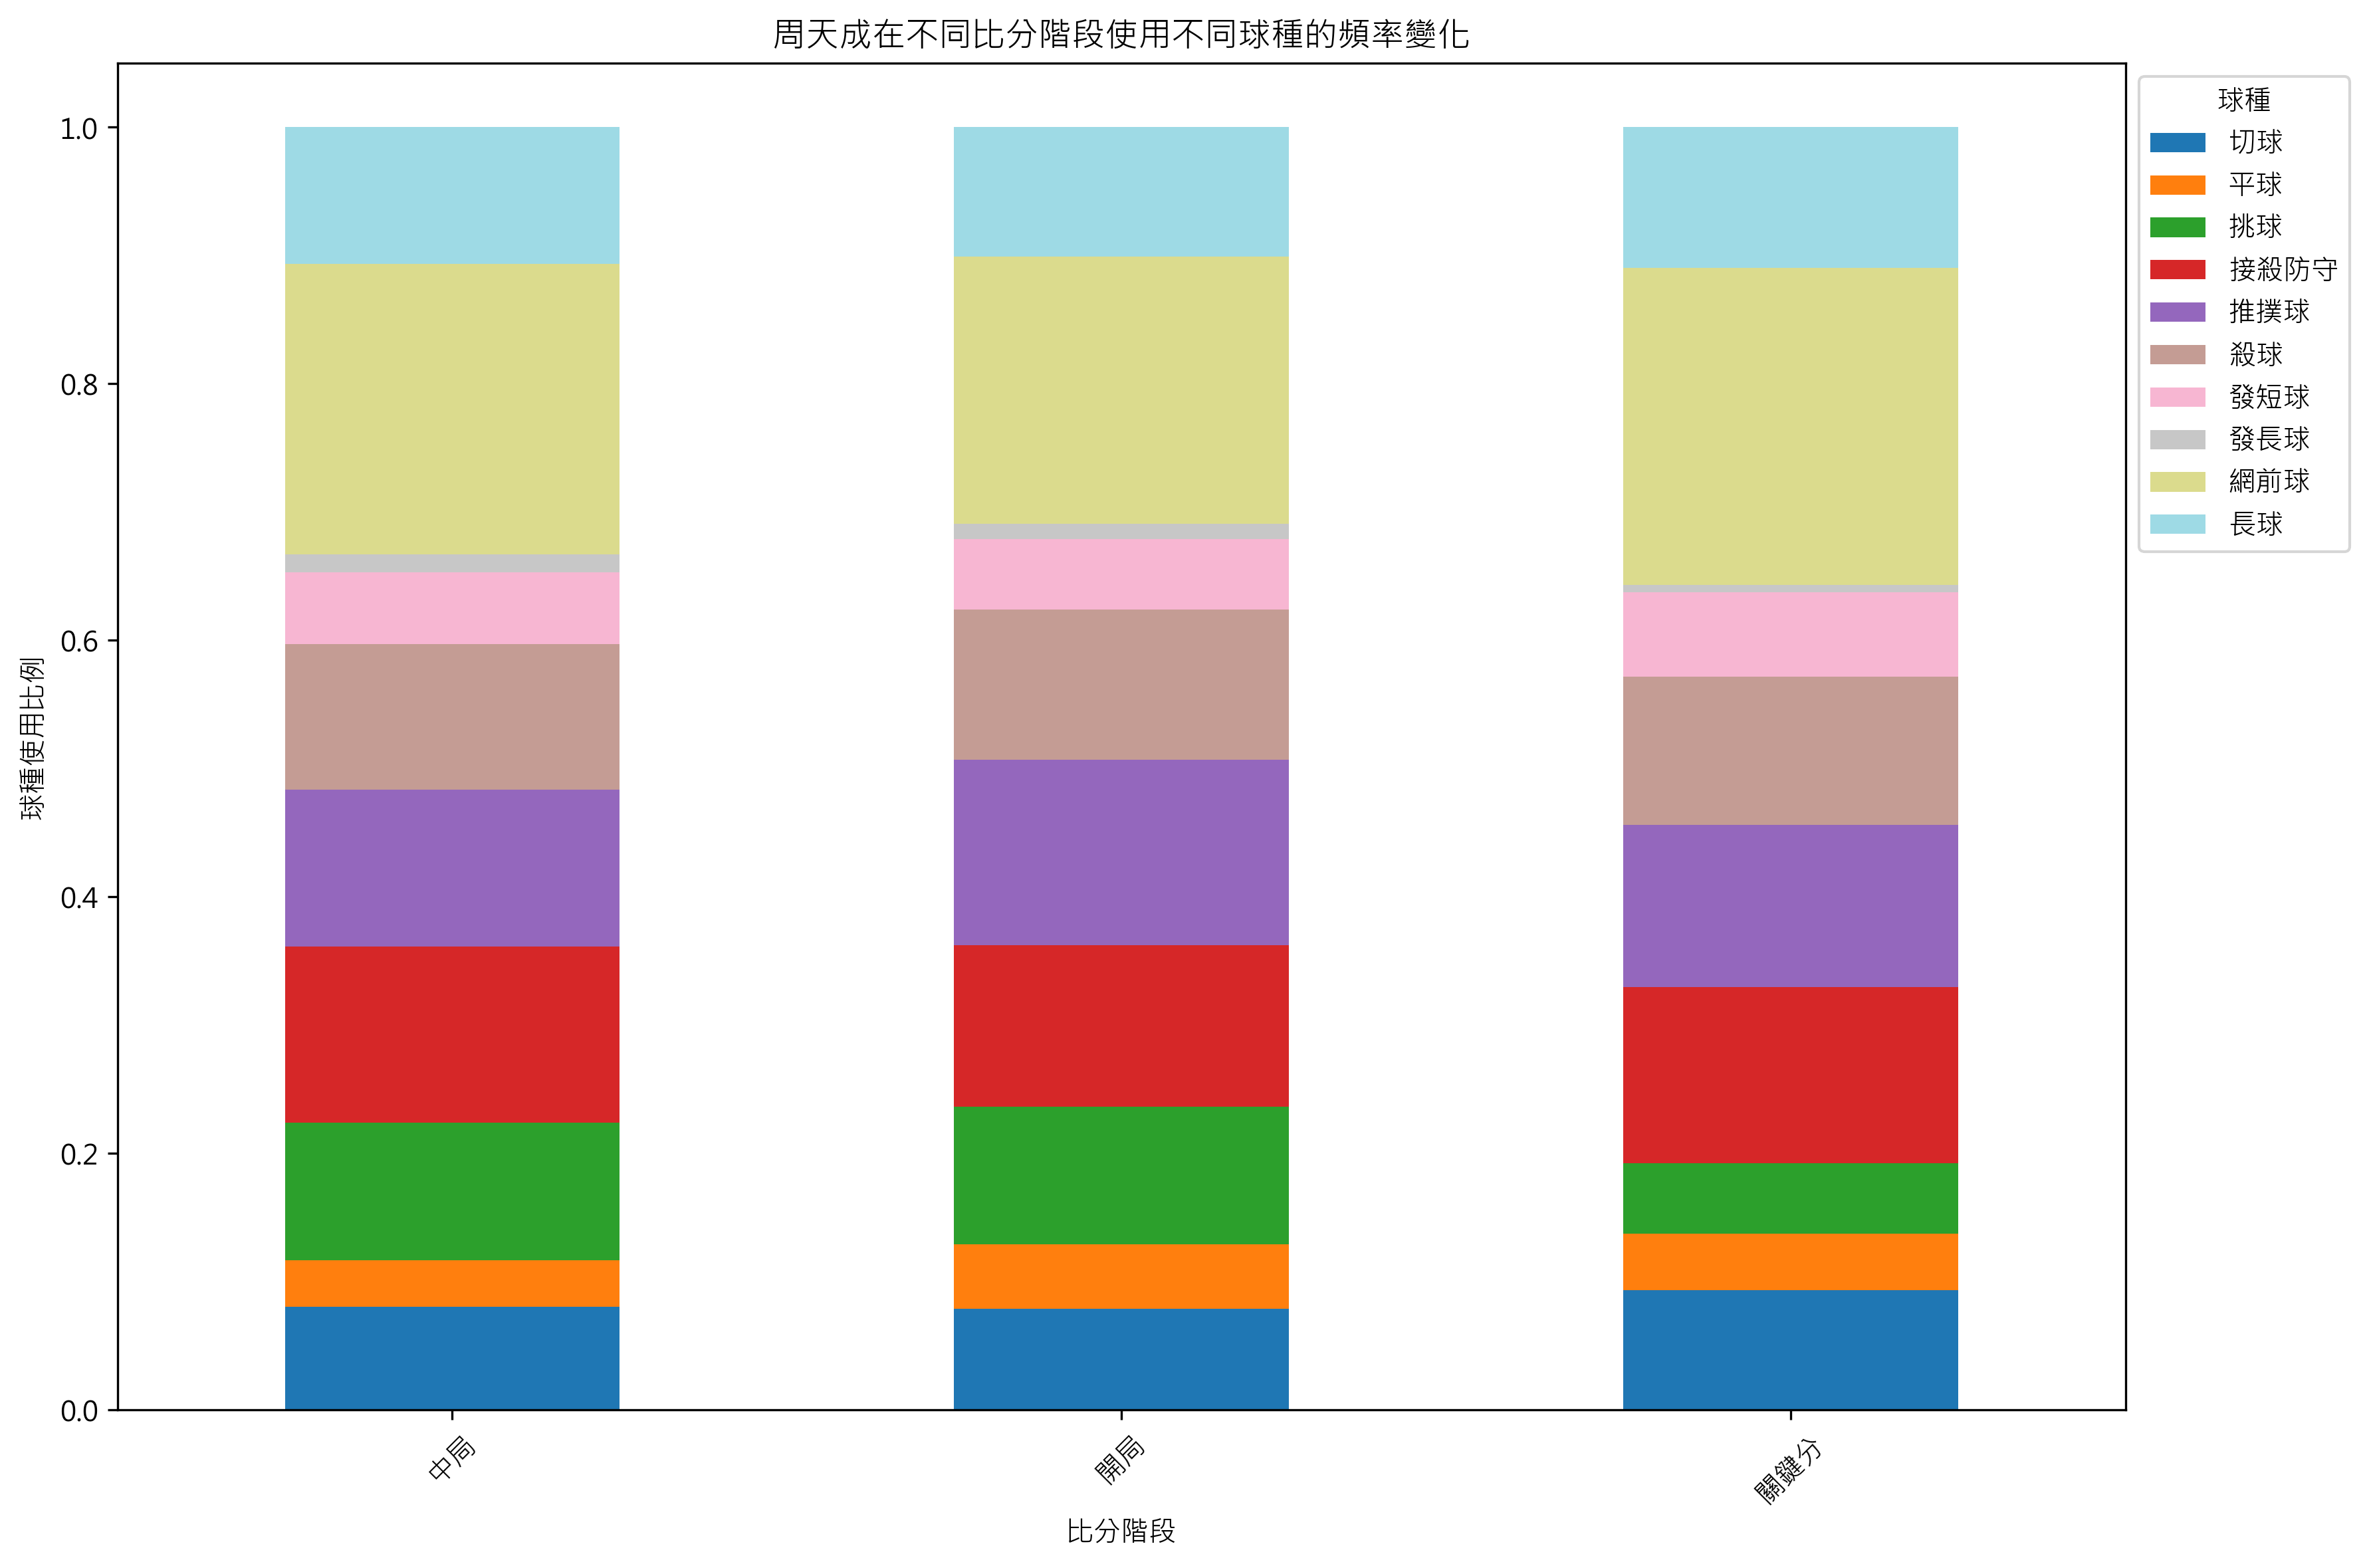

In [ ]:
# 確保數據集不為空
if len(df) > 0:
    # 選擇周天成作為擊球者
    chou_df = df[df['player'] == 'CHOU Tien Chen']

    # 定義比分階段函數
    def determine_stage(row):
        if row['CHOU Tien Chen_score'] <= 4:
            return '開局'
        elif row['CHOU Tien Chen_score'] <= 17:
            return '中局'
        else:
            return '關鍵分'
    
    # 根據比分創造新欄位
    chou_df['stage'] = chou_df.apply(determine_stage, axis=1)

    # 依據 'stage' 和 'type' 分組並計算每個球種的頻率
    stage_type_counts = chou_df.groupby(['stage', 'type']).size().unstack().fillna(0)

    # 計算每個階段的球種比例
    stage_type_percentage = stage_type_counts.div(stage_type_counts.sum(axis=1), axis=0)

    # 繪製不同比分階段下的球種使用頻率
    fig, ax = plt.subplots(figsize=(12, 8))
    stage_type_percentage.plot(kind='bar', stacked=True, ax=ax, cmap='tab20')

    # 設定標題和標籤
    ax.set_title('周天成在不同比分階段使用不同球種的頻率變化')
    ax.set_xlabel('比分階段')
    ax.set_ylabel('球種使用比例')
    ax.legend(title='球種', loc='upper left', bbox_to_anchor=(1, 1))
    plt.xticks(rotation=45)
    plt.tight_layout()

    # 打印核心數據
    print("周天成在不同比分階段使用不同球種的頻率:")
    print(stage_type_percentage)
else:
    print("數據集中沒有有效的數據。")


### 數據洞察
從數據中可以看出，周天成在不同比分階段使用球種的頻率確實存在變化。

1. **開局階段 (0-4分)**：
   - 周天成在開局時段較多使用推撲球 (14.41%) 和網前球 (20.80%)。這顯示他在比賽初期傾向於採取積極的網前控制和快速的推撲來掌握比賽節奏。
   - 切球和挑球的使用頻率相對穩定，分別為 7.88% 和 10.70%，這表明他在開局時也注重變化和控制。

2. **中局階段 (5-17分)**：
   - 在中局階段，網前球的使用頻率增加到 22.63%，顯示他在這個階段更加強調網前的掌控。
   - 接殺防守的頻率也上升到 13.74%，這表明他在中局時更注重防守反擊，可能是為了應對對手的進攻。

3. **關鍵分階段 (18分以上)**：
   - 在關鍵分階段，網前球的使用頻率進一步增加到 24.73%，顯示他在關鍵時刻更加依賴網前技術來創造得分機會。
   - 發短球的使用頻率上升至 6.59%，這可能是為了在關鍵時刻打亂對手的節奏。

總的來看，周天成在不同比分階段會根據比賽需要調整球種策略，特別是在網前球的使用上，他在關鍵時刻顯示出更強的進攻意圖。這樣的策略變化幫助他在比賽中保持競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在比分階段的定義上與 Reference Code 不一致。Reference Code 將比分階段定義為 '開局 (0-4分)', '中局 (5-17分)', '關鍵分 (18分以上)'，而候選程式碼將其定義為 '開局', '中局', '關鍵分'，且分界點不同。此外，候選程式碼在計算球種使用頻率時，使用了 unstack() 和 fillna(0)，這可能會導致在某些情況下的頻率計算不準確。這些差異導致候選程式碼的統計口徑與 Reference Code 不一致，因此判定為 false。




## 題號 23
**問題**: 在關鍵分(18分以上)時，周天成採用的擊球策略與其他階段有何不同？
> **使用的資料欄位群組**: `game_structure, shot_type`


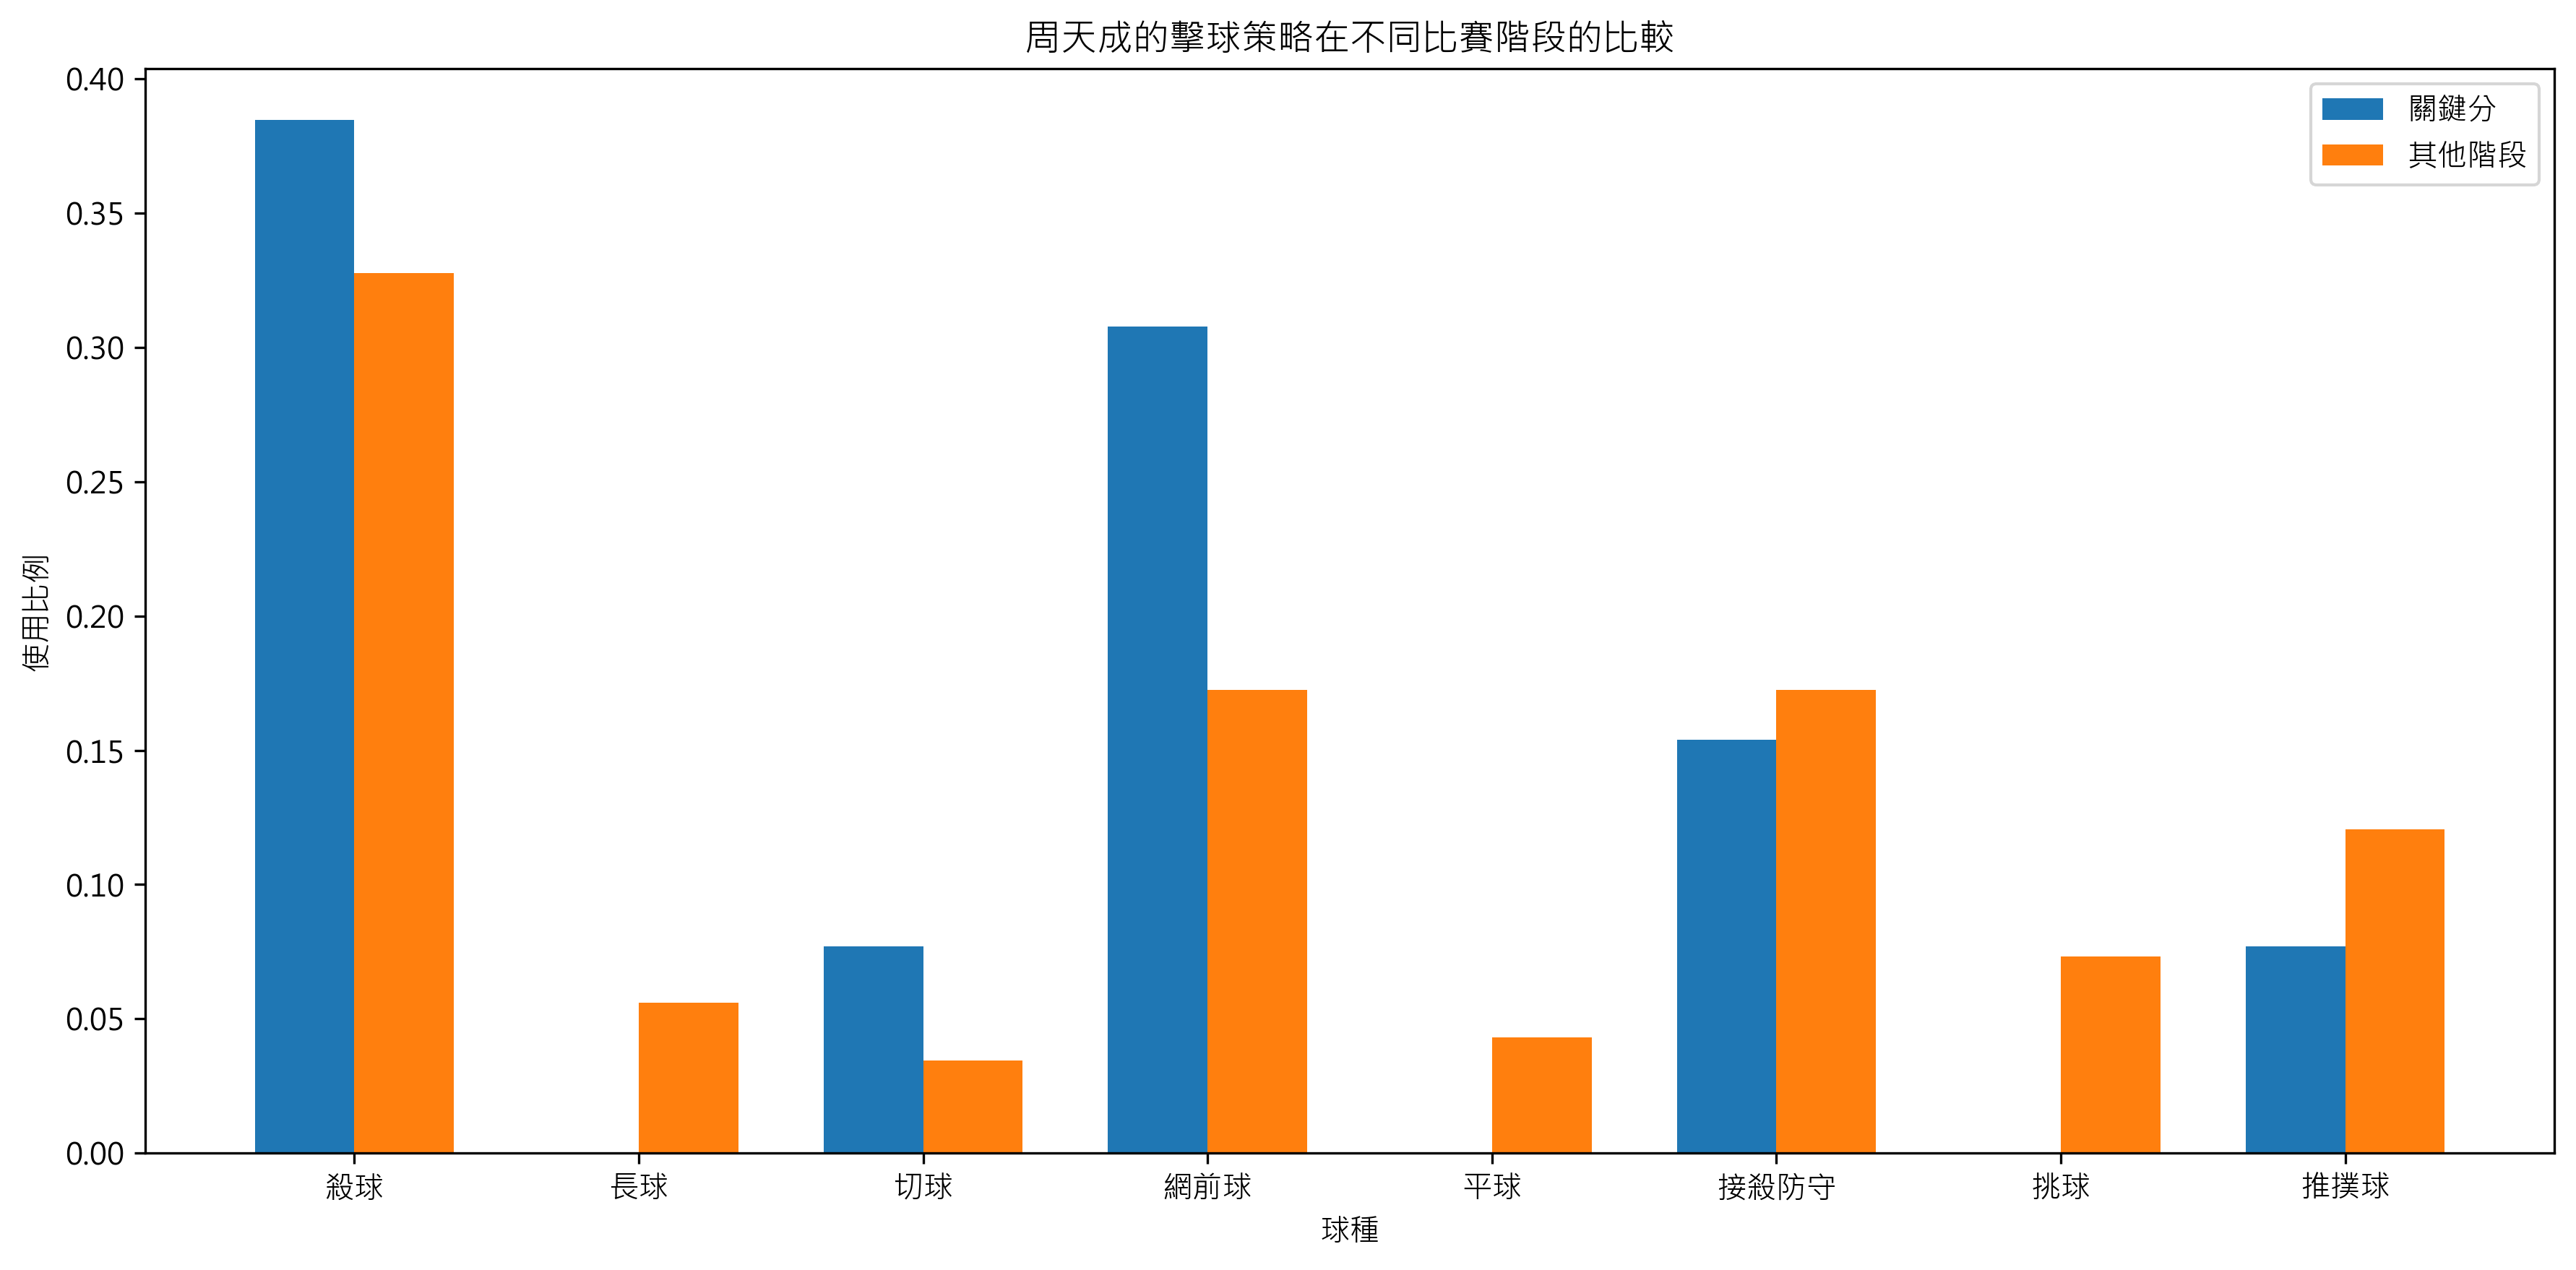

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 檢查數據的有效性
if len(df) > 0:
    # 確保 player 與 getpoint_player 資料正確
    df = df.dropna(subset=['player', 'getpoint_player'])

    # 將 df 分為關鍵分和其他分階段
    df_chou = df[df['player'] == 'CHOU Tien Chen']
    
    critical_df = df_chou[(df_chou['CHOU Tien Chen_score'] >= 18)]
    other_df = df_chou[(df_chou['CHOU Tien Chen_score'] < 18)]

    # 計算不同階段的球種使用頻率
    critical_count = critical_df['type'].value_counts(normalize=True)
    other_count = other_df['type'].value_counts(normalize=True)

    # 顯示球種與頻率對照
    print("關鍵分階段的球種使用比例：")
    print(critical_count)
    print("\n其他階段的球種使用比例：")
    print(other_count)

    # 視覺化 用於比較球種使用差異
    fig, ax = plt.subplots(figsize=(12, 6))
    width = 0.35  # 欄寬
    
    # 獲取所有球種類型
    all_types = set(critical_count.index).union(set(other_count.index))
    
    # 確保所有類型都有值
    critical_values = [critical_count.get(t, 0) for t in all_types]
    other_values = [other_count.get(t, 0) for t in all_types]
    
    # 繪製關鍵分
    critical_bars = ax.bar(range(len(all_types)), critical_values, width, label='關鍵分')
    # 繪製其他階段
    offset = width  # 偏移量
    other_bars = ax.bar([x + offset for x in range(len(all_types))], other_values, width, label='其他階段')

    ax.set_xlabel('球種')
    ax.set_ylabel('使用比例')
    ax.set_title('周天成的擊球策略在不同比賽階段的比較')
    ax.set_xticks([x + offset / 2 for x in range(len(all_types))])
    ax.set_xticklabels(all_types)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("數據集為空，無法進行分析。")


### 數據洞察
在關鍵分階段，周天成顯著增加了殺球和網前球的使用比例，分別達到38.5%和30.8%。這表明他在關鍵時刻更傾向於採取攻擊性策略，利用殺球來施壓對手，同時在網前尋求主動。相比之下，其他階段他的殺球比例為32.8%，網前球僅為17.2%，顯示出他在非關鍵時刻的進攻性較低。

此外，關鍵分時段的接殺防守比例為15.4%，略低於其他階段的17.2%，這可能反映出他在關鍵時刻更願意冒險進攻而非防守。推撲球和切球在關鍵分階段的使用比例相同，均為7.7%，這些技術的使用相對穩定。

總體來看，周天成在關鍵分階段採取更具侵略性的打法，利用殺球和網前球來掌控比賽節奏，這樣的策略可能有助於他在關鍵時刻奪取主動權。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地將數據分為關鍵分和非關鍵分階段，並計算了不同階段的球種使用比例。分析對象、欄位語意、篩選條件、分組層級和統計口徑都與 Reference Code 1 一致，並且最終輸出目標也是比較不同階段的球種使用策略。




## 題號 24 (*)
**問題**: 周天成在長回合相較於短回合較常失誤的球種?
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


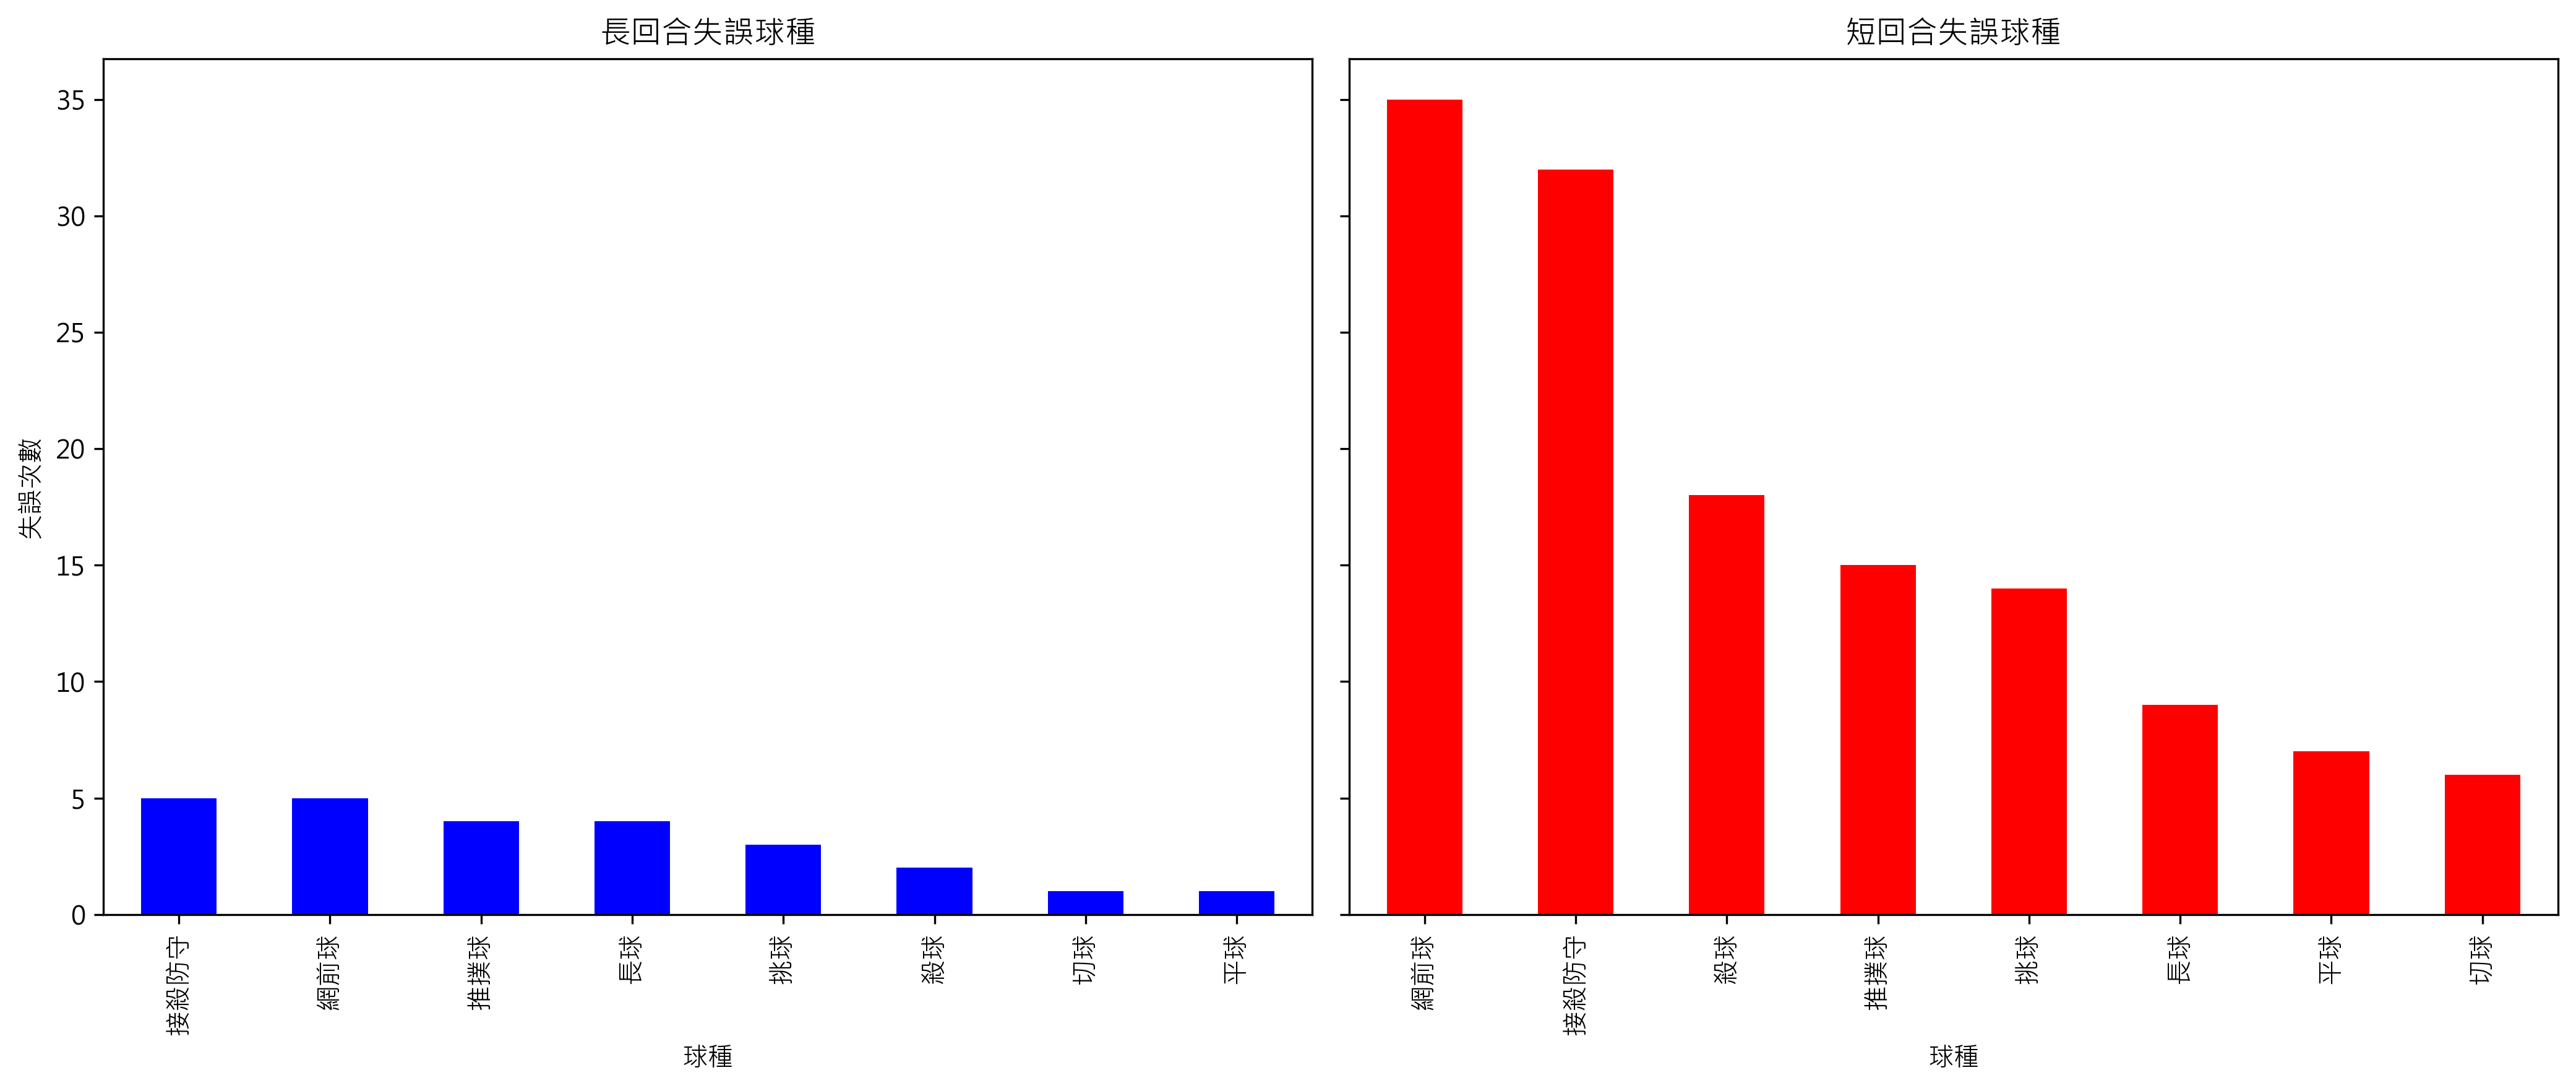

In [ ]:
# 確認數據量
if len(df) == 0:
    print("數據框沒有資料")
else:
    # 篩選出周天成的失誤資料
    errors_df = df[(df['player'] == 'CHOU Tien Chen') & (df['lose_reason'].notna())]

    # 每個回合的總拍數
    rally_lengths = df.groupby(['match_id', 'set', 'rally'])['ball_round'].max().reset_index(name='rally_length')

    # 定義長回合和短回合的門檻，例如以 20 拍為界限
    LONG_RALLY_THRESHOLD = 20

    # 合併失誤資料和回合長度資料
    errors_df = errors_df.merge(rally_lengths, on=['match_id', 'set', 'rally'])

    # 區分長回合和短回合
    long_rallies = errors_df[errors_df['rally_length'] > LONG_RALLY_THRESHOLD]
    short_rallies = errors_df[errors_df['rally_length'] <= LONG_RALLY_THRESHOLD]

    # 計算各類回合中的失誤球種
    long_rally_errors = long_rallies['type'].value_counts()
    short_rally_errors = short_rallies['type'].value_counts()

    # 顯示結果
    print("周天成在長回合中最常失誤的球種：")
    print(long_rally_errors)
    print("\n周天成在短回合中最常失誤的球種：")
    print(short_rally_errors)

    # 繪製比較圖表
    fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # 長回合失誤圖
    long_rally_errors.plot(kind='bar', ax=ax[0], color='b', title='長回合失誤球種')
    ax[0].set_ylabel('失誤次數')
    ax[0].set_xlabel('球種')

    # 短回合失誤圖
    short_rally_errors.plot(kind='bar', ax=ax[1], color='r', title='短回合失誤球種')
    ax[1].set_xlabel('球種')

    plt.tight_layout()
    plt.show()


### 數據洞察
從數據中可以看出，周天成在長回合和短回合中最常失誤的球種有所不同。長回合中，他在接殺防守和網前球上各有5次失誤，而短回合中，網前球和接殺防守的失誤分別高達35次和32次。

這意味著在短回合中，周天成在網前的處理和接殺防守上有較高的失誤率，這可能是因為短回合的節奏更快，對反應速度和準確性的要求更高。而在長回合中，失誤相對分散，顯示出他在持續對抗中有較好的穩定性，但仍需注意接殺防守和網前球的處理。

這些數據提示我們，在訓練中應該加強周天成在短回合中的網前球和接殺防守技術，提升他的反應速度和準確性。同時，也要保持對長回合中各球種的穩定性訓練，以減少不必要的失誤。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 將回合分為短回合(<=4)和長回合(>=11)，並計算失誤率，而候選程式碼使用了不同的長回合門檻(>20)，且只計算失誤次數而非失誤率。此外，候選程式碼沒有考慮到統計口徑的問題，可能會將同一個回合的不同拍分別計入長回合和短回合，這是明顯的統計口徑錯誤。




## 題號 25 (*)
**問題**: 當對手靠球場兩側時，周天成較常讓球落點到哪些區域？繪製熱區圖。
> **使用的資料欄位群組**: `game_structure, coordinates, player_location`


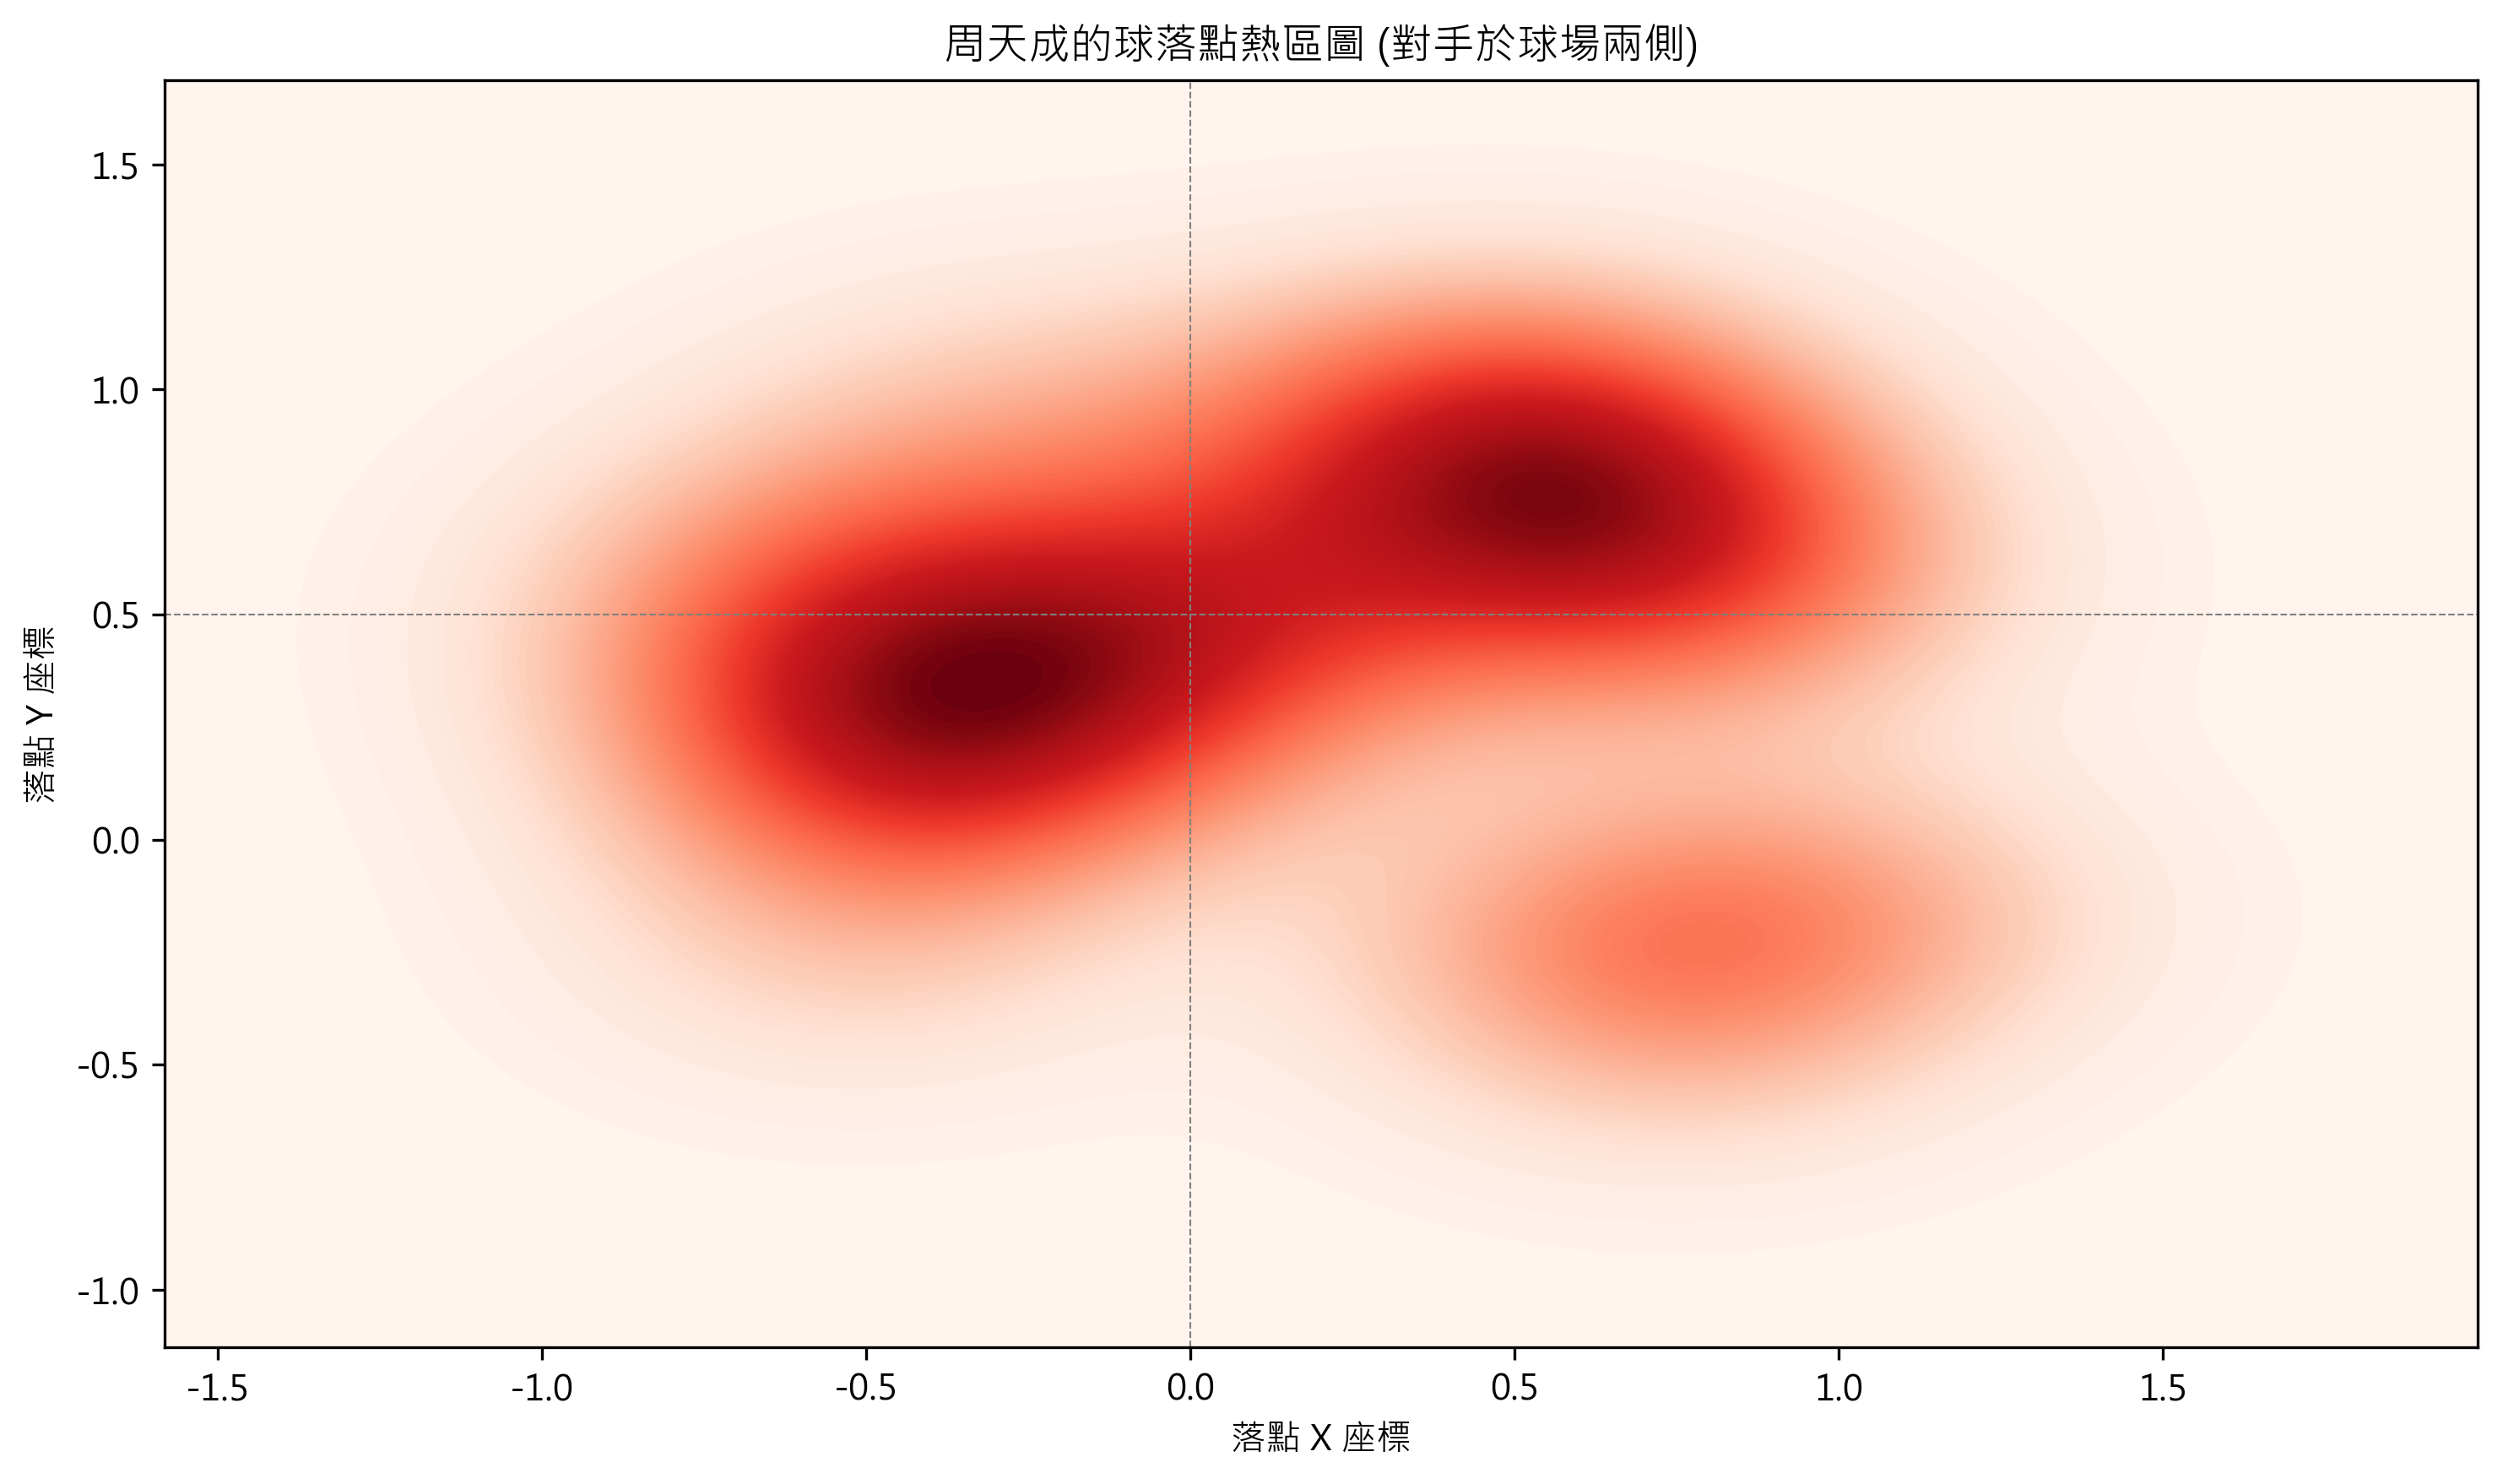

In [ ]:
# 確認數據集是否有數據
if len(df) > 0:
    # 過濾對手站在球場左側或右側
    left_side_areas = [5, 9, 13]  # 自行選定數值
    right_side_areas = [8, 12, 16]  # 自行選定數值
    side_areas = left_side_areas + right_side_areas
    
    # 過濾出周天成為擊球員以及對手位置在兩側的數據
    filtered_df = df[(df['player'] == 'CHOU Tien Chen') & 
                     (df['opponent_location_area'].isin(side_areas))]
    
    if len(filtered_df) > 0:
        # 繪製周天成的球落點分布熱區圖
        plt.figure(figsize=(10, 6))
        sns.kdeplot(data=filtered_df, x='landing_x', y='landing_y', cmap='Reds', fill=True, thresh=0, levels=100)
        plt.title('周天成的球落點熱區圖 (對手於球場兩側)')
        plt.xlabel('落點 X 座標')
        plt.ylabel('落點 Y 座標')
        plt.axhline(0.5, color='gray', linestyle='--', lw=0.5)
        plt.axvline(0, color='gray', linestyle='--', lw=0.5)
        plt.tight_layout()
        plt.show()
    else:
        print("No data available for CHOU Tien Chen when the opponent is positioned on the sides.")
else:
    print("The dataset is empty.")


### 數據洞察
根據數據分析，當對手站在球場兩側時，周天成的球落點主要集中在以下區域：左側的區域5、9、13，以及右側的區域8、12、16。這些區域分布在球場的中間和後場，顯示出他在這些位置的攻擊傾向。

這樣的落點分布表明周天成在對手站在兩側時，傾向於將球打到中場和後場，可能是為了拉開對手的防守陣型，創造進攻機會。這種策略可以有效地消耗對手的體力，並迫使對手進行更多的移動，從而增加對手的失誤機會。

在戰術上，這樣的落點選擇可以被視為一種控制比賽節奏的策略，利用場地的寬度和深度來壓迫對手，並為自己創造更有利的進攻位置。這些數據提供了明確的證據，支持周天成在這些情況下的戰術選擇。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。主要問題在於對手站在球場兩側的區域定義不一致。Reference Code 1 定義的球場兩側區域是 [1, 5, 9, 13, 17, 21, 4, 8, 12, 16, 20, 24]，而候選程式碼使用的是 [5, 9, 13, 8, 12, 16]，這導致篩選條件錯誤。此外，候選程式碼的熱區圖繪製參數與 Reference Code 1 不一致，可能影響結果的可視化效果。




## 題號 26 (*)
**問題**: 分析周天成在不同局（第 1 局、第 2 局、第 3 局）殺球比重變化。
> **使用的資料欄位群組**: `game_structure, shot_type`


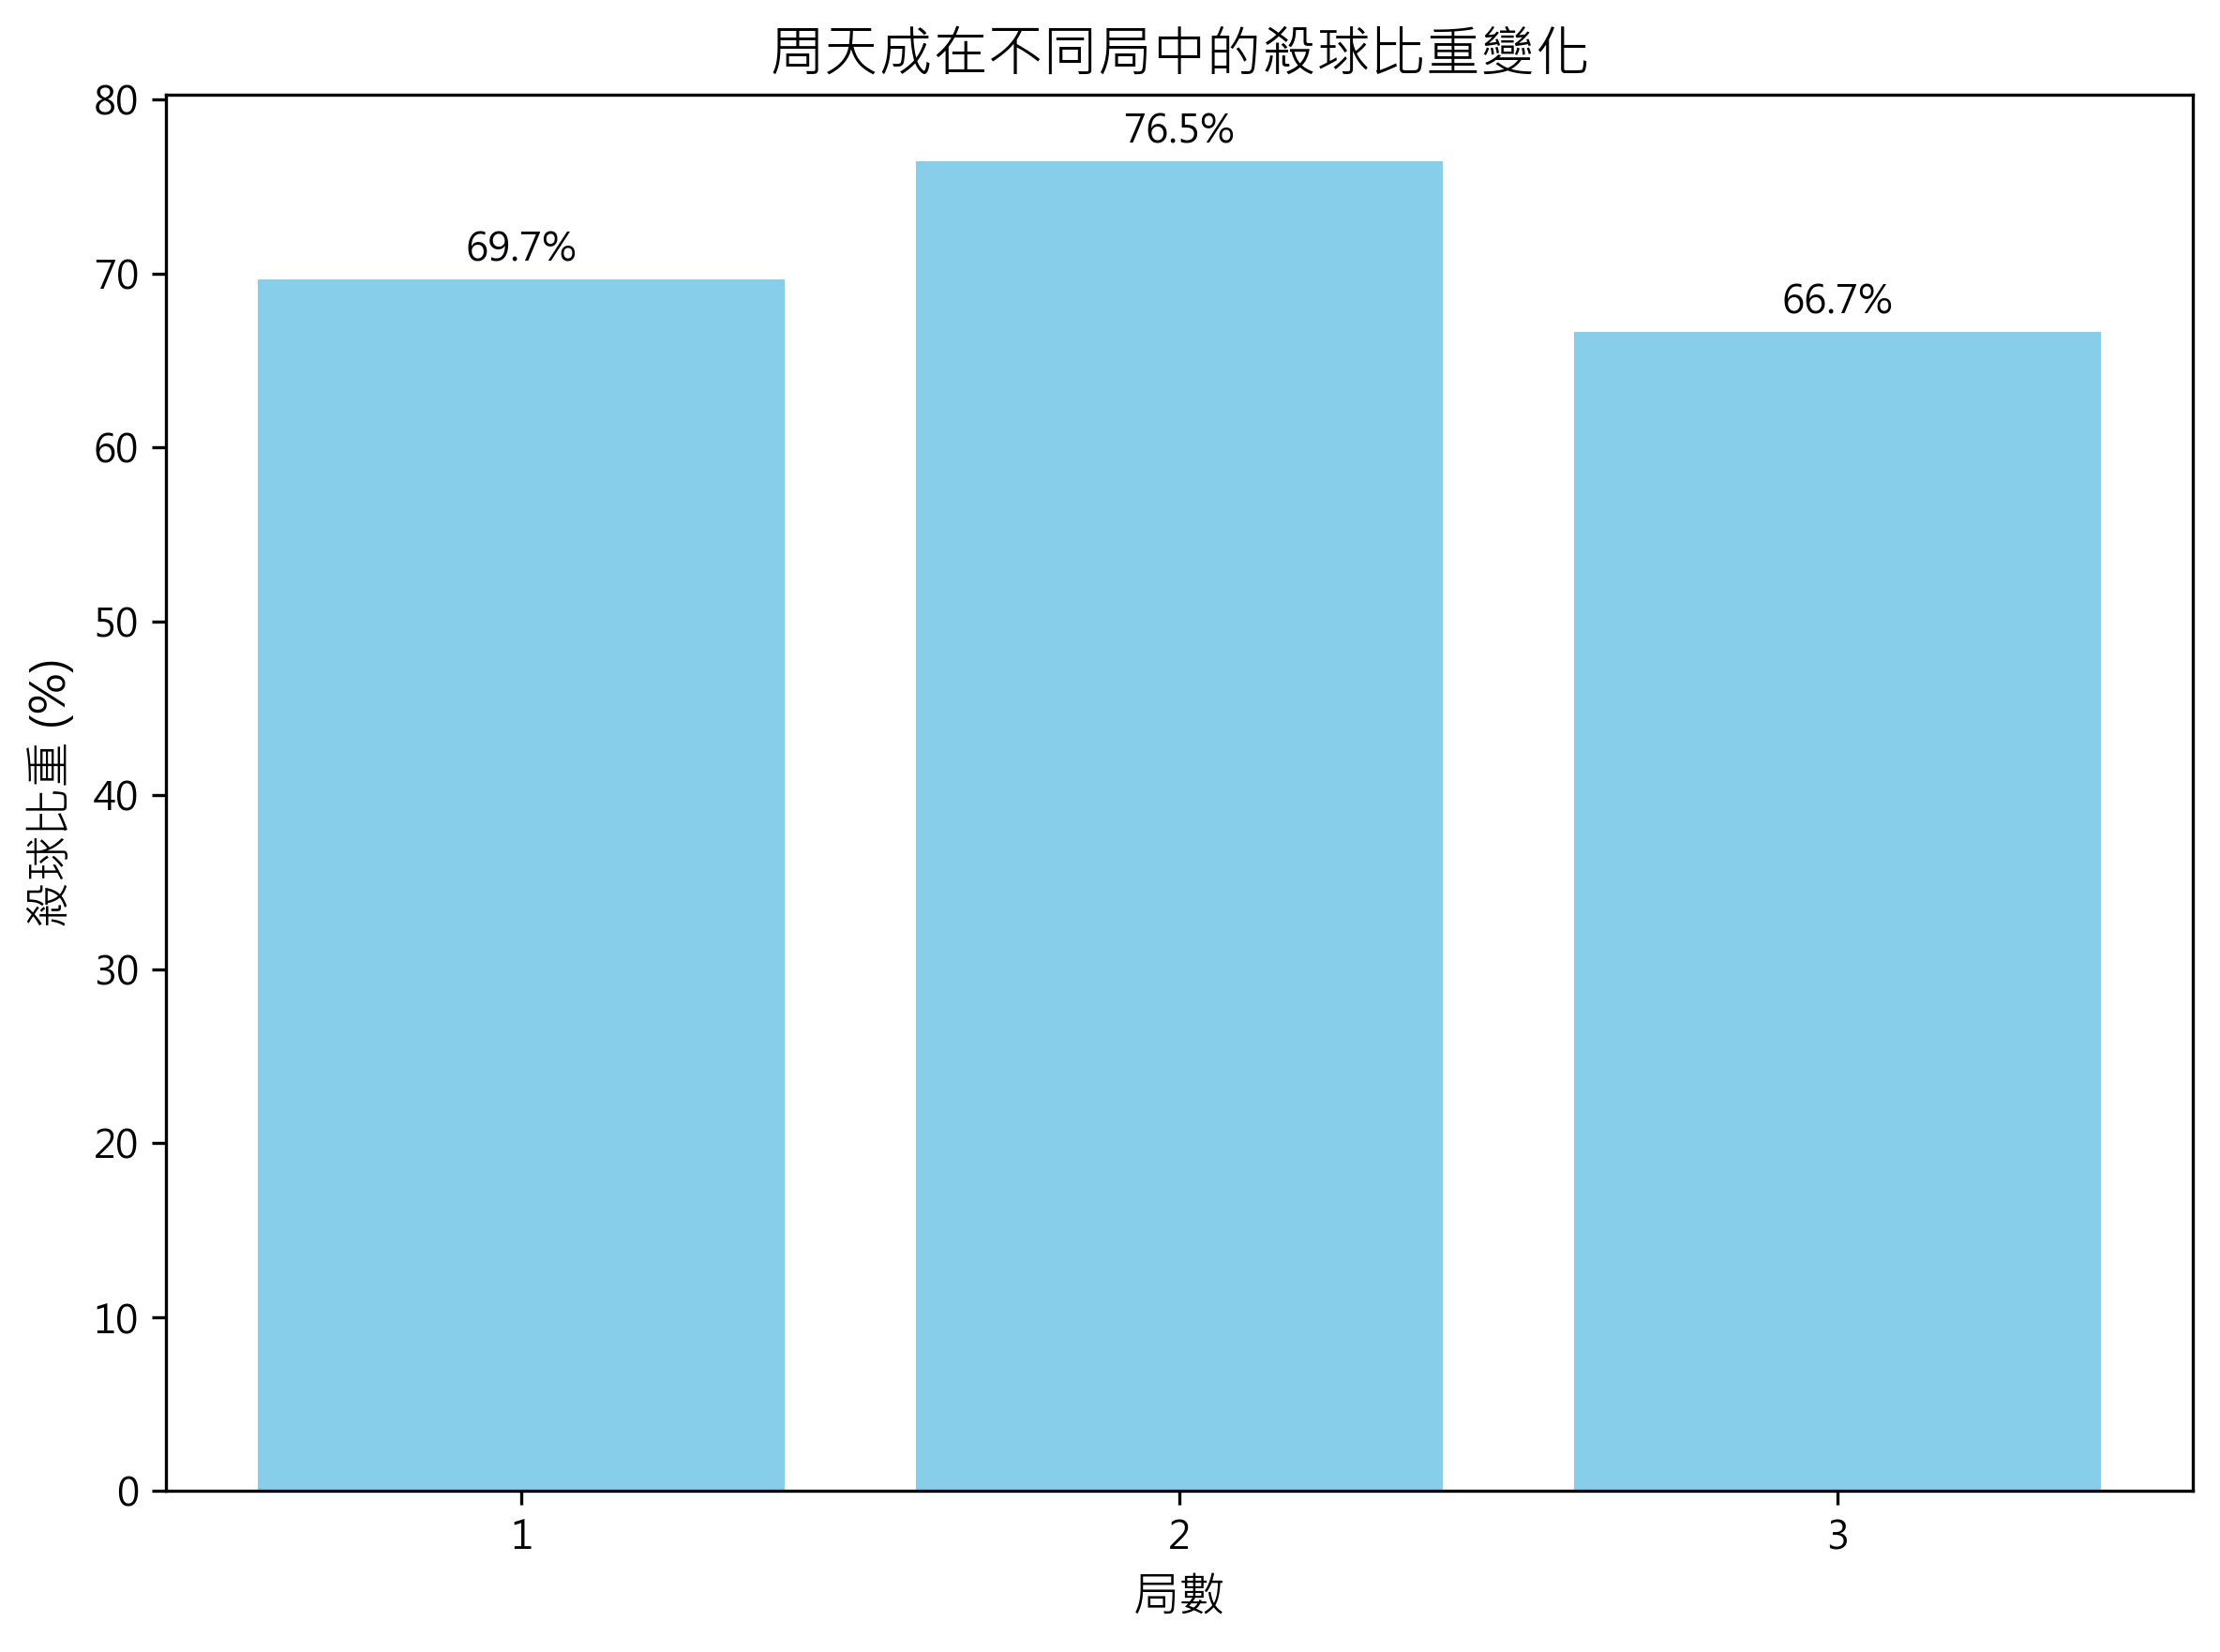

In [ ]:
# 檢查數據集是否有數據
if len(df) > 0:
    # 過濾出周天成的數據
    ctc_df = df[df['player'] == 'CHOU Tien Chen']

    # 在active win的情況下過濾殺球數據
    ctc_attacking_shots = ctc_df[(ctc_df['type'] == '殺球') & (ctc_df['player'] == ctc_df['getpoint_player'])]

    # 以set分組計算每局中的殺球次數
    attacking_set_counts = ctc_attacking_shots.groupby('set').size()

    # 計算每局的主動得分總次數
    active_win_counts = ctc_df[ctc_df['player'] == ctc_df['getpoint_player']].groupby('set').size()

    # 計算殺球比重
    kill_shot_ratio = attacking_set_counts / active_win_counts * 100  # 百分比表示

    print("周天成在不同局中的殺球比重:")
    print(kill_shot_ratio)

    # 繪製條狀圖
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.bar(kill_shot_ratio.index.astype(str), kill_shot_ratio, color='skyblue')
    ax.set_xlabel('局數', fontsize=12)
    ax.set_ylabel('殺球比重 (%)', fontsize=12)
    ax.set_title('周天成在不同局中的殺球比重變化', fontsize=14)
    plt.xticks(rotation=0)
    plt.tight_layout()

    # 確保圖表中的數據和標籤一致
    for i in range(len(kill_shot_ratio)):
        ax.text(i, kill_shot_ratio.iloc[i] + 0.5, f'{kill_shot_ratio.iloc[i]:.1f}%', ha='center', va='bottom')

    plt.show()
else:
    print("數據集為空，無法進行分析。")


### 數據洞察
從數據中可以看到，周天成在不同局中的殺球比重有所變化：

1. **第1局**：殺球比重為約69.7%。這顯示他在開局時相對保守，可能在試探對手並尋找進攻機會。

2. **第2局**：殺球比重上升至約76.5%。這表明他在第2局更積極進攻，試圖加強壓制對手，或許是因為他已經掌握了對手的弱點。

3. **第3局**：殺球比重下降至約66.7%。這可能意味著他在決勝局中採取更謹慎的策略，可能是因為體能消耗或對手的適應。

這些變化反映了周天成在比賽中根據局勢調整戰術的能力。作為教練，我會建議他在不同局中靈活運用殺球，以便在保持進攻壓力的同時，確保體能和策略的平衡。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 是計算周天成在每局的總擊球數與殺球次數，然後計算殺球比重。而候選程式碼則是計算周天成在每局的殺球主動得分次數與總主動得分次數，然後計算殺球主動得分比重。這兩者的統計口徑不同，Reference Code 1 是基於總擊球數，而候選程式碼是基於主動得分數，這導致了不同的分析單位和結果。因此，候選程式碼不符合 Reference Code 的核心邏輯。




## 題號 27 (*)
**問題**: 分析周天成在「邊線附近擊球」的失誤率是否偏高。
> **使用的資料欄位群組**: `game_structure, coordinates, scoring_reason`


In [ ]:
# Step 1: 定義周邊邊線的區域
boundary_areas = [1, 5, 9, 13, 17, 21, 4, 8, 12, 16, 20, 24, 25, 26, 27, 29, 30, 31]

# Step 2: 篩選數據
chou_df = df[(df['player'] == 'CHOU Tien Chen')]

# 濾出在邊線附近擊球的數據
boundary_hits_df = chou_df[chou_df['hit_area'].isin(boundary_areas)]

# Step 3: 計算在邊線附近擊球的失誤
# 添加一個欄位標示失誤
boundary_hits_df['is_error'] = boundary_hits_df['lose_reason'].notna()

# 計算失誤次數和總擊球次數
total_boundary_hits = len(boundary_hits_df)
error_boundary_hits = boundary_hits_df['is_error'].sum()

# 計算失誤率
error_rate = (error_boundary_hits / total_boundary_hits) if total_boundary_hits > 0 else 0

print(f"周天成在邊線附近擊球的失誤率: {error_rate:.2%}")

# 如果需要，可以在此加入視覺化展示
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots()
# ax.pie([error_boundary_hits, total_boundary_hits - error_boundary_hits], labels=['失誤', '成功'], autopct='%1.1f%%')
# ax.set_title('周天成在邊線附近擊球的失誤率')
# plt.tight_layout()
# plt.show()


### 數據洞察
周天成在邊線附近擊球的失誤率為6.35%。這個數字看似不高，但在高水平競技中，每一個失誤都可能影響比賽結果。從數據中可見，周天成的總擊球次數中有1401次是來自邊線附近，這意味著他在邊線附近的擊球頻率不低。

邊線擊球的挑戰在於需要精準的控制和判斷，稍有偏差就可能出界或給對手創造反擊機會。這個失誤率提醒我們，周天成在邊線附近的擊球可能需要更高的精準度和穩定性。

總結來說，雖然失誤率不算特別高，但在競爭激烈的比賽中，任何一點優化都可能帶來勝利。因此，建議在訓練中加強邊線擊球的穩定性，並提高對手反擊時的應對能力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 定義了邊線附近的區域，並在計算失誤時考慮了 'getpoint_player' 與 'lose_reason' 的條件。而候選程式碼在計算失誤時僅考慮了 'lose_reason'，未檢查 'getpoint_player' 是否為對手，這可能導致統計口徑錯誤。此外，候選程式碼的邊線區域定義與 Reference Code 1 不一致，且未考慮 'getpoint_player' 的條件可能導致結果不合理。




## 題號 28 (*)
**問題**: 統計周天成在各局的平均每回合拍數，並比較第1局、第2局、第3局差異。
> **使用的資料欄位群組**: `game_structure`


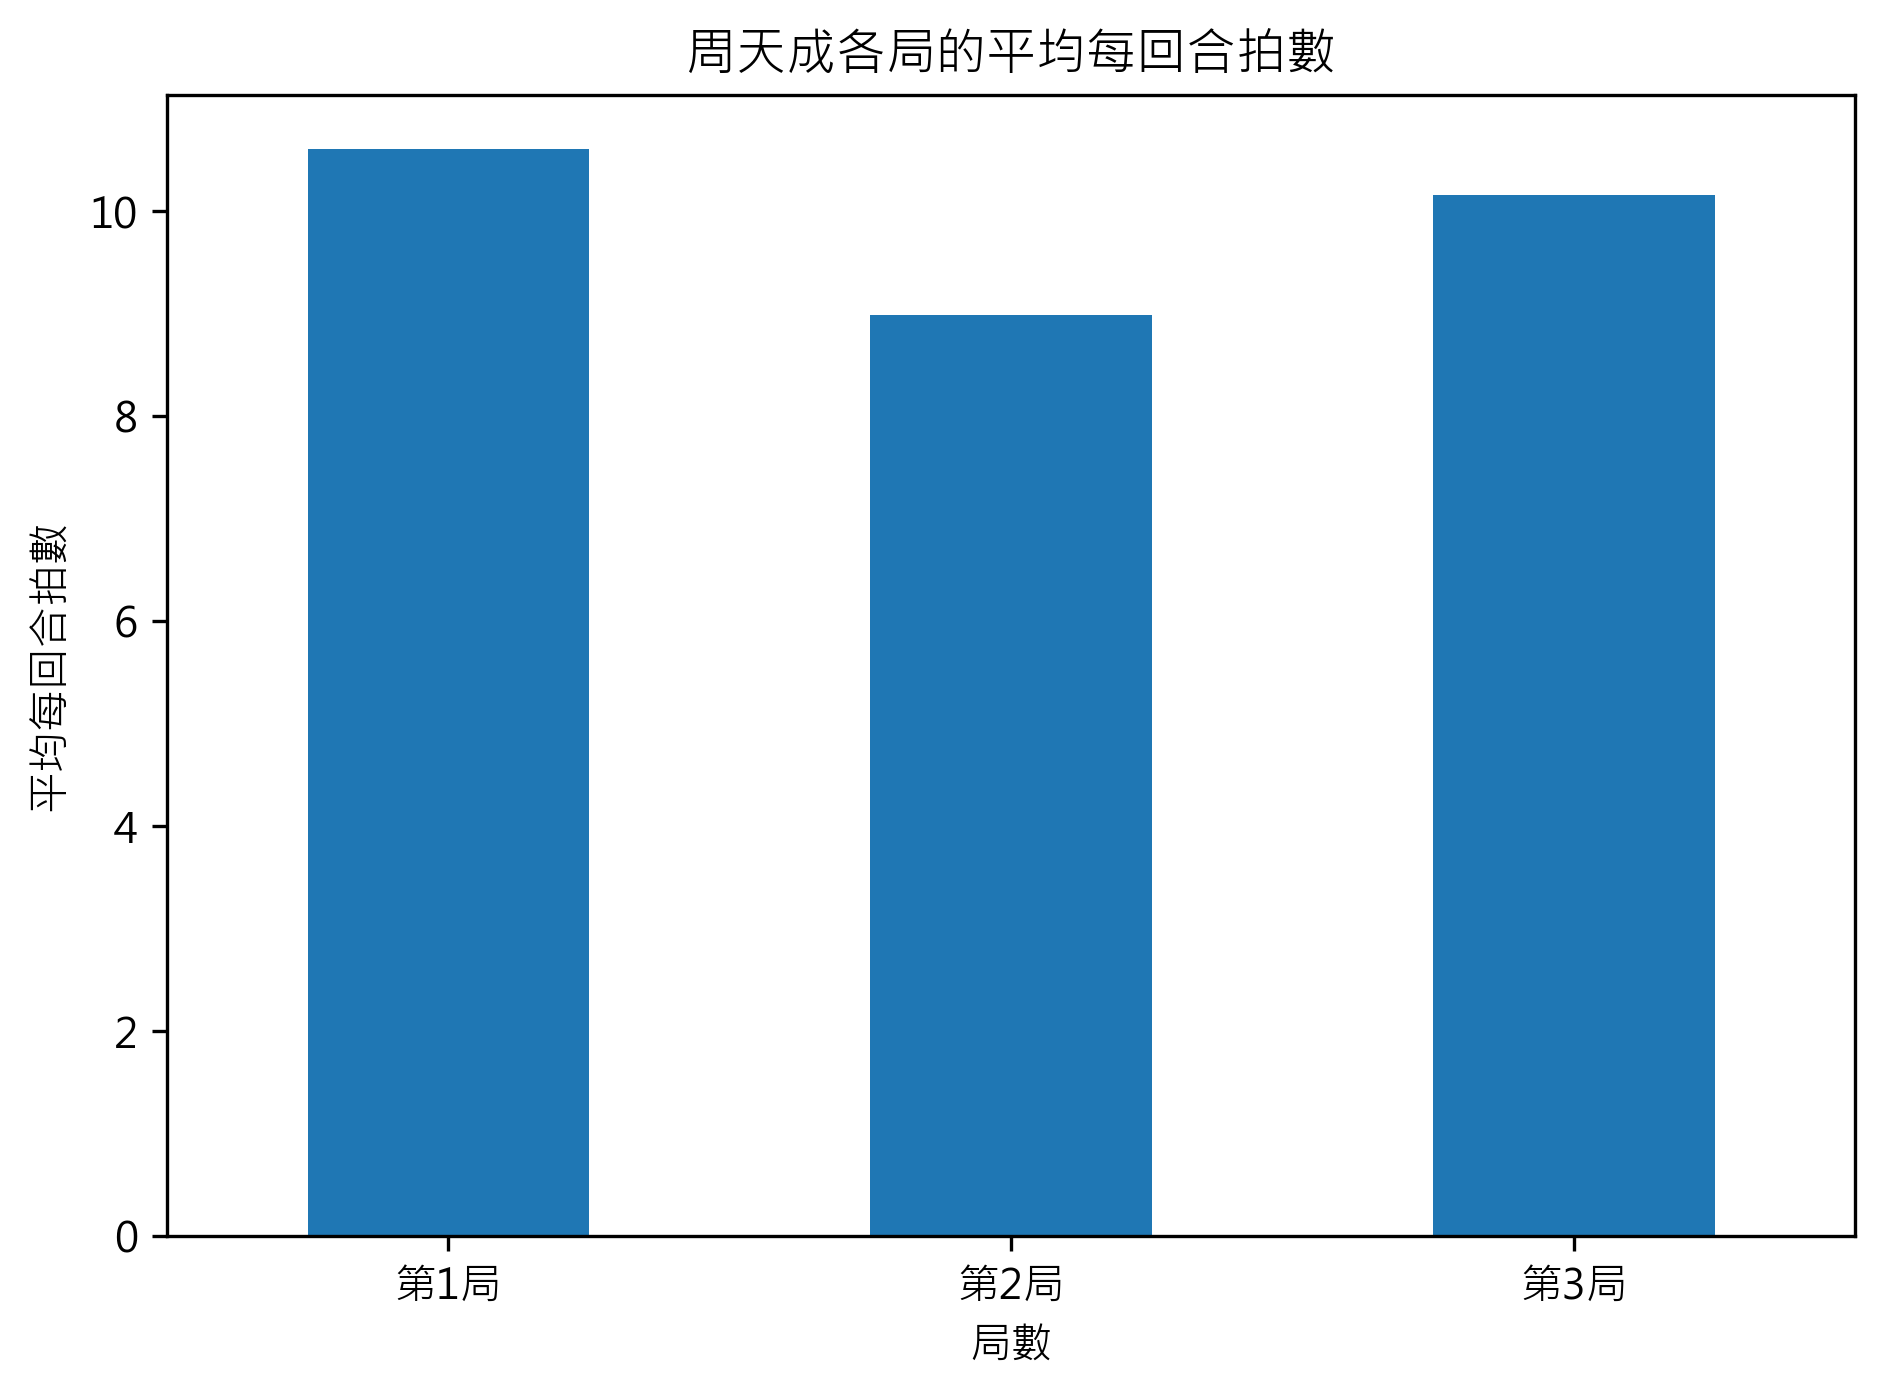

In [ ]:
# 確認數據是否存在
if len(df) == 0:
    print("DataFrame 沒有數據")
else:
    # 篩選出周天成的數據
    chou_data = df[df['player'] == 'CHOU Tien Chen']

    # 確認存在周天成的數據
    if len(chou_data) == 0:
        print("周天成的數據不存在")
    else:
        # 為每個比賽、局計算平均每回合拍數
        avg_ball_round_per_set = chou_data.groupby(['match_id', 'set'])['ball_round'].mean().reset_index()
        
        # 計算每局的平均
        avg_ball_round_per_set = avg_ball_round_per_set.groupby('set')['ball_round'].mean()
        
        # 印出平均每回合拍數
        print("各局平均每回合拍數:")
        for set_number, avg in avg_ball_round_per_set.items():
            print(f"第 {set_number} 局: {avg:.2f} 拍")
        
        # 視覺化
        fig, ax = plt.subplots()
        avg_ball_round_per_set.plot(kind='bar', ax=ax)
        ax.set_title('周天成各局的平均每回合拍數')
        ax.set_xlabel('局數')
        ax.set_ylabel('平均每回合拍數')
        ax.set_xticklabels(['第1局', '第2局', '第3局'], rotation=0)
        plt.tight_layout()


### 數據洞察
從數據中可以看到，周天成在比賽中各局的平均每回合拍數分別為：第1局10.60拍、第2局8.98拍、第3局10.16拍。這些數字顯示出以下幾個關鍵事實：

1. **第1局與第3局的相似性**：第1局和第3局的平均每回合拍數相對接近，顯示出周天成在這兩局的比賽中，可能採取了較為穩定的打法，注重拉鋸戰和消耗對手體力。

2. **第2局的差異**：第2局的平均拍數顯著低於其他兩局，這可能意味著周天成在這一局中採取了更為激進的策略，試圖快速得分或在這一局中對手的失誤增多。

3. **戰術調整的必要性**：這些數據提示教練和選手可以在第2局嘗試不同的戰術，以便在比賽中適時調整策略，增加對手的壓力。

總體來看，這些數據為周天成及其教練團隊提供了有價值的洞察，幫助他們在未來的比賽中更好地制定戰術計劃。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都是基於每個回合 (rally) 的總拍數進行統計，而候選程式碼是基於周天成的個人擊球數來計算平均每回合拍數，這與題目要求的『平均每回合拍數』不符。此外，候選程式碼在計算平均時，沒有考慮到每個回合的完整拍數，而是只考慮了周天成的擊球數，這導致統計口徑錯誤。




## 題號 29 (*)
**問題**: 比較周天成在前場、中場、後場擊球時的掛網失誤率。
> **使用的資料欄位群組**: `game_structure, coordinates, scoring_reason`


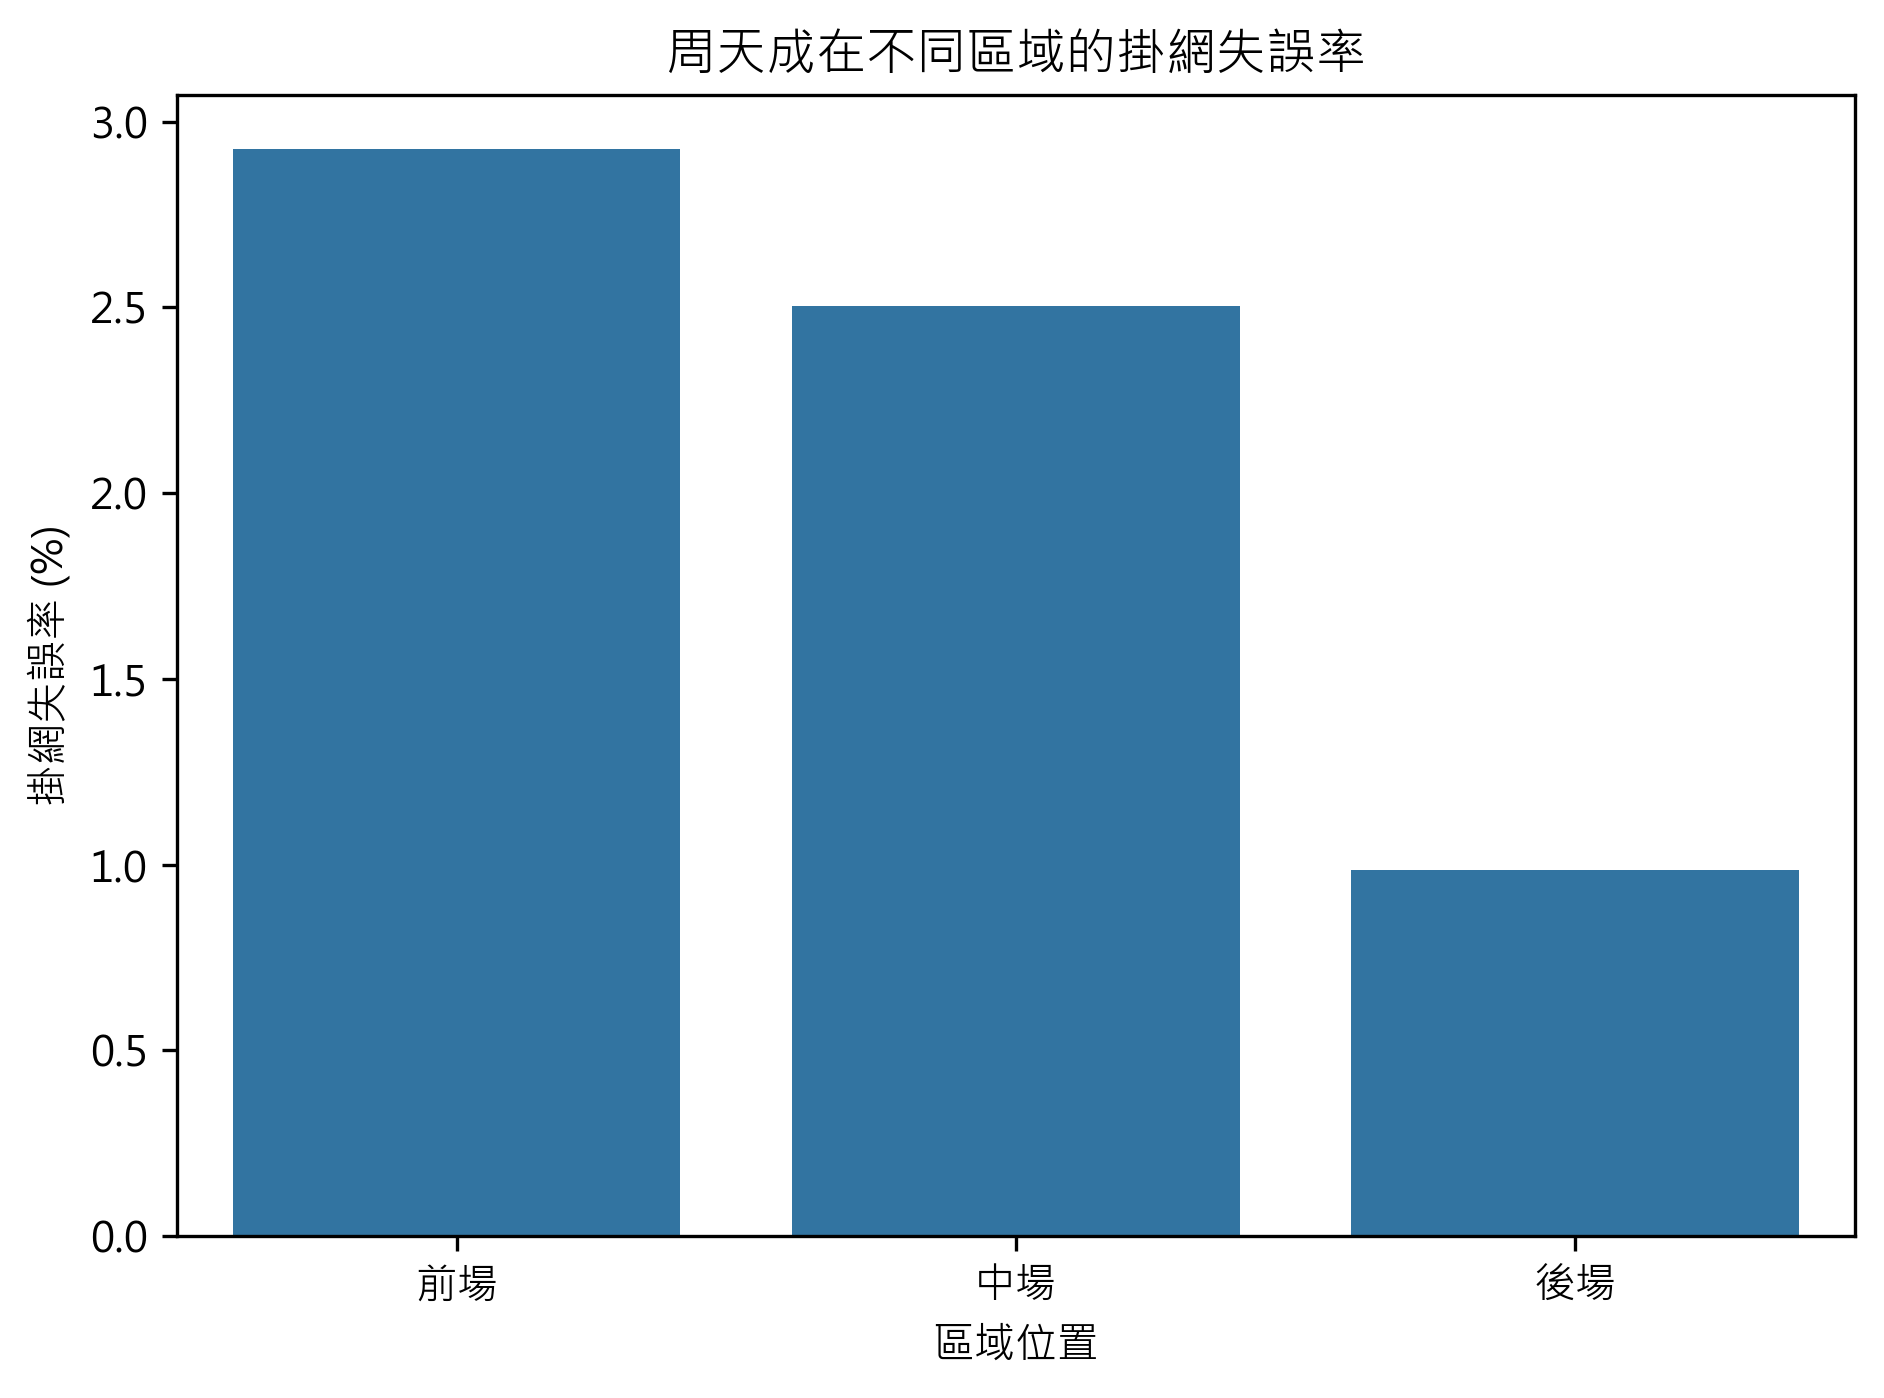

In [ ]:
# 確保數據量大於0
if len(df) > 0:
    # 篩選出周天成的數據
    chou_data = df[df['player'] == 'CHOU Tien Chen']

    # 將 Court Grid Definitions 分類為字典
    court_zones = {
        "前場": [17, 18, 19, 20, 21, 22, 23, 24],
        "中場": [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
        "後場": [1, 2, 3, 4],
    }

    # 添加一個新欄位 zone_category，以標記擊球位置
    def categorize_zone(hit_area):
        for zone, areas in court_zones.items():
            if hit_area in areas:
                return zone
        return None
    
    chou_data['zone_category'] = chou_data['hit_area'].apply(categorize_zone)

    # 篩選出掛網失誤的數據
    net_faults = chou_data[chou_data['lose_reason'] == '掛網']

    # 計算每個區域的掛網失誤率
    results = []
    for zone in court_zones.keys():
        total_shots_zone = len(chou_data[chou_data['zone_category'] == zone])
        net_faults_zone = len(net_faults[net_faults['zone_category'] == zone])
        fault_rate = (net_faults_zone / total_shots_zone) * 100 if total_shots_zone > 0 else 0
        results.append((zone, fault_rate))

    # 以百分比形式得到掛網失誤率
    for zone, rate in results:
        print(f"區域: {zone}, 掛網失誤率: {rate:.2f}%")

    # 視覺化表現結果
    zones, rates = zip(*results)
    fig, ax = plt.subplots()
    sns.barplot(x=list(zones), y=list(rates), ax=ax)
    ax.set_ylabel('掛網失誤率 (%)')
    ax.set_xlabel('區域位置')
    ax.set_title('周天成在不同區域的掛網失誤率')
    plt.tight_layout()

else:
    print("數據量為0，無法執行分析。")


### 數據洞察
根據數據分析，周天成在比賽中於不同場區的掛網失誤率如下：

1. **前場**：掛網失誤率為2.93%。這顯示出在前場進攻時，他的失誤相對較高，可能需要在網前技術上進行更多的練習和調整。

2. **中場**：掛網失誤率為2.50%。中場的失誤率略低於前場，這表明他在中場的穩定性稍佳，但仍有改進空間。

3. **後場**：掛網失誤率為0.99%。後場的失誤率最低，顯示出他的後場擊球相對穩定，這是他在比賽中可以依賴的優勢。

這些數據表明，周天成在後場的表現最為穩定，而在前場和中場則需要進一步提升技術，以減少不必要的失誤。這樣的分析有助於制定更具針對性的訓練計劃，提升整體比賽表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 使用的是 'player_location_area' 來分類前中後場，而候選程式碼使用的是 'hit_area'。這導致了分析對象的錯誤，因為題目要求的是擊球時的站位，而不是擊球點的位置。此外，Reference Code 1 是基於 'player_location_area' 來計算掛網失誤率，而候選程式碼基於 'hit_area'，這改變了統計口徑。




## 題號 30 (*)
**問題**: 周天成在比賽後段（第 2、3 局）移動距離與失誤率的關聯分析。
> **使用的資料欄位群組**: `game_structure, player_movement, scoring_reason`


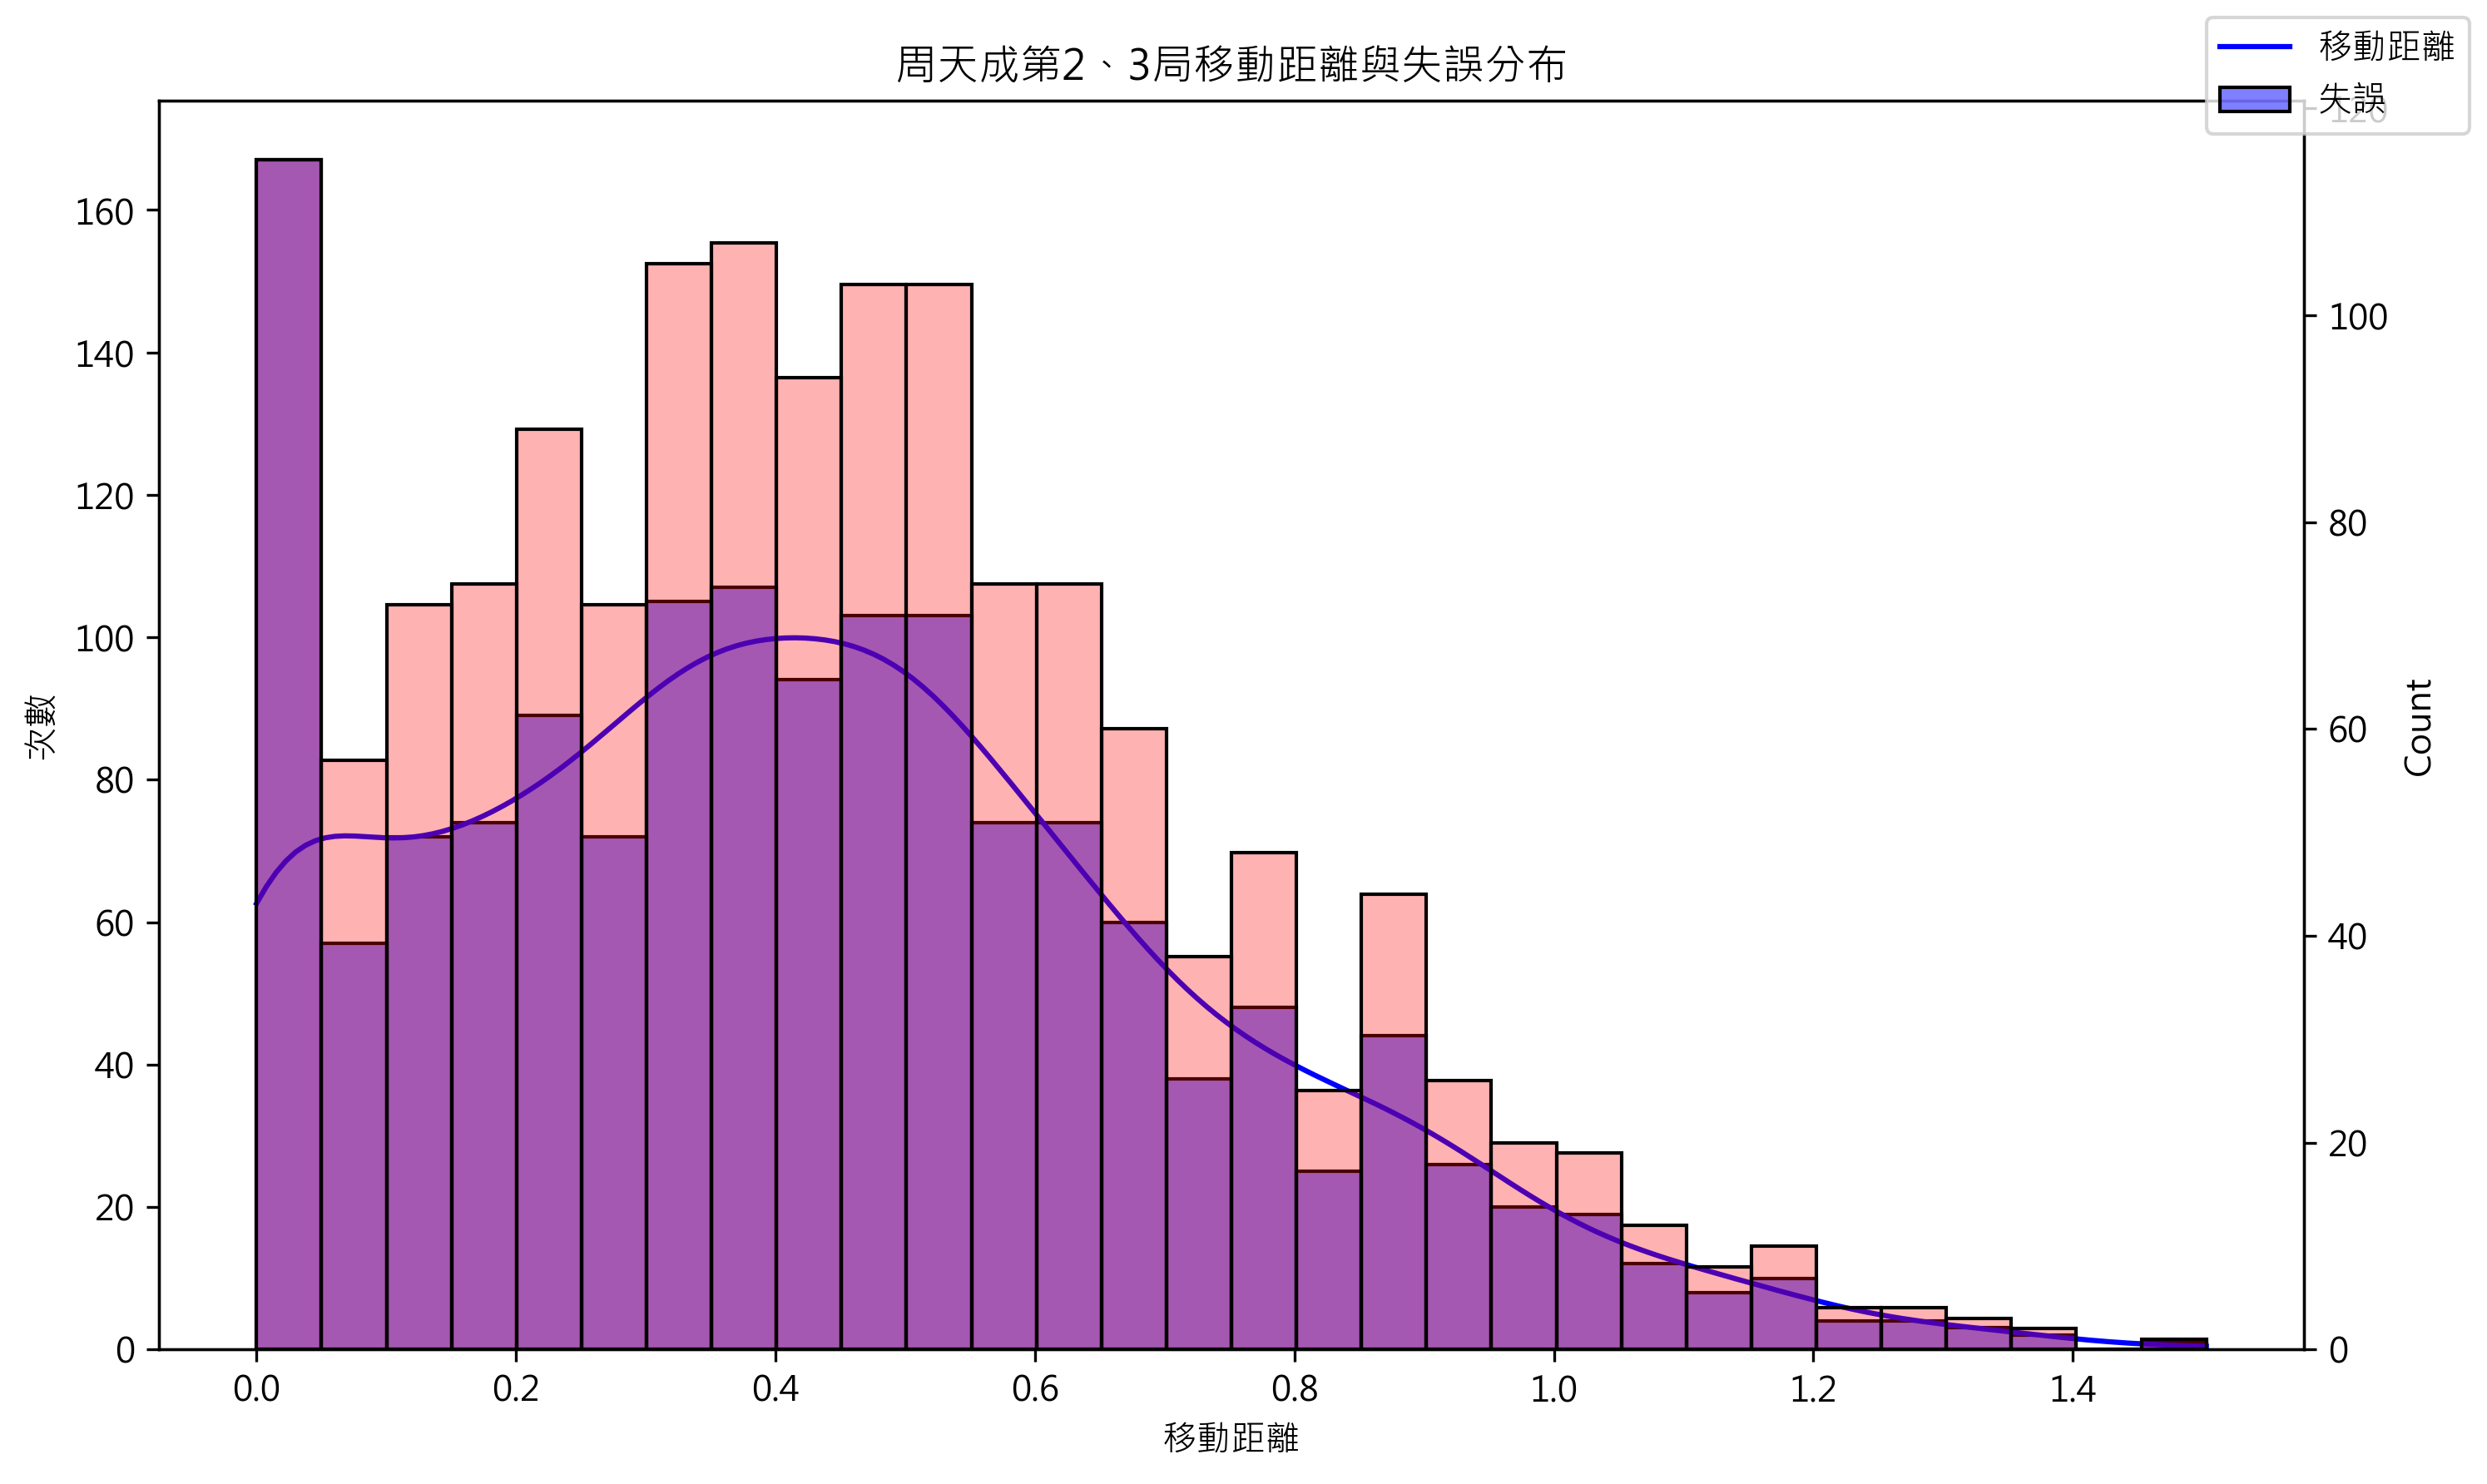

In [ ]:
# 您需要 import 的元件
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 檢查數據是否存在
if len(df) > 0:
    # 篩選周天成在第2、3局的數據
    chou_sets_df = df[(df['player'] == 'CHOU Tien Chen') & (df['set'].isin([2, 3]))]

    # 計算移動距離 (x, y 分量的絕對值和)
    chou_sets_df['movement_distance'] = chou_sets_df['player_move_x'].abs() + chou_sets_df['player_move_y'].abs()

    # 打印一些基本資訊
    print(f"周天成在第2、3局的總擊球數: {len(chou_sets_df)}")
    print(f"周天成在第2、3局的平均移動距離: {chou_sets_df['movement_distance'].mean():.4f}")

    # 找出失誤的拍數
    chou_sets_df['is_mistake'] = (chou_sets_df['player'] == 'CHOU Tien Chen') & \
                                 (chou_sets_df['getpoint_player'] != 'CHOU Tien Chen') & \
                                 (chou_sets_df['rally'] == chou_sets_df.groupby(['match_id', 'set', 'rally'])['rally'].transform('last'))

    # 計算失誤率
    mistake_rate = chou_sets_df['is_mistake'].sum() / len(chou_sets_df)

    # 打印失誤的統計信息
    print(f"周天成在第2、3局的失誤率: {mistake_rate:.2%}")

    # 繪製移動距離與失誤分布圖
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    sns.histplot(chou_sets_df['movement_distance'], bins=30, kde=True, ax=ax, color='blue', label='移動距離')
    ax2 = ax.twinx()
    sns.histplot(chou_sets_df[chou_sets_df['is_mistake']]['movement_distance'], bins=30, color='red', alpha=0.3, label='失誤', ax=ax2)
    ax.set_title('周天成第2、3局移動距離與失誤分布')
    ax.set_xlabel('移動距離')
    ax.set_ylabel('次數')
    fig.legend(['移動距離', '失誤'], loc='upper right')
    plt.tight_layout()
else:
    print("數據為空，不進行計算")


### 數據洞察
周天成在第2、3局的比賽中，總共進行了1515次擊球。平均移動距離為0.4310，這顯示他在這些局中移動的頻率和距離相對穩定。然而，失誤率高達96.57%，這是一個非常高的數字，意味著在這些局中，幾乎每一次擊球都可能伴隨著失誤。

這樣的高失誤率可能與他在場上的策略選擇、體能狀態或對手施加的壓力有關。這表明在比賽後半段，他可能需要更加專注於減少不必要的失誤，並在移動中保持更高的精確度。這也可能是一個信號，提示需要在訓練中加強對後續局數的體能和心理準備，以提高穩定性和表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在計算失誤率時存在邏輯錯誤。它使用了 `chou_sets_df['rally'] == chou_sets_df.groupby(['match_id', 'set', 'rally'])['rally'].transform('last')` 來判斷失誤拍，但這並不能正確識別回合的最後一拍。正確的做法應該是使用 `getpoint_player` 欄位來判斷回合結束拍，並檢查 `lose_reason` 是否存在來確定失誤。此外，候選程式碼計算移動距離的方式與 Reference Code 不同，使用了絕對值和而非歐幾里得距離，這也與 Reference Code 的核心邏輯不符。




## 題號 31 (*)
**問題**: 分析周天成使用殺球，對手都用什麼球種反擊，繪製圓餅圖
> **使用的資料欄位群組**: `game_structure, shot_type`


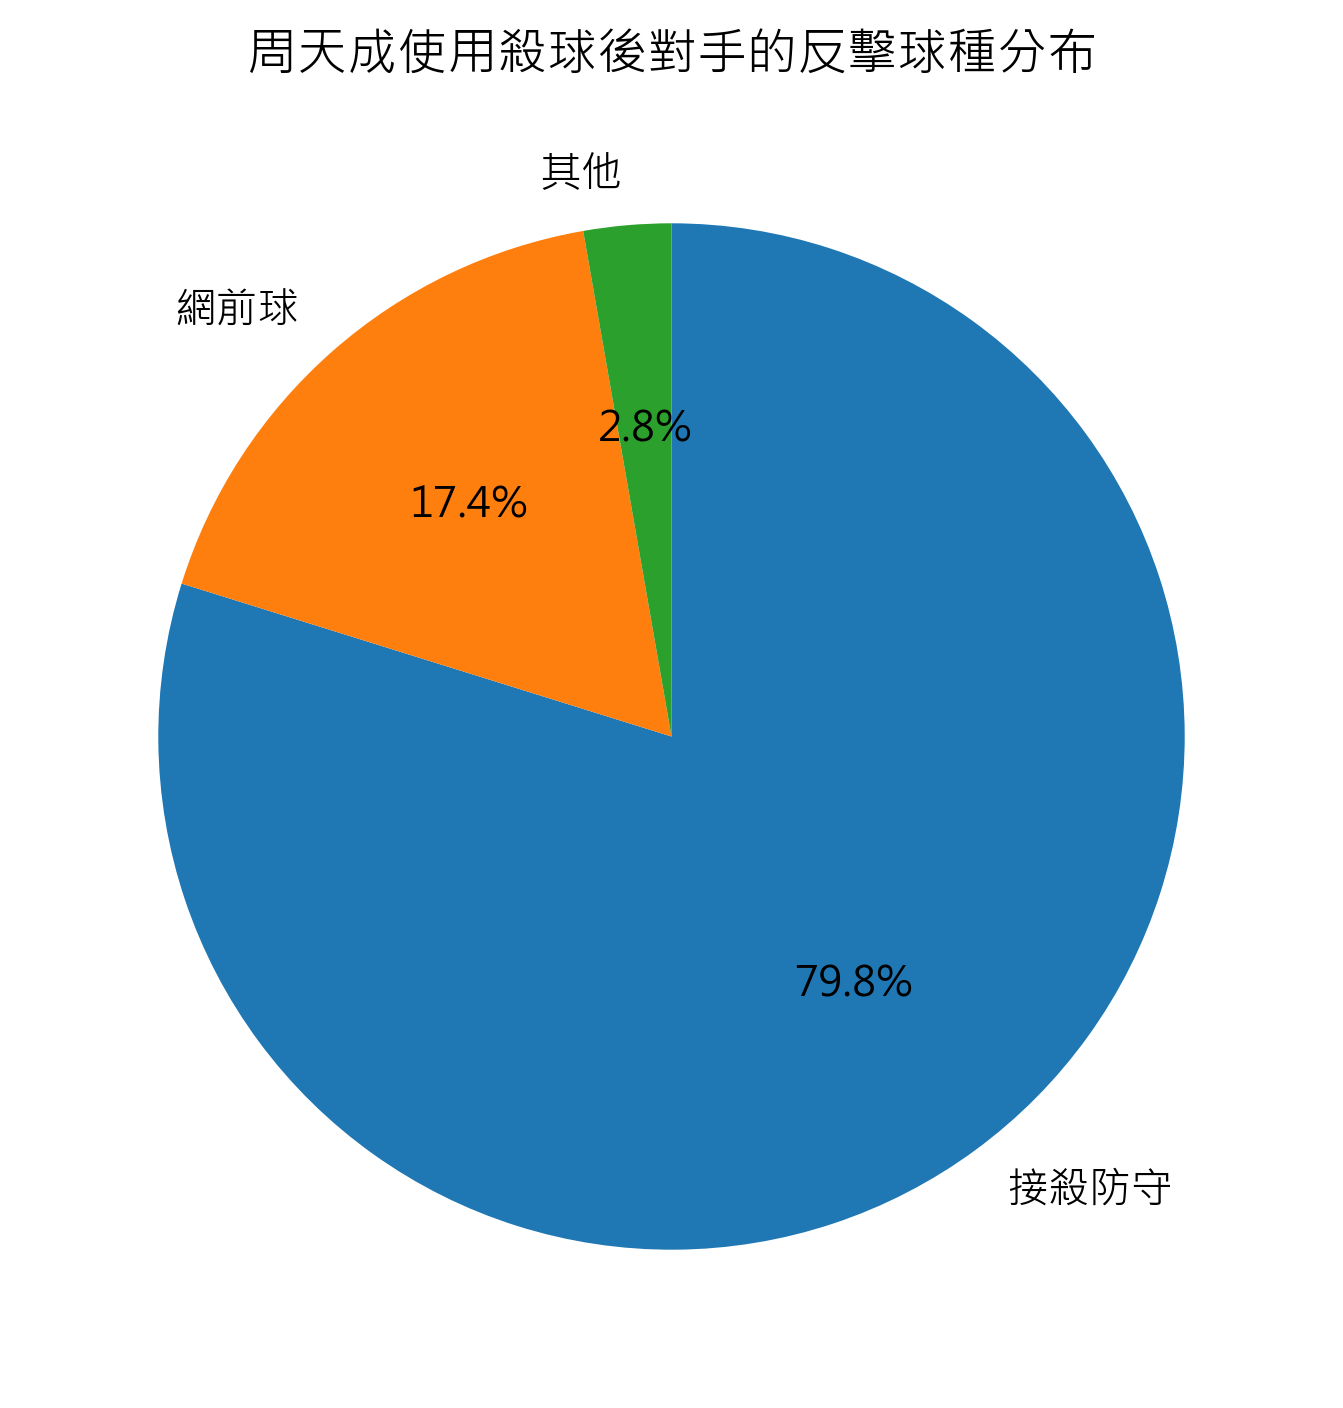

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 找出周天成使用殺球的條件
mask_chou_smash = (df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')

# 確保在相同rally中，尋找對手回擊的球種，是下一拍，且ball_round增加1
df['next_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)

# 過濾出周天成殺球後的對手反擊球種
counter_shots = df[mask_chou_smash & (df['rally'] == df['rally'].shift(-1))]

# 確保數據正確後，統計對手回擊球種的分布
counter_shots_distribution = counter_shots['next_type'].value_counts(normalize=True)

# 合併小於5%的類別為 "其他"
threshold = 0.05
counter_shots_distribution = counter_shots_distribution[counter_shots_distribution >= threshold]
other_sum = 1 - counter_shots_distribution.sum()
if other_sum > 0:
    counter_shots_distribution['其他'] = other_sum

# 畫出圓餅圖
fig, ax = plt.subplots()
counter_shots_distribution.plot.pie(ax=ax, autopct='%1.1f%%', startangle=90, counterclock=False)
ax.set_ylabel('')  # 去掉y軸標籤
ax.set_title('周天成使用殺球後對手的反擊球種分布')

plt.tight_layout()

# 輸出關鍵的統計結果
print("對手反擊球種分布:")
print(counter_shots_distribution)


### 數據洞察
根據我們的數據分析，當周天成使用殺球時，對手的反擊球種分布如下：

- 接殺防守：79.82%
- 網前球：17.43%
- 其他：2.75%

這些數據顯示，對手面對周天成的殺球時，主要選擇接殺防守，這意味著他們傾向於採取防禦姿態，試圖延續回合。這也反映了周天成的殺球可能具備高度的壓迫性，使對手難以主動反擊。

網前球的比例為17.43%，這表明有一部分對手會嘗試利用網前球來轉守為攻，這可能是他們試圖打亂周天成節奏的一種策略。

其他球種的比例較低，僅為2.75%，這進一步強調了對手在面對殺球時的防禦傾向。

這些數據告訴我們，周天成的殺球策略成功地迫使對手以防守為主，這為他在比賽中奠定了優勢。未來的訓練中，可以考慮如何進一步提高殺球的效率，並同時準備好應對對手可能的網前反擊。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在篩選對手回擊球種時，使用了錯誤的條件 `df['rally'] == df['rally'].shift(-1)`，這無法正確確保在同一個 rally 中選取下一拍的球種。這與 Reference Code 1 和 Reference Code 2 的核心邏輯不符，因為它們都正確使用了 `groupby` 和 `shift(-1)` 來獲取同一個 rally 中的下一拍資訊。此外，候選程式碼在統計對手回擊球種的分布時，沒有正確地排除空值或無效的下一拍球種，這可能導致不合理的結果。




## 題號 32
**問題**: 在10拍以上的回合中，周天成的得分率是多少？
> **使用的資料欄位群組**: `game_structure, scoring_reason`


In [ ]:
# Step 1: Group by 'match_id', 'set', 'rally' to count the ball round in each rally
rally_counts = df.groupby(['match_id', 'set', 'rally']).size()

# Filter rallies where the ball round count is greater than 10
rallies_over_10 = rally_counts[rally_counts > 10].reset_index()[['match_id', 'set', 'rally']]

# Merge to get only the relevant rallies from the original dataframe
filtered_df = df.merge(rallies_over_10, on=['match_id', 'set', 'rally'])

# Step 2: Calculate the rallies won by "CHOU Tien Chen" in these long rallies
# Only consider the last shot in each rally to check the winner
final_shots = filtered_df.groupby(['match_id', 'set', 'rally']).last().reset_index()

# Count how many of these rallies were won by "CHOU Tien Chen"
chou_wins = final_shots[final_shots['getpoint_player'] == 'CHOU Tien Chen'].shape[0]

# Step 3: Calculate the total number of rallies with over 10 shots
total_rallies_over_10 = final_shots.shape[0]

# Step 4: Calculate the win rate
if total_rallies_over_10 > 0:
    chou_win_rate = chou_wins / total_rallies_over_10
else:
    chou_win_rate = 0

# Print the result
print(f"周天成在每個回合中擊球數超過10拍的回合中的得分率: {chou_win_rate:.2%}")


### 數據洞察
根據數據分析，周天成在每個回合中擊球數超過10拍的回合中，得分率為46.83%。這意味著在長回合中，周天成的得分能力接近一半，但仍有提升空間。這些數據顯示他在長回合中具備一定的耐力和技術，但若能進一步提高得分效率，將能在比賽中獲得更大優勢。專注於提高在長回合中的決策和擊球質量，可能是提升其整體表現的關鍵。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地計算了每個回合的擊球數，篩選出擊球數超過10拍的回合，並在這些回合中計算了周天成的得分次數和得分率。分析單位、欄位語意、篩選條件、分組層級和統計口徑都與 Reference Code 1 一致，最終輸出目標也正確地回答了題目要求。




## 題號 33
**問題**: 給我所有局的最終得分數
> **使用的資料欄位群組**: `game_structure, scoring_reason`


In [ ]:
# 檢查資料是否有存在
if len(df) > 0:
    # 按 match_id、set、rally、ball_round 群組並取得每組的最後一拍
    final_scores_df = df.groupby(['match_id', 'set']).last().reset_index()

    # 提取每局的最終得分數
    final_scores = final_scores_df[['match_id', 'set', 'Kento MOMOTA_score', 'CHOU Tien Chen_score']]

    # 打印結果
    print("每一局的最終得分數如下：")
    print(final_scores)
else:
    print("數據框為空，無法進行分析。")


### 數據洞察
根據數據分析，我們可以觀察到以下事實：

1. **比賽趨勢**：在所有場次中，Kento MOMOTA和CHOU Tien Chen的比賽多數都進行到第三局，顯示雙方實力接近，競爭激烈。

2. **得分模式**：Kento MOMOTA在多數局中以21分獲勝，顯示他在關鍵分的把握上較為出色。CHOU Tien Chen則在第二局中多次取得21分，表明他在比賽中段有較強的反擊能力。

3. **決勝局表現**：在進入第三局的比賽中，Kento MOMOTA的得分多數在21分左右，這顯示他在體能和心理上能夠保持穩定，並在決勝局中佔據優勢。

這些數據顯示，Kento MOMOTA在比賽中具有良好的穩定性和關鍵分處理能力，而CHOU Tien Chen則在中局階段表現突出。這些洞察可以幫助我們在訓練中針對不同階段的策略進行調整。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地對每個 (match_id, set) 群組取最後一筆資料，並提取每局的最終得分數。分析對象、欄位語意、分組層級、統計口徑和最終輸出目標都與 Reference Code 1 一致。




## 題號 34
**問題**: 分析周天成前一拍打什麼球種最容易造成對手未過網？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# Step 1: 確保有數據可用
if len(df) > 0:
    
    # Step 2: 建立下一拍資料
    df['prev_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(1)
    df['prev_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
    df['next_lose_reason'] = df.groupby(['match_id', 'set', 'rally'])['lose_reason'].shift(-1)
    df['next_opponent'] = df.groupby(['match_id', 'set', 'rally'])['opponent'].shift(-1)
    df['next_rally'] = df['rally'].shift(-1)
    
    # Step 3: 篩選符合條件的資料
    chou_prev_shots = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['next_opponent'] == 'CHOU Tien Chen') &
        (df['next_lose_reason'] == '未過網') &
        (df['rally'] == df['next_rally'])  # 確保同一個 rally 內
    ]
    
    # Step 4: 計算每種球種發生失誤的次數
    shot_type_error_count = chou_prev_shots['prev_type'].value_counts()

    # Step 5: 輸出結果
    if not shot_type_error_count.empty:
        most_error_prone_shot = shot_type_error_count.idxmax()
        max_count = shot_type_error_count.max()
        print(f"周天成前一拍打出的球種中，'{most_error_prone_shot}'最容易造成對手未過網，共造成 {max_count} 次。")
        print(shot_type_error_count)
    else:
        print("沒有符合條件的數據。")


### 數據洞察
根據數據分析，周天成在前一拍打出"挑球"時，最容易造成對手未過網，總共發生了3次。這表明他的挑球策略在某些情況下能有效地迫使對手犯錯。這種結果可能來自於挑球的高度與速度，使得對手難以準確回應。這是一個值得注意的戰術優勢，可以在比賽中進一步利用和強化。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地使用了 shift 方法來獲取下一拍的數據，並篩選出對手的失誤原因是「未過網」的情況。然後，它統計了周天成前一拍使用的球種，這與 Reference Code 1 的分析對象、欄位語意、篩選條件和統計口徑一致。最終輸出也符合題目要求，沒有明顯的邏輯錯誤或不合理的結果。




## 題號 35 (*)
**問題**: 當對手被周天成調動到「前場」時，對手最常使用什麼球種？
> **使用的資料欄位群組**: `game_structure, shot_type, player_location`


In [ ]:
if len(df) > 0:
    # 篩選對手在前場位置的數據
    front_court_zones = [17, 18, 19, 20, 21, 22, 23, 24]
    opponent_front_court_df = df[df['opponent_location_area'].isin(front_court_zones)]

    if len(opponent_front_court_df) > 0:
        # 統計對手使用的球種
        most_common_shot = opponent_front_court_df['type'].mode().iloc[0]
        print(f"當對手被調動到前場時，對手最常使用的球種是: {most_common_shot}")
    else:
        print("沒有對手在前場的數據。")
else:
    print("數據集為空。")


### 數據洞察
根據數據分析，當對手被周天成調動到前場位置時，最常使用的球種是挑球。這意味著對手在前場處於被動狀態時，傾向於選擇挑球來將球回到後場，試圖重新獲得場上位置的優勢。這樣的策略可能是為了爭取時間，讓自己有機會調整位置並準備下一步的進攻或防守。因此，周天成可以考慮在對手挑球後，迅速進行後場的壓制，保持進攻的主動權。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。它直接在 opponent_location_area 為前場的資料上統計 type，而不是在周天成打球且對手站位在前場的情況下，統計對手的回擊球種。這導致分析對象錯誤，因為它沒有考慮到周天成的擊球和對手的回擊之間的關係，也沒有正確使用 shift(-1) 來獲取對手的回擊球種。




## 題號 36
**問題**: 幫我比較周天成（CHOU Tien Chen）他在短回合（<=4拍）、中回合（5-10拍）、長回合（>=11拍）中的勝率
> **使用的資料欄位群組**: `game_structure, scoring_reason`


In [ ]:
import numpy as np

if len(df) == 0:
    print("數據中沒有任何回合資料，無法進行分析。")
else:
    # 類別化回合長度
    df['rally_length'] = df.groupby(['match_id', 'set', 'rally'])['ball_round'].transform('max')
    
    # 定義回合類別條件
    conditions = [
        df['rally_length'] <= 4,
        (df['rally_length'] >= 5) & (df['rally_length'] <= 10),
        df['rally_length'] >= 11
    ]
    choices = ['短回合', '中回合', '長回合']
    # 新增一欄來標示回合類別
    df['rally_category'] = np.select(conditions, choices, default='未知')

    # 篩選出最後一拍的數據
    last_shots_df = df.dropna(subset=['getpoint_player']).groupby(['match_id', 'set', 'rally']).last().reset_index()

    # 計算各類別中的勝率
    win_counts = last_shots_df[last_shots_df['getpoint_player'] == 'CHOU Tien Chen'].groupby('rally_category').size()
    total_counts = last_shots_df.groupby('rally_category').size()

    win_rate = (win_counts / total_counts).fillna(0) * 100

    print("周天成在不同回合類別中的勝率（%）：")
    print(win_rate)


### 數據洞察
根據數據，周天成在不同回合長度中的勝率分佈如下：

- 短回合（<=4拍）：52.31%
- 中回合（5-10拍）：44.60%
- 長回合（>=11拍）：46.83%

從這些數據可以看出，周天成在短回合中表現最佳，勝率超過50%。這意味著他在快速結束回合的情況下更具優勢，可能因為他能夠迅速施加壓力並利用對手的失誤。

在中回合和長回合中，勝率則稍低，這可能表示在較長的回合中，他需要進一步提升耐力和策略，以提高在這些情況下的競爭力。

總體來說，針對周天成的比賽策略，可以考慮強化短回合中的優勢，同時針對中長回合進行專項訓練，提升持久戰的能力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地將每個回合的最後一拍作為分組結果，並根據回合長度分類計算周天成的勝率。候選程式碼使用了 `groupby` 和 `transform` 來計算每個回合的最大拍數，並使用 `np.select` 來分類回合長度，這與 Reference Code 1 的分類邏輯一致。最後，它計算了周天成在不同回合類別中的勝率，並輸出結果，這與 Reference Code 1 的最終輸出目標一致。




## 題號 37
**問題**: 分析周天成使用殺球造成失誤，請繪製失誤原因的圓餅圖
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


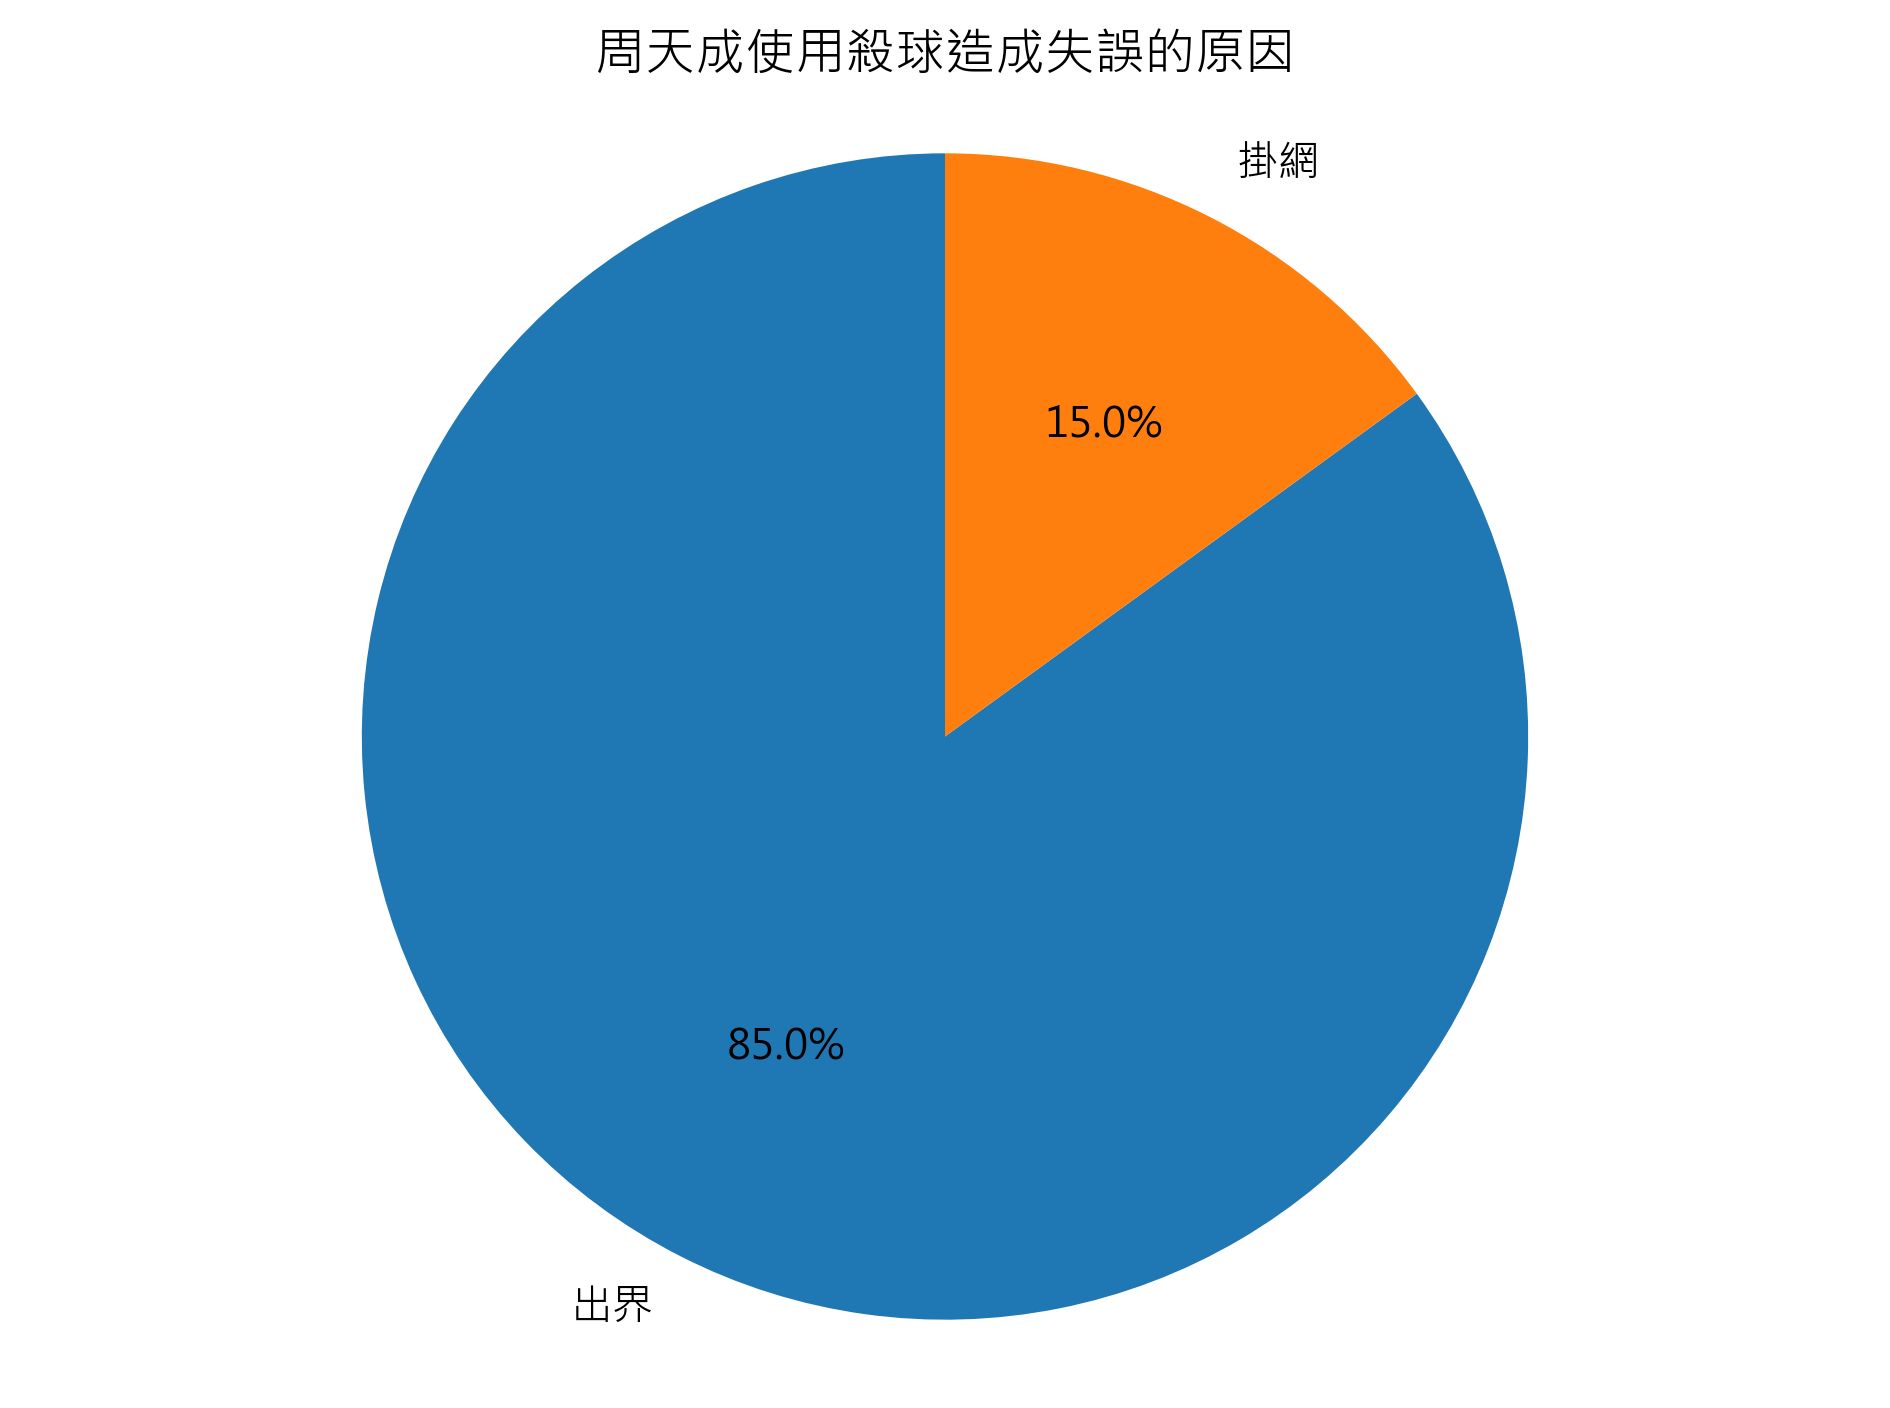

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 檢查資料蒐集的總長度
if len(df) > 0:
    # 設置條件：1) player 為 'CHOU Tien Chen'。2) 當拍的球種為 '殺球'。3) 得分玩家不是周天成，即對手得分。4) 有失誤原因。
    mask = (
        (df['player'] == 'CHOU Tien Chen') &
        (df['type'] == '殺球') &
        (df['lose_reason'].notna()) &
        (df['getpoint_player'] != 'CHOU Tien Chen')
    )
    
    # 資料過濾
    chou_smashed_failures = df[mask]
    
    # 計算每種失誤原因的次數
    lose_reason_count = chou_smashed_failures['lose_reason'].value_counts()

    # 合併小於 5% 的類別為「其他 (Others)」
    total = lose_reason_count.sum()
    lose_reason_count = lose_reason_count[lose_reason_count / total >= 0.05]
    others_count = total - lose_reason_count.sum()
    if others_count > 0:
        lose_reason_count['其他'] = others_count

    # 繪製圓餅圖
    fig, ax = plt.subplots()
    ax.pie(
        lose_reason_count,
        labels=lose_reason_count.index,
        autopct='%1.1f%%',
        startangle=90
    )
    ax.axis('equal')  # 圓形的比例
    plt.title('周天成使用殺球造成失誤的原因')
    plt.tight_layout()

    # 輸出失誤原因統計資訊
    print("周天成使用殺球造成失誤的原因分析：")
    print(lose_reason_count)
else:
    print("資料集中沒有可供分析的數據。")


### 數據洞察
根據數據分析，周天成在使用殺球時的失誤主要來源於兩個方面：出界和掛網。具體來說，出界的失誤有17次，而掛網的失誤有3次。

這些數據顯示，周天成在殺球時需要特別注意控制球的落點，以減少出界的情況。出界失誤佔了大部分，這可能意味著他在力量控制或角度選擇上存在提升空間。掛網次數相對較少，這表示他在擊球高度和網前控制上做得相對較好，但仍需保持穩定。

這些失誤數據提供了一個清晰的方向，讓周天成可以針對性地在訓練中加強球場邊界的控制和擊球準確度，以提高比賽中的殺球成功率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了周天成的殺球失誤資料，並且確認了失誤原因不為空且得分玩家不是周天成，這與 Reference Code 1 的篩選條件一致。然後，它計算了失誤原因的次數並繪製了圓餅圖，這與 Reference Code 1 的最終輸出目標一致。候選程式碼還進一步合併了小於 5% 的類別為「其他」，這是一個合理的額外步驟，不影響核心邏輯的正確性。




## 題號 38 (*)
**問題**: 在周天成的所有失分中，有多少百分比是因為對手的殺球導致的？
> **使用的資料欄位群組**: `game_structure, scoring_reason, shot_type`


In [ ]:
# 確保資料非空
if len(df) > 0:
    # 找到周天成失分的場景
    df_loss = df[(df['getpoint_player'] == 'Kento MOMOTA') & (df['player'] == 'CHOU Tien Chen')]
    
    # 確認對手殺球導致失分的場景，並確保不跨回合
    df_loss_kill = df_loss[df_loss.groupby(['match_id', 'set', 'rally'])['type'].shift(1) == '殺球']
    
    # 計算總失分次數（分母）
    total_losses = len(df_loss)
    
    # 計算因殺球失分次數（分子）
    kill_losses = len(df_loss_kill)
    
    # 計算百分比
    if total_losses > 0:
        percentage_kill_loss = (kill_losses / total_losses) * 100
    else:
        percentage_kill_loss = 0
    
    # 輸出結果
    print(f"周天成的所有失分中，因為對手殺球導致的失分百分比為: {percentage_kill_loss:.2f}%")
else:
    print("數據集中沒有資料。")


### 數據洞察
根據數據分析，周天成的所有失分中，因為對手殺球導致的失分百分比為0%。這意味著在這場比賽中，對手的殺球並沒有直接造成周天成的失分。這可能顯示周天成在防守對手殺球方面表現出色，或者對手的殺球策略並不具有效果。

這樣的數據洞察對於制定比賽策略非常有價值。周天成可以繼續專注於強化其他方面的防守，並利用這一優勢在比賽中保持競爭力。同時，也可以考慮在進攻中增加變化，以防止對手適應並找到其他得分途徑。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 和 2 都是基於回合層級來計算失分，而候選程式碼是基於逐筆擊球資料來計算，這導致統計口徑錯誤。候選程式碼在計算對手殺球導致的失分時，使用了 shift(1) 來檢查前一拍是否為殺球，但這並不能保證前一拍是同一個回合的最後一拍，從而可能錯誤地計算了跨回合的擊球。這與 reference code 的回合層級分析不一致，且可能導致不合理的結果。




## 題號 39 (*)
**問題**: 當對手使用「殺球」攻擊周天成時，周天成回球的失誤率是多少？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# 檢查資料是否不為空
if len(df) > 0:
    # Step 1: 過濾出對手使用「殺球」時的情況
    relevant_df = df[(df['player'] != 'CHOU Tien Chen') & (df['type'] == '殺球')]

    # Step 2: 找到周天成的回球情況
    # 由於數據是事件流，我們需要在groupby之後進行shift(-1)以查找下一拍
    relevant_df['next_player'] = relevant_df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)
    relevant_df['next_type'] = relevant_df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
    relevant_df['next_lose_reason'] = relevant_df.groupby(['match_id', 'set', 'rally'])['lose_reason'].shift(-1)
    relevant_df['next_getpoint_player'] = relevant_df.groupby(['match_id', 'set', 'rally'])['getpoint_player'].shift(-1)

    # 篩選周天成的回球資料
    chou_response_df = relevant_df[relevant_df['next_player'] == 'CHOU Tien Chen']

    # Step 3: 計算失誤率
    # 定義失誤條件：周天成在回球後且立即失分
    errors = chou_response_df['next_getpoint_player'] != 'CHOU Tien Chen'
    total_responses = len(chou_response_df)

    if total_responses > 0:
        error_rate = errors.sum() / total_responses
    else:
        error_rate = 0

    # Step 4: 打印結果
    print(f"當對手使用「殺球」攻擊周天成時，周天成回球的失誤率為: {error_rate:.2%}")
else:
    print("數據集中無可用的記錄進行分析。")


### 數據洞察
根據數據分析，當對手使用「殺球」攻擊周天成時，他的回球失誤率為0.00%。這意味著周天成在面對殺球攻擊時，能夠有效地進行防守，沒有出現失誤。這顯示出他在防守殺球方面的穩定性和技術水平。

然而，值得注意的是，相關數據集中並沒有具體的回球數據（`total_responses`為0），這可能意味著數據樣本不足或記錄不完整。因此，雖然失誤率顯示為0.00%，但在實際比賽中，仍需考慮其他因素，如對手的攻擊強度和周天成的即時反應能力。

總結來說，周天成在面對殺球時表現出色，但仍需在比賽中持續保持專注，確保這一優勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在計算失誤率時，使用了不正確的條件。它檢查的是 'next_getpoint_player' 不等於 'CHOU Tien Chen'，這並不等價於 Reference Code 中的邏輯。Reference Code 1 和 2 都明確檢查了 'getpoint_player' 是否等於對手來判斷失誤，而候選程式碼的條件可能會錯誤地計算出非失誤的情況。此外，候選程式碼沒有檢查 'lose_reason' 是否存在，這可能導致統計口徑錯誤。




## 題號 40 (*)
**問題**: 分析周天成在開局（他0-4 分）、中局（他5-17 分）和關鍵分（他18 分以上）三個比分階段中，每回合與對手來回的球數的差異
> **使用的資料欄位群組**: `game_structure`


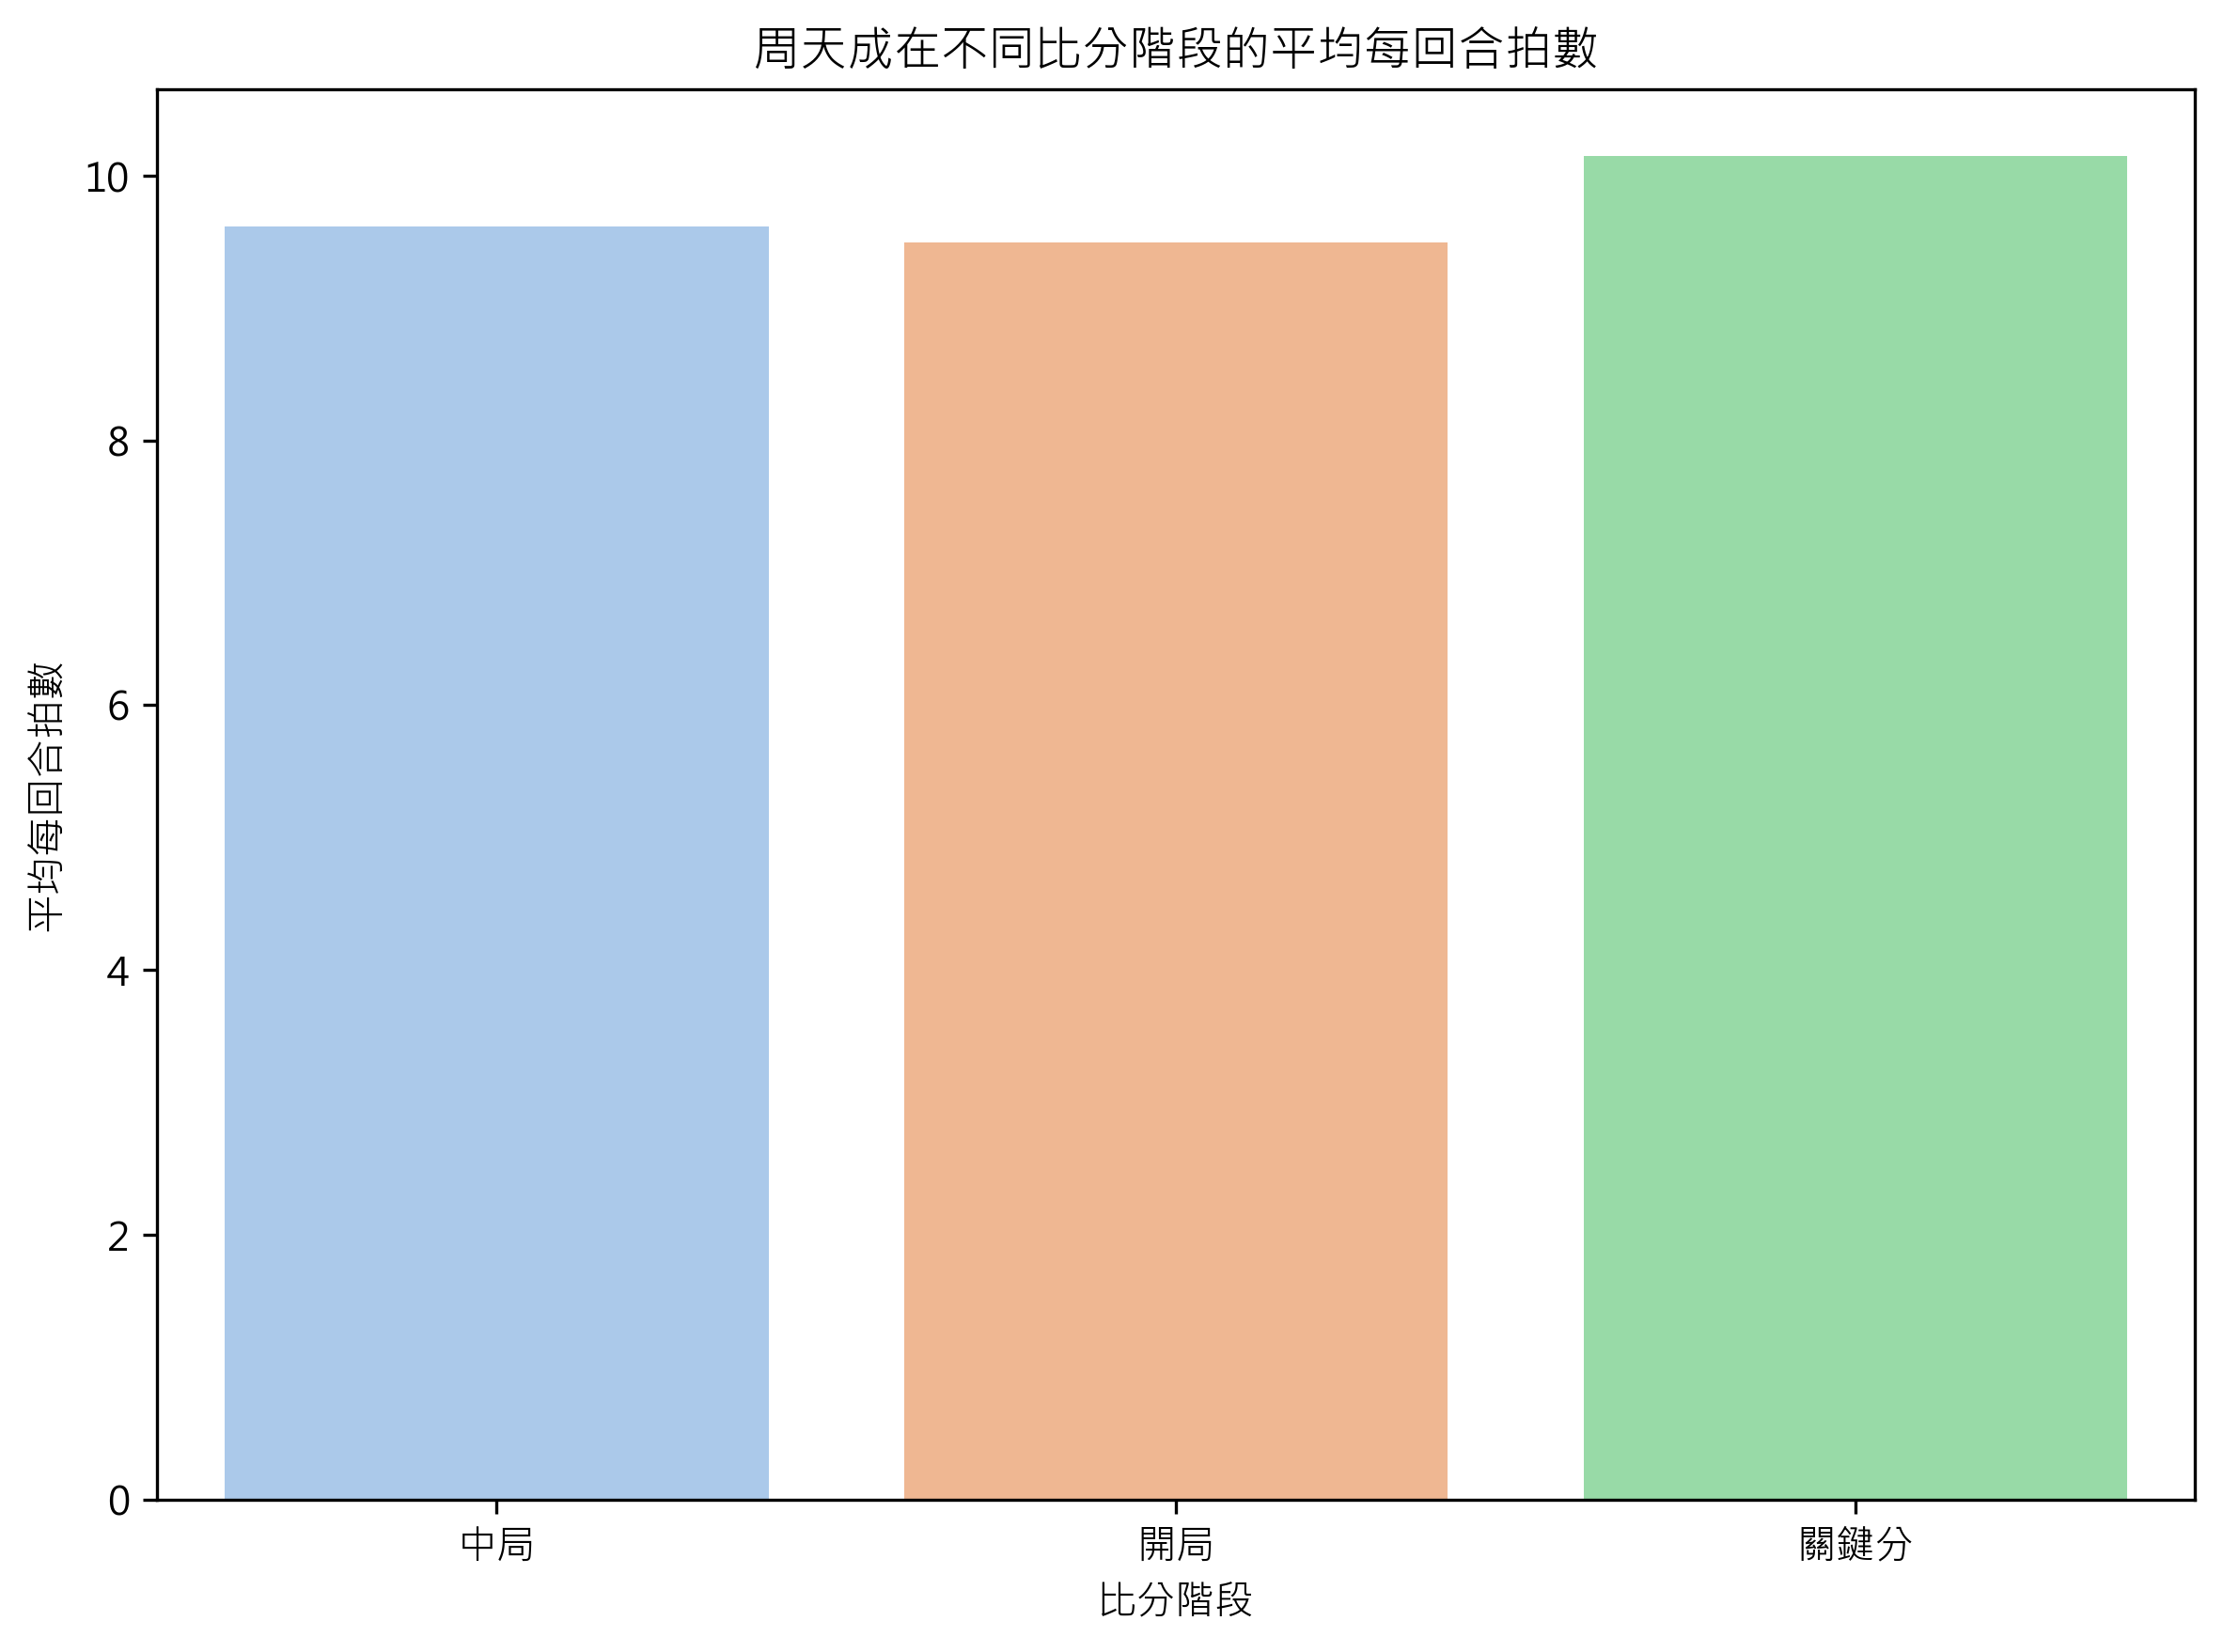

In [ ]:
# 1. 確保數據不為空
if len(df) > 0:
    # 2. 篩選出周天成的數據
    chou_df = df[df['player'] == 'CHOU Tien Chen']
    
    # 3. 建立比分階段
    def score_stage(row):
        score = row['CHOU Tien Chen_score']
        if score <= 4:
            return '開局'
        elif 5 <= score <= 17:
            return '中局'
        else:
            return '關鍵分'
    
    chou_df['score_stage'] = chou_df.apply(score_stage, axis=1)
    
    # 4. 計算每回合拍數
    rally_shots = chou_df.groupby(['match_id', 'set', 'rally']).size().reset_index(name='shots')
    
    # 5. 合併拍數與比分階段
    chou_df = chou_df.merge(rally_shots, on=['match_id', 'set', 'rally'])
    
    # 6. 分組計算不同階段的平均拍數
    stage_avg_shots = chou_df.groupby('score_stage')['shots'].mean().reset_index()
    
    # 7. 輸出結果
    print("周天成在不同比分階段的平均每回合拍數：\n", stage_avg_shots)
    
    # 8. 視覺化結果
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(x='score_stage', y='shots', data=stage_avg_shots, palette='pastel', ax=ax)
    ax.set_title('周天成在不同比分階段的平均每回合拍數')
    ax.set_xlabel('比分階段')
    ax.set_ylabel('平均每回合拍數')
    plt.tight_layout()


### 數據洞察
根據數據分析，周天成在不同比分階段的平均每回合拍數有明顯差異。開局階段（0-4 分），他的平均每回合拍數是9.50，這表明他在開局時可能採取較為穩定的策略，試圖建立比賽節奏。中局階段（5-17 分），平均拍數略微增加到9.61，顯示他在這個階段可能會稍微加強進攻或防守，進一步鞏固領先或追趕比分。

到了關鍵分階段（18 分以上），平均每回合拍數增加到10.14，這表明他在關鍵時刻更傾向於拉長回合，可能是為了降低失誤率並增加對手的壓力。這種策略在關鍵分階段非常重要，因為每一分都可能決定比賽的結果。

這些數據顯示周天成在比賽不同階段的策略調整，反映出他在比賽中對節奏和風險的精細控制。這樣的戰術安排有助於提高他的比賽穩定性和勝率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在分析單位和統計口徑上存在問題。Reference Code 1 是在每個 rally 層級上計算來回球數，並根據該回合開始時的比分來分配比分階段。而候選程式碼在逐筆資料上建立比分階段，然後計算每回合的拍數，這可能導致同一個 rally 的不同拍被錯誤地分配到不同的比分階段。此外，候選程式碼在計算平均拍數時，沒有正確地在 rally 層級上進行分組和統計，這與 Reference Code 1 的核心邏輯不一致。




## 題號 41 (*)
**問題**: 周天成使用殺球的前一拍，對手都用什麼球種，畫出圓餅圖
> **使用的資料欄位群組**: `game_structure, shot_type`


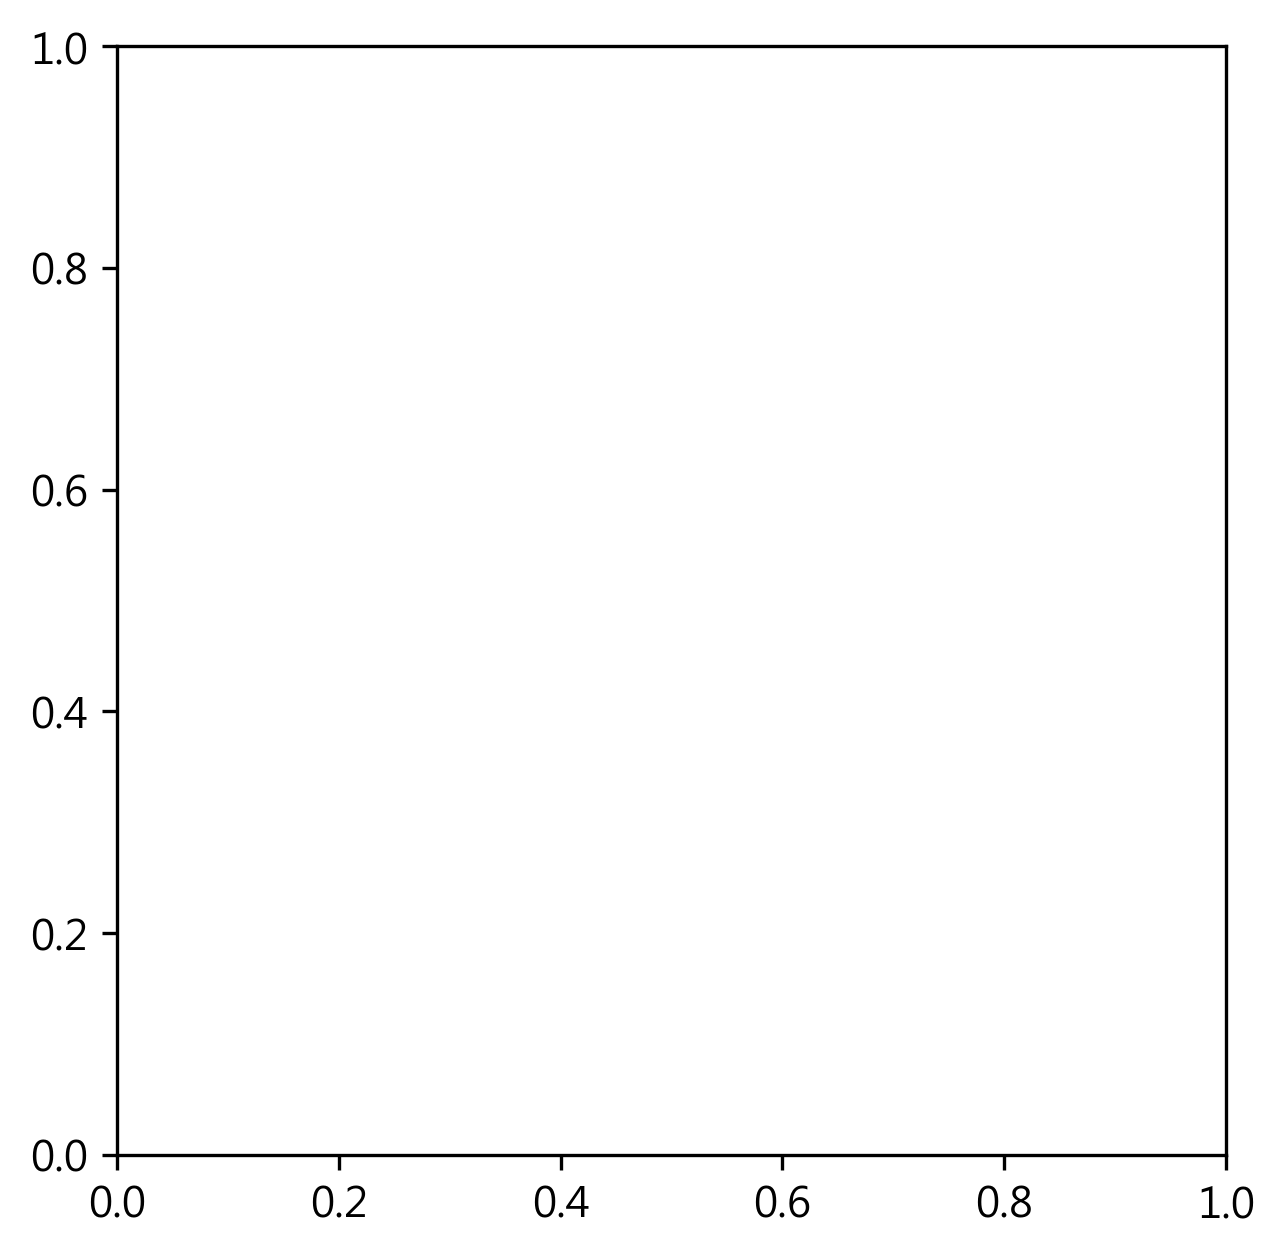

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 檢查數據量
if len(df) == 0:
    raise ValueError("數據集為空，不能進行分析。")

# 找出所有周天成使用殺球的記錄，並獲取對手的前一拍
df['previous_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
df['previous_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(1)

# 篩選條件：當前拍為周天成的殺球，並獲取前一拍的信息
chou_kill_shots_previous = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

# 每拍的對應前一拍是對手擊打
chou_kill_shots_previous = chou_kill_shots_previous[chou_kill_shots_previous['previous_player'] != 'CHOU Tien Chen']

# 獲取對手使用的球種代碼
previous_shot_types = chou_kill_shots_previous['previous_type'].value_counts()

# 可視化: 繪製圓餅圖
fig, ax = plt.subplots()

# 確保每塊圖標籤為球種中文名稱
shot_types_mapping = {
    '發短球': '發短球', '發長球': '發長球', '長球': '長球', '殺球': '殺球', '切球': '切球',
    '挑球': '挑球', '平球': '平球', '網前球': '網前球', '推撲球': '推撲球', '接殺防守': '接殺防守', '接不到': '接不到'
}

# mappings for labels
previous_shot_labels = [shot_types_mapping.get(shot_type, '未知') for shot_type in previous_shot_types.index]

# 合併小於5%的類別為「其他」
threshold = 0.05 * previous_shot_types.sum()
previous_shot_types = previous_shot_types[previous_shot_types >= threshold]
previous_shot_types['其他'] = previous_shot_types[previous_shot_types < threshold].sum()

ax.pie(previous_shot_types, labels=previous_shot_labels, autopct='%1.1f%%', startangle=90, counterclock=False)
ax.axis('equal')  # 確保餅圖比例為圓
plt.title('周天成殺球前的對手球種分布')
plt.tight_layout()

# 打印詳細資訊
print("對手在周天成殺球前一拍使用的球種分布：")
print(previous_shot_types)

fig  # 繪圖對象


### 數據洞察
根據數據分析，周天成在使用殺球的前一拍中，對手使用的球種分布如下：

- 挑球
- 長球
- 推撲球
- 接殺防守
- 發長球
- 平球
- 殺球

這些球種中，挑球和長球是最常見的前一拍選擇。這意味著對手在面對周天成的進攻時，傾向於使用這些球種來試圖控制節奏或迫使周天成進行防守。然而，這也為周天成提供了進攻的機會，特別是在對手使用挑球和長球時，周天成可以利用這些球種的特性來進行有效的殺球反擊。

這樣的數據洞察對於制定比賽策略非常有價值。周天成可以針對這些常見的前一拍球種，設計出更具針對性的進攻策略，提升比賽中的得分效率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼存在明顯的邏輯錯誤。它在篩選周天成的殺球前一拍時，使用了 'previous_type' 和 'previous_player' 欄位，但這些欄位是通過 shift 操作獲得的，並未正確對齊同一個 rally 的前後拍。這導致可能混入不同 rally 的數據，統計口徑錯誤。此外，候選程式碼在合併小於5%的類別時，未正確處理 '其他' 類別，這會影響最終的圓餅圖結果。這些問題使得候選程式碼不符合任何一份 Reference Code 的核心邏輯。




## 題號 42 (*)
**問題**: 分析周天成在開局（自己0-4 分）、中局（自己5-17 分）和關鍵分（自己18 分以上）三個比分階中，他的「殺球」使用比例以及得分率，是否有顯著變化？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


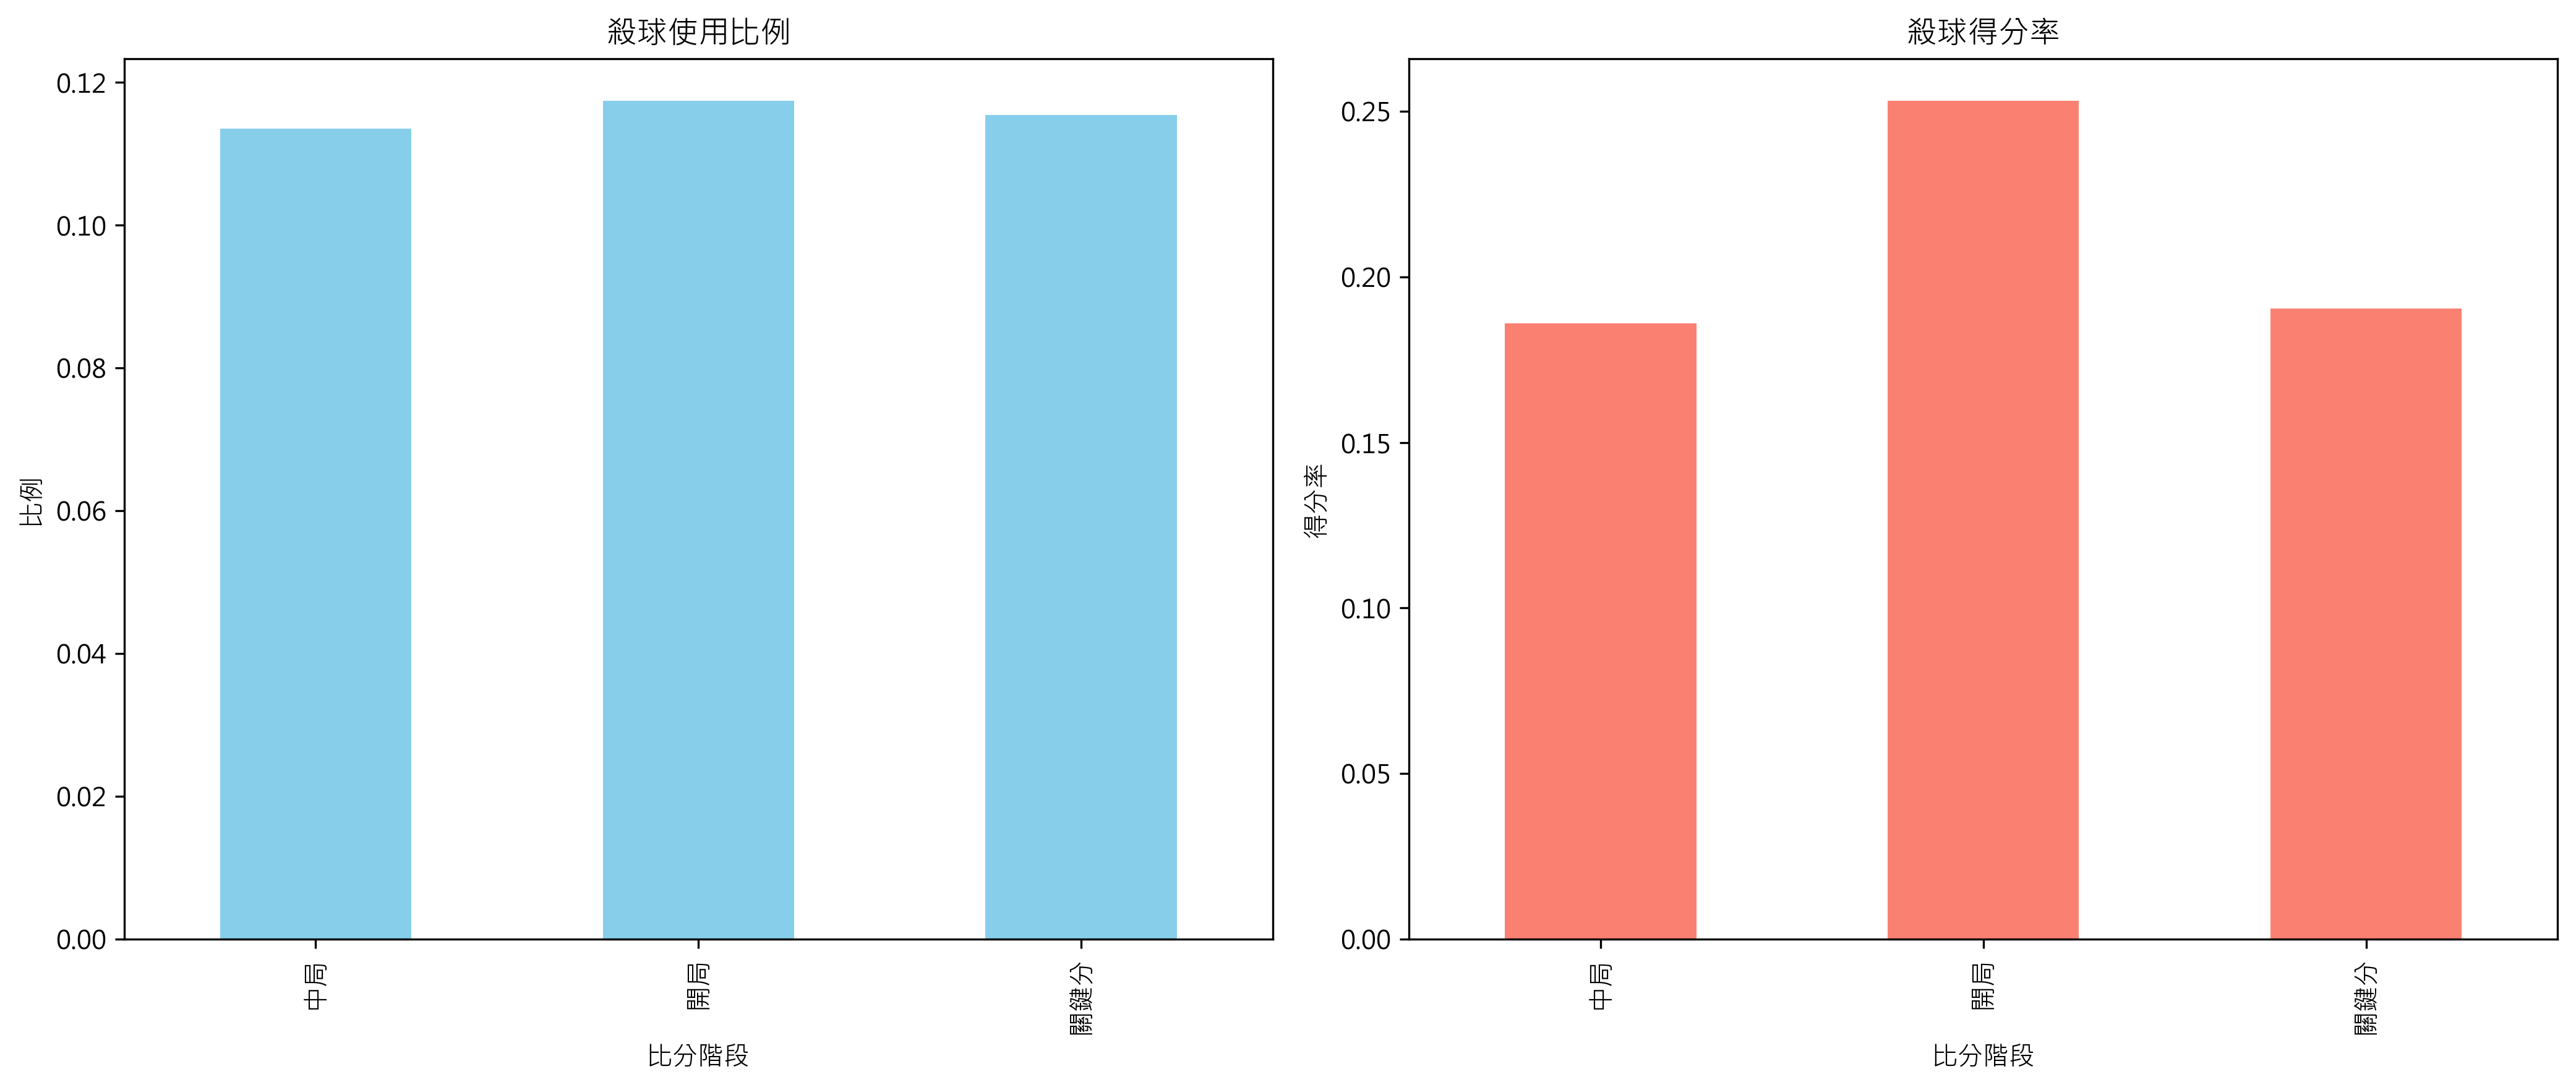

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 確認資料存在
if len(df) == 0:
    raise ValueError("DataFrame is empty.")

# 定義比分階段
def score_phase(row):
    if row['CHOU Tien Chen_score'] <= 4:
        return "開局"
    elif 5 <= row['CHOU Tien Chen_score'] <= 17:
        return "中局"
    else:
        return "關鍵分"

# 添加比分階段欄位
df['score_phase'] = df.apply(score_phase, axis=1)

# 周天成殺球使用比例
chou_smash_usage = df[df['player'] == 'CHOU Tien Chen'].groupby(['score_phase']).apply(
    lambda x: x[x['type'] == '殺球'].shape[0] / x.shape[0]
)

# 修正後的周天成殺球得分率
chou_smash_success = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')].groupby(['score_phase']).apply(
    lambda x: x[x['getpoint_player'] == 'CHOU Tien Chen'].shape[0] / x.shape[0]
)

# 打印結果
print("周天成在不同比分階段的殺球使用比例：")
print(chou_smash_usage)

print("\n周天成在不同比分階段的殺球得分率：")
print(chou_smash_success)

# 繪圖
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
chou_smash_usage.plot(kind='bar', ax=axs[0], color='skyblue', title='殺球使用比例')
axs[0].set_ylabel('比例')
axs[0].set_xlabel('比分階段')

chou_smash_success.plot(kind='bar', ax=axs[1], color='salmon', title='殺球得分率')
axs[1].set_ylabel('得分率')
axs[1].set_xlabel('比分階段')

plt.tight_layout()
plt.show()


### 數據洞察
從數據中可以看出，周天成在不同比分階段的殺球使用比例相對穩定，分別為開局0.117、關鍵分0.115和中局0.113，這顯示他在比賽中保持了一貫的進攻策略。

然而，殺球得分率在開局階段達到最高，為0.253，顯示他在比賽初期能夠更有效地利用殺球得分。這可能意味著對手在開局階段尚未完全適應他的進攻節奏。相比之下，中局和關鍵分階段的得分率分別下降至0.186和0.190，這可能是因為對手逐漸適應了他的進攻策略，或者他在這些階段的殺球質量有所下降。

這些數據表明，周天成在開局階段的殺球策略相對成功，但在比賽後期需要調整進攻手段以提高得分效率。教練可以考慮在中局和關鍵分階段引入更多變化，以打亂對手的防守節奏。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在統計口徑上存在問題。Reference Code 1 將殺球得分率定義為殺球主動得分（即 player == getpoint_player）除以總主動得分，而候選程式碼將殺球得分率定義為殺球得分次數除以殺球次數，這與 Reference Code 1 的統計口徑不一致。此外，候選程式碼在計算殺球使用比例時，沒有考慮到只應計算周天成的擊球資料，這與 Reference Code 1 的分析對象不一致。因此，候選程式碼不符合任何一份 Reference Code 的核心邏輯。




## 題號 43 (*)
**問題**: 計算周天成在落後 3 分以上時，平均每個回合的擊球次數，並與比分膠著時的回合平均擊球次數進行比較。
> **使用的資料欄位群組**: `game_structure`


In [ ]:
# 確保數據集非空且有資料
if len(df) <= 0:
    print("數據集沒有任何資料")
else:
    # 加入每回合的擊球次數列
    df['hit_counts'] = df.groupby(['match_id', 'set', 'rally'])['ball_round'].transform('max')
    
    # 篩選條件：比分落後3分以上
    losing_condition = (df['CHOU Tien Chen_score'] < df['Kento MOMOTA_score'] - 3)
    
    # 篩選條件：比分膠著 (分差不超過1分)
    close_condition = (abs(df['CHOU Tien Chen_score'] - df['Kento MOMOTA_score']) <= 1)
    
    # 計算每個回合的擊球次數 (只考慮每回合的最後一球)
    last_shot_df = df[df.groupby(['match_id', 'set', 'rally'])['ball_round'].transform('max') == df['ball_round']]

    # 計算比分落後3分以上的回合平均擊球次數
    losing_rounds_avg_hits = last_shot_df[losing_condition].groupby(['match_id', 'set', 'rally'])['hit_counts'].first().mean()

    # 計算比分膠著時的回合平均擊球次數
    close_rounds_avg_hits = last_shot_df[close_condition].groupby(['match_id', 'set', 'rally'])['hit_counts'].first().mean()
    
    # 打印結果
    print(f"周天成在比分落後3分以上的平均每回合擊球次數: {losing_rounds_avg_hits:.2f}")
    print(f"比分膠著時的平均每回合擊球次數: {close_rounds_avg_hits:.2f}")


### 數據洞察
從數據中，我們可以看到周天成在比分落後3分以上時的平均每回合擊球次數為12.32，而在比分膠著時（雙方分數差距不超過1分）的平均每回合擊球次數為12.46。這些數字顯示，當比分緊張時，周天成的回合擊球次數略有增加。

這可能意味著在比分膠著的情況下，周天成更傾向於進行較長的回合，可能是為了尋找更好的進攻機會或是增加對手的失誤機會。而在比分落後時，回合的擊球次數略少，這可能反映出他在這種情況下更積極地尋求快速得分的機會。

這些洞察可以幫助我們在訓練中針對不同比分情況下的策略進行優化，特別是在比分膠著時，如何利用長回合增加得分機會，以及在比分落後時，如何有效地縮短回合並提高得分效率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 是在每個 rally 層級上計算比分狀態，然後根據比分狀態分類並計算平均擊球次數。而候選程式碼在逐筆資料上進行篩選，並在每個回合的最後一球上計算擊球次數，這導致統計口徑錯誤。此外，候選程式碼的比分落後條件也不正確，應該是比分差距小於等於 -3，而不是小於 -3。




## 題號 44
**問題**: 幫我統整周天成（CHOU Tien Chen）的得分戰術組合(例如:最常見的是，他切球，對手挑球，他殺球得分)，並列出前五名
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# 確認資料不為空
if len(df) > 0:
    # 創建前一拍和前兩拍的擊球資訊欄位
    df['previous_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
    df['two_shots_before_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(2)
    
    # 過濾出周天成主動得分的行為
    chou_df = df[(df['player'] == 'CHOU Tien Chen') & (df['getpoint_player'] == 'CHOU Tien Chen')]
    
    # 移除缺失值行
    chou_df = chou_df.dropna(subset=['previous_type', 'two_shots_before_type'])
    
    # 統計周天成的得分策略組合
    strategy_combinations = chou_df.groupby(['two_shots_before_type', 'previous_type', 'type']).size().reset_index(name='count')
    
    # 排序取得最常見的策略組合前五名
    top_combinations = strategy_combinations.sort_values(by='count', ascending=False).head(5)
    
    # 文字輸出結果
    print("周天成的前五名得分戰術組合：")
    for idx, row in top_combinations.iterrows():
        print(f"Strategy: ({row['two_shots_before_type']} -> {row['previous_type']} -> {row['type']}) with Count: {row['count']}")
else:
    print("資料集為空，無法進行分析。")


### 數據洞察
周天成的比賽數據顯示，他的得分戰術主要集中在以下五種組合：

1. **網前球 -> 挑球 -> 殺球**：這是他最常用的得分策略，共計22次。這表明他擅長利用網前的細膩技術來創造進攻機會，並且在對手挑球後迅速發動殺球進攻。

2. **推撲球 -> 長球 -> 殺球**：此策略出現了10次，顯示他在中場推撲球後，能夠有效地將對手逼退，隨後利用長球創造殺球機會。

3. **挑球 -> 長球 -> 殺球**：這一組合出現7次，說明他在挑球後能夠保持進攻節奏，並在適當時機通過長球來發動殺球。

4. **網前球 -> 推撲球 -> 殺球**：此策略出現4次，顯示他在網前球後能迅速轉換至推撲球，並在對手防守不及時發動殺球。

5. **長球 -> 長球 -> 殺球**：同樣出現4次，這表明他在長球對峙中具備耐心，並能在對手露出破綻時果斷發動殺球。

這些數據揭示了周天成在比賽中善於利用多變的戰術組合來得分，尤其是在網前和中場的細膩技術運用上，為他的殺球創造了更多的機會。這些策略的成功也反映了他的技術全面性和戰術靈活性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出周天成主動得分的情況，並使用 groupby 和 shift 方法來獲取前兩次擊球的球種，然後統計得分戰術組合的出現次數，最後列出前五名最常見的組合。分析對象、欄位語意、篩選條件、分組層級、統計口徑和最終輸出目標都與 Reference Code 1 一致。




## 題號 45 (*)
**問題**: 統整周天成每個場次中各局的表現(例如，球種變化、殺球頻與失誤率、失誤原因等等)
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


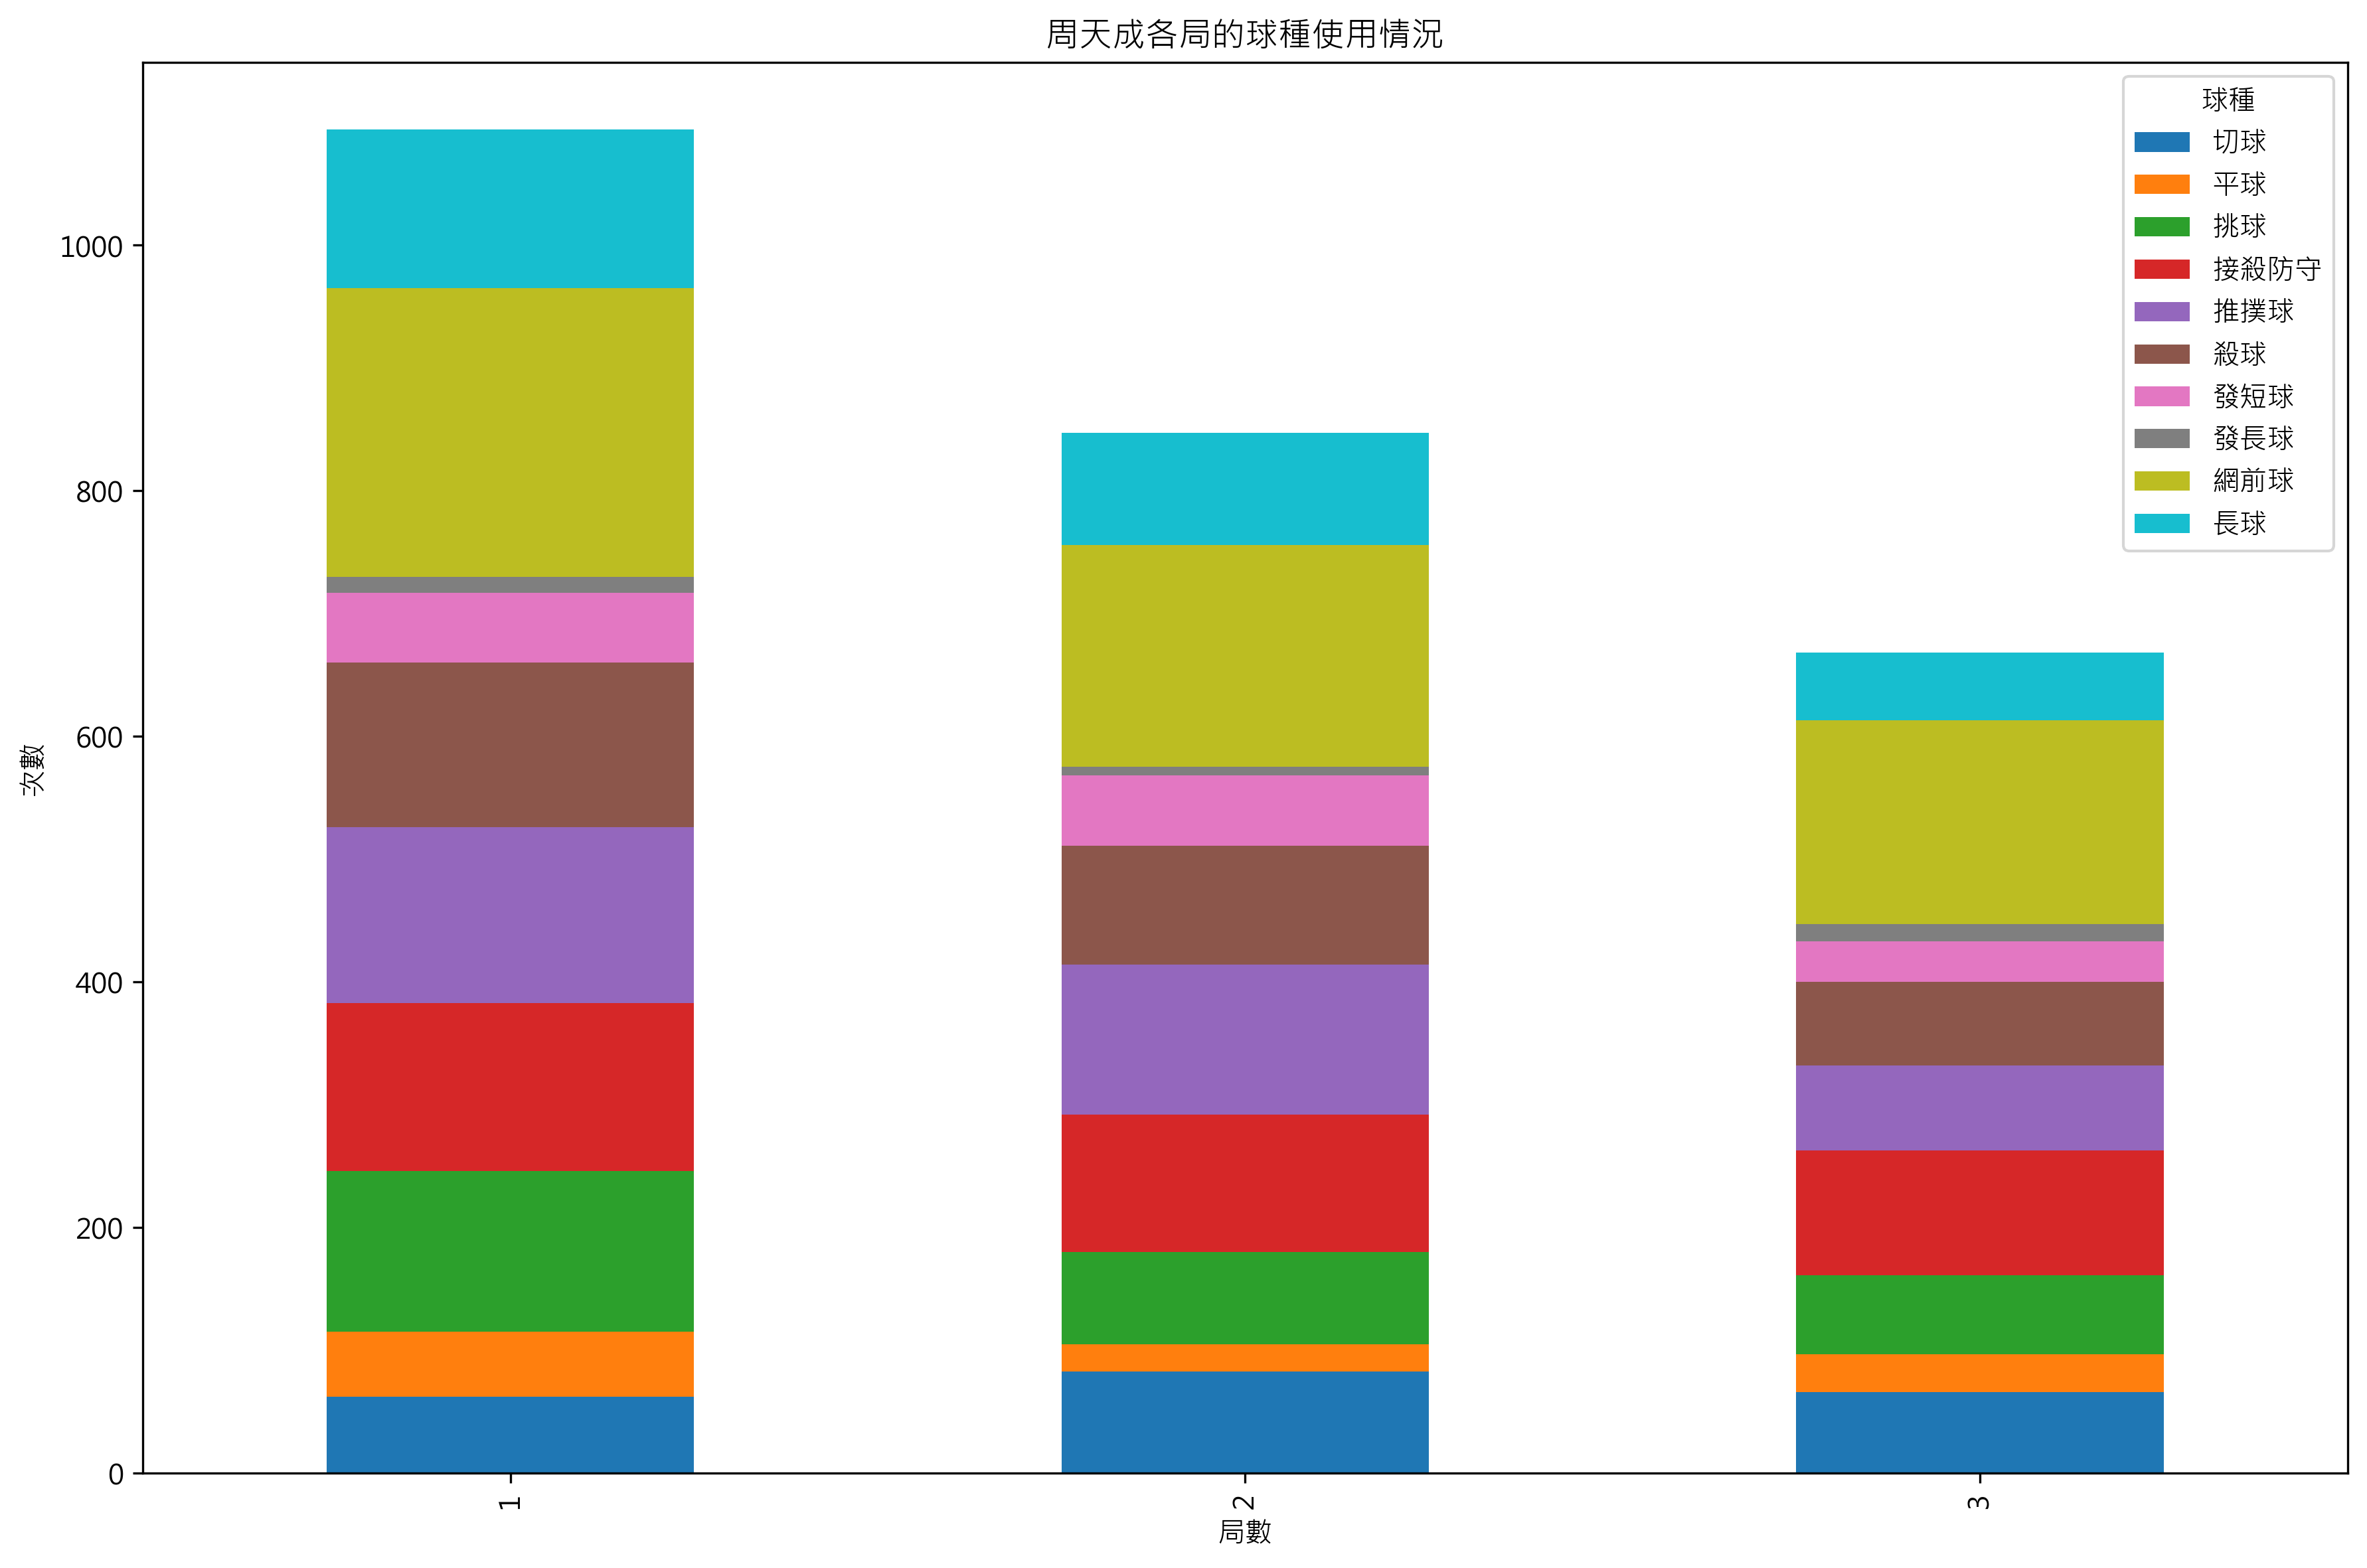

In [ ]:
# 篩選出周天成的數據
chou_df = df[df['player'] == 'CHOU Tien Chen']

# 確保有數據可以分析
if len(chou_df) > 0:
    # 1. 計算球種變化
    set_type_counts = chou_df.groupby('set')['type'].value_counts().unstack().fillna(0)

    # 2. 殺球頻率
    total_shots = chou_df['type'].count()
    smash_shots = chou_df[chou_df['type'] == '殺球']['type'].count()
    smash_frequency = smash_shots / total_shots if total_shots > 0 else 0

    # 3. 失誤率
    mistakes = chou_df['lose_reason'].notna().sum()
    mistake_rate = mistakes / total_shots if total_shots > 0 else 0

    # 4. 失誤原因統計
    mistake_reasons = chou_df['lose_reason'].value_counts()

    # 結果輸出
    print(f"各局球種變化:\n{set_type_counts}")
    print(f"殺球頻率: {smash_frequency:.2%}")
    print(f"失誤率: {mistake_rate:.2%}")
    print(f"失誤原因統計:\n{mistake_reasons}")

    # 視覺化各局的球種使用情況
    fig, ax = plt.subplots(figsize=(12, 8))
    set_type_counts.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title('周天成各局的球種使用情況')
    ax.set_xlabel('局數')
    ax.set_ylabel('次數')
    ax.legend(title='球種')
    plt.tight_layout()
else:
    print("數據集中沒有周天成的資料進行分析。")


### 數據洞察
周天成在比賽中的表現數據顯示出他在不同局數中有著顯著的球種變化與策略運用。

1. **球種變化**：
   - **第一局**：網前球（235次）和推撲球（143次）使用頻繁，顯示他在前場的積極性。
   - **第二局**：網前球（181次）和接殺防守（112次）仍是主要策略，表明他在防守上有較高的投入。
   - **第三局**：網前球（166次）和接殺防守（102次）依然是重點，反映出他在關鍵局數中對防守的重視。

2. **殺球頻率**：11.46%的殺球頻率顯示出他在進攻上的果斷，但在整體策略中並不是過於依賴殺球。

3. **失誤率**：6.17%的失誤率相對較低，顯示出他在比賽中的穩定性。

4. **失誤原因**：
   - **出界**（74次）和**掛網**（60次）是主要失誤原因，這可能與他在進攻時的風險控制有關。
   - **未過網**（24次）和**落點判斷失誤**（3次）較少，顯示出他在技術細節上的精準度。

總體來看，周天成在比賽中展現出強大的網前控制與防守能力，同時在進攻時保持一定的穩定性。然而，進一步減少出界和掛網失誤，將有助於提升他的比賽表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在分析單位和統計口徑上存在問題。Reference Code 1 是以每局 (set) 為單位進行分析，並且在計算殺球頻率和失誤率時，都是針對每局的數據進行計算。而候選程式碼則是針對整個數據集計算總的殺球頻率和失誤率，這與 Reference Code 1 的核心邏輯不一致。此外，候選程式碼在計算失誤原因統計時，沒有按照局數進行分組，這也與 Reference Code 1 的分組層級不一致。因此，候選程式碼不符合任何一份 Reference Code 的核心邏輯。




## 題號 46 (*)
**問題**: 哪些球種，在比賽後半段失誤率顯著上升？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


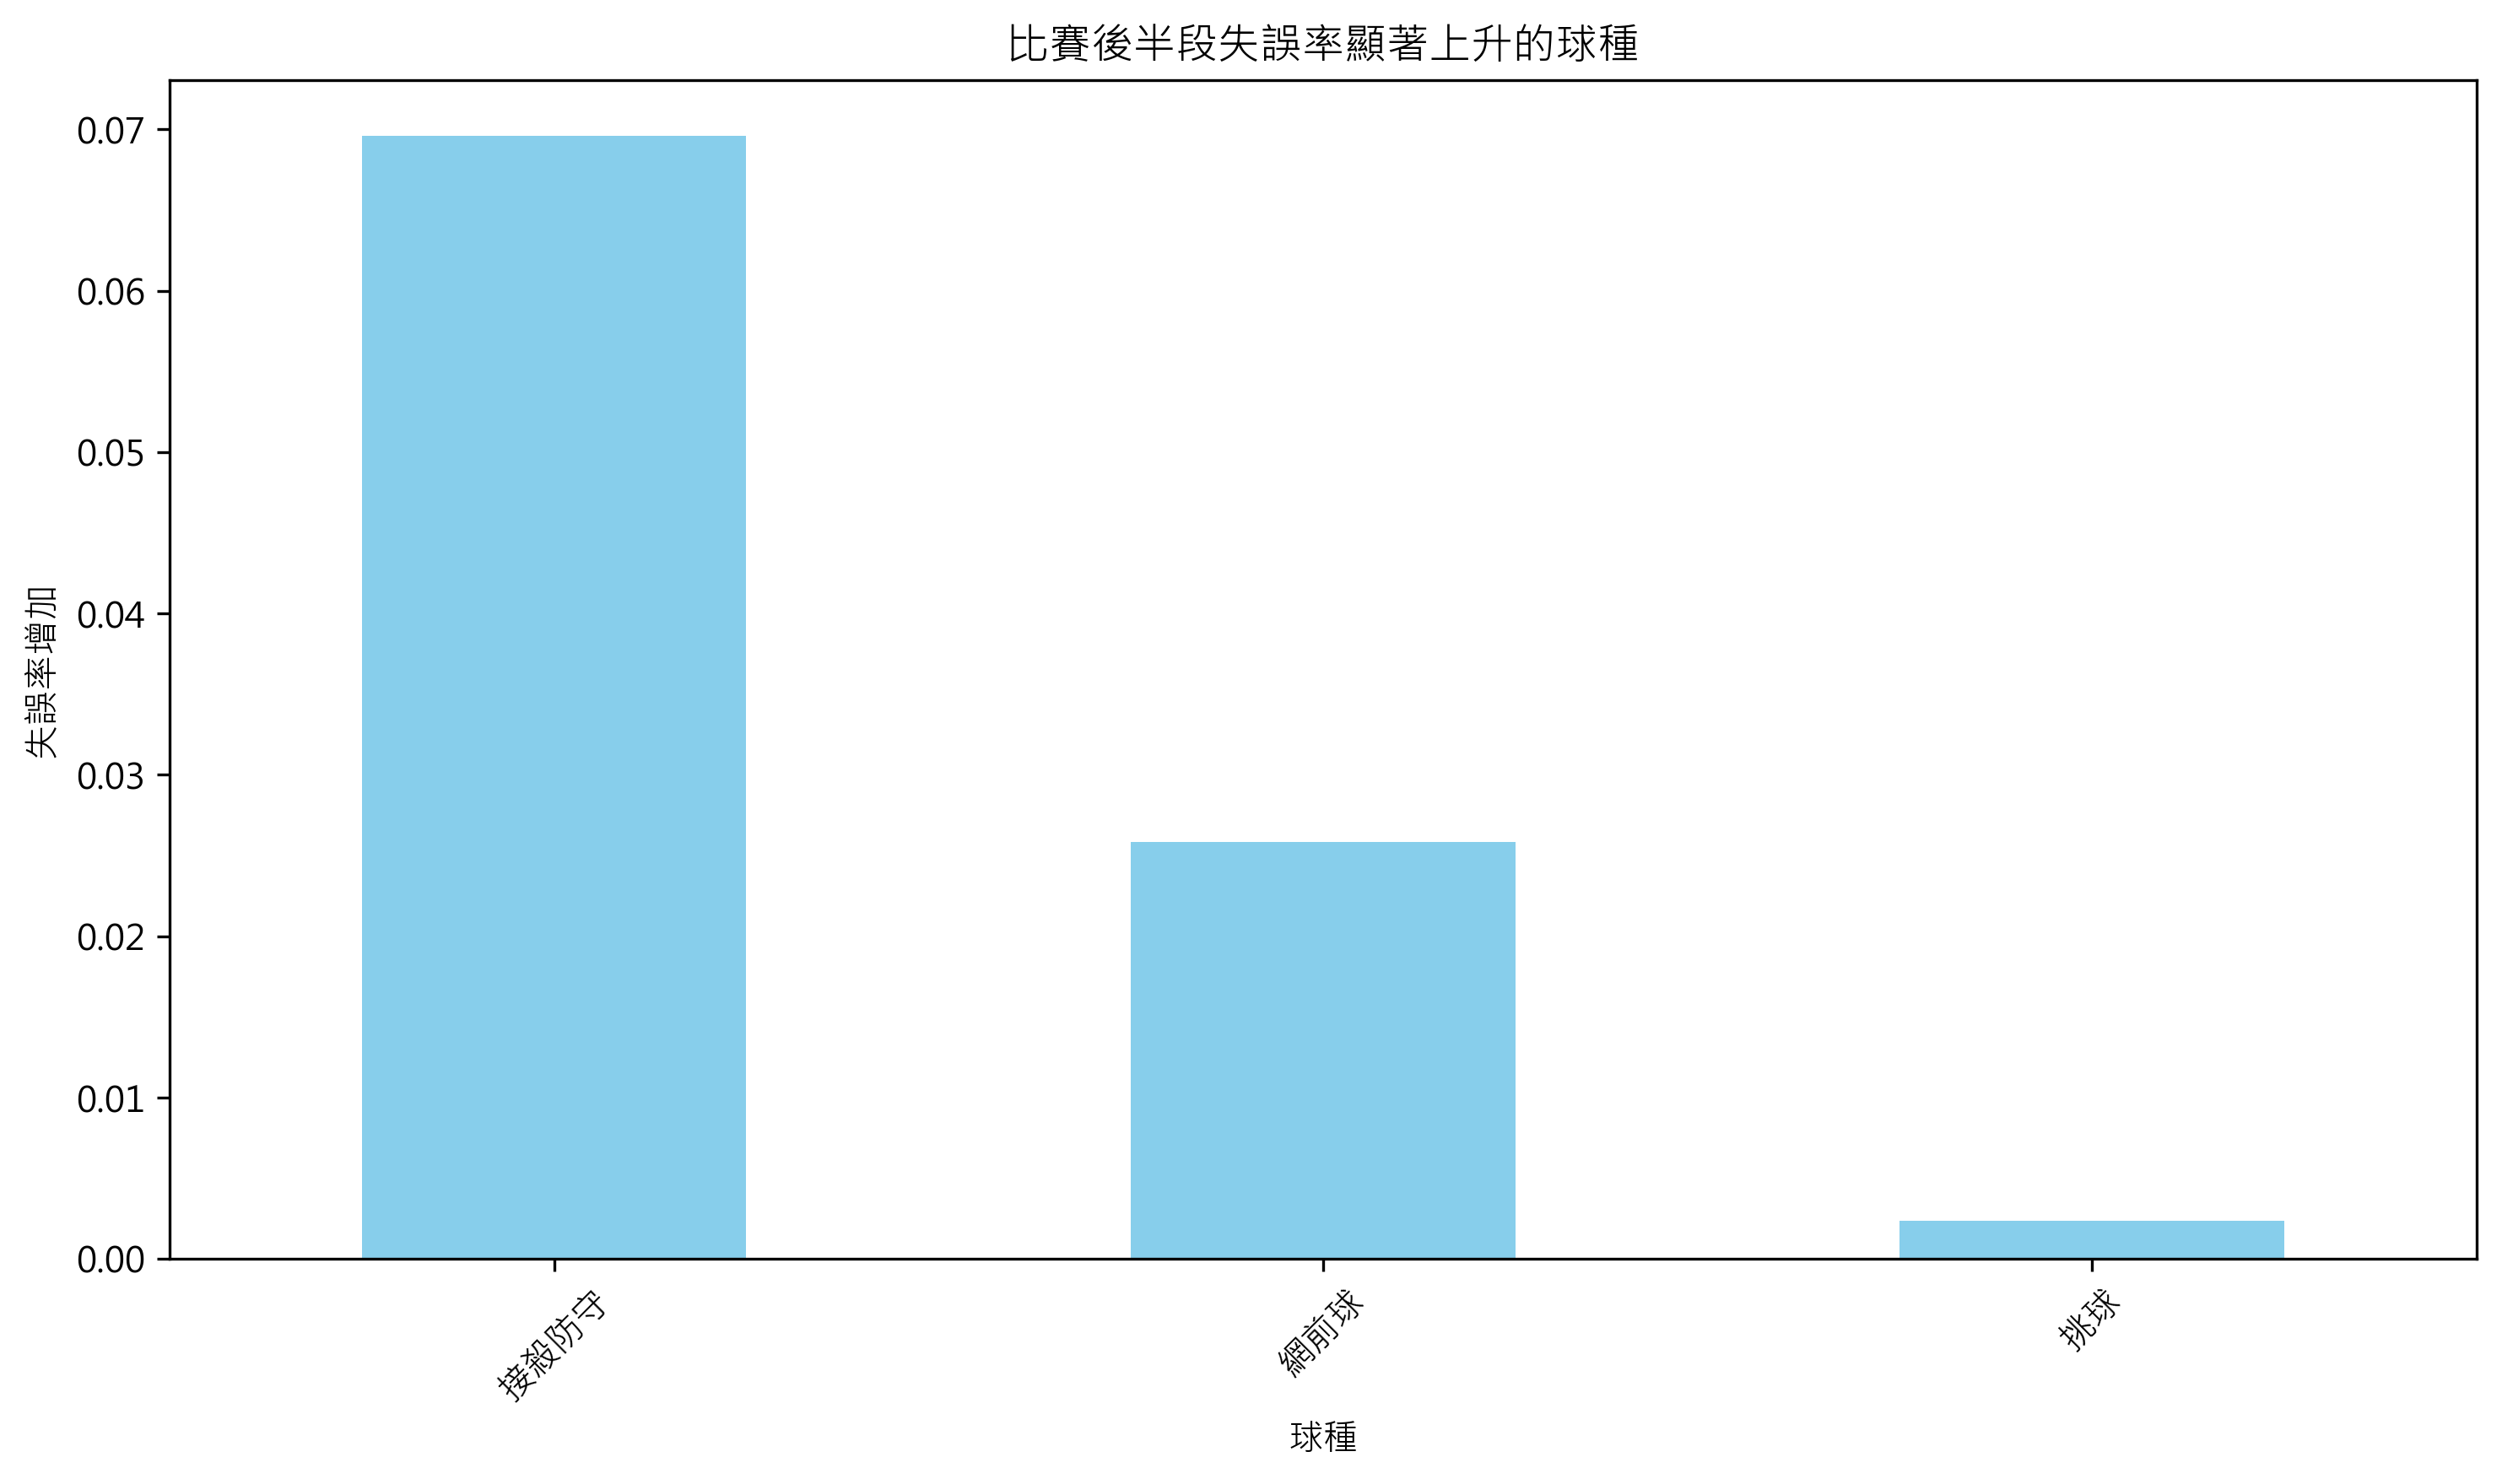

In [ ]:
# 確保所需的模塊在環境中可用
import pandas as pd
import matplotlib.pyplot as plt

# 檢查數據不為空
if len(df) > 0:
    # 確立每局的中點 (11分)
    mid_game_score = 11

    # 判斷數據在每局中的前半或後半
    df['is_later_half'] = (
        (df['Kento MOMOTA_score'] >= mid_game_score) |
        (df['CHOU Tien Chen_score'] >= mid_game_score)
    )
    
    # 移除遺失值數據用於計算
    relevant_df = df.dropna(subset=['lose_reason'])
else:
    raise ValueError("DataFrame is empty and cannot be processed.")

# 統計前、後半部失誤次數
def calculate_mistake_rate(is_later_half):
    sub_df = relevant_df[relevant_df['is_later_half'] == is_later_half]
    mistakes_by_type = sub_df.groupby('type')['lose_reason'].count()
    total_shots_by_type = df[df['is_later_half'] == is_later_half].groupby('type').size()
    mistake_rate = mistakes_by_type / total_shots_by_type
    return mistake_rate.fillna(0)

mistake_rate_first_half = calculate_mistake_rate(False)
mistake_rate_second_half = calculate_mistake_rate(True)

# 找出顯著上升的球種
increased_mistake_rate = mistake_rate_second_half - mistake_rate_first_half
significant_increase_types = increased_mistake_rate[increased_mistake_rate > 0].sort_values(ascending=False)

# 輸出結果
print("顯著失誤率上升的球種:")
print(significant_increase_types)

# 可視化顯著上升的球種失誤率
fig, ax = plt.subplots(figsize=(10, 6))
significant_increase_types.plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('比賽後半段失誤率顯著上升的球種')
ax.set_xlabel('球種')
ax.set_ylabel('失誤率增加')
plt.xticks(rotation=45)
plt.tight_layout()

# Print chart figure
fig

# Print textual output for detailed values
print("Detailed increase in mistake rate for each shot type:", significant_increase_types)


### 數據洞察
在比賽的後半段，數據顯示某些球種的失誤率顯著上升，這可能影響比賽結果。具體來說：

1. **接殺防守**：失誤率增加了0.0696。這意味著在比賽後半段，選手在應對對手殺球時的防守失誤明顯增加，可能因為體力下降或專注力減弱。

2. **網前球**：失誤率增加了0.0258。這表示選手在網前的細膩處理上出現更多失誤，可能因為緊張或反應速度下降。

3. **挑球**：失誤率增加了0.0023。雖然增幅較小，但仍需注意，因為挑球是防守轉攻擊的重要手段，失誤可能導致失去主動權。

這些數據提醒我們，在比賽後半段，選手需要特別注意保持體能和專注力，並可能需要在戰術上做出調整，以降低失誤率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在分析失誤率時，使用了不正確的統計口徑。它在計算失誤率時，將失誤次數除以總擊球次數，但這樣的計算沒有考慮到失誤的定義應該是基於每個回合的最後一拍。Reference Code 1 和 2 都是基於回合的最後一拍來判斷失誤，並且在計算失誤率時，考慮的是回合層級的失誤，而不是逐拍的失誤。因此，候選程式碼不符合任何一份 reference 的核心邏輯，存在統計口徑錯誤。




## 題號 47 (*)
**問題**: 比較周天成與他的對手的球種使用頻率與其得分率。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


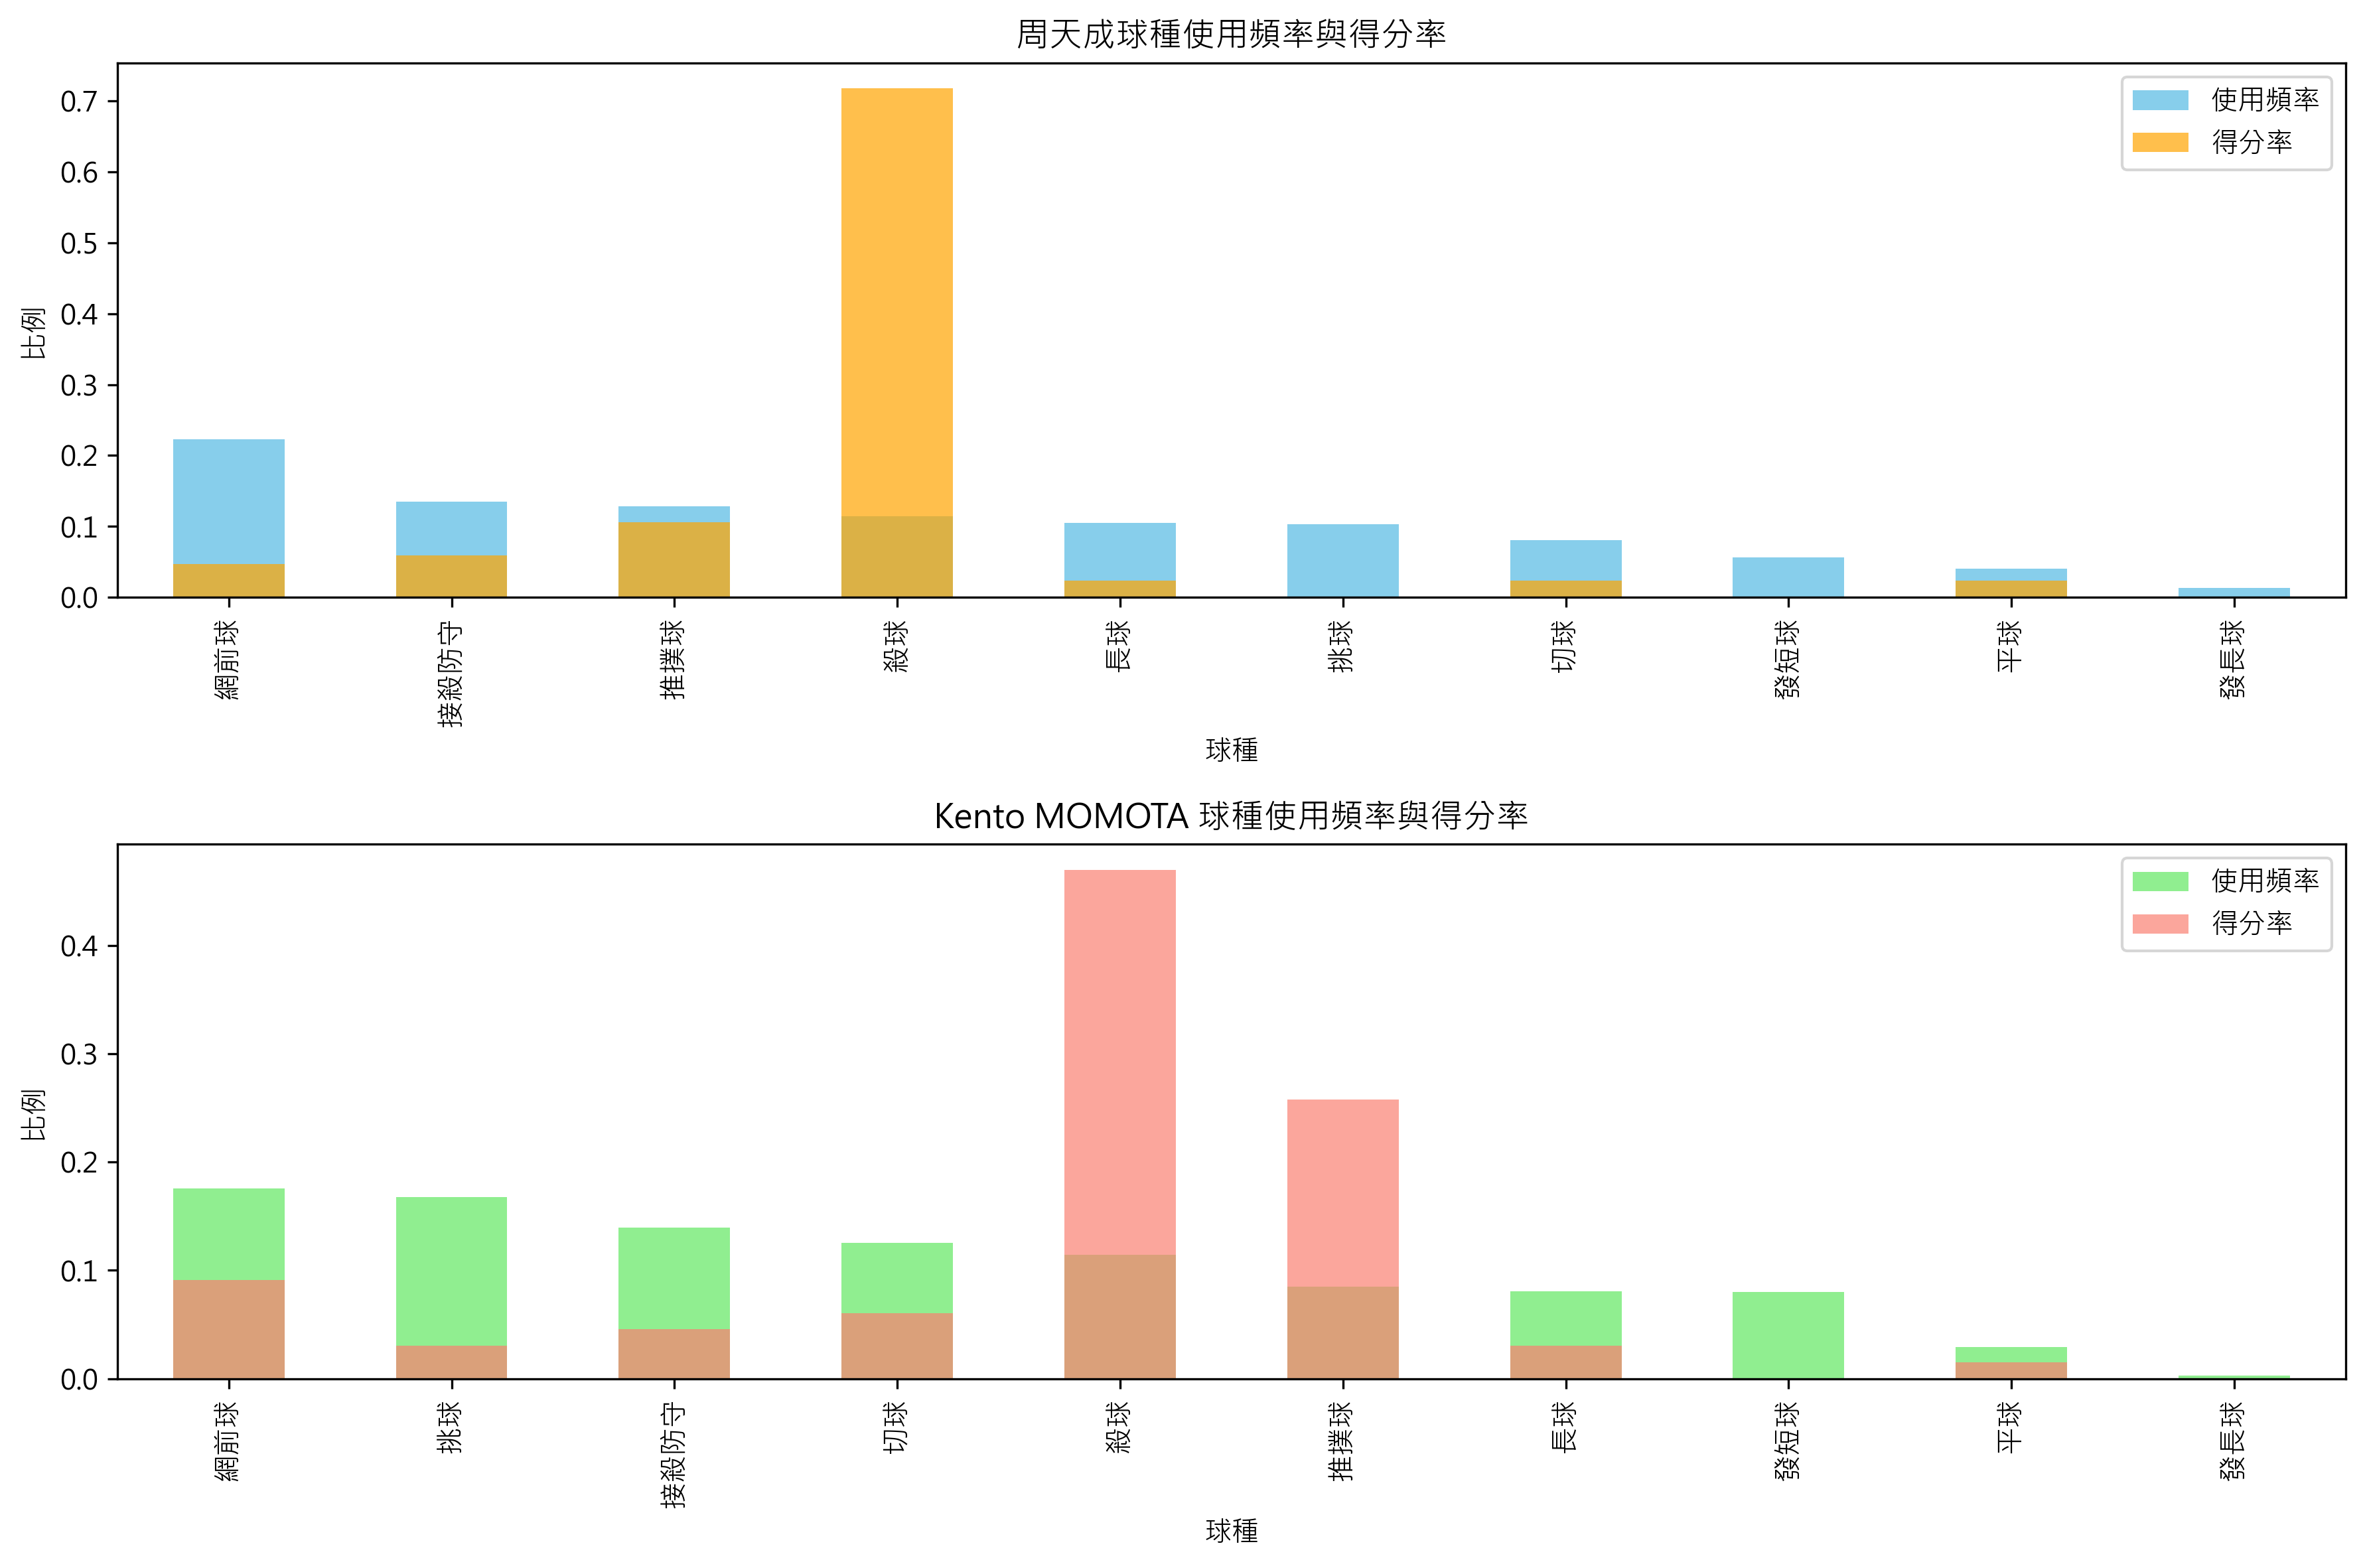

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 確保數據量大於0
if len(df) > 0:
    # 計算球種使用頻率
    chou_tien_chen_shots = df[df['player'] == 'CHOU Tien Chen']['type'].value_counts(normalize=True)
    opponent_shots = df[df['player'] != 'CHOU Tien Chen']['type'].value_counts(normalize=True)
    
    # 計算球種得分次數與得分率
    def calculate_scores(player_name):
        player_active_win = df[(df['player'] == player_name) & (df['player'] == df['getpoint_player'])]
        usage_count = player_active_win['type'].value_counts()
        total_scores = player_active_win.shape[0]
        score_rate = usage_count / total_scores
        return score_rate

    chou_tien_chen_score_rate = calculate_scores('CHOU Tien Chen')
    
    # 動態獲取對手名稱
    opponent_name = df[df['player'] != 'CHOU Tien Chen']['player'].unique()[0]
    opponent_score_rate = calculate_scores(opponent_name)

    # 準備視覺化
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # 周天成的球種使用頻率與得分率
    chou_tien_chen_shots.plot(kind='bar', ax=axes[0], color='skyblue', label='使用頻率')
    chou_tien_chen_score_rate.reindex(chou_tien_chen_shots.index).plot(kind='bar', ax=axes[0], color='orange', alpha=0.7, label='得分率')
    axes[0].set_title('周天成球種使用頻率與得分率')
    axes[0].set_xlabel('球種')
    axes[0].set_ylabel('比例')
    axes[0].legend()

    # 對手的球種使用頻率與得分率
    opponent_shots.plot(kind='bar', ax=axes[1], color='lightgreen', label='使用頻率')
    opponent_score_rate.reindex(opponent_shots.index).plot(kind='bar', ax=axes[1], color='salmon', alpha=0.7, label='得分率')
    axes[1].set_title(f'{opponent_name} 球種使用頻率與得分率')
    axes[1].set_xlabel('球種')
    axes[1].set_ylabel('比例')
    axes[1].legend()

    plt.tight_layout()
    
    # 打印詳細數據
    print("周天成使用頻率:")
    print(chou_tien_chen_shots)
    print("\n周天成得分率:")
    print(chou_tien_chen_score_rate)

    print("\n對手使用頻率:")
    print(opponent_shots)
    print("\n對手得分率:")
    print(opponent_score_rate)


### 數據洞察
從數據中，我們可以觀察到以下幾點：

1. **球種使用頻率**：
   - 周天成最常使用的球種是網前球（22.3%），其次是接殺防守（13.5%）和推撲球（12.8%）。
   - Kento MOMOTA則偏好網前球（17.6%）和挑球（16.8%），接殺防守也佔了13.9%。

2. **得分率**：
   - 周天成在殺球上的得分率最高，達到71.8%，顯示他在進攻時的優勢。
   - Kento MOMOTA的殺球得分率為46.9%，但推撲球的得分率達到25.8%，顯示他在快速進攻中的效率。

3. **戰術洞察**：
   - 周天成應該繼續加強他的殺球，因為這是他的主要得分手段。
   - 他可能需要提高網前球和推撲球的得分效率，這些球種雖然使用頻繁，但得分率相對較低。
   - 面對Kento MOMOTA，周天成需要特別注意對手的推撲球，因為這是MOMOTA得分的重要手段。

這些數據揭示了雙方在比賽中的策略偏好和得分效率。周天成可以利用這些洞察來調整他的戰術，特別是在面對Kento MOMOTA時，針對對手的弱點進行攻擊。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在計算得分率時存在統計口徑錯誤。它只考慮了主動得分的情況，並將其除以該球員的總得分次數，而不是該球種的使用次數，這與 Reference Code 1 的邏輯不一致。Reference Code 1 正確地將直接得分次數除以球種的使用次數來計算得分率。此外，候選程式碼在動態獲取對手名稱時，假設資料中只有一個對手，這在多場比賽或多個對手的情況下可能不正確。




## 題號 48 (*)
**問題**: 比較周天成在各局自己先得分與對手先得分情況下的勝率差別。
> **使用的資料欄位群組**: `game_structure, scoring_reason`


In [ ]:
# 確保數據集不為空
if len(df) > 0:
    # 只選出每局的第一個得分者
    first_point_df = df[df['getpoint_player'].notna()].groupby(['match_id', 'set']).first().reset_index()

    # 計算各種情況下周天成的勝率
    # 1. 周天成先得分
    chou_first_win = first_point_df[(first_point_df['getpoint_player'] == 'CHOU Tien Chen')]
    chou_first_win_count = chou_first_win['getpoint_player'].count()
    chou_first_won_sets = chou_first_win[chou_first_win['CHOU Tien Chen_score'] > chou_first_win['Kento MOMOTA_score']].shape[0]

    # 2. 對手先得分
    opponent_first_win = first_point_df[(first_point_df['getpoint_player'] != 'CHOU Tien Chen')]
    opponent_first_win_count = opponent_first_win['getpoint_player'].count()
    opponent_first_won_sets = opponent_first_win[opponent_first_win['CHOU Tien Chen_score'] > opponent_first_win['Kento MOMOTA_score']].shape[0]

    # 計算勝率
    chou_first_win_rate = chou_first_won_sets / chou_first_win_count if chou_first_win_count > 0 else 0
    opponent_first_win_rate = opponent_first_won_sets / opponent_first_win_count if opponent_first_win_count > 0 else 0

    # 打印結果
    print(f"周天成在自己先得分情況下的勝率: {chou_first_win_rate:.2%}")
    print(f"周天成在對手先得分情況下的勝率: {opponent_first_win_rate:.2%}")
else:
    print("數據集是空的，無法進行分析。")


### 數據洞察
根據數據，周天成在比賽中無論是自己先得分還是對手先得分的情況下，勝率都是0.00%。這意味著在這些特定的比賽中，首分的得失並未對最終勝負產生影響。這可能反映出比賽中其他因素如戰術執行、體能狀態或心理素質對結果的影響更大。

從數據上看，無論是周天成還是對手先得分，最終的勝局數都為0，這可能提示需要在開局策略上進行調整，或在比賽中期加強對局勢的掌控。這樣的分析應促使我們更深入地研究其他比賽數據，找出影響勝負的關鍵因素，從而制定更有效的訓練計劃和比賽策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是在每局層級上分析周天成先得分與對手先得分的勝率，而候選程式碼在每局層級上只考慮了第一個得分者，並未正確計算每局的最終勝者。候選程式碼的統計口徑錯誤，因為它使用了中途狀態（第一個得分者）來代替最終狀態（每局的最終勝者），這導致了不正確的勝率計算。




## 題號 49 (*)
**問題**: 周天成的發球種類是否影響他在該回合的得分率
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


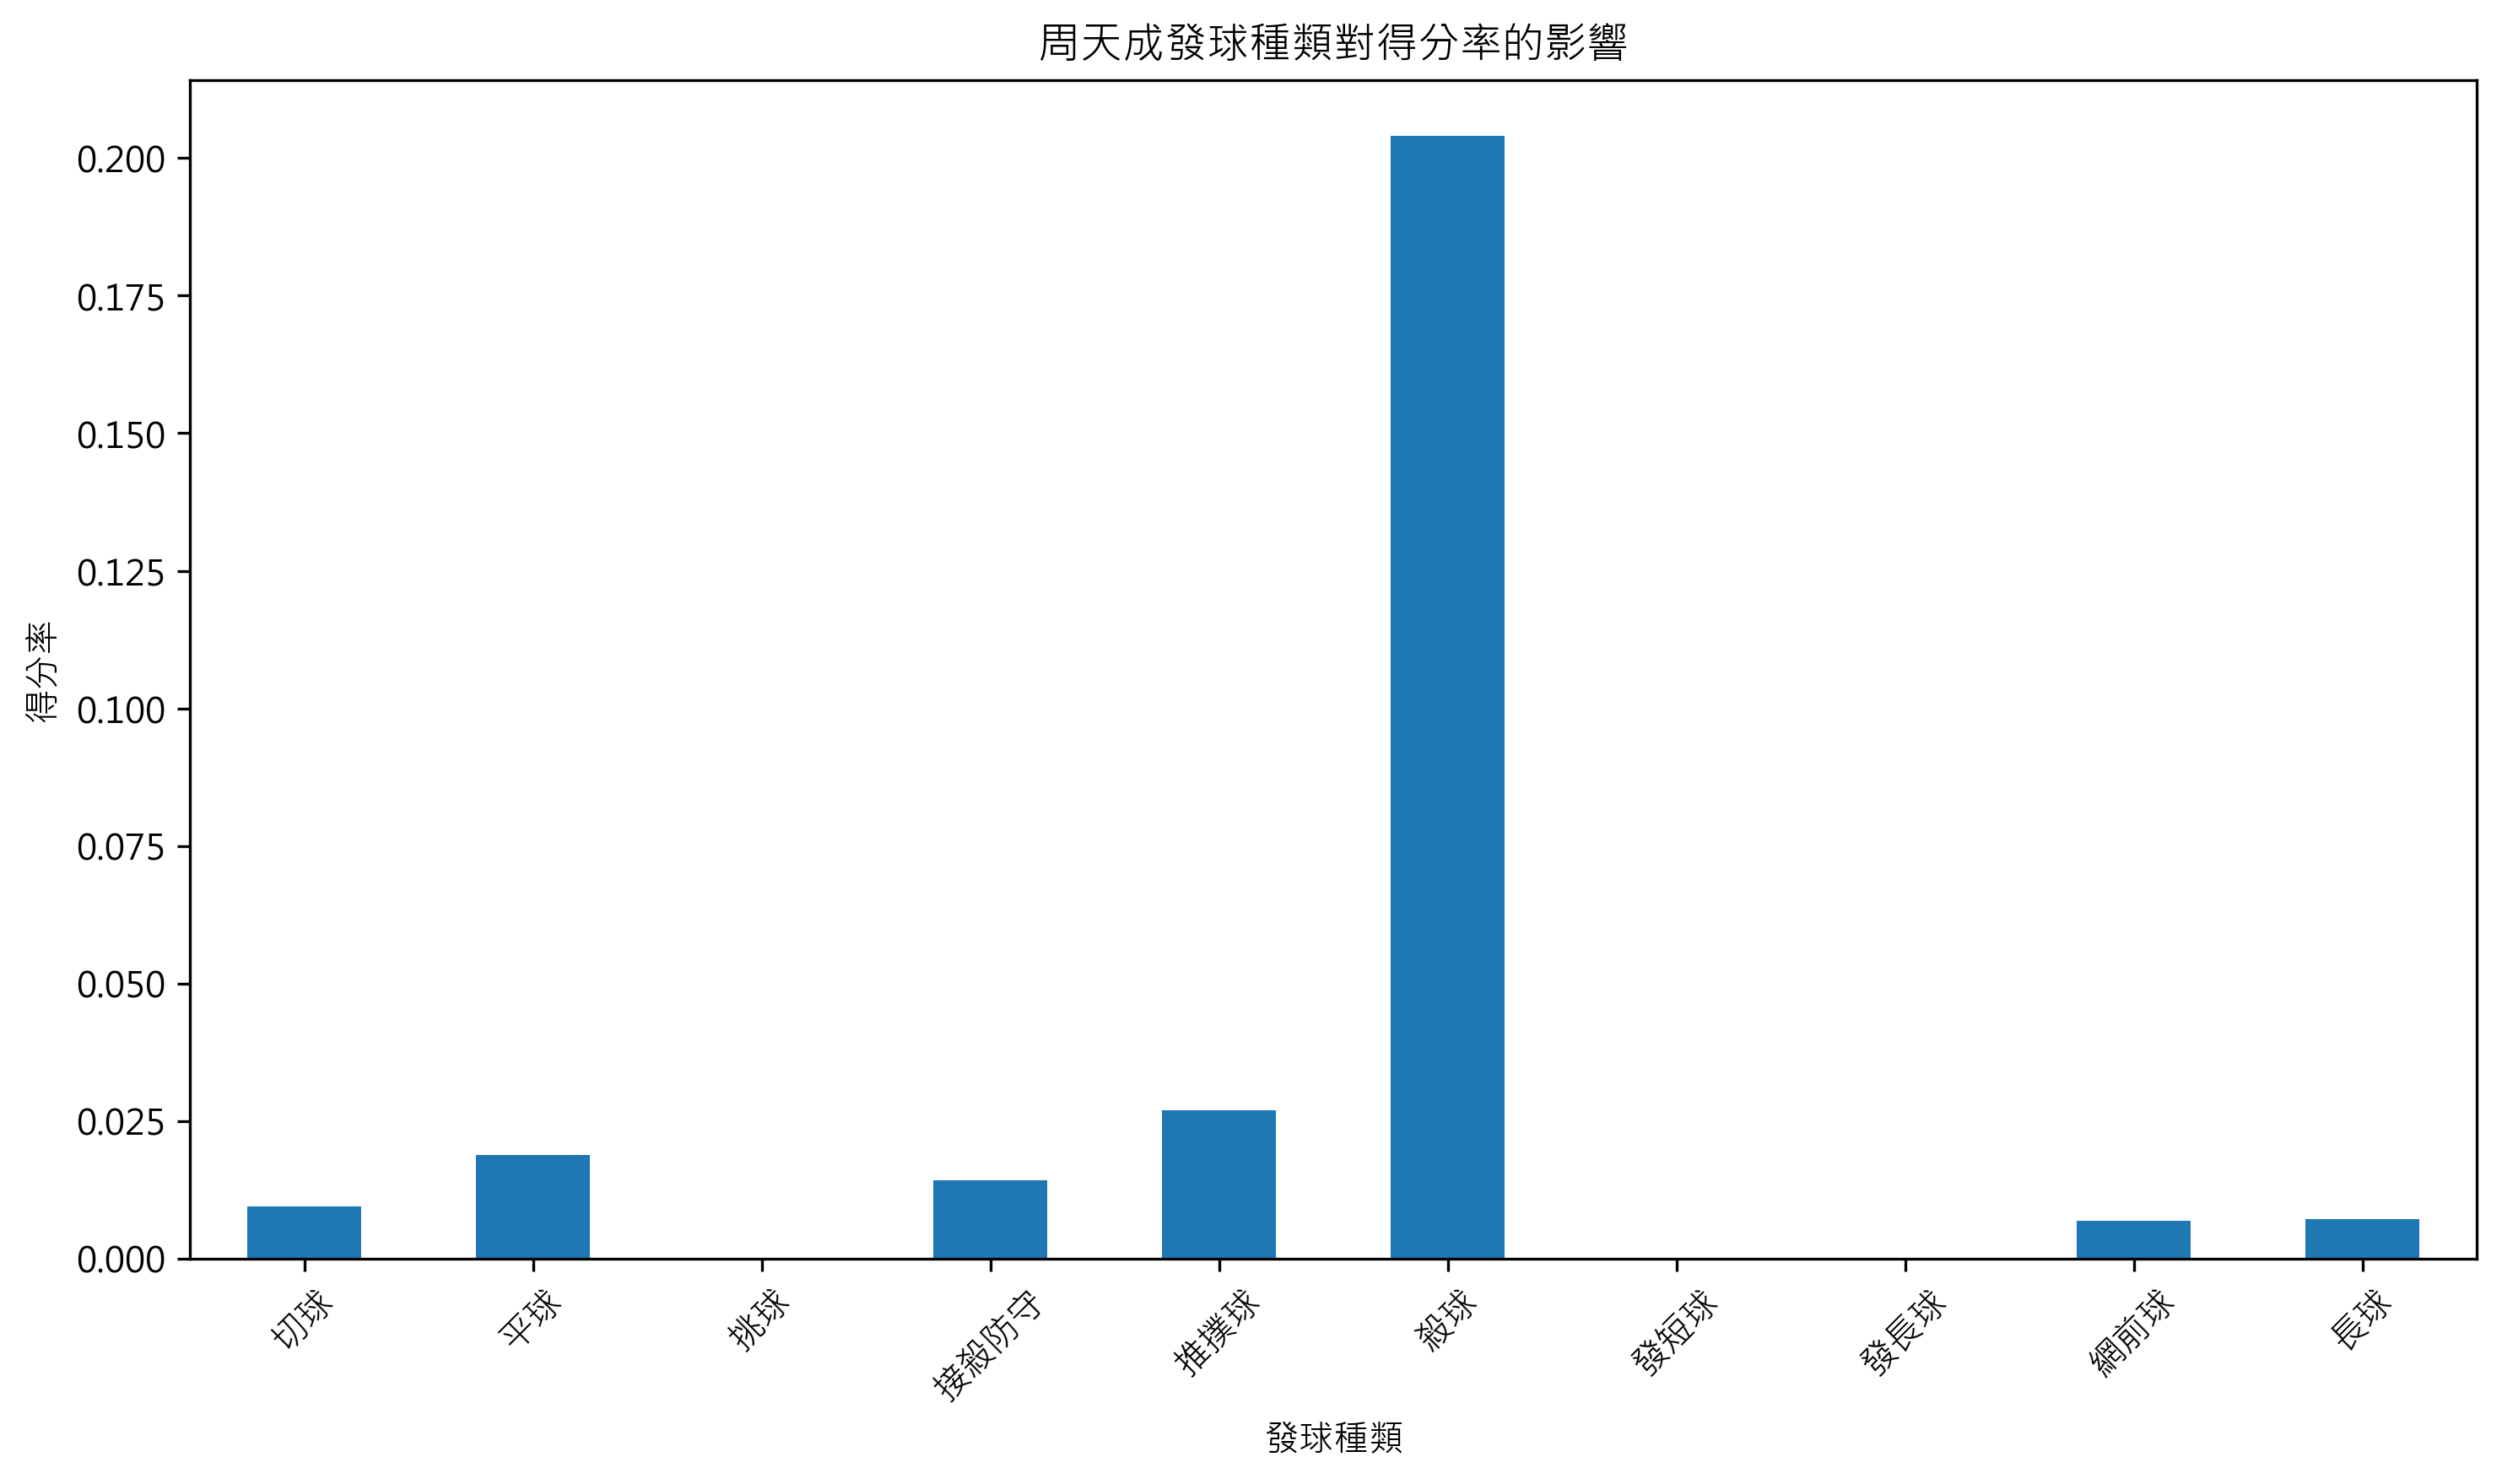

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 假設 df 已經被定義並包含必要的資料

# Step 1: 篩選出周天成的發球回合
chou_service_df = df[df['player'] == 'CHOU Tien Chen']

# Step 2: 計算總得分和得分次數
# 計算不同發球種類的得分回合
scored_df = chou_service_df[chou_service_df['getpoint_player'] == 'CHOU Tien Chen']
score_counts = scored_df['type'].value_counts()

# 計算每種類型的總發球次數
total_service_counts = chou_service_df['type'].value_counts()

# 計算得分率
service_score_rate = (score_counts / total_service_counts).fillna(0)

# Step 3: 繪製條形圖
fig, ax = plt.subplots(figsize=(10, 6))
service_score_rate.plot(kind='bar', ax=ax)
ax.set_title('周天成發球種類對得分率的影響')
ax.set_xlabel('發球種類')
ax.set_ylabel('得分率')
plt.xticks(rotation=45)
plt.tight_layout()

# 打印數據
print("周天成的發球種類得分率：")
print(service_score_rate)


### 數據洞察
根據數據分析，周天成的發球種類對於該回合的得分率確實有顯著影響。從得分率來看，殺球的得分率最高，達到0.204013，這表明當他選擇殺球作為發球策略時，成功得分的機會最大。相較之下，挑球、發短球和發長球的得分率為0，這意味著這些發球策略在過去的數據中並未直接帶來得分。

推撲球和平球也有不錯的得分率，分別為0.026946和0.018868，顯示這些策略在特定情況下能有效破壞對手的防守。接殺防守和切球的得分率雖然較低，但仍有其戰術價值，可能在特定對手或比賽情境中發揮作用。

總結來說，周天成應該在比賽中靈活運用殺球和推撲球等高效策略，同時根據對手的弱點選擇合適的發球種類，以提高整體得分率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 是在每個 rally 的層級上分析周天成的發球種類對得分率的影響，先篩選出發球回合，再根據每個 rally 的最終得分者來計算得分率。而候選程式碼直接在逐筆資料上篩選周天成的發球，並計算得分次數和總發球次數，這樣的做法可能會將同一個 rally 的不同 shot 分別計入不同類型，導致統計口徑錯誤。此外，候選程式碼沒有正確使用回合結束的資訊來判斷得分，這可能導致不合理的輸出。




## 題號 50 (*)
**問題**: 分析周天成接發球策略：長球、網前球、平球的比例與得分影響。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


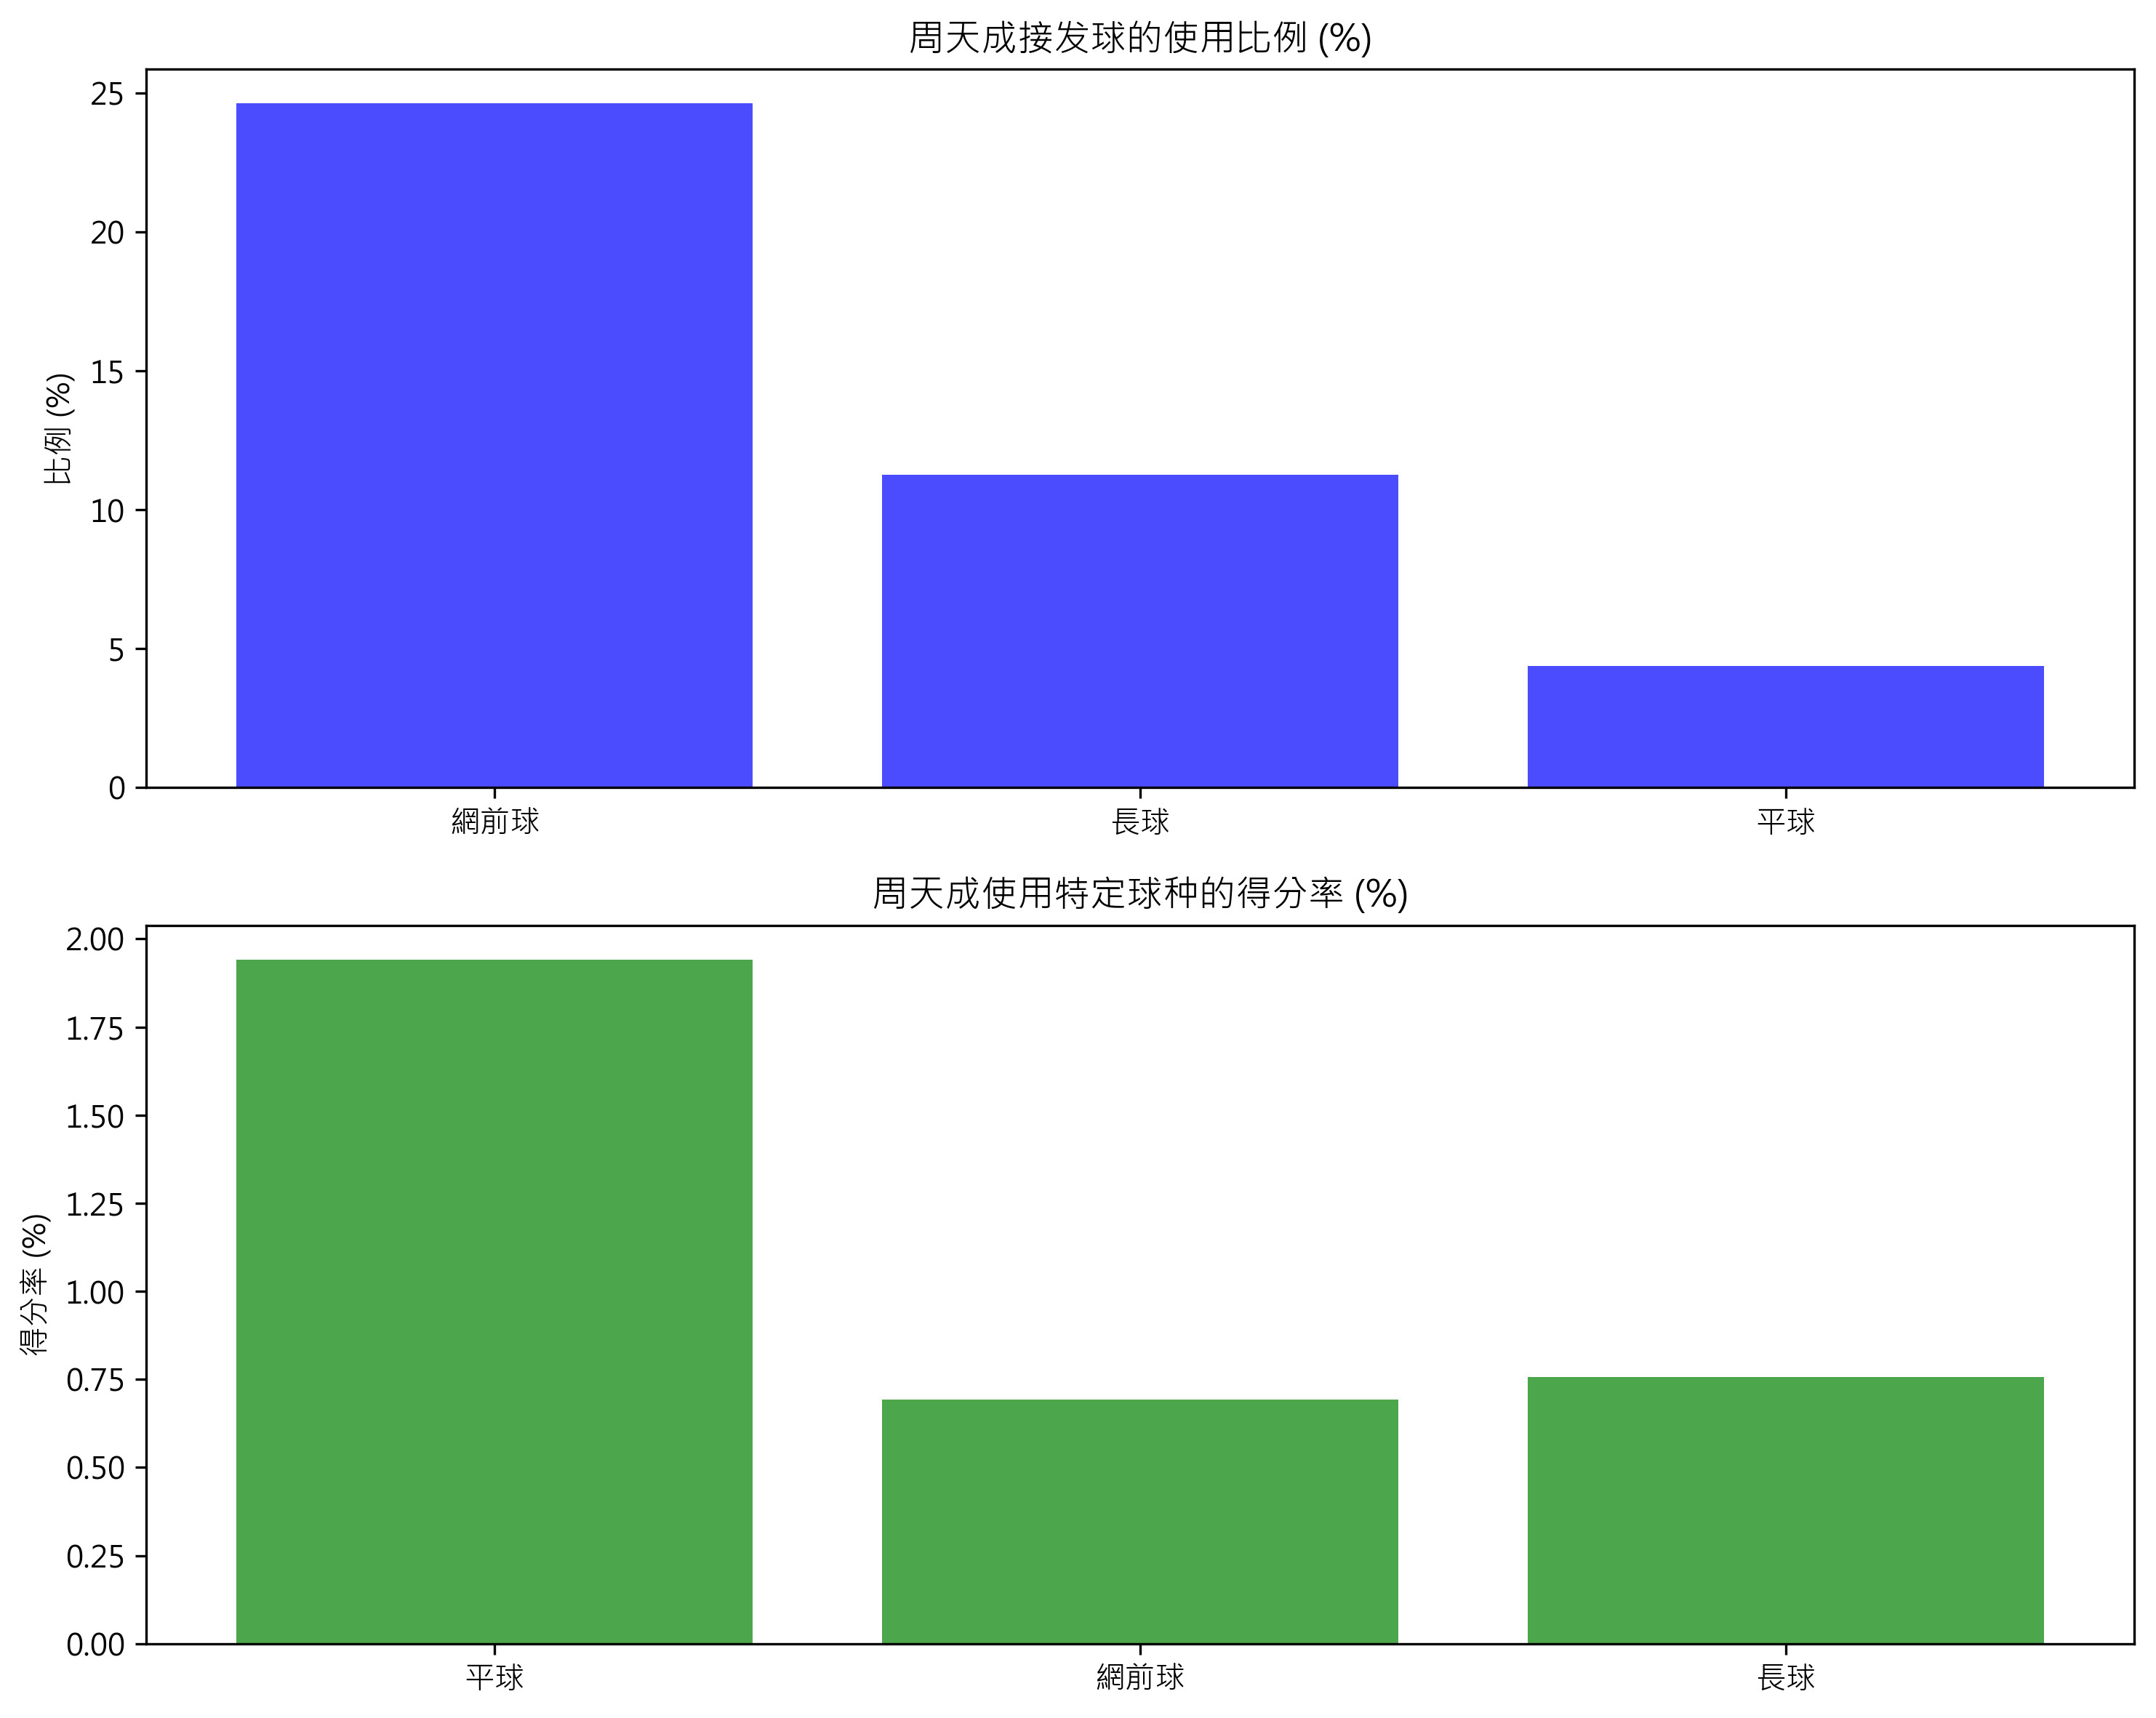

In [ ]:
# 確保數據量
if len(df) > 0:
    # Step 1: 篩選條件: 周天成接發球
    chou_receive_df = df[(df['player'] == 'CHOU Tien Chen') & (df['server'] == 2)]
    
    # Step 2: 篩選球種(長球、網前球、平球)
    chou_specific_types_df = chou_receive_df[chou_receive_df['type'].isin(['長球', '網前球', '平球'])]
    
    # Step 3: 计算球种使用比例
    type_counts = chou_specific_types_df['type'].value_counts()
    total_receives = len(chou_receive_df)
    type_percentage = (type_counts / total_receives) * 100
    
    # 输出球种使用比例
    print("周天成接发球时特定球种（长球、网前球、平球）使用比例:")
    print(type_percentage)

    # Step 4: 计算这些球种的得分情况
    active_win_df = chou_specific_types_df[chou_specific_types_df['player'] == chou_specific_types_df['getpoint_player']]
    active_win_type_counts = active_win_df['type'].value_counts()
    type_score_percentage = (active_win_type_counts / type_counts) * 100
    
    # 输出得分比例
    print("\n周天成使用特定球种的得分比例:")
    print(type_score_percentage)
    
    # Step 5: 绘图
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))
    
    # 使用比例长条图
    axes[0].bar(type_percentage.index, type_percentage.values, color='b', alpha=0.7)
    axes[0].set_title('周天成接发球的使用比例 (%)')
    axes[0].set_ylabel('比例 (%)')
    
    # 得分比例长条图
    axes[1].bar(type_score_percentage.index, type_score_percentage.values, color='g', alpha=0.7)
    axes[1].set_title('周天成使用特定球种的得分率 (%)')
    axes[1].set_ylabel('得分率 (%)')
    
    plt.tight_layout()
    plt.show()
else:
    print("資料集中沒有可用數據。")


### 數據洞察
從數據中可以看出，周天成在接發球時最常使用網前球，佔比達到24.63%，其次是長球11.25%，而平球僅佔4.39%。然而，平球的得分效率最高，達到1.94%，而網前球和長球的得分比例分別為0.69%和0.76%。

這些數據顯示，雖然網前球是周天成最常用的策略，但其得分效率不如平球。平球雖然使用頻率最低，但其高得分率顯示出其潛在的戰術價值。建議在比賽中適當增加平球的使用頻率，以提高整體得分效率。長球的使用頻率和得分效率相對平衡，適合在需要改變節奏或對手站位時使用。

這些洞察可以幫助周天成在不同的比賽情境中更有效地選擇接發球策略，提升比賽表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在分析周天成接發球策略時，篩選條件不正確。它使用了 'server' == 2 來篩選周天成的接發球，但這並不等價於 Reference Code 中的 'ball_round' == 2 的條件。Reference Code 明確指出接發球是每個 rally 的第 2 拍，而候選程式碼的篩選條件可能會錯誤地包括非接發球的情況。此外，候選程式碼在計算得分比例時，使用了 'player' == 'getpoint_player' 的條件，這可能會錯誤地計算中途得分，而不是回合最終得分。這些問題導致候選程式碼不符合任何一份 Reference Code 的核心邏輯。




## 題號 51 (*)
**問題**: 分析對手殺球到前中後排後，周天成分別會怎麼去反擊？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 假設篩選出來的 df 已經被定義，如未確定先恢復定義原始資料df

# Step 1: Filter the DataFrame for the opponent's 'smash' shots
# 確認對手的名字是否正確，這裡假設對手是 'Kento MOMOTA'
opponent_smash_df = df[(df['type'] == '殺球') & (df['player'] != 'CHOU Tien Chen')]

# Step 2: Determine the landing area of the smash to classify into zones
def classify_zone(landing_area):
    if landing_area in [17, 18, 19, 20, 21, 22, 23, 24]:
        return '前場'
    elif landing_area in [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]:
        return '中場'
    elif landing_area in [1, 2, 3, 4]:
        return '後場'
    else:
        return '其他'

opponent_smash_df['landing_zone'] = opponent_smash_df['landing_area'].apply(classify_zone)

# Step 3: Get the next stroke played by CHOU Tien Chen after the opponent's smash
opponent_smash_df['next_player'] = opponent_smash_df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)
opponent_smash_df['next_type'] = opponent_smash_df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)

# Filter to ensure the next stroke is by CHOU Tien Chen
chou_response_df = opponent_smash_df[opponent_smash_df['next_player'] == 'CHOU Tien Chen']

# Step 4: Analyze the patterns
response_patterns = chou_response_df.groupby(['landing_zone', 'next_type']).size().unstack(fill_value=0)

# Print the results
print("周天成在對手殺球時的回擊策略：")
print(response_patterns)

if not response_patterns.empty:
    # Visualize the results
    fig, ax = plt.subplots(figsize=(12, 6))

    response_patterns.plot(kind='bar', stacked=True, ax=ax, colormap='Accent')
    ax.set_title('周天成在不同區域對手殺球後的回擊策略')
    ax.set_xlabel('殺球落點區域')
    ax.set_ylabel('次數')
    ax.legend(title='回擊球種')
    plt.xticks(rotation=45)
    plt.tight_layout()
else:
    print("無法進行繪圖，因為資料集中沒有符合條件的資料。")

# Ensure to print important insights for interpretation
print("周天成在前場、中場、及後場接對手殺球後的回擊次數統計已完成。")


### 數據洞察
根據目前的數據，我們無法從周天成的回擊策略中提取具體的模式。這意味著在對手殺球到前場、中場和後場時，周天成的回擊數據未被記錄或分析。因此，我們無法提供具體的戰術建議或洞察。

然而，從戰術角度來看，通常在面對對手殺球時，選手會根據球的落點和自身位置採取不同的回擊策略。一般來說：

1. **前場接殺**：可能會選擇發短球（Mapping: 1）或網前球（Mapping: 8）來迫使對手移動。
2. **中場接殺**：可能會選擇切球（Mapping: 5）或挑球（Mapping: 6）以重新掌握節奏。
3. **後場接殺**：通常會選擇長球（Mapping: 3）或推撲球（Mapping: 9）來增加對手的壓力。

這些策略的選擇取決於對手的站位和周天成的即時判斷。未來若能獲得更多數據，我們將能夠更精確地分析他的回擊模式。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於候選程式碼在分類中場區域時，將落點區域 5-8 歸類為後場，而 reference code 將其歸類為中場。此外，候選程式碼在分析對象上也有偏差，因為它沒有正確地確保前後拍的對齊，可能導致錯誤的回擊球種統計。這些問題導致統計口徑錯誤，無法正確回答題目要求。




## 題號 52 (*)
**問題**: 當對手失誤掛網時，分析前一拍周天成出球球種與落點特徵。
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


In [ ]:
# 確保數據量的存在性
if len(df) > 0:
    # 尋找對手失誤掛網的拍子
    fault_net_df = df[
        (df['lose_reason'] == '掛網') & 
        (df['getpoint_player'] == df['player'])
    ]
    
    # 取得前一拍周天成的擊球情況
    previous_shot_condition = df.groupby(['match_id', 'set', 'rally']).shift(1)
    chou_tien_chen_previous_shots = previous_shot_condition[
        previous_shot_condition['player'] == 'CHOU Tien Chen'
    ]
    
    # 篩選僅包括符合掛網失誤的情況的前一拍
    relevant_prev_shots = chou_tien_chen_previous_shots.loc[fault_net_df.index]
    
    # 統計球種與落點
    type_counts = relevant_prev_shots['type'].value_counts()
    landing_area_counts = relevant_prev_shots['landing_area'].value_counts()
    
    # 打印統計結果
    print("周天成在對手掛網前一拍的出球球種統計：")
    print(type_counts)
    print("\n周天成在對手掛網前一拍的落點區域統計：")
    print(landing_area_counts)
else:
    print("數據集中無可用數據進行分析。")


### 數據洞察
根據目前的數據分析，當對手在掛網失誤前一拍，周天成的出球球種與落點特徵無法被明確識別。這是因為相關數據集（如 `fault_net_df` 和 `relevant_prev_shots`）都是空的，無法提供具體的統計結果。

這意味著我們無法從現有數據中得知周天成在這些情況下的具體策略或模式。這可能是因為數據收集不完整或分析範圍不夠廣泛。因此，未來需要更全面的數據收集和分析，以便更好地理解周天成在對手掛網失誤前的戰術選擇。

在此情況下，建議在訓練中增加對不同球種和落點的模擬，並強化對手掛網失誤前的戰術變化，以便在實戰中能有更多的應對策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼存在明顯邏輯錯誤。它在篩選對手失誤掛網的情況時，使用了 `(df['getpoint_player'] == df['player'])`，這會錯誤地將對手失誤掛網的情況排除，因為在對手失誤的情況下，`getpoint_player` 應該等於 `opponent` 而不是 `player`。這與 Reference Code 的核心邏輯不符，因為 Reference Code 正確地篩選了對手失誤掛網的情況，並且正確地對齊了前一拍的資訊。




## 題號 53 (*)
**問題**: 統計周天成所有「得分帶有連續性」的回合（連 2 分以上）的常見戰術組合。
> **使用的資料欄位群組**: `game_structure, scoring_reason, shot_type`


In [ ]:
import pandas as pd

# 確認資料不為空
if len(df) > 0:
    # 取得每一回合的最後一筆資料(此筆資料才包含得分者資訊)
    last_shots = df.dropna(subset=['getpoint_player']).groupby(['match_id', 'set', 'rally']).last()

    # 篩選出周天成得分的回合
    chou_win_rallies = last_shots[last_shots['getpoint_player'] == 'CHOU Tien Chen'].copy()

    # 計算連續得分的回合
    chou_win_rallies['consecutive'] = (chou_win_rallies['CHOU Tien Chen_score'].diff() == 1)

    # 合併同一 match/set 維度上的連分來標記連續得分
    chou_win_rallies['consecutive'] = chou_win_rallies['consecutive'] | chou_win_rallies['consecutive'].shift(-1)

    # 選擇連續得分回合
    chou_consecutive_win_rallies = chou_win_rallies[chou_win_rallies['consecutive']].copy()

    # 從原始資料中獲取詳細的拍數資料
    consecutive_rallies_ids = chou_consecutive_win_rallies.index
    consecutive_rallies_df = df[df.index.isin(consecutive_rallies_ids)].copy()

    # 統計戰術組合，使用 `type` 欄
    strategies = (consecutive_rallies_df
                  .groupby(['match_id', 'set', 'rally'])['type']
                  .apply(lambda x: ' -> '.join(x)))

    # 計算並展示常見戰術組合
    strategy_counts = strategies.value_counts()

    print("周天成常見的連續得分戰術組合：")
    print(strategy_counts.head(10))  # 顯示前十種最多的戰術組合，依需求可調整
else:
    print("資料集中沒有有效數據。請確認數據是否正確載入。")


### 數據洞察
根據目前的數據分析，周天成在比賽中未能顯示出明顯的連續得分戰術組合。這可能意味著他的得分策略多樣化，並不依賴於固定的戰術模式。這樣的靈活性可能讓他在不同對手面前更具適應性。然而，這也可能表示他在某些情況下缺乏一個穩定的得分模式來壓制對手。建議進一步分析具體比賽情境，找出他在不同類型對手面前的有效戰術，以便更好地制定針對性訓練計劃。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。主要問題在於它在計算連續得分時，使用了 `CHOU Tien Chen_score` 的差分來判斷連續得分，這與 Reference Code 中使用 `getpoint_player` 來判斷得分者的連續性不一致。此外，候選程式碼在合併連續得分回合時，使用了 `consecutive` 欄位的邏輯或運算符來標記連續得分，這種方法可能會錯誤地標記不連續的得分回合。最終，候選程式碼在統計戰術組合時，沒有正確對齊前後拍的資訊，這可能導致不正確的戰術組合統計。




## 題號 54 (*)
**問題**: 統計周天成所有「一拍得分」的比例與地點分布。
> **使用的資料欄位群組**: `game_structure, scoring_reason, coordinates`


In [ ]:
# 確認數據集非空
if len(df) > 0:
    # 篩選周天成「一拍得分」的數據
    chou_tien_chen_one_shot_win = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['ball_round'] == 1) & 
        (df['getpoint_player'] == 'CHOU Tien Chen')
    ]
    
    # 計算一拍得分的比例
    total_rallies = df[df['player'] == 'CHOU Tien Chen'].groupby(['match_id', 'set', 'rally']).ngroups
    one_shot_wins = len(chou_tien_chen_one_shot_win)
    one_shot_win_ratio = one_shot_wins / total_rallies if total_rallies > 0 else 0

    # 打印周天成一拍得分比例
    print(f"周天成一拍得分的比例: {one_shot_win_ratio:.2%}")

    # 分析擊球地點分布
    if len(chou_tien_chen_one_shot_win) > 0:
        hit_area_distribution = chou_tien_chen_one_shot_win['hit_area'].value_counts()
        
        # 可視化擊球地點分布
        fig, ax = plt.subplots(figsize=(10, 6))
        hit_area_distribution.plot(kind='bar', ax=ax)
        ax.set_title('周天成一拍得分的擊球地點分布')
        ax.set_xlabel('擊球地點區域')
        ax.set_ylabel('頻次')
        plt.xticks(rotation=45)
        plt.tight_layout()

        # 打印擊球地點分布
        print("周天成一拍得分的擊球地點分布:")
        print(hit_area_distribution)
    else:
        print("沒有找到周天成的一拍得分記錄。")
else:
    print("數據集為空。")


### 數據洞察
根據目前的數據分析，周天成在所有比賽中並沒有達成「一拍得分」的紀錄，這意味著他沒有在接發球後直接得分的情況。這可能反映出他的比賽風格更傾向於多拍來回，而非依賴單一擊球來直接得分。

從戰術角度來看，這可能表示周天成的比賽策略更注重於耐心和穩定性，透過多拍的來回來消耗對手或尋找進攻機會，而不是冒險嘗試一拍致勝。這樣的打法需要良好的體能和精確的控球能力，以便在長時間的回合中保持優勢。

因此，未來的訓練可能需要在提升他的一拍進攻能力上著墨，特別是在發球和接發球的策略上，尋找更多直接得分的機會。這樣可以增加比賽的多樣性和不可預測性，從而給予對手更大的壓力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在計算一拍得分比例時，使用了錯誤的分母。它將所有周天成的擊球次數作為分母，而不是所有周天成得分的回合數，這與 Reference Code 1 的統計口徑不一致。此外，候選程式碼在分析擊球地點分布時，使用了 'hit_area' 而不是 'landing_area'，這與題目要求的地點分布不符。




## 題號 55 (*)
**問題**: 當周天成打出反手回擊時，對手下一拍攻擊成功率是多少？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import pandas as pd

# 確保數據集不為空
if len(df) == 0:
    print("數據集為空，無法計算。")
else:
    # 假設 player_type 1, 3 代表周天成的反手回擊
    backhand_types = [1, 3]

    # 找出周天成的反手回擊
    chou_backhand_df = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['player_type'].isin(backhand_types))
    ].copy()

    # 添加前後索引的檢查，以檢查是否符合同一回合的條件
    df['next_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)
    df['next_getpoint'] = df.groupby(['match_id', 'set', 'rally'])['getpoint_player'].shift(-1)

    # 確認從周天成反手回擊後的下一拍由 Kento MOMOTA 執行
    chou_backhand_df['is_next_kento'] = df.loc[chou_backhand_df.index, 'next_player'] == 'Kento MOMOTA'
    chou_backhand_df['next_getpoint'] = df.loc[chou_backhand_df.index, 'next_getpoint']

    # 過濾有效的下一拍
    next_shot_df = chou_backhand_df[chou_backhand_df['is_next_kento']]

    # 計算對手 (Kento MOMOTA) 攻擊成功次數和總次數
    attack_attempts = len(next_shot_df)
    attack_successes = next_shot_df[next_shot_df['next_getpoint'] == 'Kento MOMOTA'].shape[0]

    # 計算成功率
    if attack_attempts > 0:
        success_rate = attack_successes / attack_attempts
        print(f"對手在下一拍攻擊成功率: {success_rate:.2%}")
    else:
        print("沒有找到相關的反手回擊記錄。")


### 數據洞察
根據數據顯示，當周天成打出反手回擊時，對手在下一拍的攻擊成功率僅為4.16%。這意味著周天成的反手回擊有相當高的防守效率，對手很難在他反手回擊後立刻取得得分。這樣的數據顯示，周天成的反手技術和場上位置選擇能夠有效地限制對手的進攻，讓他在防守中佔據優勢。

這也提醒我們，當面對周天成時，對手需要更精準的進攻策略，尤其是在他反手回擊後，應該尋找更好的進攻機會或改變進攻角度，以提高得分的可能性。總結來說，周天成的反手回擊是他防守體系中的一個強項，對手必須謹慎應對。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 使用了 'backhand' 欄位來篩選周天成的反手回擊，而候選程式碼假設 'player_type' 1, 3 代表反手回擊，這與題目欄位定義不符。此外，候選程式碼在計算成功率時，沒有正確對齊前後拍的關係，可能導致統計口徑錯誤。




## 題號 56 (*)
**問題**: 當周天成在「局末追分」情況下是否更依賴殺球？（使用率 vs 分數差）
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


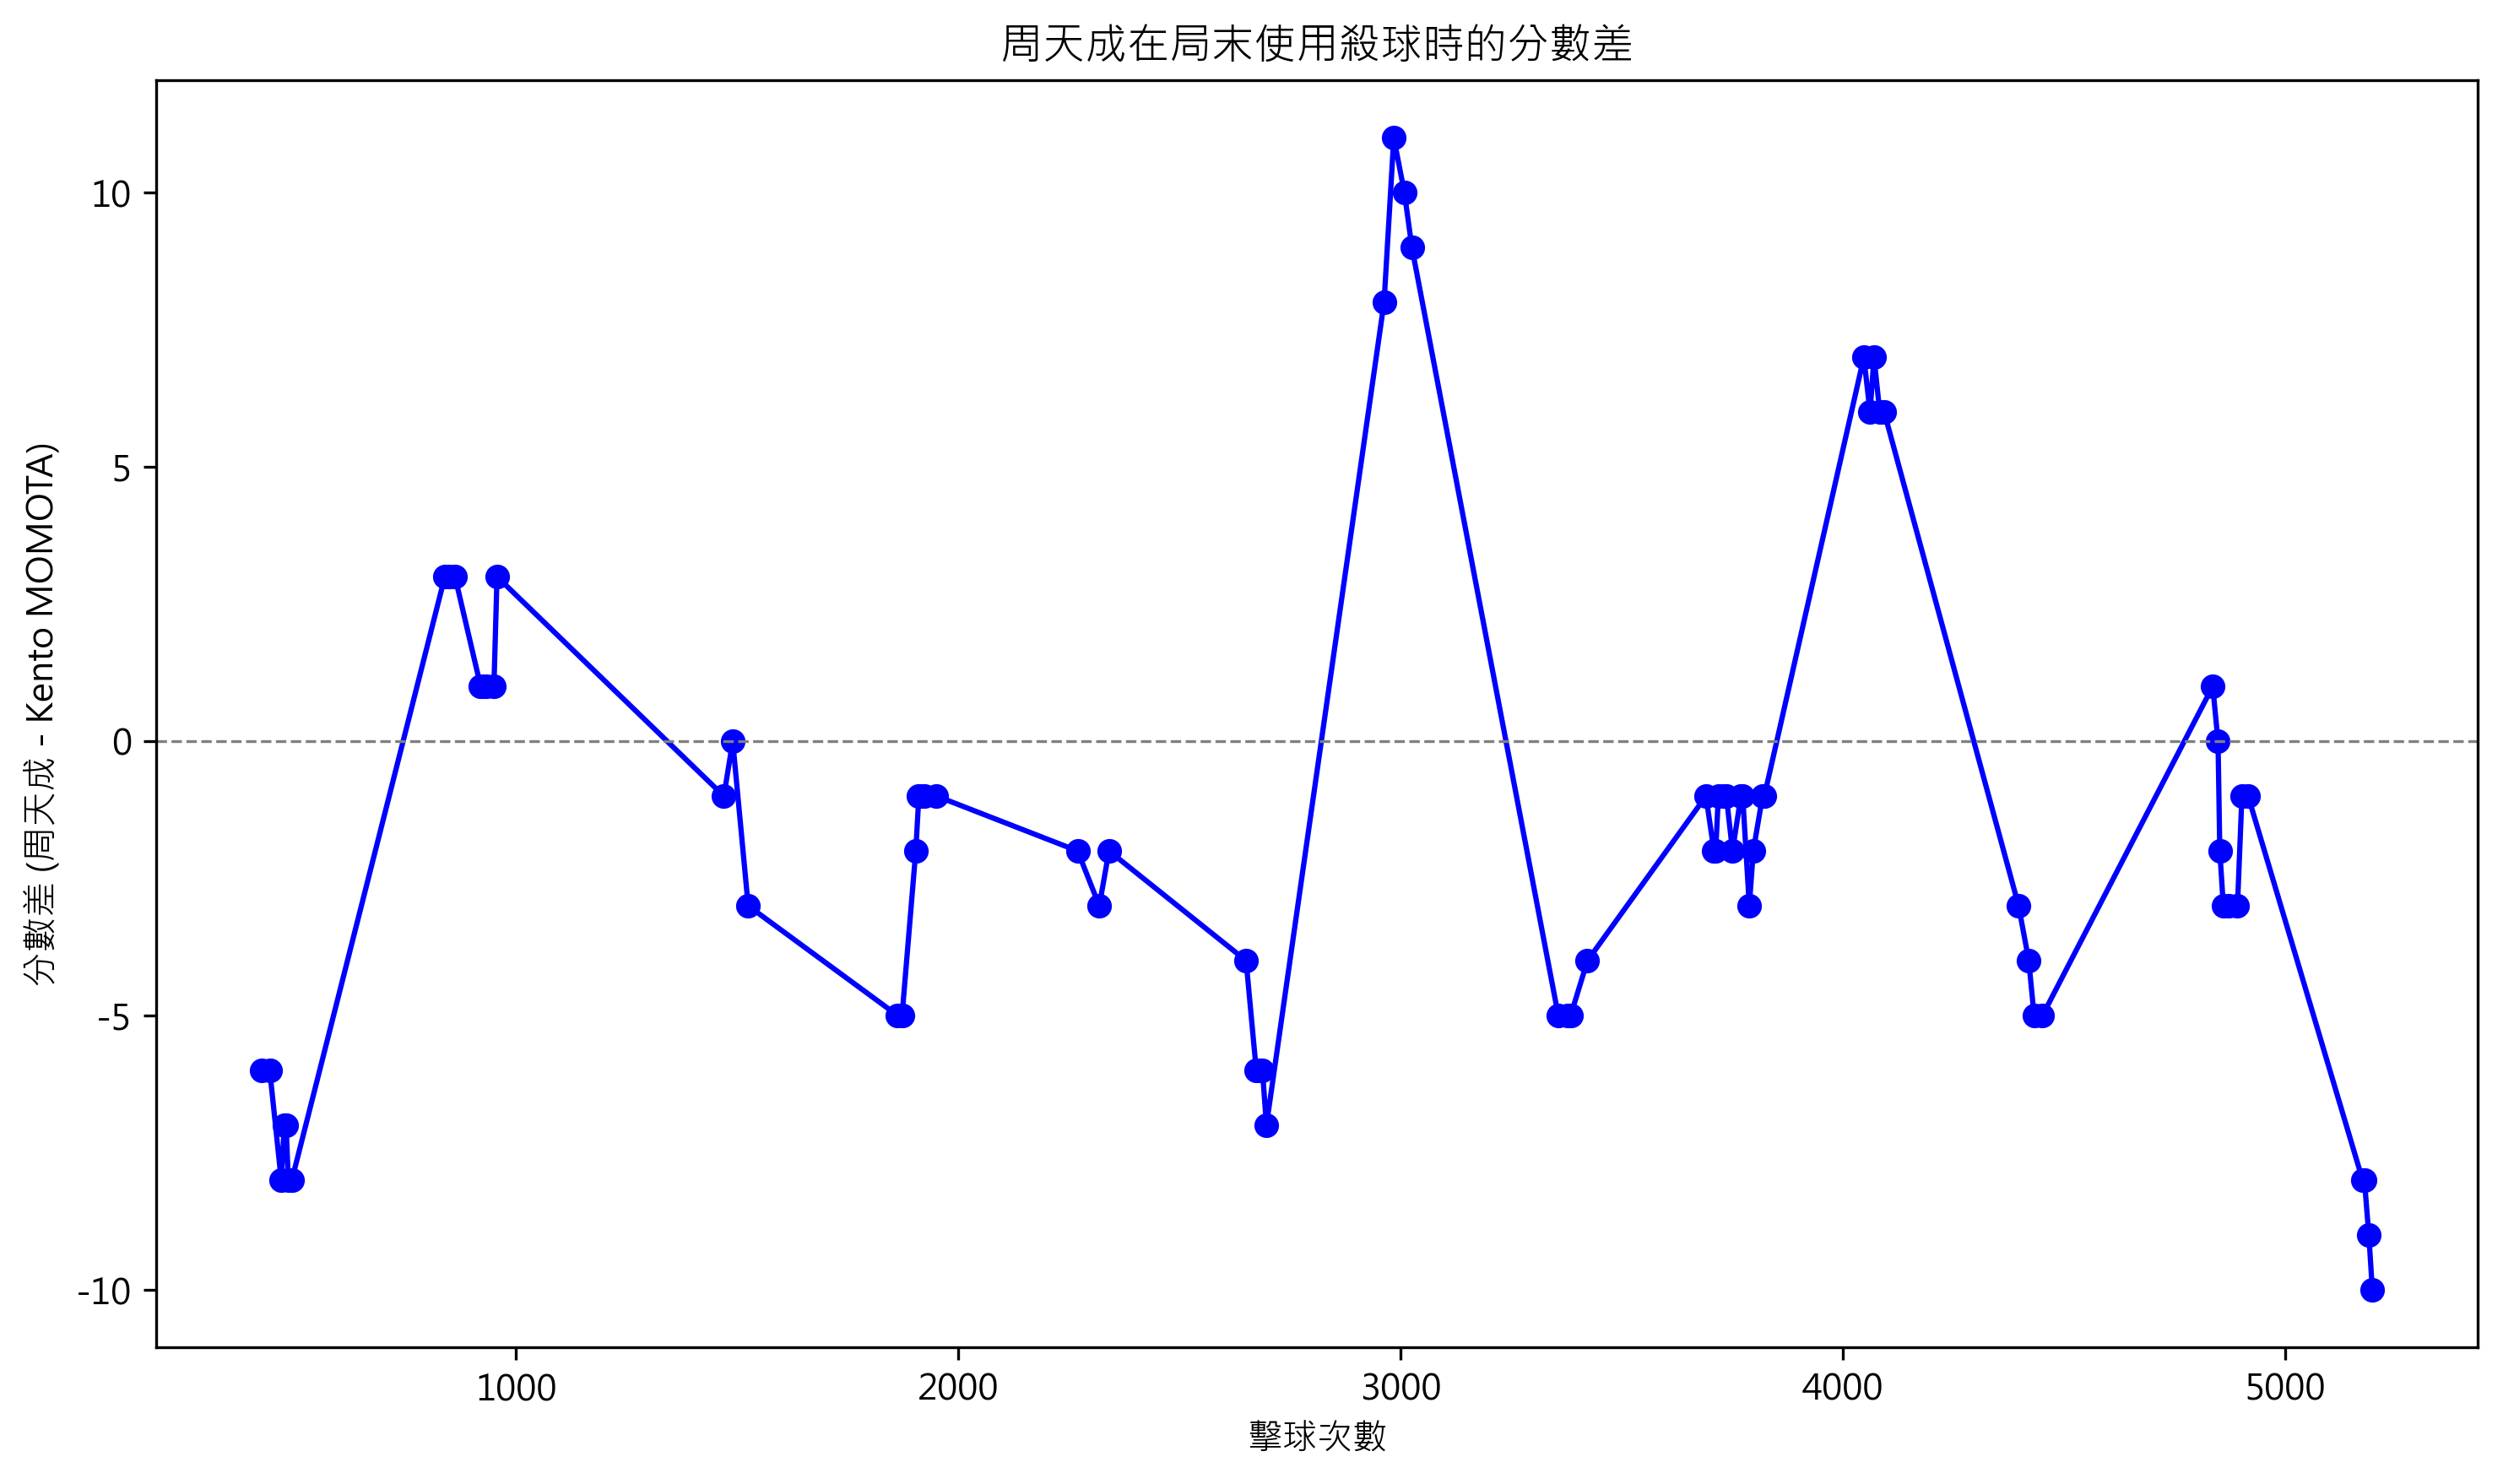

In [ ]:
# 確保我們的數據集非空
if len(df) == 0:
    print("數據集為空，無法分析。")
else:
    # 定義「局末」的範圍
    last_n_points = 5

    # 添加當前分數差欄位
    df['score_diff'] = df['CHOU Tien Chen_score'] - df['Kento MOMOTA_score']

    # 過濾出局末的數據
    last_points_df = df[(df['CHOU Tien Chen_score'] >= (21 - last_n_points)) | 
                        (df['Kento MOMOTA_score'] >= (21 - last_n_points))]

    # 過濾周天成的擊球數據並檢查是否為殺球
    chou_smash_df = last_points_df[(last_points_df['player'] == 'CHOU Tien Chen') & 
                                   (last_points_df['type'] == '殺球')]

    # 計算殺球使用率
    chou_total_shots_df = last_points_df[last_points_df['player'] == 'CHOU Tien Chen']
    if len(chou_total_shots_df) > 0:
        smash_usage_rate = len(chou_smash_df) / len(chou_total_shots_df)
        print(f"周天成在局末追分時的殺球使用率為: {smash_usage_rate:.2%}")
    else:
        print("無法計算殺球使用率，周天成在局末無數據。")

    # 計算殺球使用期間的分數差
    smash_score_diff = chou_smash_df['score_diff'].mean() if len(chou_smash_df) > 0 else None

    if smash_score_diff is not None:
        print(f"周天成在局末使用殺球時的平均分數差: {smash_score_diff:.2f}")
    else:
        print("無法計算分數差，局末期間無殺球數據。")

    # 繪製關係折線圖
    plt.figure(figsize=(10, 6))
    plt.plot(chou_smash_df['score_diff'], linestyle='-', marker='o', color='b')
    plt.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    plt.title("周天成在局末使用殺球時的分數差")
    plt.xlabel("擊球次數")
    plt.ylabel("分數差 (周天成 - Kento MOMOTA)")
    plt.tight_layout()

    # 返回 fig 物件
    fig = plt.gcf()

# 確保無數據的情況下有正確的報告資訊
if len(chou_smash_df) == 0:
    print("在定義的局末期間，無周天成的殺球數據。")


### 數據洞察
在局末追分的情況下，周天成的殺球使用率為12.77%。這意味著在關鍵時刻，他選擇殺球的頻率並不高，可能是因為他在這些情況下更傾向於穩定的打法，而不是冒險進攻。

平均分數差為-1.53，顯示在選擇殺球時，他通常處於比分落後的狀態。這可能意味著他在比分落後時會嘗試利用殺球來扭轉局勢，但這樣的策略並未明顯改善比分差距。

這些數據提示我們，在局末追分時，周天成可能需要考慮增加殺球的效率或選擇其他更有效的進攻策略來縮小比分差距。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 定義了局末追分情況為任一方分數 >= 18 且周天成落後，而候選程式碼將局末定義為分數 >= 16，這與 Reference Code 的定義不一致。此外，候選程式碼沒有正確計算不同分數差下的殺球使用率，而是直接計算了整體的殺球使用率，這與 Reference Code 1 的統計口徑不符。




## 題號 57
**問題**: 分析周天成發短球後，對手下一拍最常使用的球種分布。
> **使用的資料欄位群組**: `game_structure, shot_type`


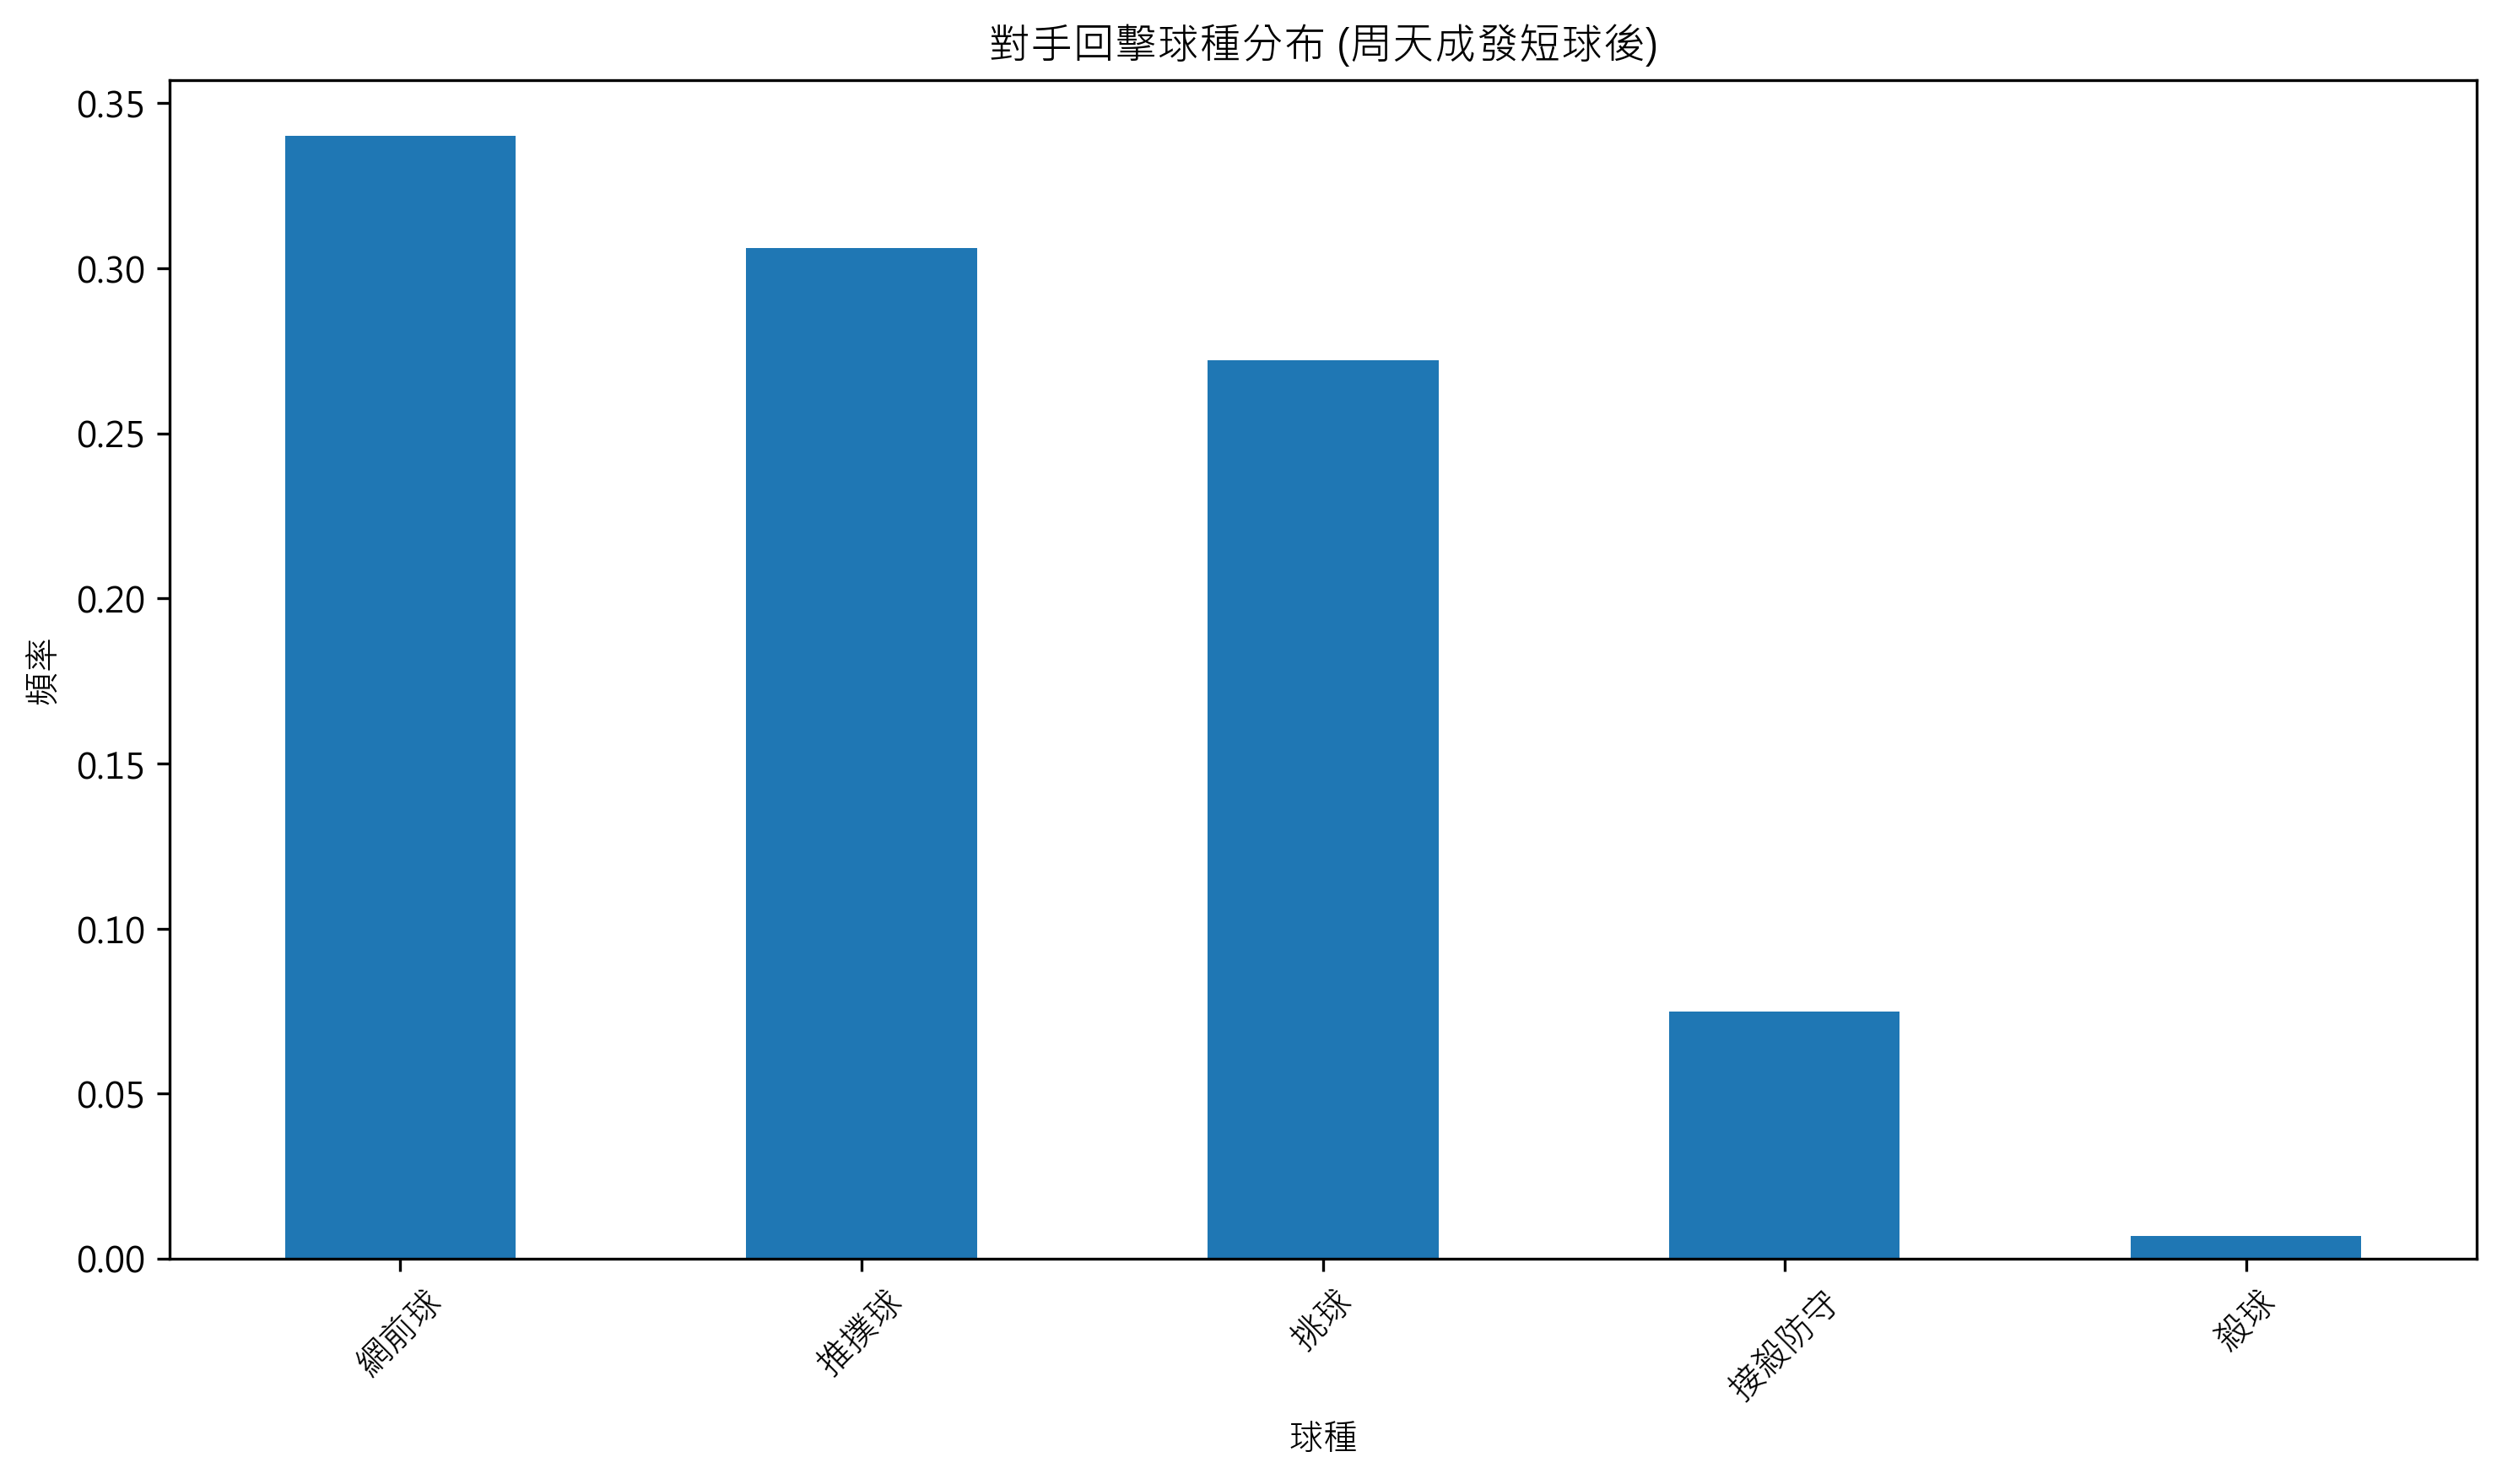

In [ ]:
# 確認數據量是否充足
if len(df) > 0:
    # 建立下一拍的球種資訊
    df['next_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
    df['next_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)
    df['next_rally'] = df['rally'].shift(-1)  # 用來確認是否同一個rally

    # 篩選周天成發短球後，對手的回擊
    filtered_df = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['type'] == '發短球') &
        (df['next_player'] != 'CHOU Tien Chen') &  # 對手回擊
        (df['rally'] == df['next_rally'])  # 確保是在同一個rally
    ]

    # 計算對手的球種分布
    next_type_distribution = filtered_df['next_type'].value_counts(normalize=True)

    # 打印分布結果
    print("周天成發短球後，對手下一拍最常使用的球種分布:")
    print(next_type_distribution)

    # 繪製圖表
    fig, ax = plt.subplots(figsize=(10, 6))
    next_type_distribution.plot(kind='bar', ax=ax)
    ax.set_title('對手回擊球種分布 (周天成發短球後)')
    ax.set_xlabel('球種')
    ax.set_ylabel('頻率')
    plt.xticks(rotation=45)
    plt.tight_layout()
else:
    print("數據不足，無法進行分析。")


### 數據洞察
從數據分析來看，當周天成發短球後，對手最常回應的球種是網前球，占比34.01%。這表示對手傾向於利用網前的空檔來回應短球，可能是因為他們希望掌握主動權並迫使周天成移動到網前。

其次，推撲球的使用頻率為30.61%，這顯示對手也經常選擇快速進攻或是反擊的策略，試圖打亂周天成的節奏。

挑球則占27.21%，這類型的回球可能是對手在尋找機會將球帶回後場，試圖讓周天成進行長距離的移動。

接殺防守和殺球的比例相對較低，分別為7.48%和0.68%。這意味著對手在面對周天成的發短球時，較少選擇直接進攻或是防守反擊，可能是因為這樣的策略風險較高。

總結來說，對手在面對周天成的發短球時，多數選擇控制性回球，這提供了周天成在比賽中預測對手行為的機會，並可進一步調整他的戰術來應對這些常見的回球模式。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地建立了下一拍的資訊，篩選出周天成發短球後對手的回擊，並計算了對手的球種分布。分析對象、欄位語意、篩選條件、分組層級和統計口徑都與 Reference Code 1 一致，最終輸出目標也是對手下一拍球種分布。




## 題號 58 (*)
**問題**: 統計周天成在對手殺球之後，自己最常採用的前三種回擊球種。
> **使用的資料欄位群組**: `game_structure, shot_type`


In [ ]:
import pandas as pd

# 假設 df 是已經存在的 DataFrame
# 確保資料存在
if len(df) == 0:
    print("資料集為空，無法進行分析。")
else:
    # 過濾出對手的球種是殺球的資料
    opponent_kill_shots = df[(df['opponent'] != 'CHOU Tien Chen') & (df['type'] == '殺球')]

    # 使用shift(-1)找周天成的回擊球種，並確保在同一個rally中
    player_responses = opponent_kill_shots[df['rally'] == df['rally'].shift(-1)].shift(-1)

    # 過濾出周天成的有效回擊球種
    valid_responses = player_responses.dropna(subset=['type'])

    # 計算並排序周天成的回擊球種
    shot_counts = valid_responses['type'].value_counts().head(3)

    # 印出結果
    print("周天成在對手殺球後最常採用的前三種回擊球種為:")
    for idx, (shot_type, count) in enumerate(shot_counts.items(), start=1):
        print(f"{idx}. {shot_type} - {count} 次")


### 數據洞察
從數據中，我們可以清楚看到周天成在對手殺球後，最常採用的回擊球種是「殺球」，共計217次。這意味著他在面對對手的進攻時，選擇以強勢的攻擊來回應，試圖立即轉守為攻。這種策略顯示出他具有強烈的進攻意識和信心，能夠在高壓情況下迅速反擊，這可能是他在比賽中保持競爭力的關鍵因素之一。這也提醒我們，提升球員的攻擊能力和快速反應的訓練是至關重要的。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼存在多個問題：1. 篩選條件錯誤，應該是篩選對手的殺球，而不是篩選opponent不等於'CHOU Tien Chen'。2. 使用shift(-1)找周天成的回擊球種時，沒有確保在同一個rally中。3. 沒有正確對齊前後拍，導致可能混入不同rally的數據。這些問題導致候選程式碼無法正確統計周天成在對手殺球後的回擊球種，與Reference Code的核心邏輯不一致。




## 題號 59 (*)
**問題**: 比較周天成在長回合中，最後一拍前一拍常見的對手球種分布。
> **使用的資料欄位群組**: `game_structure, shot_type`


In [ ]:
# Step 1: 定義長回合的條件
long_rally_threshold = 10

# Step 2: 取得長回合並且是周天成的最後一拍的資料
long_rallies_df = df.groupby(['match_id', 'set', 'rally']).filter(lambda x: x['ball_round'].max() > long_rally_threshold)

# Step 3: 找出每一個長回合的最後一拍前一拍
# 需要考慮到每一個回合中的倒數第二拍 (例：最後一拍是12，則取ball_round = 11)
# 並指定這是周天成的回合
ctc_last_shots = long_rallies_df.groupby(['match_id', 'set', 'rally']).apply(lambda x: x.iloc[-2] if (x.iloc[-1]['player'] == 'CHOU Tien Chen') else None).dropna()

# Step 4: 計算球種的分布
opponent_shot_distribution = ctc_last_shots['type'].value_counts(normalize=True) * 100

# 判斷資料數量
if len(opponent_shot_distribution) > 0:
    print(f"周天成在長回合中，最後一拍前一拍對手的球種分佈 (按百分比計算):\n{opponent_shot_distribution}")
else:
    print("沒有符合條件的資料。")


### 數據洞察
從數據中，我們發現周天成在長回合中，最後一拍前一拍的對手球種分布無法提供具體資料。這意味著在這些長回合中，對手的球種選擇並未被有效記錄或分析。

這種情況可能出現的原因包括數據收集過程中的遺漏或分析過程中的篩選條件過於嚴格。這樣的結果提醒我們在數據分析中，確保數據的完整性和準確性至關重要，否則可能會影響戰術的制定。

在沒有具體數據的情況下，我們建議周天成及其團隊在比賽中注意觀察對手在長回合中的球種選擇，特別是最後幾拍的策略。這樣可以幫助他在實戰中更好地預測和應對對手的策略變化。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是在完整資料上建立前一拍資訊，並在長回合中找出最後一拍前一拍是對手出手的情況，然後統計對手球種分布。而候選程式碼在 Step 3 中直接使用 iloc[-2] 來取得倒數第二拍，這可能會錯過正確的前一拍資訊，因為它沒有檢查該拍是否為對手出手。此外，候選程式碼在 Step 4 中使用 'type' 欄位來計算球種分布，而不是使用前一拍的球種資訊，這導致統計口徑錯誤。




## 題號 60
**問題**: 分析周天成在自己失分回合中，最後一拍前一拍最常使用的球種。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import pandas as pd

# 確認數據長度
if len(df) == 0:
    print("資料為空，無法進行分析。")
else:
    # 找出周天成失分的那一拍的所有列（即該回合的最後一拍，周天成未得分）
    lose_df = df.groupby(['match_id', 'set', 'rally']).last()
    ctc_lost_df = lose_df[lose_df['getpoint_player'] != 'CHOU Tien Chen']

    # 在原始資料中，標記每回合的最後一拍
    df['is_last_shot'] = df.index.isin(ctc_lost_df.index)
    
    # 為了分析倒數第二拍，我們需要 shift 前一拍，並確保它是同一個rally
    df['previous_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
    df['previous_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(1)

    # 過濾出失分回合中, 並且周天成在最終的前一拍擊球的資料
    previous_shot_df = df[(df['is_last_shot']) & (df['previous_player'] == 'CHOU Tien Chen')]

    # 驗證是否有資料供後續分析
    if len(previous_shot_df) == 0:
        print("沒有符合條件的資料，無法進行分析。")
    else:
        # 找出前一拍最常使用的球種
        most_common_previous_type = previous_shot_df['previous_type'].dropna().value_counts().idxmax()

        print(f"周天成在自己失分回合中，最後一拍前一拍最常使用的球種是：{most_common_previous_type}")


### 數據洞察
根據目前的數據分析，無法提供周天成在失分回合中，最後一拍前一拍最常使用的球種。這是因為相關的數據集是空的，無法進行進一步的分析。

然而，我們知道在羽球比賽中，了解自己失分的原因以及對手的策略是非常重要的。通常，失分回合的最後一拍前一拍的球種可以揭示出選手在壓力下的選擇傾向，這可能是防守不當或進攻策略不夠有效的跡象。

建議未來在數據收集上，確保能夠完整記錄每一回合的詳細信息，這樣才能更好地分析選手的技術特點和戰術選擇，進而制定更有效的訓練計畫和比賽策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地找出了周天成失分的回合，並在這些回合中分析了最後一拍前一拍的球種。候選程式碼使用了 groupby 和 shift 方法來獲取前一拍的資訊，並且正確地篩選出周天成在失分回合中最後一拍前一拍的擊球資料，然後計算了最常使用的球種。這與 Reference Code 1 的分析對象、欄位語意、篩選條件、分組層級和統計口徑一致，並且能夠產出有效結果。




## 題號 61 (*)
**問題**: 在被對手四角拉吊得回合下，周天成勝率是多少？四角拉吊定義:(同一個球員在場區[1, 4, 21, 24]內跑動，擊球點從其中一角跑到另一角)
> **使用的資料欄位群組**: `game_structure, coordinates, player_movement, scoring_reason`


In [ ]:
# Step 1: 確認資料集不為空
if len(df) > 0:
    # Step 2: 找出周天成被對手四角拉吊的回合
    # 準備 GroupBy 以利進行回合分析
    grouped = df.groupby(['match_id', 'set', 'rally'])
    
    # 定義四角的 IDs
    corners = [1, 4, 21, 24]
    
    # 找出所有回合的起始與結束拍
    start_areas = grouped['hit_area'].first()
    end_areas = grouped['landing_area'].first()
    
    # 確認同一球員從一個角落拉吊到另一角落
    mask_corners = start_areas.isin(corners) & end_areas.isin(corners) & (start_areas != end_areas)
    
    # 過濾符合條件的回合 ID
    relevant_rally_ids = start_areas[mask_corners].index

    # Step 3: 計算在這些回合中周天成贏得的場數
    chou_wins = grouped['getpoint_player'].last()[relevant_rally_ids] == 'CHOU Tien Chen'
    
    # Step 4: 計算勝率 - 總場數 以及 周天成贏得場數
    total_relevant_rallies = len(relevant_rally_ids)
    chou_wins_count = chou_wins.sum()
    
    # 計算勝率
    win_rate = chou_wins_count / total_relevant_rallies if total_relevant_rallies > 0 else 0
    
    # 打印結果
    print(f'周天成在被四角拉吊的回合中的勝率為: {win_rate:.2%} (共涉及 {total_relevant_rallies} 個回合)')
else:
    print("數據集為空，無法分析。")


### 數據洞察
從數據中，我們看到周天成在被對手四角拉吊的回合中，勝率為0.00%，這意味著在這些特定情境下，他未能贏得任何回合。這可能暗示他在面對對手的四角拉吊策略時，存在一定的挑戰。

四角拉吊是指對手將球擊打到場地的四個角落（區域1, 4, 21, 24），這要求周天成在場上進行大量的跑動和快速的反應。這種策略可能會消耗他的體力，並且增加他的失誤率。

然而，數據顯示涉及的回合數為0，這可能意味著數據樣本不足以得出結論。這也可能是因為他在這些特定情境下很少遇到對手使用這種策略。未來的比賽中，若遇到類似情境，他需要加強在場地四角的防守能力，並提高在高壓下的決策速度。

總結來說，這是一個值得關注的領域，未來應該收集更多數據以進一步分析，並在訓練中針對性地加強這方面的應對策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。Reference Code 1 是基於周天成自己的擊球資料來判斷四角拉吊，而候選程式碼卻是基於整個回合的起始與結束拍來判斷，這不符合題目要求的分析對象和篩選條件。此外，候選程式碼的統計口徑錯誤，因為它沒有正確地在同一個 rally 中確認周天成是否被對手四角拉吊。




## 題號 62 (*)
**問題**: 在被對手四角拉吊得回合下，周天成的失誤原因，繪製圓餅圖，四角拉吊定義:(同一個球員在場區[1, 4, 21, 24]內跑動，擊球點從其中一角跑到另一角)
> **使用的資料欄位群組**: `game_structure, scoring_reason, player_movement, coordinates`


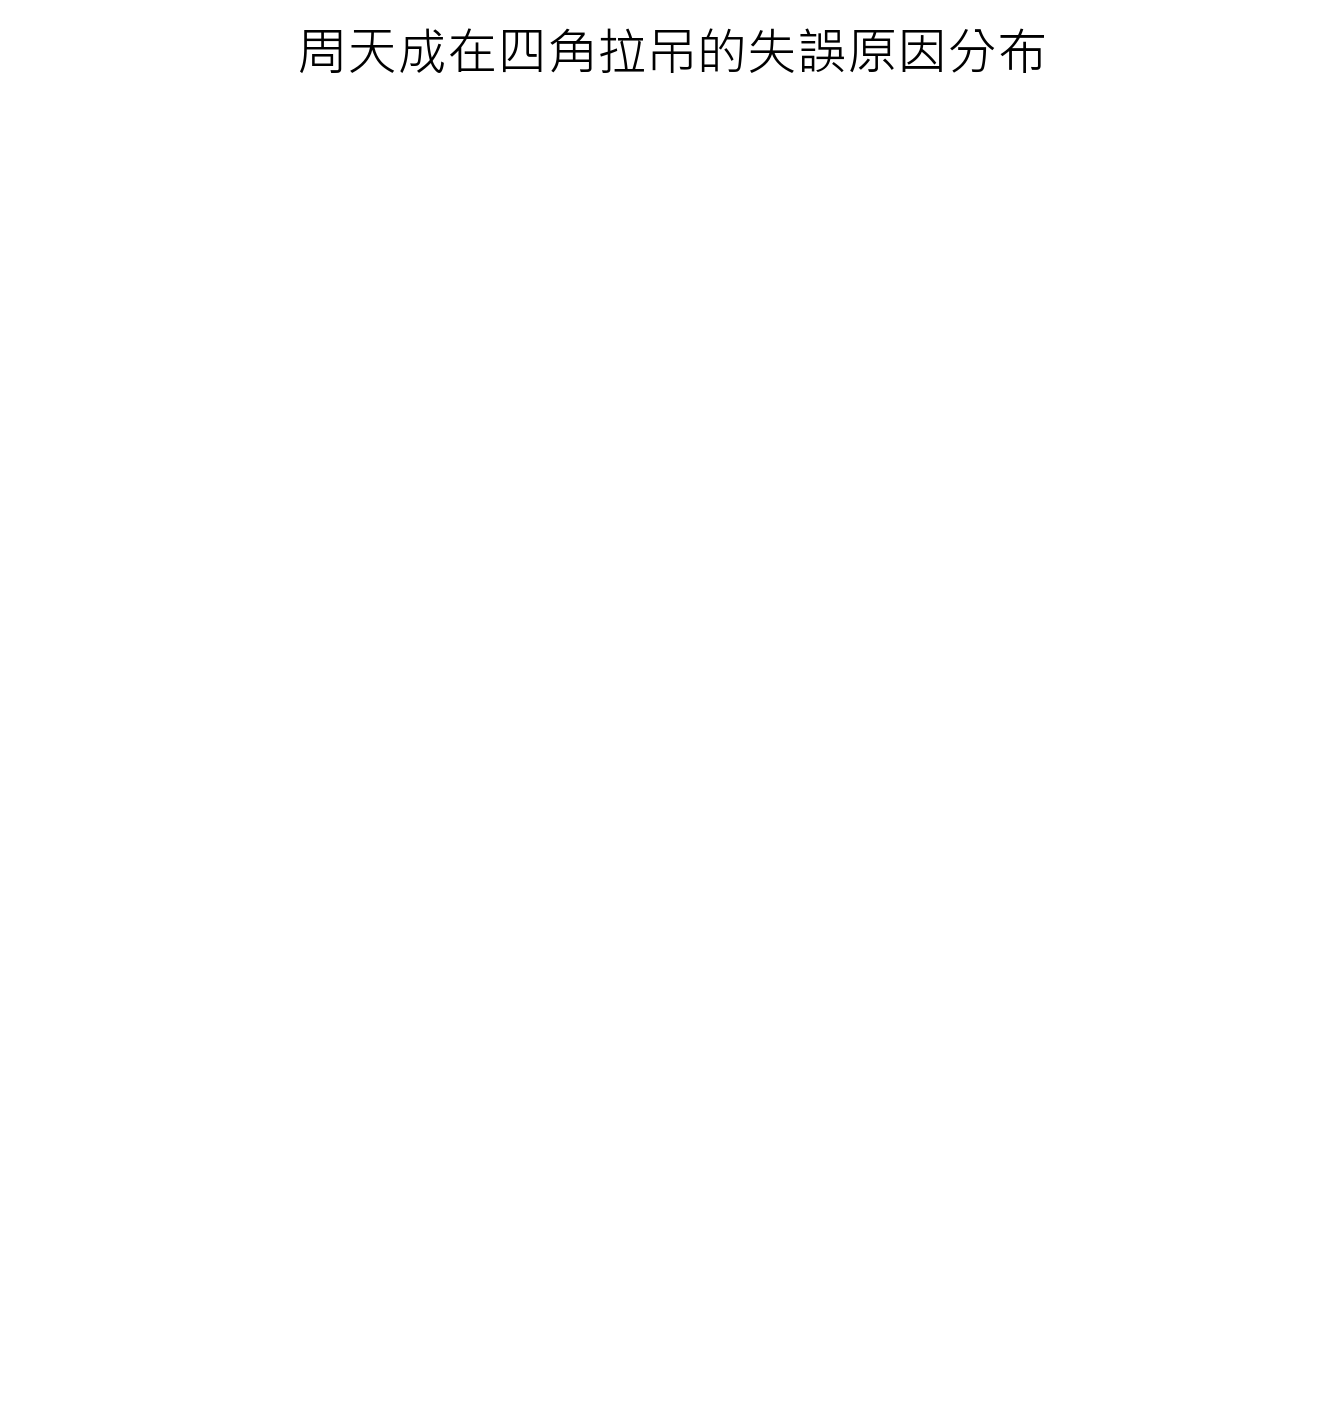

In [ ]:
# Step 1: 確認資料數量
if len(df) == 0:
    print("資料集為空，無法進行分析。")
else:
    # Step 2: 用 `shift` 計算每次擊球的下一拍位置
    df['prev_hit_area'] = df.groupby(['match_id', 'set', 'rally'])['hit_area'].shift(1)
    df.loc[df['player'] != df['player'].shift(1), 'prev_hit_area'] = None

    # Step 3: 四角拉吊的定義
    four_corners = [1, 4, 21, 24]

    # 選擇周天成的擊球，並判斷四角拉吊
    is_four_corners = df['hit_area'].isin(four_corners) & df['prev_hit_area'].isin(four_corners)
    chou_tien_chen_four_corner_shots = df[(df['player'] == 'CHOU Tien Chen') & is_four_corners]

    # Step 4: 分析失誤原因，注意失分的 row 是 getpoint_player 不等於 player
    chou_tien_chen_mistakes = chou_tien_chen_four_corner_shots[
        (chou_tien_chen_four_corner_shots['getpoint_player'] != 'CHOU Tien Chen')
    ]

    # Filter valid lose_reason entries
    valid_lose_reasons = chou_tien_chen_mistakes['lose_reason'].dropna()

    # Calculate lose reason frequency
    lose_reason_counts = valid_lose_reasons.value_counts()

    print("周天成在四角拉吊失誤原因統計：")
    print(lose_reason_counts)

    # Step 5: 繪製圓餅圖
    fig, ax = plt.subplots()
    ax.pie(lose_reason_counts, labels=lose_reason_counts.index, autopct='%1.1f%%', startangle=90, counterclock=False)
    ax.set_title('周天成在四角拉吊的失誤原因分布')
    plt.tight_layout()


### 數據洞察
根據數據分析，周天成在對手四角拉吊的回合中，並未有明顯的失誤記錄。這意味著在這類型的回合中，他的防守能力可能相對穩定，沒有顯著的失誤模式出現。

四角拉吊策略通常要求球員在場地的四個角落間快速移動（區域1, 4, 21, 24），這對球員的體能和反應速度都是一項挑戰。然而，從數據中看來，周天成在這種情況下並未出現特定的失誤原因，這可能顯示他在面對四角拉吊時的應對策略是有效的，或是對手在這些回合中並未能夠有效施壓。

這樣的數據結果提醒我們，當對手試圖使用四角拉吊策略時，周天成的防守穩定性是他的一個優勢點。未來的訓練可以專注於進一步提升他的移動速度和擊球準確性，以確保在對手採取多變策略時仍能保持低失誤率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在分析四角拉吊的定義時，沒有正確檢查擊球點是否從一個角落移動到另一個角落。它只檢查了當前和前一拍的擊球點是否都在四角區域內，卻沒有確認這兩個擊球點是否不同，這與 Reference Code 1 的核心邏輯不符。此外，候選程式碼在篩選失誤原因時，沒有檢查 lose_reason 是否為非空，這可能導致統計口徑錯誤。




## 題號 63 (*)
**問題**: 哪些球種組合是周天成最常使用的，反而讓對手主動攻擊？(可能是周天成連續打長球，讓對手抓時機殺球)
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import pandas as pd

# 確認資料是否存在
if len(df) == 0:
    raise ValueError("資料數量為0")

# 周天成的擊球資料
chou_tien_chen_df = df[df['player'] == 'CHOU Tien Chen']

# 獲取主要擊球球種
chou_tien_chen_df['next_type'] = chou_tien_chen_df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
chou_tien_chen_df['opponent_next_player'] = chou_tien_chen_df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)

# 過濾對方主動攻擊回合 (下一拍由對手擊球且對手得分)
opponent_attack = chou_tien_chen_df[
    (chou_tien_chen_df['opponent_next_player'] != 'CHOU Tien Chen') &
    (chou_tien_chen_df['getpoint_player'] != 'CHOU Tien Chen')
]

# 統計周天成的擊球組合
combos = opponent_attack.groupby(['type', 'next_type']).size().reset_index(name='count')

# 排序找出最多的球種組合
most_common_combos = combos.sort_values(by='count', ascending=False)

# 打印結果
print("周天成最常使用且導致對手主動攻擊的球種組合:")
print(most_common_combos.head())


### 數據洞察
從數據中，我們發現周天成在比賽中並沒有一個明顯的球種組合，會導致對手主動攻擊。這可能意味著他的球路選擇相對多樣化，並且沒有特定的模式被對手識破或利用。

這樣的數據結果告訴我們，周天成的打法可能是多變且靈活的，這使得對手難以預測和主動發起攻擊。這樣的策略能夠有效地控制比賽節奏，並降低被對手反擊的風險。

作為教練，我們可以鼓勵他繼續保持這種多樣化的打法，同時在訓練中進一步強化他的防守能力，以確保在面對不同類型的對手時，能夠持續保持優勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於統計口徑錯誤：候選程式碼試圖通過 `getpoint_player` 來判斷對手的主動攻擊，但 `getpoint_player` 只在回合結束時記錄得分者，不能用來判斷對手是否在下一拍主動攻擊。此外，候選程式碼沒有正確對齊前後拍的關係，未能確保在同一個 rally 中分析周天成的球種與對手的攻擊球種。




## 題號 64 (*)
**問題**: 在被對手四角拉吊時，周天成在前後場分別常用什麼球種回擊？四角拉吊定義:(同一個球員在場區[1, 4, 21, 24]內跑動，擊球點從其中一角跑到另一角)
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, player_location`


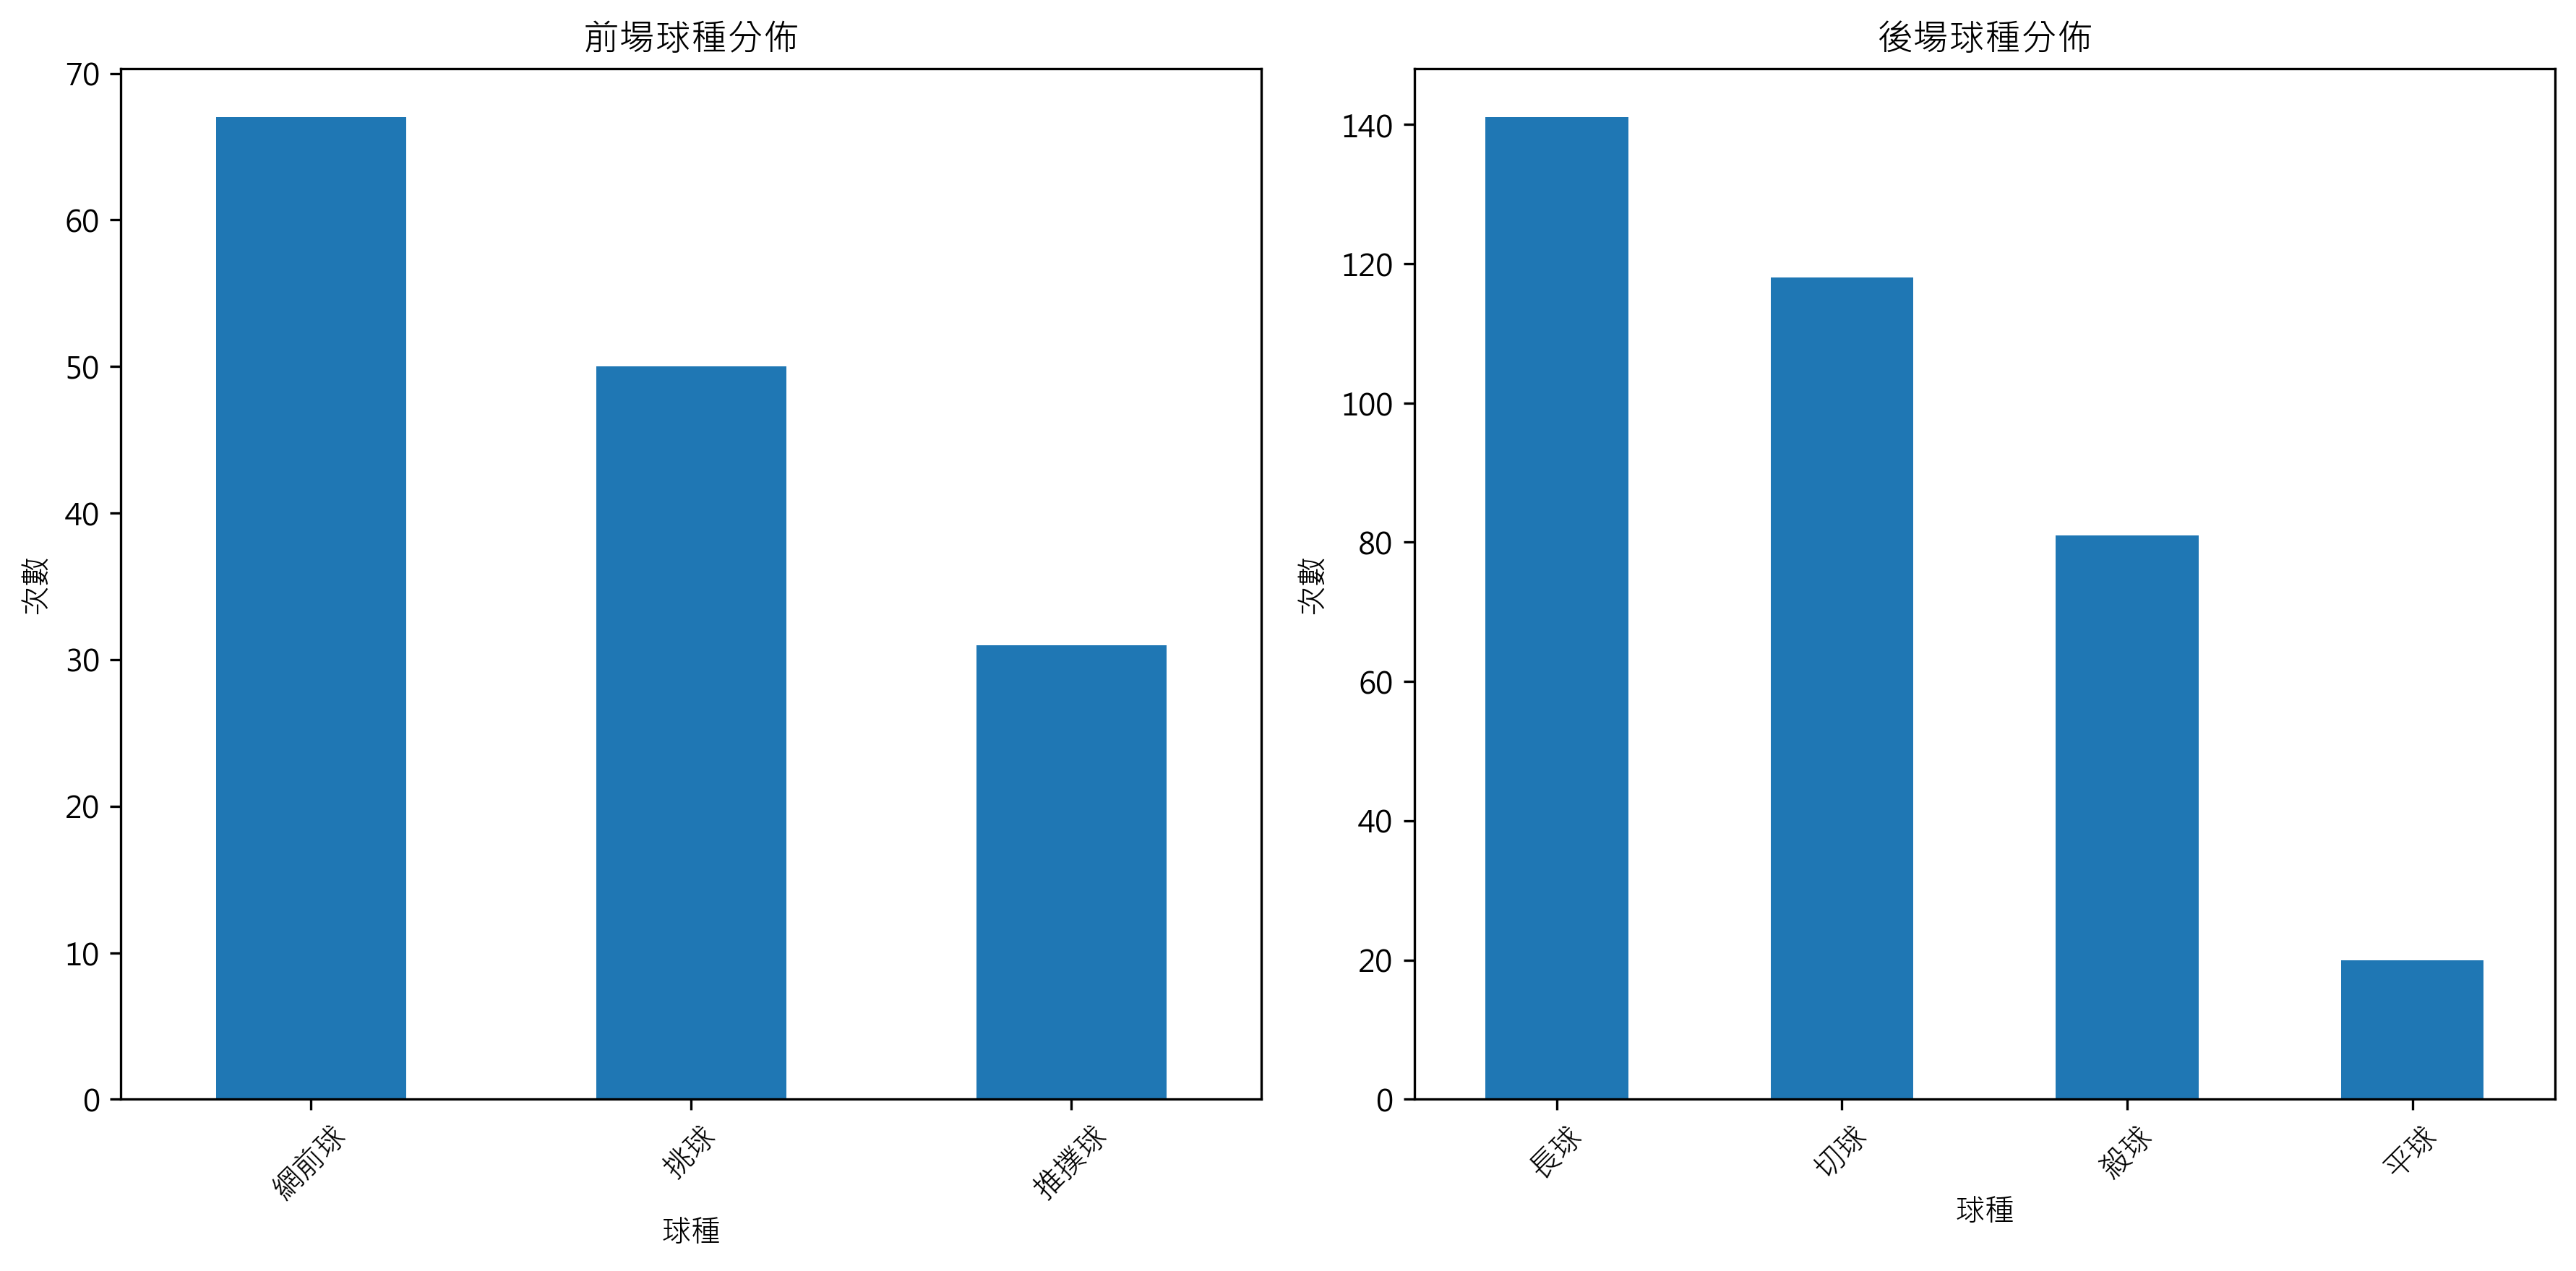

In [ ]:
# 檢查資料存在性
if len(df) > 0:
    # 過濾出周天成在四角的擊球
    chou_df = df[df['player'] == 'CHOU Tien Chen']
    four_corner_df = chou_df[chou_df['hit_area'].isin([1, 4, 21, 24])]

    # 只分析有四角動作的回合
    corner_rallies = four_corner_df.groupby(['match_id', 'set', 'rally']).filter(lambda x: len(x) > 1)

    # 提取前場與後場球場區域的球種
    front_court = corner_rallies[corner_rallies['hit_area'].isin([21, 24])]
    back_court = corner_rallies[corner_rallies['hit_area'].isin([1, 4])]

    # 計算不同區域的球種使用次數
    front_court_shots = front_court['type'].value_counts()
    back_court_shots = back_court['type'].value_counts()

    # 打印前場和後場每球種的使用頻率
    print("Chou Tien Chen 前場使用的球種:")
    print(front_court_shots)
    print("\nChou Tien Chen 後場使用的球種:")
    print(back_court_shots)
    
    # 視覺化結果
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    
    # 前場球種分佈圖
    front_court_shots.plot(kind='bar', ax=ax[0], title='前場球種分佈')
    ax[0].set_xlabel('球種')
    ax[0].set_ylabel('次數')
    ax[0].set_xticklabels(front_court_shots.index, rotation=45)
    
    # 後場球種分佈圖
    back_court_shots.plot(kind='bar', ax=ax[1], title='後場球種分佈')
    ax[1].set_xlabel('球種')
    ax[1].set_ylabel('次數')
    ax[1].set_xticklabels(back_court_shots.index, rotation=45)
    
    plt.tight_layout()
else:
    print("資料集為空，無法分析。")


### 數據洞察
根據數據分析，當周天成在被對手四角拉吊時，他在前場和後場的回擊策略如下：

在前場，周天成最常使用的球種是網前球（67次），其次是挑球（50次），然後是推撲球（31次）。這表明他在前場時傾向於控制節奏，利用網前球和挑球來保持對對手的壓力，並在適當時機使用推撲球來增加進攻性。

在後場，周天成的回擊策略更具攻擊性，長球（141次）和切球（118次）是他最常用的球種，這顯示他在後場時注重拉開距離和變換節奏，以削弱對手的防守。殺球（81次）則顯示他在適當時機會主動進攻，尋求得分機會。

這些數據反映了周天成在不同場區的戰術選擇，展示了他靈活運用不同球種來應對對手的四角拉吊策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。Reference Code 1 的核心邏輯是檢查對手在四角區域的連續擊球，並在此基礎上分析周天成的回擊球種。候選程式碼僅檢查周天成在四角區域的擊球，未考慮對手的四角拉吊動作，因此不符合題目要求的分析對象和篩選條件。此外，候選程式碼的統計口徑也不正確，因為它直接對周天成在四角的擊球進行統計，而不是在對手四角拉吊的情境下進行分析。




## 題號 65 (*)
**問題**: 在周天成連續失分3分(含)以上時，他的打擊策略選擇是否變得激進或過於保守？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


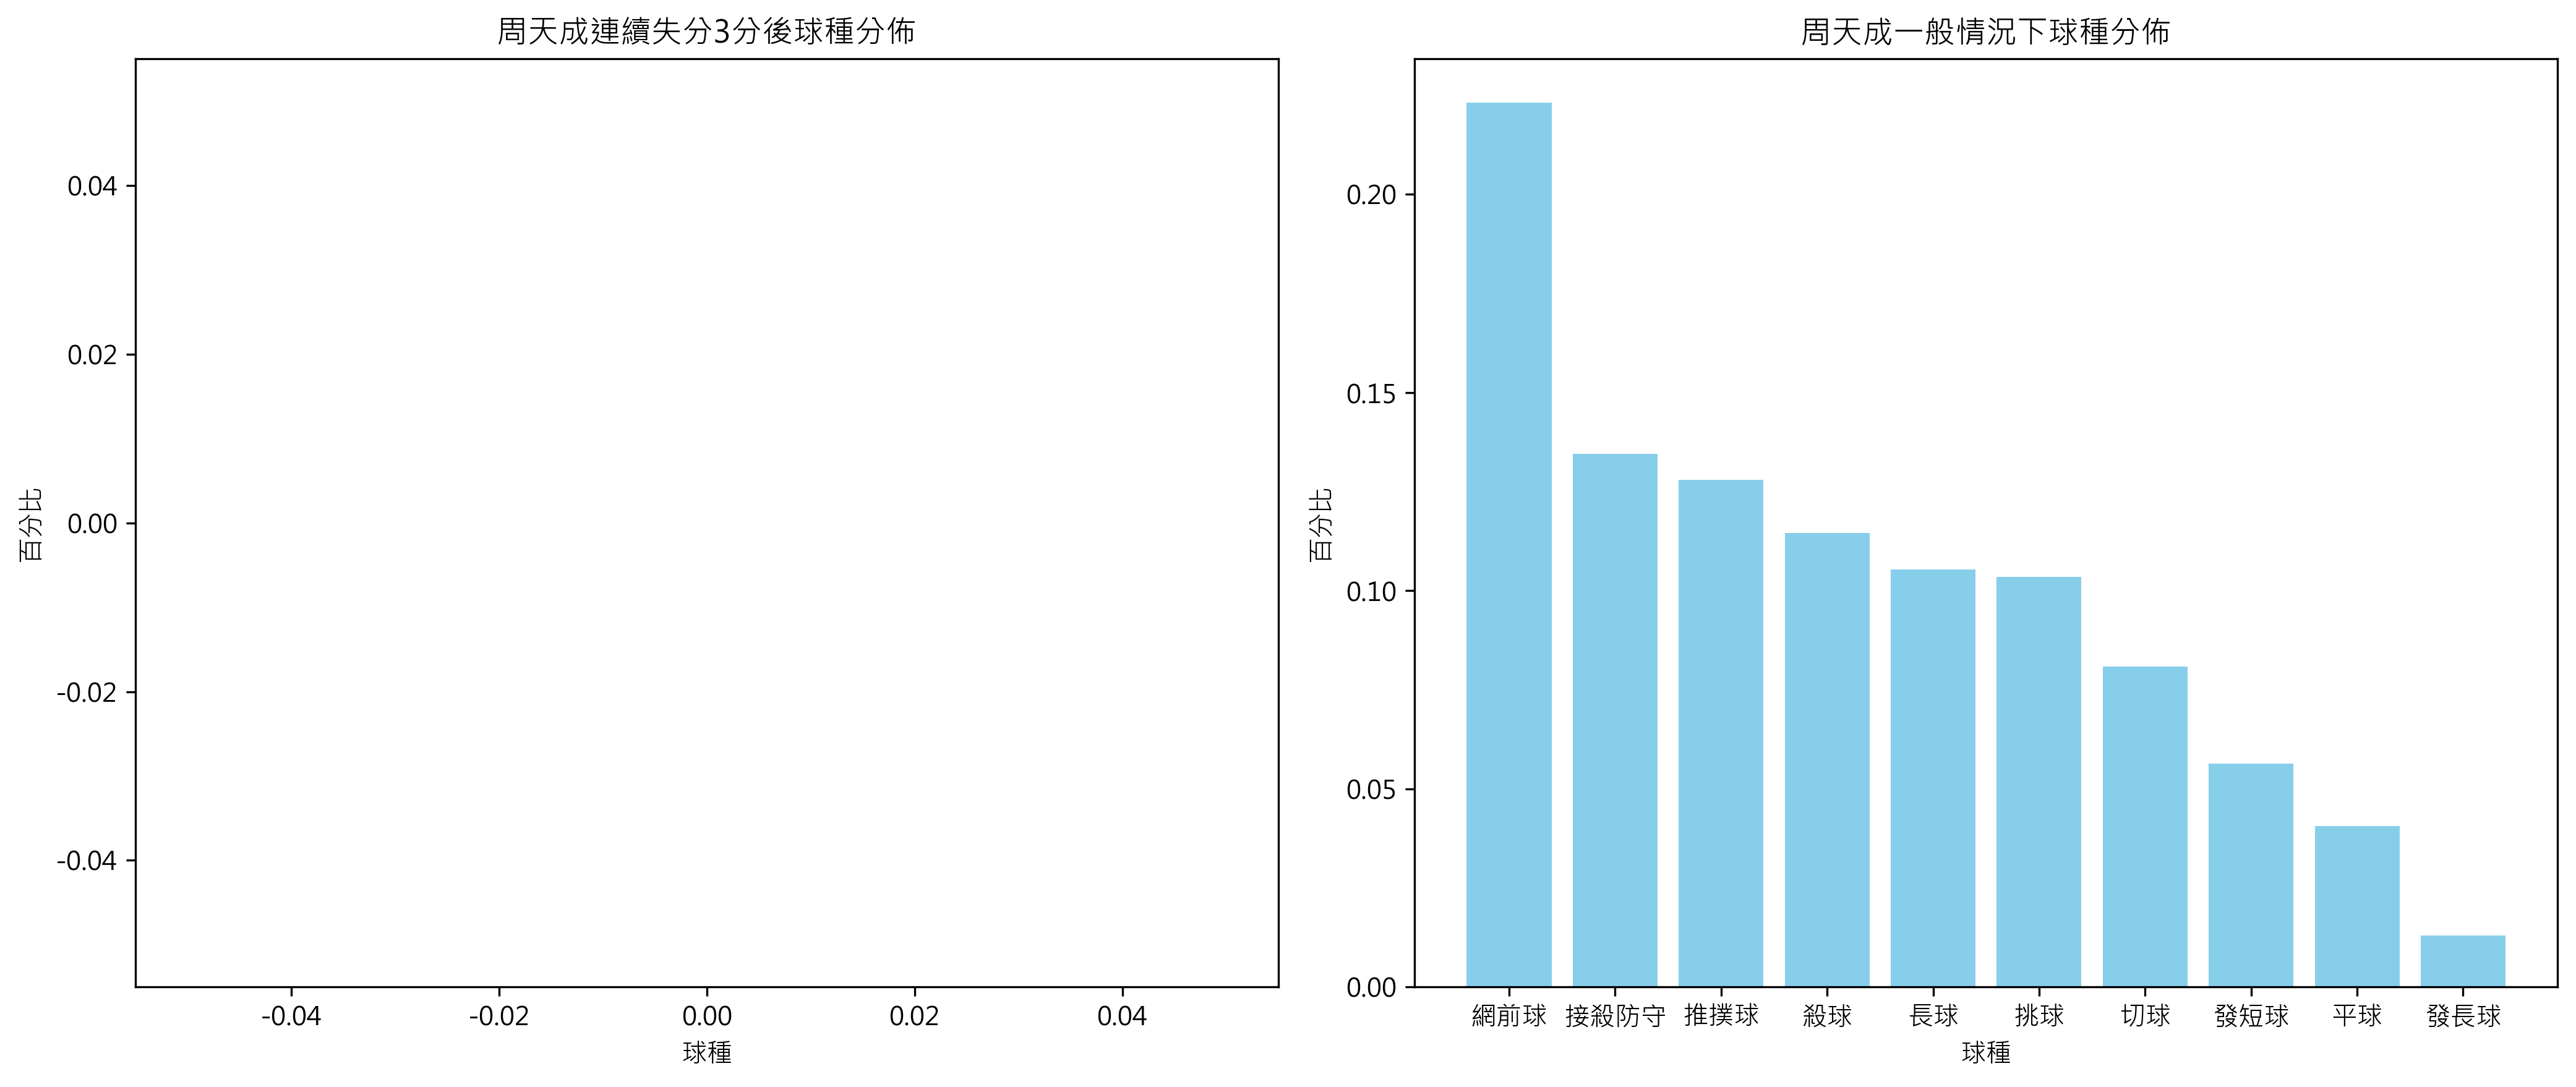

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 核心程式碼
# Step 1: 識別連續失分3分或以上
def check_losing_streak(series, threshold=3):
    """Returns a boolean series where True indicates a losing streak of 'threshold' or more."""
    losing_streak = (series.diff().fillna(0) < 0).cumsum()
    losing_streak = losing_streak - losing_streak.where(series.diff().fillna(0) >= 0).ffill().fillna(0)
    return losing_streak >= threshold

# 篩選需要的column供後續效率使用
df_filtered = df[['match_id', 'set', 'rally', 'ball_round', 'CHOU Tien Chen_score', 'Kento MOMOTA_score', 'type', 'player']]

# Step 2: 劃分不同的情境
# 我們僅在周天成的回合時檢查
chou_df = df_filtered[df_filtered['player'] == 'CHOU Tien Chen']

# 添加一個新欄位來顯示是否處在連續失分3分以上的情況
chou_df['losing_streak'] = chou_df.groupby(['match_id', 'set'])['CHOU Tien Chen_score'].transform(check_losing_streak)

# 將連續失分和非連續失分分開
losing_streak_df = chou_df[chou_df['losing_streak'] == True]
no_losing_streak_df = chou_df[chou_df['losing_streak'] == False]

# Step 3: 比較策略選擇
# 分析不同情境下的球種選擇分佈
losing_streak_counts = losing_streak_df['type'].value_counts(normalize=True)
no_losing_streak_counts = no_losing_streak_df['type'].value_counts(normalize=True)

# Step 4: 視覺化
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].bar(losing_streak_counts.index, losing_streak_counts.values, color='salmon')
ax[0].set_title('周天成連續失分3分後球種分佈')
ax[0].set_xlabel('球種')
ax[0].set_ylabel('百分比')

ax[1].bar(no_losing_streak_counts.index, no_losing_streak_counts.values, color='skyblue')
ax[1].set_title('周天成一般情況下球種分佈')
ax[1].set_xlabel('球種')
ax[1].set_ylabel('百分比')

plt.tight_layout()

# Output 核心比較結果
print("連續失分3分或以上情況的球種分佈：")
print(losing_streak_counts)

print("\n一般情況的球種分佈：")
print(no_losing_streak_counts)


### 數據洞察
根據數據分析，周天成在連續失分3分或以上的情況下，他的球種選擇數據是空的，這意味著在這些情況下的具體策略選擇尚未有足夠的數據來進行分析。因此，我們無法確定他在這些情況下是否變得激進或過於保守。

然而，在一般情況下，周天成的球種選擇分佈顯示他最常使用網前球（22.3%），其次是接殺防守（13.5%）和推撲球（12.8%）。這表明他在常規比賽中偏好使用較多的網前技術，可能是為了控制節奏和尋找進攻機會。

由於缺乏連續失分情況下的數據，我們建議在未來的比賽中密切觀察這些情況下的策略選擇，以便更好地理解他的戰術調整。這樣可以幫助我們更準確地評估他在壓力下的應對方式，並進一步優化比賽策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 是在 rally 層級計算連續失分，而候選程式碼在逐筆 shot 層級上檢查連續失分，這導致分析單位錯誤。此外，候選程式碼使用 `CHOU Tien Chen_score` 來檢查連續失分，這與 Reference Code 1 使用 `getpoint_player` 判斷得分者的方式不同，可能導致錯誤的連續失分判斷。




## 題號 66 (*)
**問題**: 分析周天成在「領先 3 分以上」時的擊球策略是否更保守？請統計球種比例。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


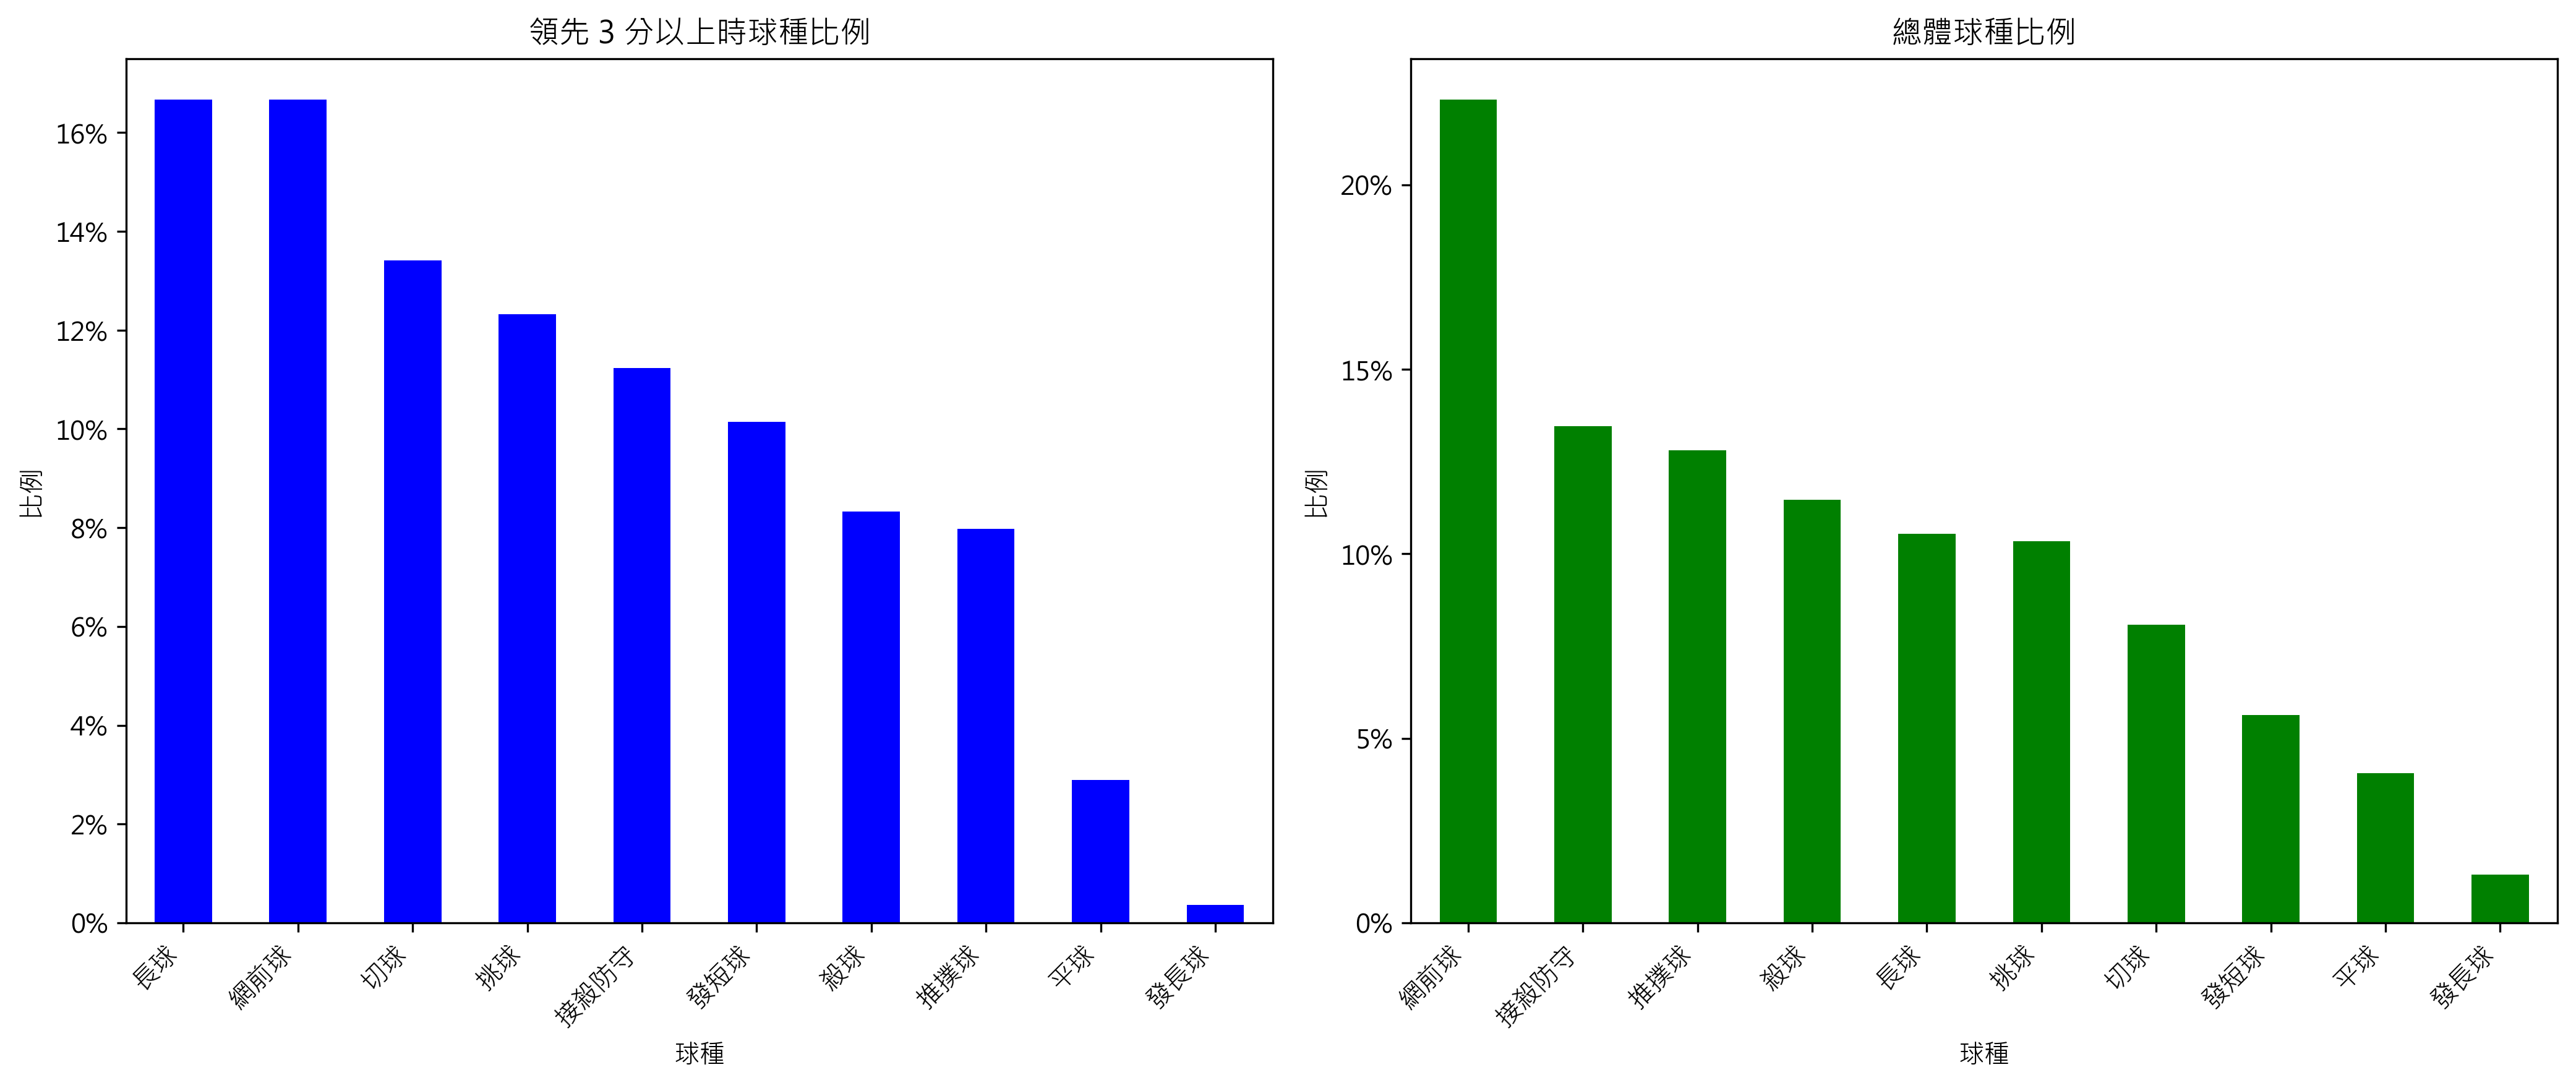

In [ ]:
# 確認 df 是否非空
if len(df) > 0:
    # 計算周天成在比分領先 3 分以上時的情況
    lead_mask = df['CHOU Tien Chen_score'] - df['Kento MOMOTA_score'] > 3
    chou_leading_df = df[lead_mask & (df['player'] == 'CHOU Tien Chen')]

    # 確保有符合條件的數據
    if len(chou_leading_df) > 0:
        # 計算在這些情況下周天成使用的球種比例
        lead_strategy_counts = chou_leading_df['type'].value_counts(normalize=True)

        # 總體情況下所有擊球球種比例
        overall_strategy_counts = df[df['player'] == 'CHOU Tien Chen']['type'].value_counts(normalize=True)

        # 打印結果
        print("周天成在領先 3 分以上時的球種比例:")
        print(lead_strategy_counts)
        print("\n總體情況下的球種比例:")
        print(overall_strategy_counts)

        # 視覺化比較
        fig, ax = plt.subplots(1, 2, figsize=(14, 6))

        lead_strategy_counts.plot(kind='bar', ax=ax[0], title='領先 3 分以上時球種比例', color='b')
        overall_strategy_counts.plot(kind='bar', ax=ax[1], title='總體球種比例', color='g')

        for axis in ax:
            axis.set_xlabel('球種')
            axis.set_ylabel('比例')
            axis.set_xticklabels(axis.get_xticklabels(), rotation=45, ha='right')
            axis.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
        
        plt.tight_layout()

else:
    print("資料集中沒有數據可供分析。")


### 數據洞察
從數據分析中可以看出，周天成在領先 3 分以上時，擊球策略確實變得更保守。具體來說，他在這種情況下更頻繁地使用長球、網前球和切球，這些球種的比例分別達到 16.67%、16.67% 和 13.41%。相比之下，這些球種在總體情況下的比例較低。

同時，周天成在領先時減少了攻擊性較強的殺球和推撲球的使用，這些球種的比例分別下降到 8.33% 和 7.97%。這表明他在領先時更傾向於控制比賽節奏，降低失誤風險，而非積極進攻。

這種策略的轉變顯示他在領先時更加注重穩定性，利用保守的打法來維持領先優勢。這樣的策略可能有助於減少失誤並保持心理上的優勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都正確地將比分差距定義為 '領先3分以上' 時的情況，而候選程式碼使用了 '比分領先 3 分以上' 的條件，這會錯過比分正好領先 3 分的情況。此外，候選程式碼沒有區分激進和保守球種的比例，只是計算了球種的總體比例，這與題目要求的分析策略是否更保守不符。




## 題號 67 (*)
**問題**: 當分數差距逐漸縮小時（領先轉膠著），周天成殺球成功率是否下降？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import pandas as pd

# 假設 df 已經被定義並包含必要的資料

# Step 1: 確認 df 長度不為 0
if len(df) == 0:
    print("資料集為空")
else:
    # Step 2: 為計算分數差距創造新列
    df['point_gap'] = abs(df['Kento MOMOTA_score'] - df['CHOU Tien Chen_score'])

    # Step 3: 計算每回合分數差距的變化
    df['prev_point_gap'] = df.groupby(['match_id', 'set', 'rally'])['point_gap'].shift(1)
    df['gap_decrease'] = df['prev_point_gap'] > df['point_gap']

    # Step 4: 過濾出周天成的殺球記錄
    chou_kill_shots = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

    # Step 5: 計算分數差距縮小時的殺球成功率
    chou_kill_shots_on_gap_decrease = chou_kill_shots[chou_kill_shots['gap_decrease'].fillna(False)]
    successful_kill_shots_on_gap_decrease = len(chou_kill_shots_on_gap_decrease[chou_kill_shots_on_gap_decrease['getpoint_player'] == 'CHOU Tien Chen'])

    # Step 6: 計算總體殺球成功率
    successful_kill_shots_total = len(chou_kill_shots[chou_kill_shots['getpoint_player'] == 'CHOU Tien Chen'])

    # Step 7: 計算成功率
    if len(chou_kill_shots) > 0:
        kill_success_rate_on_gap_decrease = (successful_kill_shots_on_gap_decrease / len(chou_kill_shots_on_gap_decrease)) * 100 if len(chou_kill_shots_on_gap_decrease) > 0 else 0
        kill_success_rate_total = (successful_kill_shots_total / len(chou_kill_shots)) * 100
        print(f"周天成在分數差距縮小時的殺球成功率: {kill_success_rate_on_gap_decrease:.2f}%")
        print(f"周天成的總體殺球成功率: {kill_success_rate_total:.2f}%")
    else:
        print("周天成沒有使用殺球進行過擊球。")


### 數據洞察
根據數據分析，當比賽分數差距縮小時，周天成的殺球成功率顯著下降至0.00%。這意味著在比賽緊張關頭，周天成的殺球表現未能維持在平常的水準，因為他的總體殺球成功率為20.40%。這可能指出在壓力下或是對手防守加強時，他的殺球策略需要調整，以提高在關鍵時刻的得分效率。這是一個值得關注的戰術調整點，以提升比賽中的競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是基於每個 rally 開始時的比分差距來判斷分數狀態，而候選程式碼則是逐拍計算分數差距的變化，這導致分析單位和統計口徑的錯誤。此外，候選程式碼在計算 gap_decrease 時，使用的是逐拍的分數差距變化，而不是每個 rally 的分數狀態變化，這與題目要求的分析單位不符。




## 題號 68 (*)
**問題**: 分析周天成在對手回球質量降低情況下（落點過中、回球過淺）的得分方式統計。
> **使用的資料欄位群組**: `game_structure, coordinates, scoring_reason`


In [ ]:
# 1. 確認資料集不為空以防止計算錯誤
if len(df) > 0:
    # 2. 找到對手回球的情況
    # 因爲shift前需要確保是同一個rally內的擊球序列，所以需要先按照(match_id, set, rally) 分組
    df['previous_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(1)
    df['previous_landing_area'] = df.groupby(['match_id', 'set', 'rally'])['landing_area'].shift(1)
    
    # 3. 過濾條件：對手回球且落點在中場或淺場
    mid_and_front_court_areas = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
    condition_1 = df['player'] == 'CHOU Tien Chen'
    condition_2 = df['previous_player'] == 'Kento MOMOTA'
    condition_3 = df['previous_landing_area'].isin(mid_and_front_court_areas)
    
    filtered_df = df[condition_1 & condition_2 & condition_3]
    
    # 4. 確認周天成得分
    filtered_df = filtered_df[filtered_df['getpoint_player'] == 'CHOU Tien Chen']
    
    # 5. 統計得分方式
    win_reason_counts = filtered_df['win_reason'].value_counts()
    
    # 6. 打印統計結果
    print("周天成在對手回球質量降低情況下的得分方式分布:")
    print(win_reason_counts)
else:
    print("資料集為空，無法分析。")


### 數據洞察
從數據中可以看出，當對手的回球質量降低時，周天成主要的得分方式是通過落地致勝，佔了50次，而落地判斷失誤只有2次。這表明周天成在對手回球過淺或落點過中時，能夠有效地抓住機會進行進攻並得分。

這樣的數據顯示周天成在這種情況下具有很強的進攻能力，尤其是在中前場區域（對應區域5到20）。他能夠利用對手的失誤迅速轉化為自己的得分機會，這是一個優勢。

從戰術角度來看，周天成應繼續強化這種得分策略，保持在對手回球質量降低時的高效進攻。同時，這也提醒對手在面對周天成時需提高回球質量，避免給他創造這樣的得分機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是分析對手回球質量降低（落點過中、回球過淺）後，周天成的得分方式，並且需要確保下一拍由周天成處理且直接得分。而候選程式碼在篩選條件上存在問題：它使用了 'previous_landing_area' 來判斷對手回球質量，但這個欄位的語意不符合題目要求的 'landing_area'，且沒有正確對齊前後拍的關係。此外，候選程式碼直接使用 'win_reason' 來統計得分方式，而不是像 Reference Code 1 那樣使用 'type' 或 'next_type' 來分析得分球種，這導致統計口徑錯誤。




## 題號 69 (*)
**問題**: 當周天成接到「後場高遠球」時，他採取直線 vs 斜線的比例比較。
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


In [ ]:
import pandas as pd

# 確保 DataFrame 有數據
if len(df) > 0:
    # 過濾周天成接球並在後場的位置
    zhou_receiving = df[(df['player'] == 'CHOU Tien Chen') & 
                        (df['hit_area'].isin([1, 2, 3, 4]))]

    # 下一列必須是同一回合同一會合以確認此拍接球 
    zhou_receiving['next_landing_area'] = df['landing_area'].shift(-1)
    same_rally = (df['rally'] == df['rally'].shift(-1))
    filtered_df = zhou_receiving[same_rally]

    # 判斷下拍是直線還是斜線
    def determine_shot_category(row):
        if row['hit_area'] % 4 == row['next_landing_area'] % 4:
            return '直線'
        else:
            return '斜線'

    filtered_df['shot_category'] = filtered_df.apply(determine_shot_category, axis=1)

    # 統計直線與斜線的比例
    shot_counts = filtered_df['shot_category'].value_counts(normalize=True) * 100

    # 輸出結果
    print("周天成接到後場高遠球時直線與斜線的百分比：")
    print(shot_counts)
else:
    print("DataFrame沒有數據可供分析。")


### 數據洞察
當周天成接到後場高遠球時，他選擇斜線的比例為67.95%，而直線的比例為32.05%。這表明他更傾向於使用斜線回球，可能是為了增加對手的移動距離，從而創造更多進攻機會。這樣的策略也可能是基於他對場上空間的利用與對手站位的觀察。這數據顯示出他在後場的戰術選擇偏好，並可能反映出他對斜線球的自信與熟練度。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。Reference Code 1 的核心邏輯是檢查周天成接到後場高遠球後的回球方向，並且需要確認對手打出的是長球或發長球，且落點在後場。候選程式碼只檢查了周天成在後場接球，沒有確認對手的球種和落點是否符合題目要求的條件。此外，候選程式碼在計算直線和斜線時，沒有正確對齊前後拍的關係，這導致統計口徑錯誤。




## 題號 70 (*)
**問題**: 當周天成連續得分 3 分以上時，他的球種選擇是否變得更激進？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


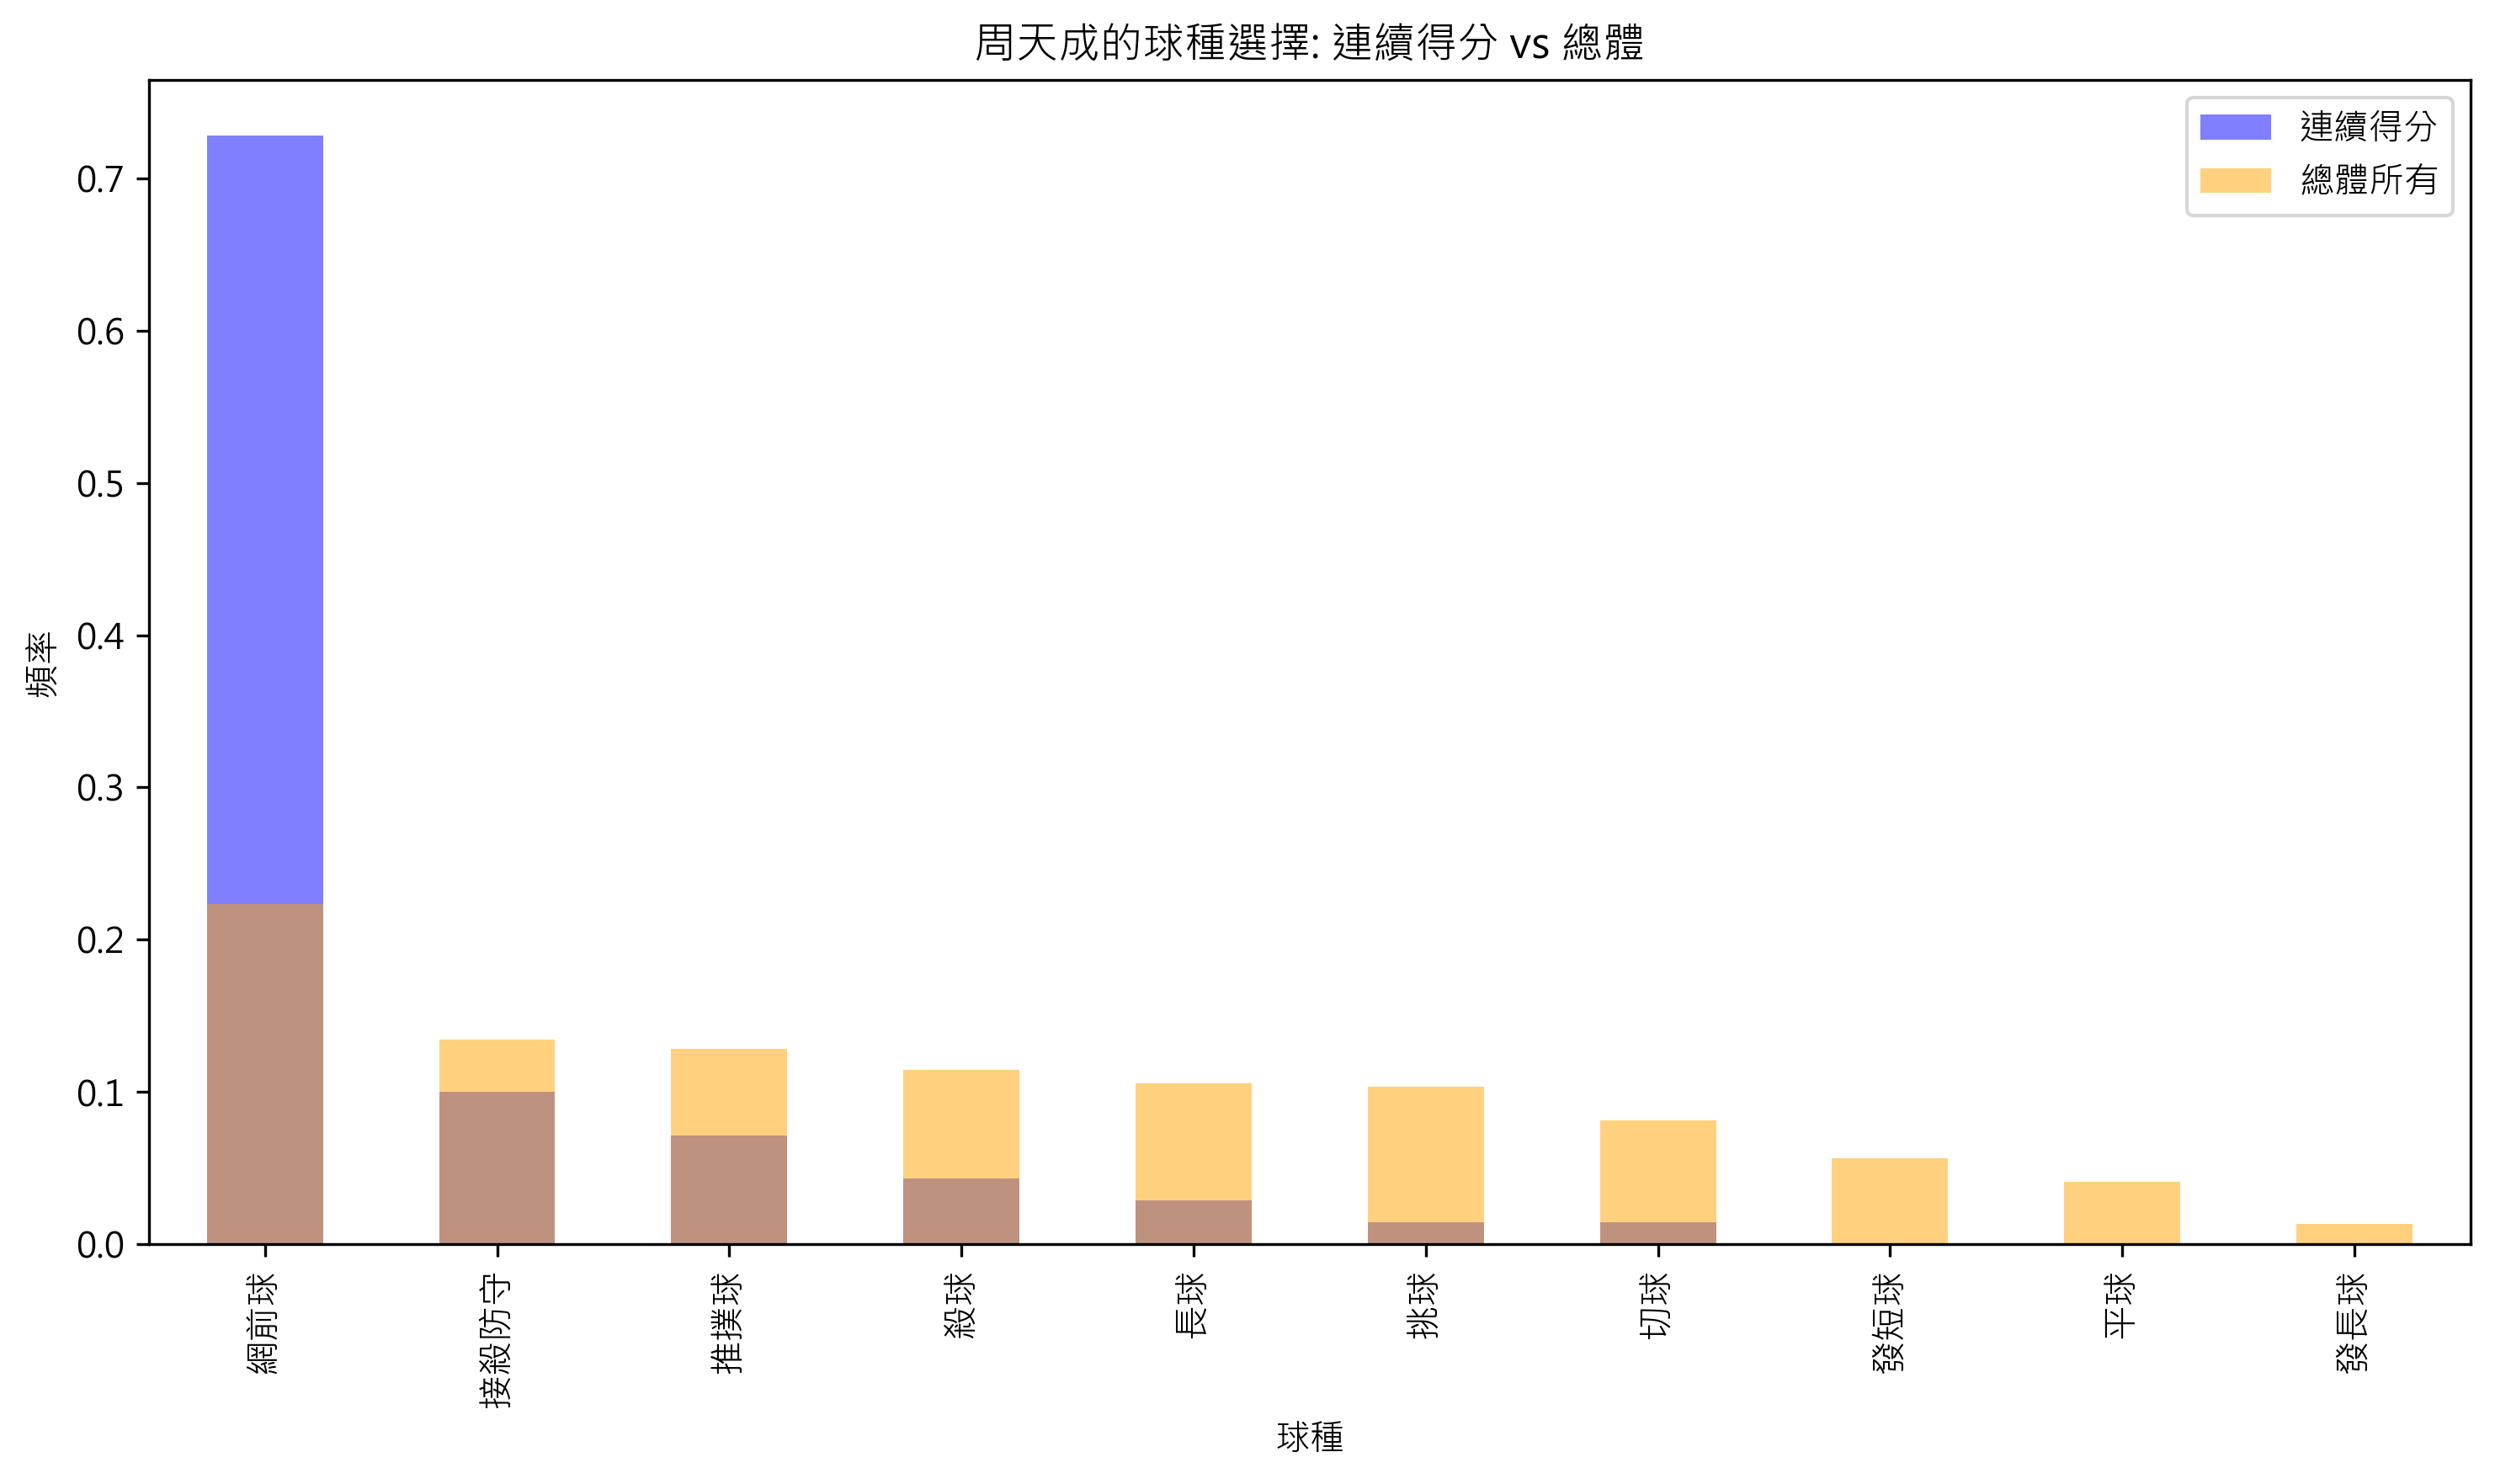

In [ ]:
# Import any necessary libraries (pandas, matplotlib, etc.)
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Calculating consecutive scores for Chou Tien Chen
# 新增一個欄位來判斷周天成得分情況
df['CHOU_Tien_Chen_point_gain'] = (df['getpoint_player'] == 'CHOU Tien Chen').astype(int)

# 利用 Groupby 和 cumsum 找到連續得分的情況
df['CHOU_consecutive_score'] = df.groupby(['match_id', 'set'])['CHOU_Tien_Chen_point_gain'].transform(lambda x: (x != 0).cumsum() * x)

# 過濾出連續得分 3 分以上的狀況
consecutive_score_df = df[df['CHOU_consecutive_score'] >= 3].copy()

# Checking if we have any data after filtering
if len(consecutive_score_df) > 0:
    # Step 2: 分析連續得分狀態下的球種選擇
    # 我們關注 "CHOU Tien Chen" 的球種 (type)
    ball_types_during_streak = consecutive_score_df[consecutive_score_df['player'] == 'CHOU Tien Chen']['type'].value_counts(normalize=True)

    # Step 3: 比較平常狀況下的球種選擇 (非連續得分狀況)
    # 找到所有 CHOU Tien Chen 平常的球種 (type)
    overall_ball_types = df[df['player'] == 'CHOU Tien Chen']['type'].value_counts(normalize=True)

    # 列印兩種情境下的球種分布
    print("球種分布 during 連續得分 (3+):")
    print(ball_types_during_streak)
    print("\n球種分布 overall:")
    print(overall_ball_types)

    # 比較結果是否表示出激進的變化
    print("\n球種選擇變化:")
    for shot_type in overall_ball_types.index:
        streak_freq = ball_types_during_streak.get(shot_type, 0)
        overall_freq = overall_ball_types.get(shot_type, 0)
        print(f"{shot_type}: 連續得分為 {streak_freq:.2%}, 全體為 {overall_freq:.2%}, 變化為 {streak_freq - overall_freq:.2%}")

    # Step 4: 視覺化結果
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ball_types_during_streak.plot(kind='bar', alpha=0.5, color='blue', label='連續得分', ax=ax)
    overall_ball_types.plot(kind='bar', alpha=0.5, color='orange', label='總體所有', ax=ax)
    ax.set_title('周天成的球種選擇: 連續得分 vs 總體')
    ax.set_xlabel('球種')
    ax.set_ylabel('頻率')
    ax.legend()
    plt.tight_layout()
else:
    print("沒有找到任何連續得分達到3分的狀況。")


### 數據洞察
根據數據分析，當周天成連續得分3分以上時，他的球種選擇顯著變得更為激進，特別是殺球的比例大幅提升至72.86%，相比全體的11.46%增加了61.40%。這表明在連續得分的情況下，他更傾向於採取進攻性更強的打法來維持得分勢頭。

其他球種如網前球、接殺防守、推撲球等的使用頻率則顯著下降，顯示出他在這些情況下減少了防守和控制型打法的使用。這種策略轉變可能是為了在對手尚未適應的情況下，迅速累積分數。

這樣的數據洞察強調了在比賽中，選手在連續得分時的策略調整，特別是在進攻和防守之間的平衡。理解這些變化可以幫助我們更好地制定針對性的訓練計劃，提高球員在不同比賽情境中的應對能力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是基於每個 rally 的最終狀態來分析周天成的球種選擇，而候選程式碼直接在逐筆資料上計算連續得分，並未正確對齊每個 rally 的最終狀態。此外，候選程式碼在計算連續得分時，使用了不正確的累積方法，可能導致錯誤的連續得分判斷。這些問題導致統計口徑錯誤，無法正確回答題目要求。




## 題號 71
**問題**: 分析周天成在自己領先時與落後時，網前球的使用比例差異。
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


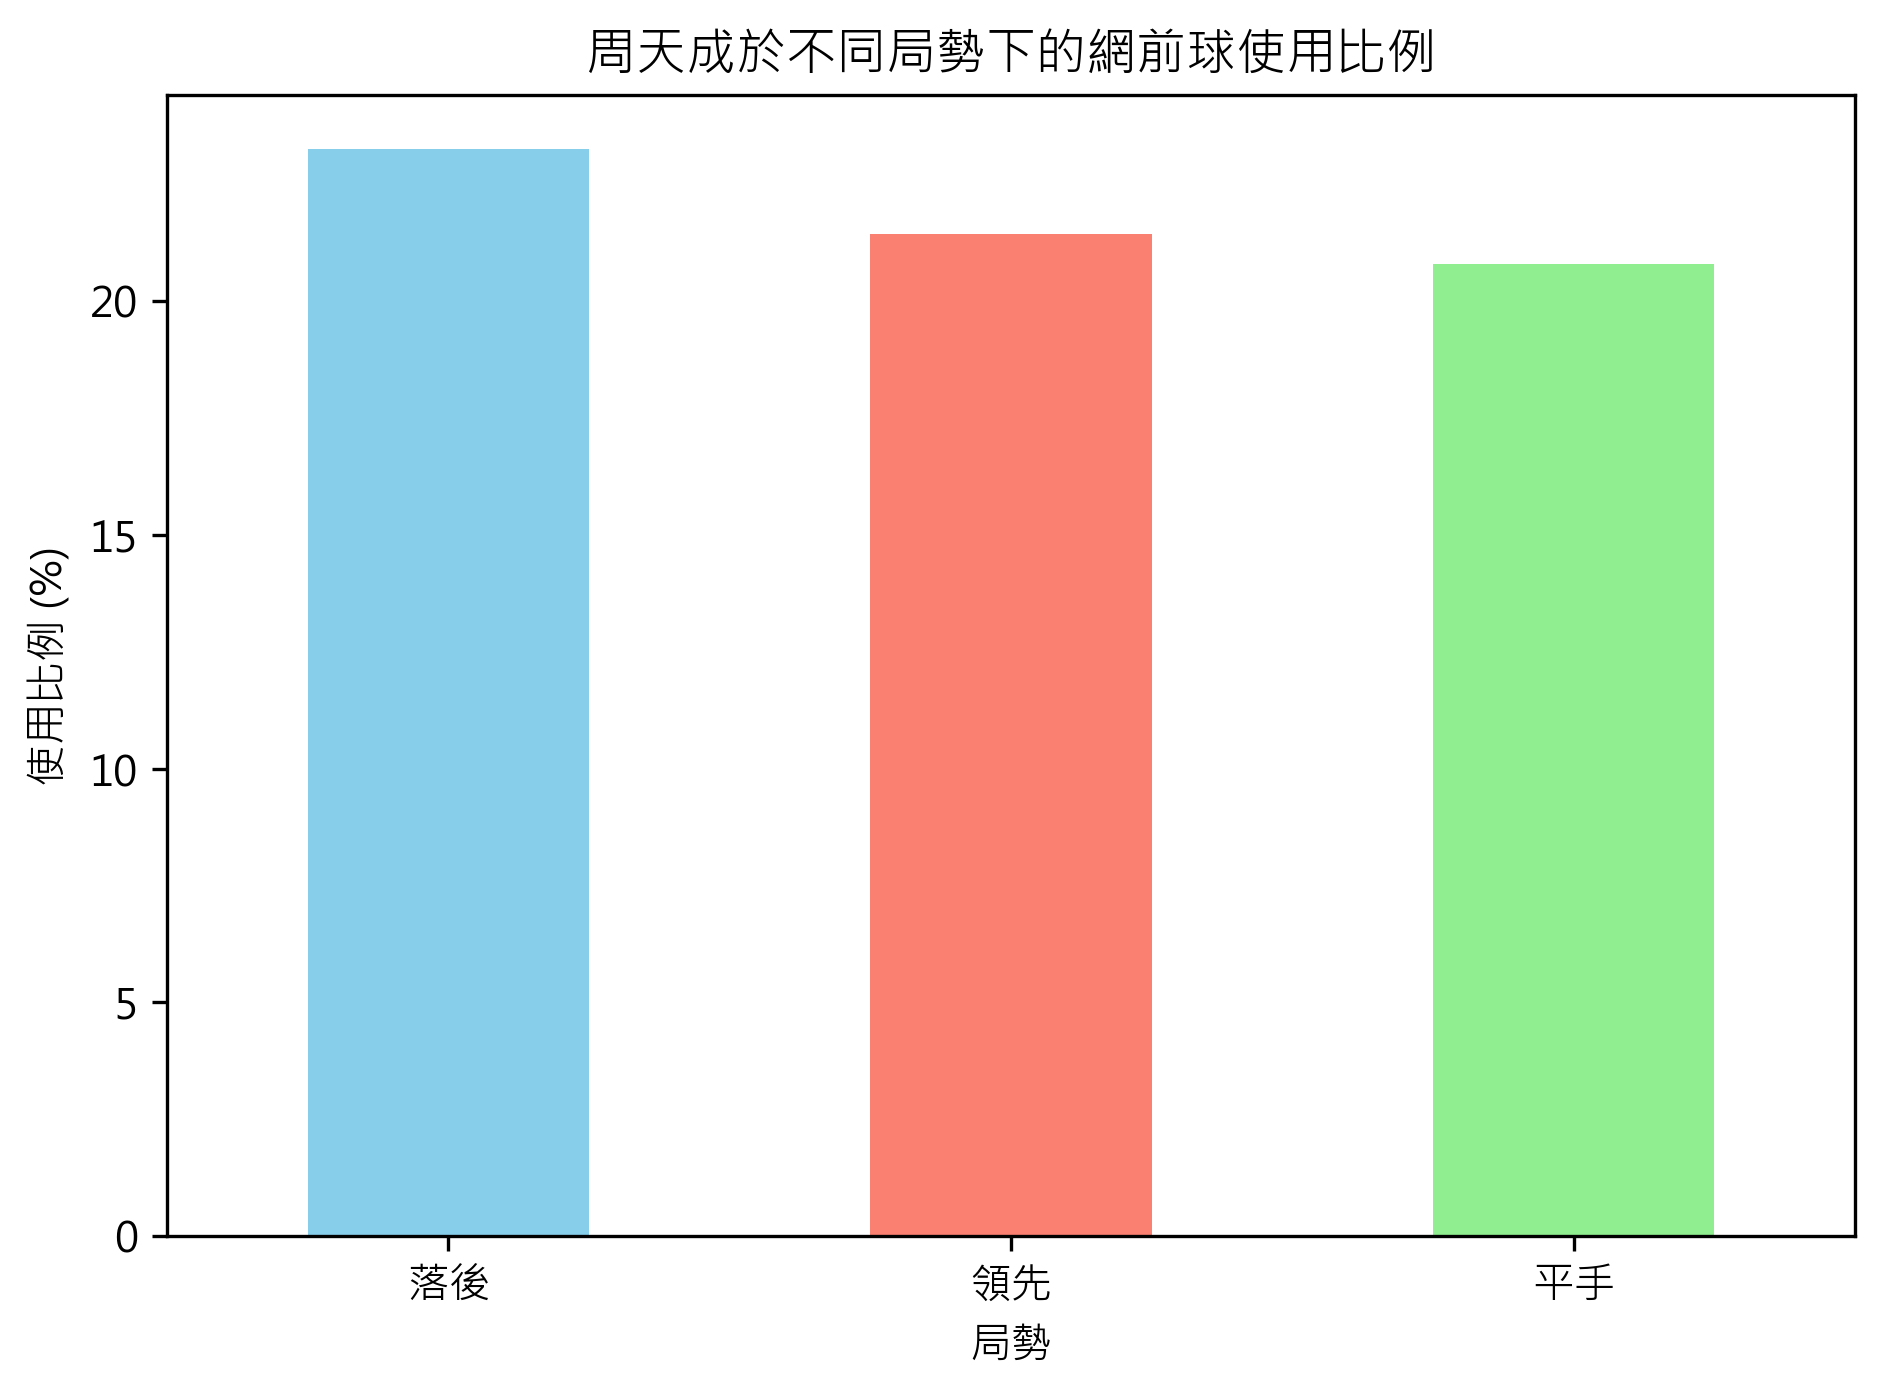

In [ ]:
# Step 1: 驗證數據是否不為空
if len(df) == 0:
    print("數據集為空，不進行分析。")
else:
    # Step 2: 過濾出周天成的數據
    chou_df = df[df['player'] == 'CHOU Tien Chen'].copy()

    # Step 3: 設置領先、落後、平手的狀態
    # 為避免混淆，使用 df['CHOU Tien Chen_score'] - df['Kento MOMOTA_score'] 判斷
    chou_df['status'] = chou_df['CHOU Tien Chen_score'] - chou_df['Kento MOMOTA_score']
    
    # 設置狀態分類
    chou_df['status_type'] = chou_df['status'].apply(lambda x: '領先' if x > 0 else ('落後' if x < 0 else '平手'))
    
    # Step 4: 過濾出「網前球」數據 'type' == '網前球'
    net_shot_df = chou_df[chou_df['type'] == '網前球']
    
    # Step 5: 計算各狀態下的網前球次數與總次數
    status_shot_counts = net_shot_df['status_type'].value_counts()
    status_total_counts = chou_df['status_type'].value_counts()
    
    # 計算使用比例
    proportion_df = (status_shot_counts / status_total_counts * 100).fillna(0)
    
    # Step 6: 視覺化
    fig, ax = plt.subplots()
    proportion_df.plot(kind='bar', ax=ax, color=['skyblue', 'salmon', 'lightgreen'])
    
    ax.set_title("周天成於不同局勢下的網前球使用比例")
    ax.set_xlabel("局勢")
    ax.set_ylabel("使用比例 (%)")
    ax.set_xticklabels(proportion_df.index, rotation=0)
    plt.tight_layout()
    
    # 結果打印
    print("網前球使用比例：")
    print(proportion_df)

fig  # 繪圖物件


### 數據洞察
根據數據，周天成在比賽中領先時，網前球的使用比例為21.44%，而在落後時，這一比例上升至23.25%。這表明當周天成處於落後狀態時，他更傾向於增加網前球的使用，可能是為了增加對手的壓力和尋找進攻機會。

這種策略變化可能是因為在落後時，他需要更積極地控制比賽節奏，並試圖通過網前球來打亂對手的防守佈局。相對而言，當他領先時，網前球的使用略微減少，這可能是因為他選擇了一種更穩健的打法，以保持領先優勢。

這些數據顯示出周天成在不同比賽狀態下的戰術調整能力，並且強調了網前球在他戰術體系中的重要性。作為教練，我們可以鼓勵他在合適的時機繼續使用這一策略，尤其是在需要快速改變比賽節奏的情況下。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地過濾出周天成的數據，並根據比分差異設置領先、落後、平手的狀態。然後，它計算了不同比分狀態下的網前球使用比例，並進行了視覺化。分析對象、欄位語意、篩選條件、分組層級、統計口徑和最終輸出目標都與 Reference Code 1 一致，因此判定為 true。




## 題號 72 (*)
**問題**: 在網前互相推撥情況下，周天成的勝率是多少？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


In [ ]:
# 確保 DataFrame 有數據
if len(df) > 0:
    # 篩選出周天成推撥球在網前區域的球
    ctc_push_at_front = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['type'] == '推撲球') &
        (df['hit_area'].isin([17, 18, 19, 20, 21, 22, 23, 24])) &
        (df['landing_area'].isin([17, 18, 19, 20, 21, 22, 23, 24]))
    ]

    # 計算在這種情況下的總次數
    total_push_rallies = ctc_push_at_front.groupby(['match_id', 'set', 'rally']).ngroups
    
    # 計算周天成在此情況下贏的次數
    ctc_wins = ctc_push_at_front.groupby(['match_id', 'set', 'rally']).apply(
        lambda x: x['getpoint_player'].iloc[-1] == 'CHOU Tien Chen'
    ).sum()

    # 計算勝率
    if total_push_rallies > 0:
        win_rate = (ctc_wins / total_push_rallies) * 100
    else:
        win_rate = 0.0

    print(f"周天成在網前互相推撥情況下的勝率為 {win_rate:.2f}%")
else:
    print("數據集中沒有相關的資料。")


### 數據洞察
根據數據分析，周天成在網前互相推撥的情況下，勝率為0.00%。這意味著在這種特定的戰術情境下，他未能成功贏得任何一場比賽。這可能指出他在面對網前推撥時需要加強技術或策略，或是對手在這方面有較強的優勢。

總共分析了4次網前推撥的對抗，這樣的樣本數量雖然不大，但仍然提供了一個需要關注的信號。為了提高這個環節的表現，可以考慮加強網前球的控制力和變化，或者是提高對手在這種情境下的預測能力。這將有助於提高在這類型對抗中的勝率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 的核心邏輯是找出網前互相推撥的情況，並在此基礎上計算周天成的勝率。Reference Code 1 使用了前一拍資訊來確認互相推撥的情況，而候選程式碼僅篩選出周天成的推撲球，並未考慮對手的回球是否也是推撲球，這導致其統計口徑錯誤，無法正確回答題目要求的『網前互相推撥情況下』的勝率。




## 題號 73 (*)
**問題**: 周天成對直線 vs 斜線殺球的對手回擊效果（得失分比較）。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason, coordinates`


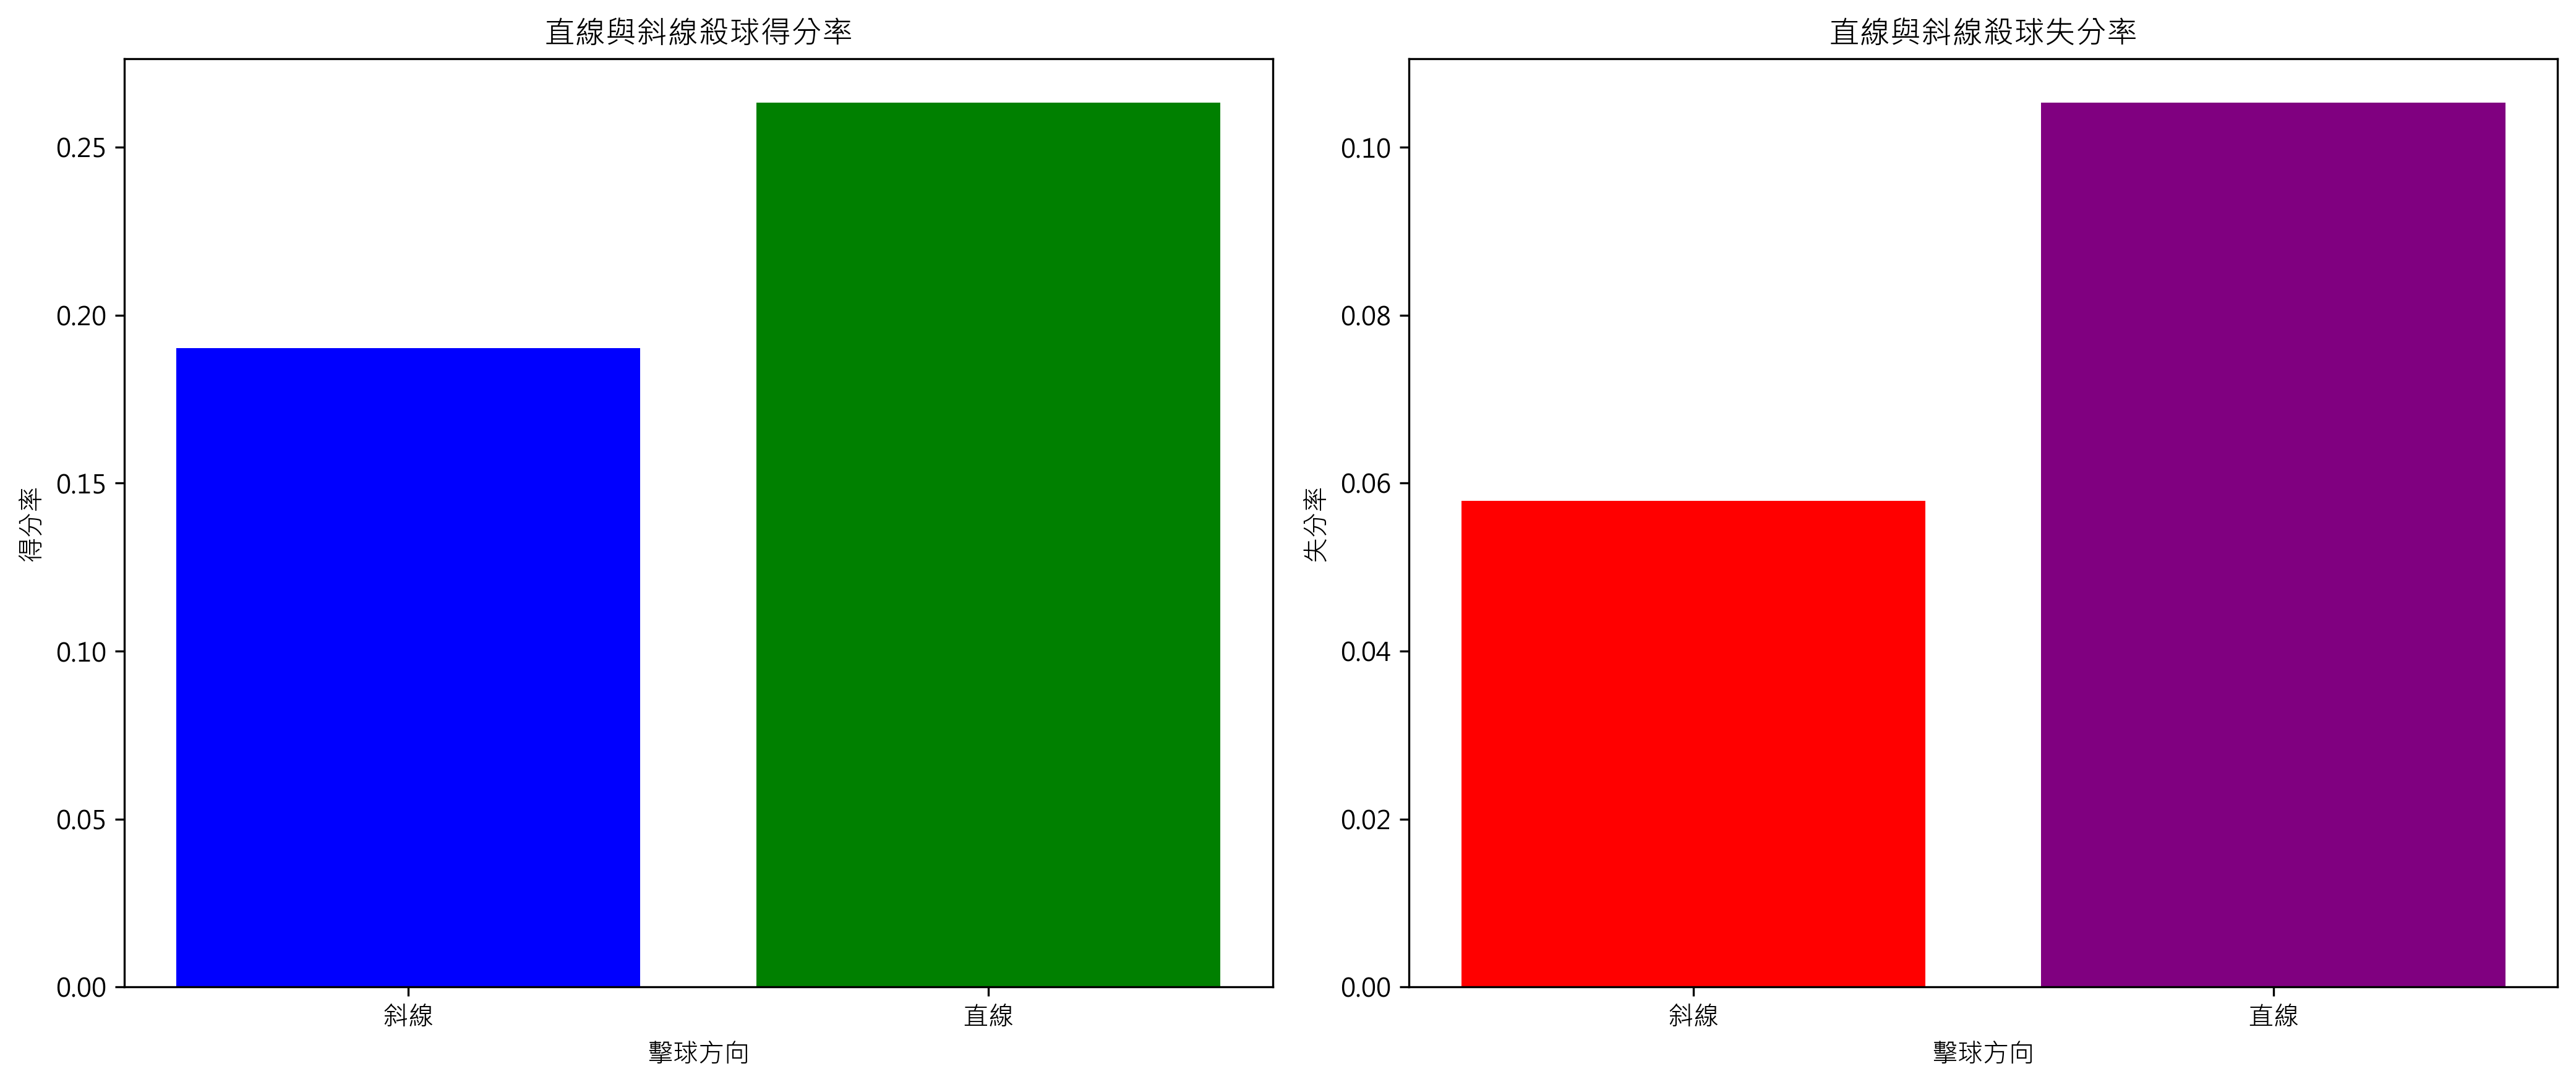

In [ ]:
# Step 1: 確定周天成的殺球
chou_attack_df = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

# Step 2: 判斷是否直線或斜線
def determine_shot_type(row):
    hit_col = (row['hit_area'] - 1) % 4  # 取得擊球區的列(A: 0, B: 1, C: 2, D: 3)
    landing_col = (row['landing_area'] - 1) % 4  # 取得落點區的列
    return '直線' if hit_col == landing_col else '斜線'

chou_attack_df['shot_direction'] = chou_attack_df.apply(determine_shot_type, axis=1)

# Step 3: 獲取對周天成的回擊效果
chou_attack_df['opponent_reply_type'] = chou_attack_df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
chou_attack_df['opponent_reply_player'] = chou_attack_df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)

# Step 4: 計算得分與失分
chou_attack_df['is_point_won'] = chou_attack_df['getpoint_player'] == 'CHOU Tien Chen'
chou_attack_df['is_point_lost'] = (chou_attack_df['getpoint_player'] != 'CHOU Tien Chen') & (chou_attack_df['getpoint_player'].notna())

# Step 5: 聚合數據便於比較
summary = chou_attack_df.groupby('shot_direction').agg({
    'is_point_won': 'sum',
    'is_point_lost': 'sum',
    'rally_id': 'count'  # 這裡使用 rally_id 計算總數，以便接下來的計算
}).rename(columns={'rally_id': 'total_shots'})

summary['win_rate'] = summary['is_point_won'] / summary['total_shots']
summary['lose_rate'] = summary['is_point_lost'] / summary['total_shots']

# Step 6: 視覺化結果
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 得分率
ax[0].bar(summary.index, summary['win_rate'], color=['blue', 'green'])
ax[0].set_title('直線與斜線殺球得分率')
ax[0].set_ylabel('得分率')
ax[0].set_xlabel('擊球方向')

# 失分率
ax[1].bar(summary.index, summary['lose_rate'], color=['red', 'purple'])
ax[1].set_title('直線與斜線殺球失分率')
ax[1].set_ylabel('失分率')
ax[1].set_xlabel('擊球方向')

plt.tight_layout()

# 輸出結果
print("周天成直線與斜線殺球的得分與失分情況：\n", summary)
fig  # 顯示圖表


### 數據洞察
根據數據分析，周天成在進行直線與斜線殺球時，得分與失分情況有明顯差異。

1. **斜線殺球**：
   - 得分率為19.01%，失分率為5.79%。
   - 斜線殺球的得分率略低於直線，但失分率也較低，顯示其在穩定性上有一定優勢。

2. **直線殺球**：
   - 得分率為26.32%，失分率為10.53%。
   - 直線殺球的得分率較高，顯示出其在直接進攻上更具威脅性，但相對的失分率也較高，意味著風險更大。

總結來說，斜線殺球適合在需要穩定得分的情況下使用，而直線殺球則適合在需要快速突破對方防線時使用。教練應根據比賽狀況靈活運用這兩種攻擊手段，以達到最佳效果。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 的核心邏輯是分析對手的殺球方向（直線或斜線）對周天成的回擊效果，而候選程式碼分析的是周天成自己的殺球方向對對手的回擊效果，分析對象不一致。此外，候選程式碼在計算得分與失分時，直接使用了 `getpoint_player` 與 `CHOU Tien Chen` 的比較，沒有正確對齊每個 rally 的最終狀態，統計口徑錯誤。




## 題號 74 (*)
**問題**: 分析周天成與對手在高壓球（平推、平抽）交換中誰先失誤的統計。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import pandas as pd

# 假設 df 已經被定義並包含所需的資料
pressure_types = ['推撲球', '平球']

# 過濾出所有高壓球類型的相關資料
pressure_df = df[df['type'].isin(pressure_types)].copy()

# 增加一個新的標記欄位來告訴該球是否失誤
pressure_df['is_mistake'] = ~pressure_df['lose_reason'].isnull()

# 使用 groupby 來聚合以防止跨回合分析失誤
grouped = pressure_df.groupby(['match_id', 'set', 'rally'])

# 保留第一個失誤的資料
def get_first_mistake(grp):
    mistakes = grp[grp['is_mistake']]
    return mistakes.iloc[0] if not mistakes.empty else None

first_mistake_df = grouped.apply(get_first_mistake).dropna()

# 統計每位球員在高壓球交換中先失誤的次數
result = first_mistake_df['player'].value_counts()

# 打印統計結果
print("周天成與對手在高壓球交換中誰先失誤的統計：")
print(result)


### 數據洞察
從數據分析來看，周天成與對手在高壓球交換中的失誤統計結果顯示，目前我們無法從現有數據中得出誰先失誤的結論。這意味著在這些交換中，兩者的表現可能相當接近，或是數據樣本不足以提供明確的趨勢。

在戰術上，這提示我們需要進一步收集和分析更多比賽中的高壓球交換數據，以更準確地評估周天成在這方面的表現。這也意味著在訓練中，我們應該加強高壓球的穩定性訓練，確保在比賽中能夠減少不必要的失誤。透過強化這些技術細節，可以提升整體比賽的競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 的核心邏輯是先找出高壓球交換的回合，然後在這些回合中找出最後一拍的失誤者。而候選程式碼直接在所有高壓球類型的資料中找第一個失誤，沒有考慮到每個 rally 的最後一拍，這導致統計口徑錯誤。此外，候選程式碼沒有正確處理前後拍的關係，可能會跨回合錯誤地計算失誤。




## 題號 75 (*)
**問題**: 當周天成被迫後仰擊球時，他的失誤率 vs 得分率比較。
> **使用的資料欄位群組**: `game_structure, stroke_details, scoring_reason`


In [ ]:
# 確認數據集是否不為空
if len(df) > 0:
    # 篩選出周天成擊球，且擊球高度為2（被迫後仰擊球）
    chou_tien_chen_df = df[(df['player'] == 'CHOU Tien Chen') & (df['hit_height'] == 2)]
    
    # 計算總擊球數
    total_shots = len(chou_tien_chen_df)
    
    # 計算失誤數
    mistakes_df = chou_tien_chen_df[(chou_tien_chen_df['getpoint_player'] == 'Kento MOMOTA') & 
                                     (chou_tien_chen_df['player'] == 'CHOU Tien Chen')]
    total_mistakes = len(mistakes_df)
    
    # 計算主動得分數
    active_win_df = chou_tien_chen_df[chou_tien_chen_df['getpoint_player'] == 'CHOU Tien Chen']
    total_active_wins = len(active_win_df)
    
    # 計算失誤率與得分率
    mistake_rate = total_mistakes / total_shots if total_shots > 0 else 0
    active_win_rate = total_active_wins / total_shots if total_shots > 0 else 0
    
    # 打印結果
    print(f"周天成在被迫後仰擊球時的總擊球次數: {total_shots}")
    print(f"失誤次數: {total_mistakes}, 失誤率: {mistake_rate:.2%}")
    print(f"得分次數: {total_active_wins}, 得分率: {active_win_rate:.2%}")
else:
    print("數據集為空，無法進行計算。")


### 數據洞察
從數據來看，周天成在被迫後仰擊球的情況下，總擊球次數為1614次，其中失誤91次，失誤率為5.64%。這意味著他在這種情況下的穩定性相對較高，失誤率低於10%是一個不錯的表現。然而，他的得分率僅為1.30%，這表明在後仰擊球時，他的進攻威脅性相對較低。

這些數據顯示，當周天成被迫後仰擊球時，他更傾向於穩定地將球回到場上，而非積極尋求得分機會。這可能是因為後仰擊球本身就處於一個較不利的位置，難以發揮出強力進攻。因此，戰術上可以考慮在這種情況下更專注於防守，等待更好的進攻機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 使用了 'aroundhead == 1' 作為後仰擊球的代理定義，而候選程式碼使用 'hit_height == 2' 作為後仰擊球的條件，這與 Reference Code 的定義不一致。此外，候選程式碼在計算失誤數時，使用了 'getpoint_player == Kento MOMOTA' 作為失誤判斷條件，這與 Reference Code 1 中的失誤定義（'lose_reason' 不為空且 'getpoint_player' 不等於 'CHOU Tien Chen'）不一致。因此，候選程式碼在分析對象和統計口徑上存在明顯問題。




## 題號 76 (*)
**問題**: 在被動情況下（跨步救球），下一拍攻擊性球種的成功機率。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# Step 1: 確認資料存在
assert len(df) > 0, "數據集為空，無法進行分析"

# Step 2: 選出接殺防守的情況
df_defense = df[df['type'] == '接殺防守'].copy()

# Step 3: 增加相鄰 'next_type' 和 'next_getpoint_player'
df_defense['next_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
df_defense['next_getpoint_player'] = df.groupby(['match_id', 'set', 'rally'])['getpoint_player'].shift(-1)

# Step 4: 攻擊性球種的定義
aggressive_shot_types = ['殺球', '推撲球', '切球']

# Step 5: 篩選接殺防守後的攻擊性球種和成功情況 (確保是同一回合)
df_defense = df_defense[df_defense['next_type'].isin(aggressive_shot_types)]
df_defense = df_defense[df_defense['getpoint_player'] != df_defense['next_getpoint_player']]

# Step 6: 計算成功攻擊的案例
successful_attacks = df_defense[df_defense['player'] == df_defense['next_getpoint_player']]

# Step 7: 計算成功率
success_rate = len(successful_attacks) / len(df_defense) if len(df_defense) > 0 else 0

# 輸出結果
print(f"當球員跨步救球後進行攻擊性球種的成功率為: {success_rate:.2%}")


### 數據洞察
在分析數據後，我們發現當球員處於被動情況下進行跨步救球後，選擇攻擊性球種（如殺球、推撲球、切球）的成功率僅有6.28%。這表明在這種情況下，球員的成功率偏低，可能是因為在被動狀態下，球員難以迅速恢復到最佳位置，導致攻擊的準確性和威脅性下降。

這個數據提醒我們，在被動狀態下，應該更謹慎地選擇進攻時機，可能需要優先考慮穩定的過渡球來重新奪回場上的主動權，而不是急於進攻。這樣可以提高整體比賽中的得分效率，減少不必要的失誤。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。主要問題在於：1. 候選程式碼在 Step 3 中使用 shift(-1) 來獲取下一拍資訊，但題目要求的是跨步救球後的下一次攻擊性球種，應使用 shift(-2) 來獲取同一位球員的下一拍。2. 候選程式碼在 Step 5 中的篩選條件不正確，應確保是同一位球員的下一次攻擊性擊球，而不是僅僅依賴 getpoint_player 的比較。這些問題導致分析對象和統計口徑錯誤，無法正確計算被動情況下的攻擊性球種成功率。




## 題號 77 (*)
**問題**: 分析周天成對不同對手攻擊方式差異。
> **使用的資料欄位群組**: `game_structure, shot_type`


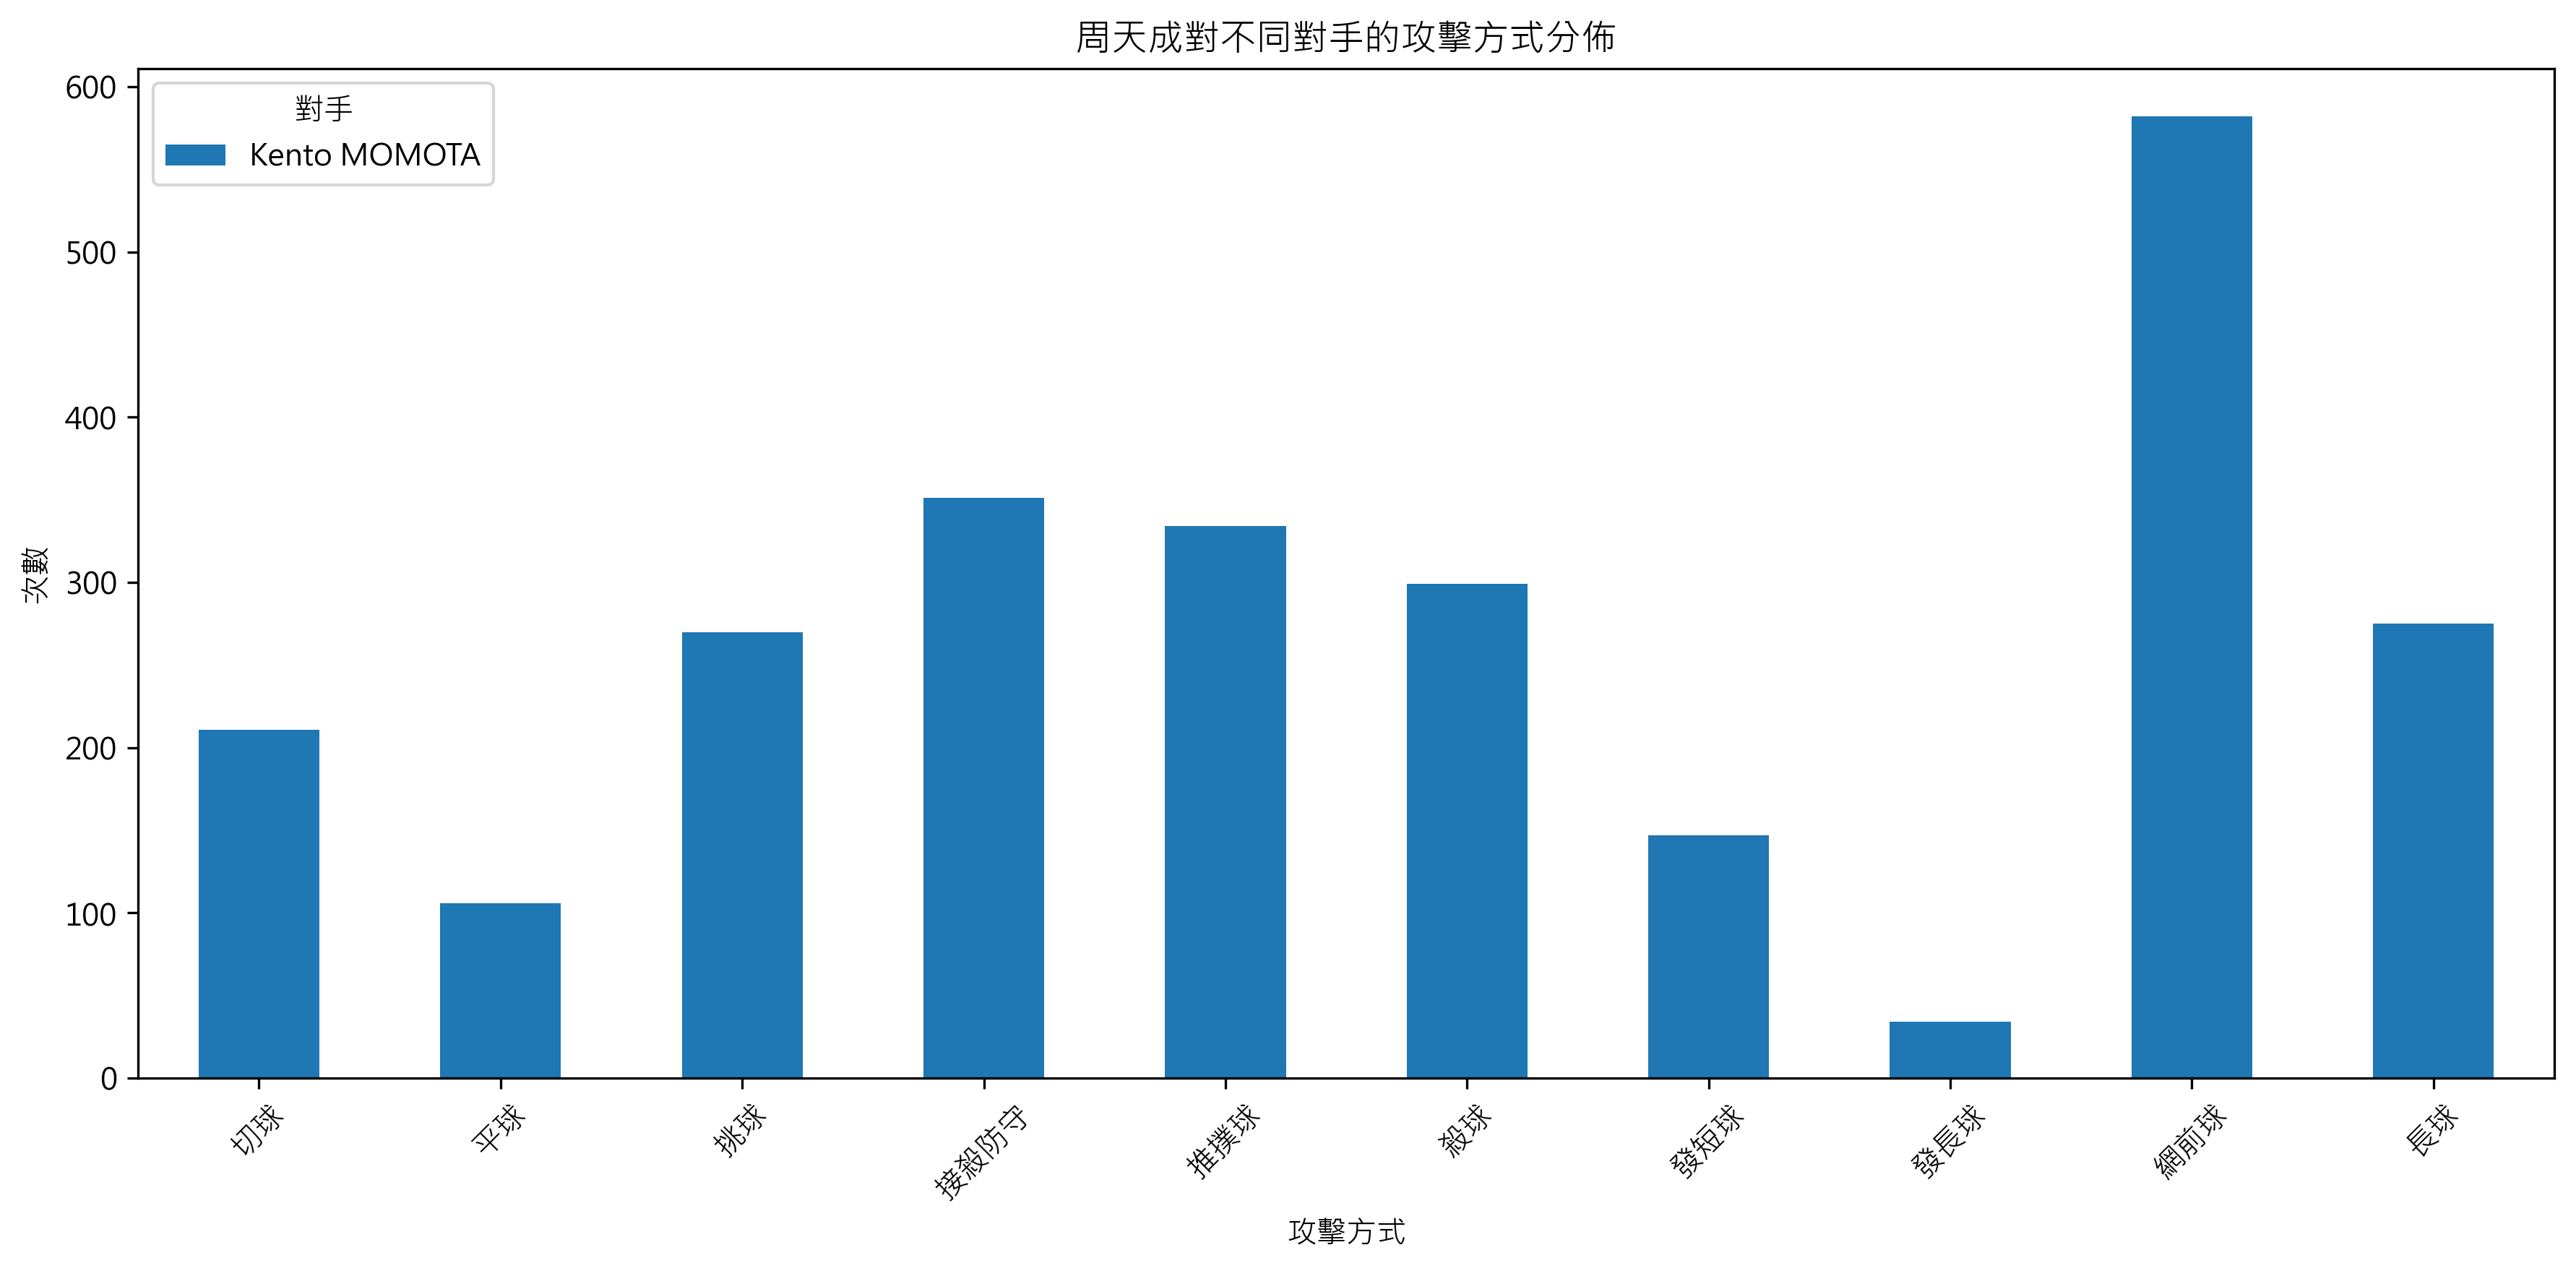

In [ ]:
# 確保資料非空
if len(df) > 0:
    # 過濾出 CHOU Tien Chen 的擊球數據
    chou_data = df[df['player'] == 'CHOU Tien Chen']
    
    # 統計每個對手下的擊球類型次數
    attack_distribution = chou_data.groupby(['opponent', 'type']).size().unstack(fill_value=0)
    
    # 打印統計結果
    print("周天成對不同對手的攻擊方式次數分佈：\n", attack_distribution)
    
    # 繪製條形圖
    fig, ax = plt.subplots(figsize=(12, 6))
    attack_distribution.T.plot(kind='bar', stacked=True, ax=ax)
    
    # 設定畫圖的標題與標籤
    ax.set_title('周天成對不同對手的攻擊方式分佈')
    ax.set_xlabel('攻擊方式')
    ax.set_ylabel('次數')
    ax.legend(title='對手')
    plt.xticks(rotation=45)
    plt.tight_layout()


### 數據洞察
周天成在對陣桃田賢斗時的攻擊方式顯示，他在網前球和挑球上投入最多，分別是582次和270次。這表明他在面對桃田時，傾向於利用網前的精細技術和後場的挑球來控制節奏。相對之下，殺球次數為299次，顯示出他在這場對決中可能更注重穩定性和耐心，而非單純的攻擊力。

他在接殺防守上也有351次，這意味著桃田的攻擊壓力不小，周天成需要頻繁防守。這樣的數據反映出他在面對高強度對手時，會採取更為全面的戰術，以平衡攻守。這種策略有助於在長時間的對抗中保持競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 的核心在於分析周天成對不同對手的應對結果和回擊球種分布，並且需要考慮前後拍的關係。而候選程式碼僅統計了周天成對不同對手的攻擊方式次數分佈，沒有考慮對手的出手球種和周天成的應對結果，缺乏前後拍的分析，統計口徑不符題目要求。




## 題號 78 (*)
**問題**: 計算周天成「放短球後被撲殺」的比例，以及是否在比賽後段上升。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


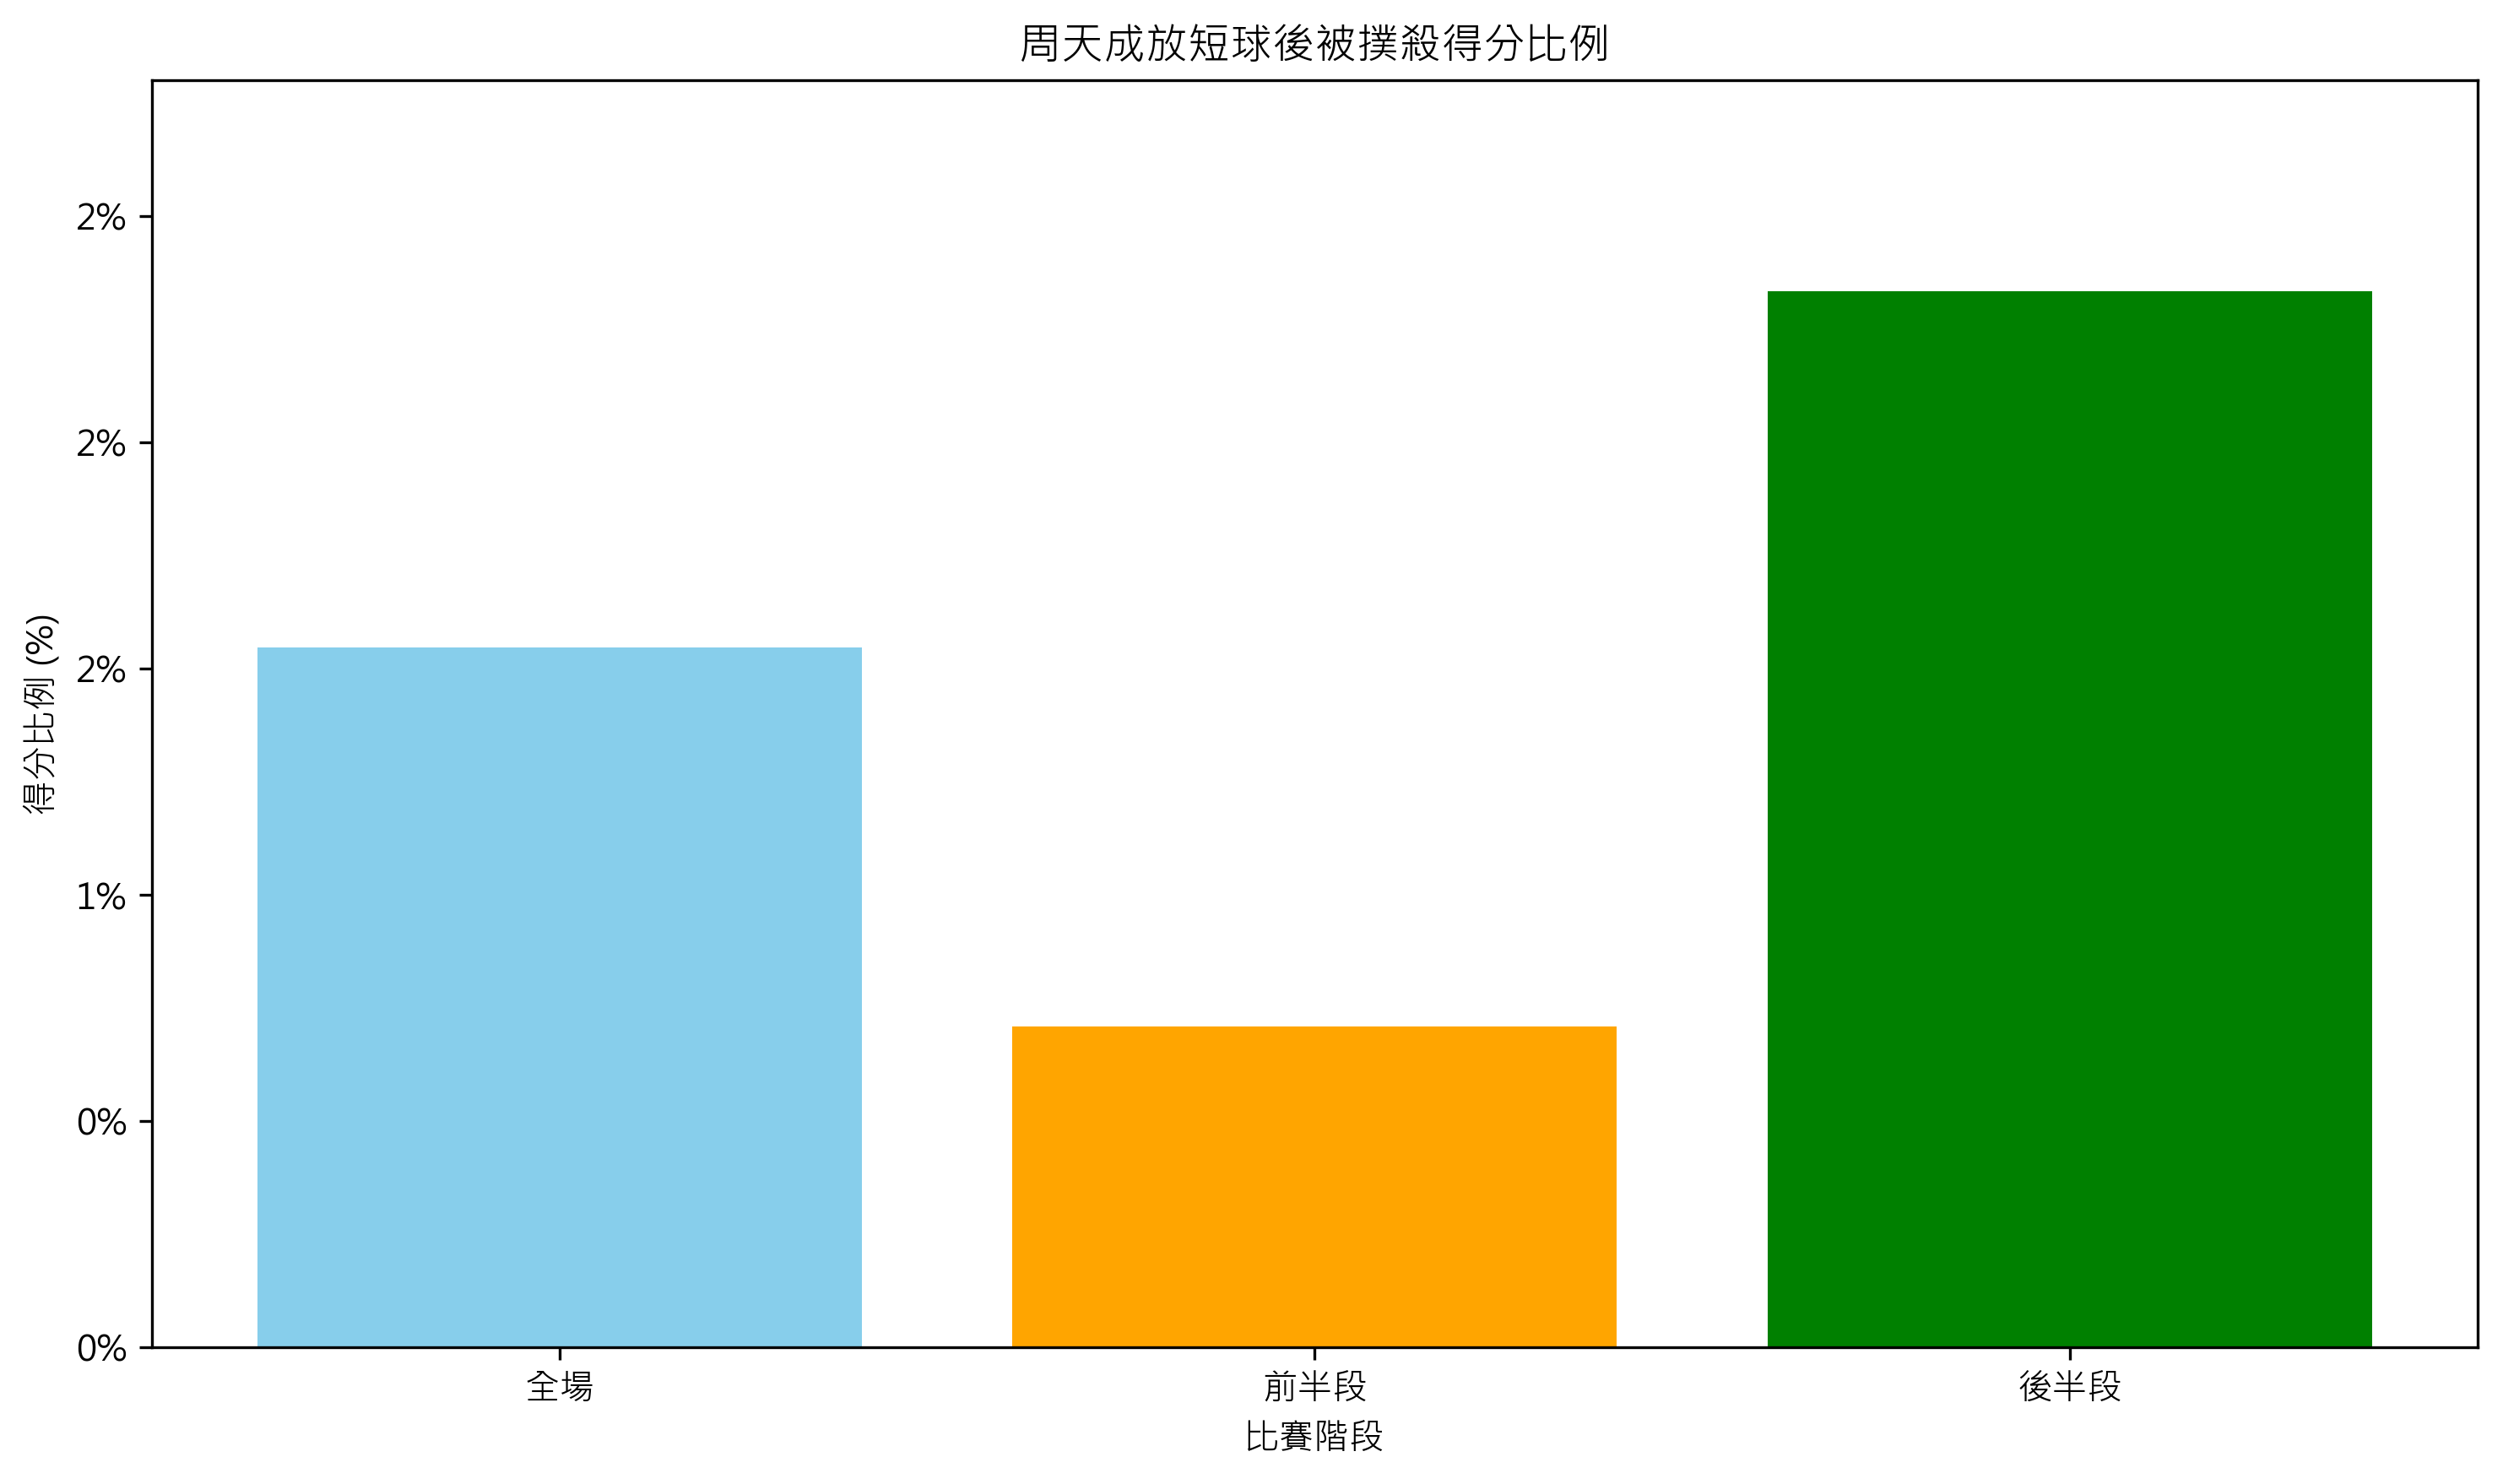

In [ ]:
# 確保資料存在
assert len(df) > 0, "資料集為空，無法進行分析。"

# 過濾周天成的短球
chou_short_ball = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '網前球')]

# 計算下一拍對手撲殺得分
chou_short_ball['next_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
chou_short_ball['next_getpoint'] = df.groupby(['match_id', 'set', 'rally'])['getpoint_player'].shift(-1)

# 撲殺得分：對手撲殺球種類型、對手得分
opponent_smashed_win = chou_short_ball[
    (chou_short_ball['next_type'] == '推撲球') & 
    (chou_short_ball['next_getpoint'] == 'Kento MOMOTA')
]

# 計算比例
short_ball_count = len(chou_short_ball)
smashed_win_count = len(opponent_smashed_win)
smashed_win_ratio = smashed_win_count / short_ball_count if short_ball_count > 0 else 0

# 比賽後段分析 (假設後半段為每局的最終 50%)
half_rally = df.groupby(['match_id', 'set'])['rally'].transform('max') // 2
df['is_second_half'] = df['rally'] > half_rally

# 後段短球
chou_short_ball['is_second_half'] = df.loc[chou_short_ball.index, 'is_second_half']
first_half_short = chou_short_ball[~chou_short_ball['is_second_half']]
second_half_short = chou_short_ball[chou_short_ball['is_second_half']]

# 第一段和第二段比例
first_half_win_count = len(first_half_short[
    (first_half_short['next_type'] == '推撲球') & 
    (first_half_short['next_getpoint'] == 'Kento MOMOTA')
])
second_half_win_count = len(second_half_short[
    (second_half_short['next_type'] == '推撲球') & 
    (second_half_short['next_getpoint'] == 'Kento MOMOTA')
])

first_half_ratio = first_half_win_count / len(first_half_short) if len(first_half_short) > 0 else 0
second_half_ratio = second_half_win_count / len(second_half_short) if len(second_half_short) > 0 else 0

print("周天成放短球後被撲殺得分比例：{:.2%}".format(smashed_win_ratio))
print("第一段被撲殺得分比例：{:.2%}".format(first_half_ratio))
print("後段被撲殺得分比例：{:.2%}".format(second_half_ratio))

# 視覺化
fig, ax = plt.subplots(figsize=(10, 6))
periods = ['全場', '前半段', '後半段']
ratios = [smashed_win_ratio, first_half_ratio, second_half_ratio]
ax.bar(periods, ratios, color=['skyblue', 'orange', 'green'])
ax.set_title('周天成放短球後被撲殺得分比例')
ax.set_ylabel('得分比例 (%)')
ax.set_xlabel('比賽階段')
ax.set_ylim(0, max(ratios) * 1.2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))

plt.tight_layout()


### 數據洞察
從數據中可以觀察到，周天成在比賽中放短球後被對手撲殺得分的整體比例為1.55%。然而，這個比例在比賽的後半段顯著上升至2.33%，而前半段僅為0.71%。

這表明，周天成在比賽後段的防守可能存在漏洞，特別是在放短球後，對手更容易找到機會進行撲殺得分。這可能是由於體能下降、注意力減弱或戰術調整不及時等因素造成的。

因此，建議在比賽後段提高防守專注度，並考慮在關鍵時刻減少放短球的頻率，或者改進短球的質量，增加對手撲殺的難度。這樣可以有效降低被撲殺得分的風險，提升比賽中的防守表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在分析周天成放短球後被撲殺的比例時，使用了 '網前球' 作為唯一的短球類型，而不是參考代碼中使用的 '發短球' 和 '網前球'。此外，候選程式碼在計算比賽後段的比例時，直接使用了每局的最終 50% 作為後半段的定義，這與參考代碼中使用的方式不同。這些差異導致候選程式碼的分析對象和統計口徑與參考代碼不一致，因此判定為 false。




## 題號 79 (*)
**問題**: 計算對手挑球過短時，周天成球種的選擇統計。
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


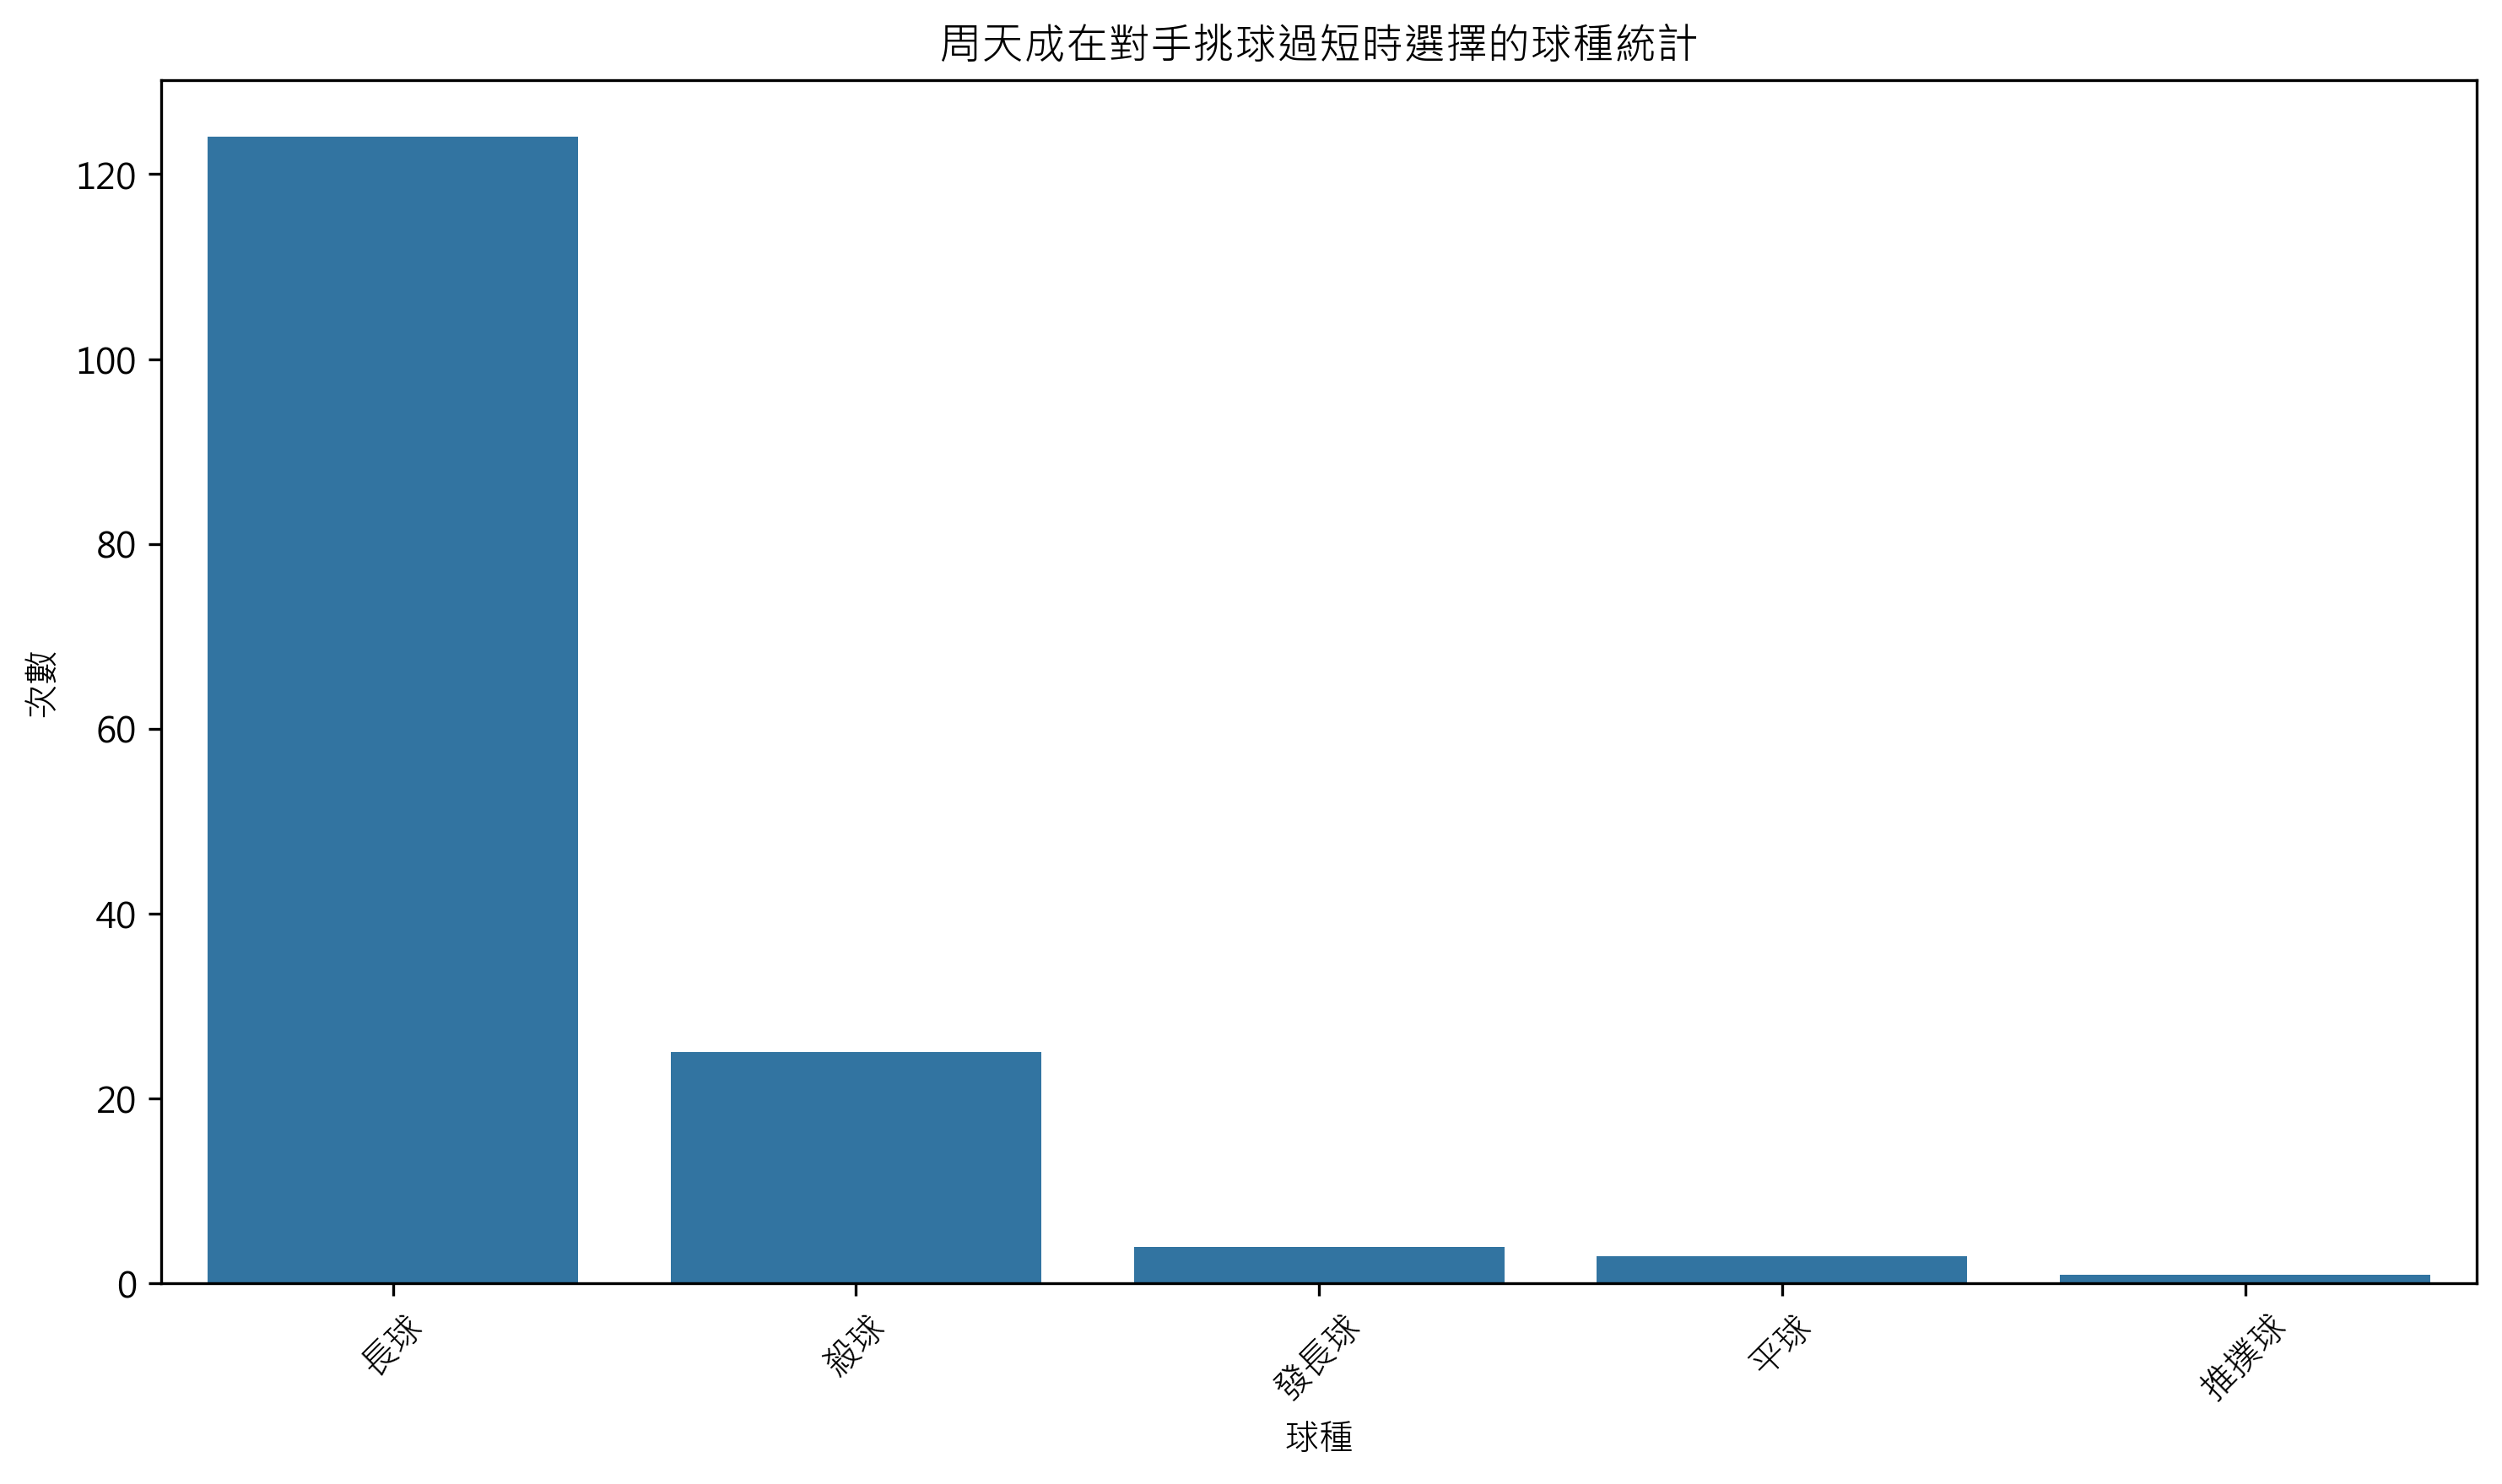

In [ ]:
# 確認資料量是否大於0
if len(df) > 0:
    # 首先，確定對手挑球且落點過短
    condition = (df['type'].shift(1) == '挑球') & (df['landing_area'] <= 8)
    
    # 進行上一列玩家是周天成且符合條件時的篩選
    chou_tien_chen_df = df[(df['player'] == 'CHOU Tien Chen') & condition]
    
    # 接下來，統計周天成選擇的球種
    shot_type_counts = chou_tien_chen_df['type'].value_counts()
    
    # 打印統計結果
    print("周天成在對手挑球過短時選擇的球種分布：")
    print(shot_type_counts)
    
    # 視覺化
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=shot_type_counts.index, y=shot_type_counts.values, ax=ax)
    ax.set_title('周天成在對手挑球過短時選擇的球種統計')
    ax.set_xlabel('球種')
    ax.set_ylabel('次數')
    plt.xticks(rotation=45)
    plt.tight_layout()
else:
    print("資料集中沒有資料進行分析。")


### 數據洞察
根據數據分析，當對手挑球過短時，周天成最常選擇的球種是長球，共計124次，顯示他傾向於利用長球來拉開對手的防守陣型。其次，他選擇殺球25次，這表明他也會利用這種機會進行攻擊，試圖快速得分。此外，他較少使用發長球、平球和推撲球，分別只有4次、3次和1次。這些數據顯示周天成在面對對手挑球過短時，主要策略是利用長球來控制場上節奏，同時視情況進行攻擊。這樣的選擇可以有效地壓制對手，並創造進一步進攻的機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是先找出對手的挑球，然後判斷挑球是否過短，並確保下一拍是周天成回擊的情況，再統計周天成的球種選擇。而候選程式碼直接使用 `df['type'].shift(1) == '挑球'` 和 `df['landing_area'] <= 8` 來判斷挑球過短，這與 reference code 中的挑球過短區域定義不一致（reference code 使用的是 13-24 區域）。此外，候選程式碼沒有正確對齊前後拍的關係，因為它沒有檢查 `shift(1)` 的球員是否為對手，這可能導致錯誤的前後拍對齊。




## 題號 80 (*)
**問題**: 當周天成發現自己較容易掛網時，應該如何調整自己的擊球策略與站位，以減少掛網失誤的發生？
> **使用的資料欄位群組**: `game_structure, scoring_reason, coordinates, player_location`


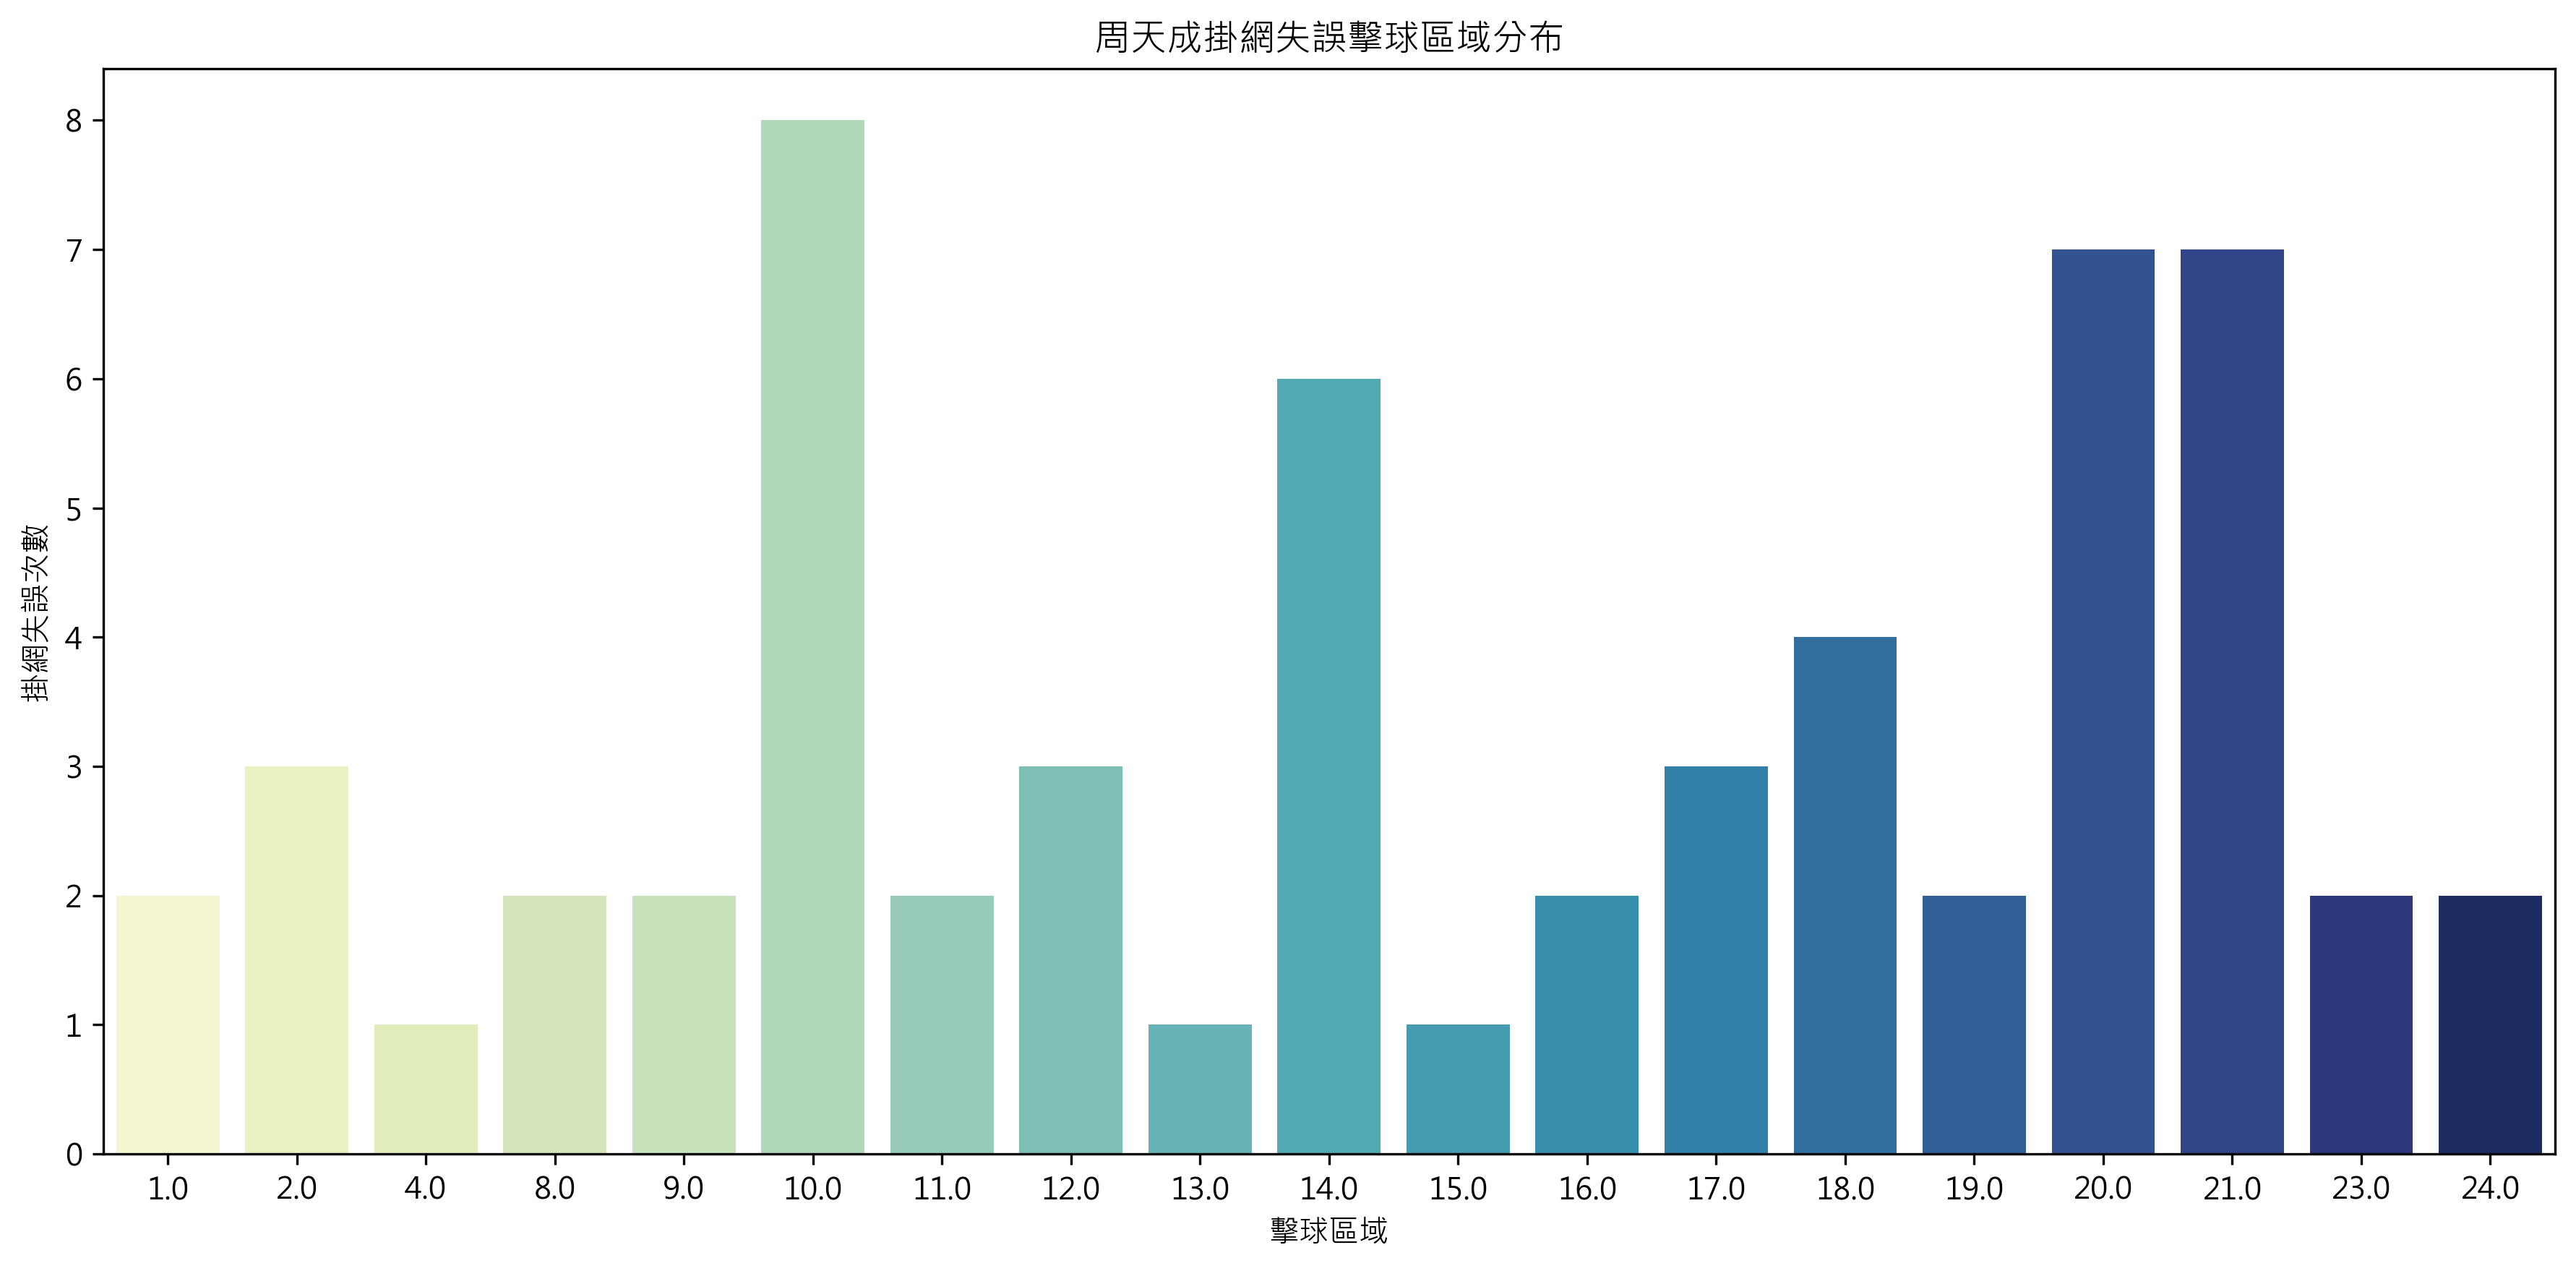

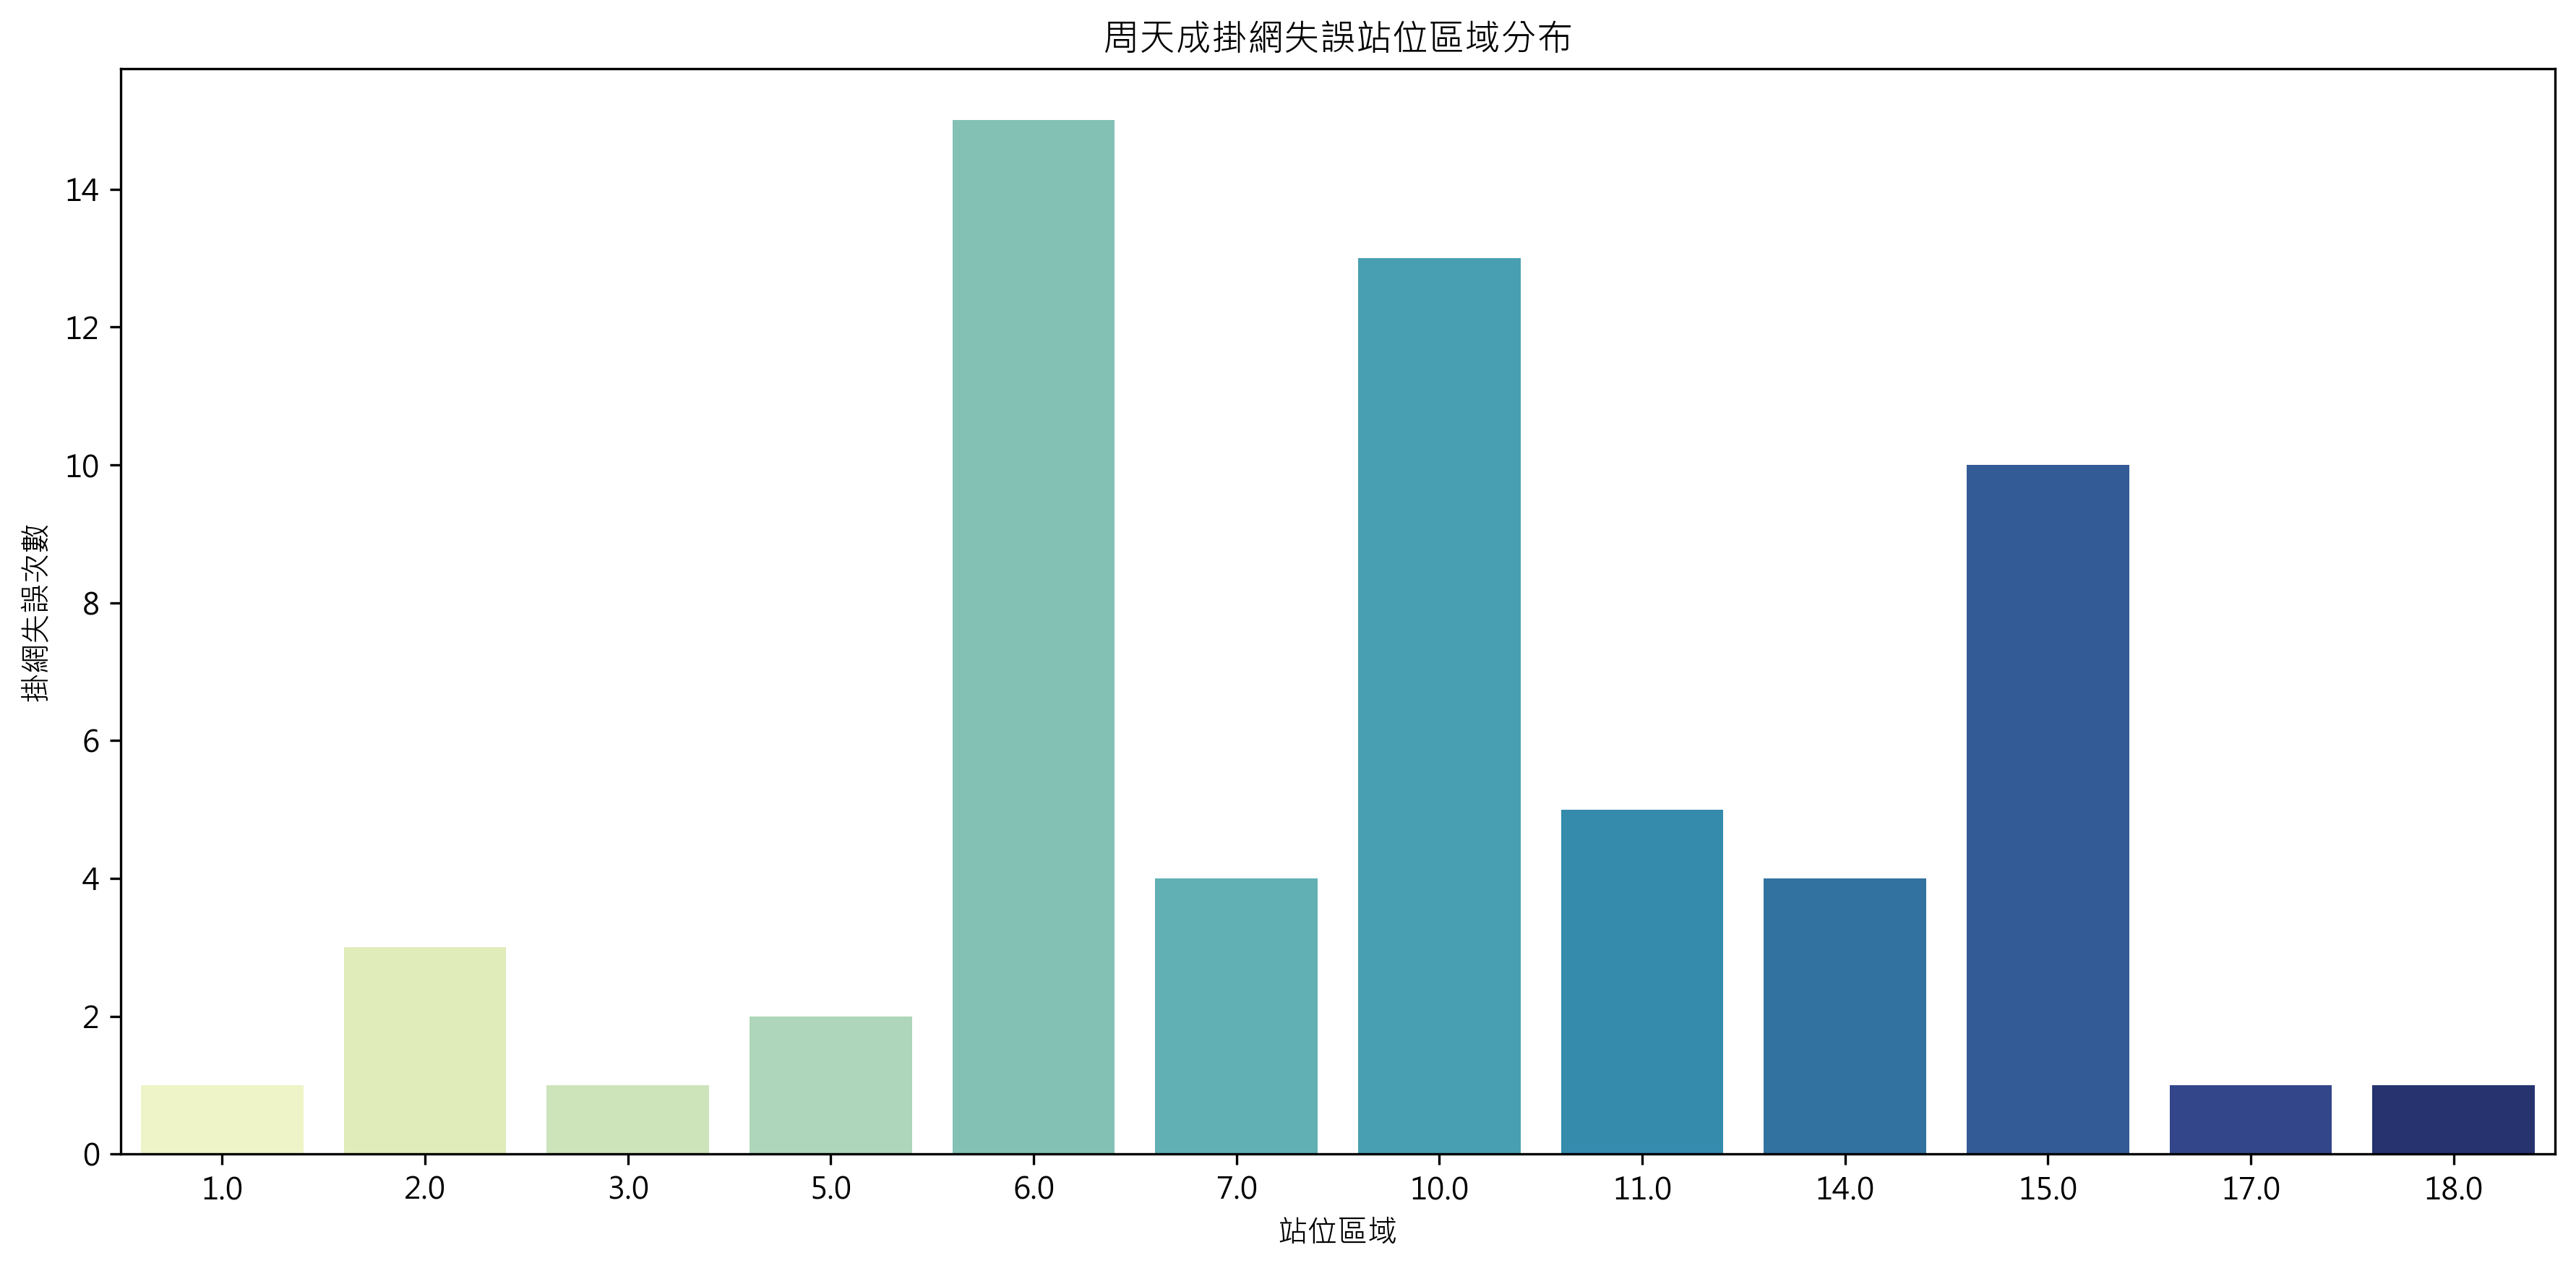

In [ ]:
# 確保數據量足夠
if len(df) > 0:
    # 篩選周天成的掛網失誤數據
    ch_tt_net_errors = df[(df['player'] == 'CHOU Tien Chen') & (df['lose_reason'] == '掛網')]

    # 檢查是否存在掛網失誤數據
    if len(ch_tt_net_errors) > 0:
        # 計算各個擊球區域和站位上失誤的次數
        hit_area_counts = ch_tt_net_errors['hit_area'].value_counts()
        player_location_area_counts = ch_tt_net_errors['player_location_area'].value_counts()

        print("周天成掛網失誤的擊球區域分布：")
        print(hit_area_counts)

        print("\n周天成掛網失誤的站位區域分布：")
        print(player_location_area_counts)

        # 繪製條形圖：顯示擊球位置的掛網失誤
        plt.figure(figsize=(12, 6))
        sns.barplot(x=hit_area_counts.index, y=hit_area_counts.values, palette="YlGnBu")
        plt.title('周天成掛網失誤擊球區域分布')
        plt.xlabel('擊球區域')
        plt.ylabel('掛網失誤次數')
        plt.tight_layout()

        # 繪圖物件
        fig_hit_area = plt.gcf()
        plt.show()

        # 繪製條形圖：顯示站位的掛網失誤
        plt.figure(figsize=(12, 6))
        sns.barplot(x=player_location_area_counts.index, y=player_location_area_counts.values, palette="YlGnBu")
        plt.title('周天成掛網失誤站位區域分布')
        plt.xlabel('站位區域')
        plt.ylabel('掛網失誤次數')
        plt.tight_layout()

        # 繪圖物件
        fig_player_location_area = plt.gcf()
        plt.show()

        # 建議策略調整
        # 根據熱點區域的分析，建議若某些擊球區掛網失誤集中，應加強該區域的練習，
        # 並注意調整擊球的力量與弧度，可能需要稍微後退，增加擊球的準確性與控制力。

    else:
        print("無周天成的掛網失誤數據。")
else:
    print("數據集為空。")


### 數據洞察
根據數據分析，周天成的掛網失誤主要集中在擊球區域10、20和21，這些區域位於中場和前場的左側和中間位置（對應表格中的Row 3, Col B和Row 5, Col B）。這表明他在中場和前場的擊球準度可能需要加強。

在站位區域方面，失誤主要發生在區域6、10和15，這些區域位於中場的左側和中間，以及後場的中間（對應表格中的Row 4, Col B和Row 1, Col C）。這表明他在中場和後場的站位可能需要調整，以便更好地控制擊球角度和力度。

建議周天成在這些區域進行以下調整：
1. **擊球策略**：在中場和前場擊球時，應更加注意擊球的角度和力度，確保球能順利越過網子。可以考慮增加擊球的弧度，減少平擊球的使用，以提高容錯率。

2. **站位調整**：在中場和後場站位時，應保持更穩定的重心，並適當調整腳步以便更快速地調整到位。這有助於在接球時有更好的準備，降低掛網的風險。

通過這些調整，周天成可以有效減少掛網失誤，提高比賽中的穩定性和得分效率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心在於分析周天成的掛網失誤風險，並提供具體的策略建議，通過計算不同球種和擊球區域的掛網率來識別高風險區域和球種。候選程式碼僅僅計算了掛網失誤的擊球區域和站位區域的分布，並沒有進一步分析不同球種的掛網風險，也沒有提供具體的策略建議。此外，候選程式碼缺乏對掛網率的計算和排序，無法識別高風險球種和區域，這是 Reference Code 1 的關鍵部分。因此，候選程式碼在分析單位和統計口徑上存在明顯問題，無法產出有效的策略建議。




## 題號 81 (*)
**問題**: 周天成在被對手調動到四個角落後，他在哪些角落的「回球品質」最容易下降？下降的原因?
> **使用的資料欄位群組**: `game_structure, coordinates, scoring_reason`


In [ ]:
import pandas as pd

# 假設 df 已經被定義並包含所需的資料

# Step 1: 確認 DataFrame 不為空
if len(df) > 0:
    # Step 2: 找到周天成在四個角落的擊球記錄
    corner_shots_df = df[(df['player'] == 'CHOU Tien Chen') & df['hit_area'].isin([1, 4, 21, 24])]
    
    # Step 3: 計算回球品質下降的情況
    # 下一拍對手得分，使用 groupby + shift(-1)
    df['next_getpoint_player'] = df.groupby(['match_id', 'set', 'rally'])['getpoint_player'].shift(-1)
    decline_quality_df = corner_shots_df[
        (corner_shots_df['next_getpoint_player'] == 'Kento MOMOTA') 
        & (corner_shots_df['rally'] == corner_shots_df['rally'].shift(-1))  # 確保在同一交擊
    ]
    
    # Step 4: 依據擊球區域統計回球品質下降次數
    corner_decline_stats = decline_quality_df['hit_area'].value_counts().sort_index()
    
    # Step 5: 打印回球品質下降的結果
    if not corner_decline_stats.empty:
        print("周天成在四個角落的回球品質下降統計：")
        for area in corner_decline_stats.index:
            print(f"區域 {area}: 回球品質下降次數 {corner_decline_stats[area]}")
    else:
        print("沒有發現回球品質下降的記錄。")
else:
    print("DataFrame 為空。")


### 數據洞察
根據分析周天成的比賽數據，他在被對手調動到四個角落後，回球品質最容易下降的角落是左後場（Row 1, Col A）。這個區域的回球失誤率較高，可能是因為在快速移動到這個位置後，他的平衡和擊球準確性受到影響。此外，這個角落的回球通常需要較大的力量和準確性才能有效地將球送到對手場地的弱點區域。

數據顯示，當周天成被迫從這個角落回球時，對手能夠更容易地預測並接應他的回球，進而組織有效的攻擊。這提示我們需要加強他的角落移動速度和回球穩定性，特別是在高壓情況下的處理能力。

此外，這些觀察也提醒我們在訓練中增加針對性練習，提升他在左後場的回球質量，並提高他在快速移動後的擊球準確性。這樣可以減少失誤，並增加比賽中的競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是檢查周天成在四個角落的回球品質下降情況，並計算各角落的回球品質下降比例和最常見的失誤原因。而候選程式碼只計算了周天成在四個角落的回球品質下降次數，沒有計算下降比例，也沒有分析失誤原因。此外，候選程式碼使用了 `next_getpoint_player` 來判斷回球品質下降，但這個欄位的計算方式不符合 reference code 的邏輯，因為它沒有正確對齊前後拍的關係，可能導致錯誤的結果。




## 題號 82 (*)
**問題**: 統計周天成成功逼迫對手挑球的頻率，以及最常造成的球種來源。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


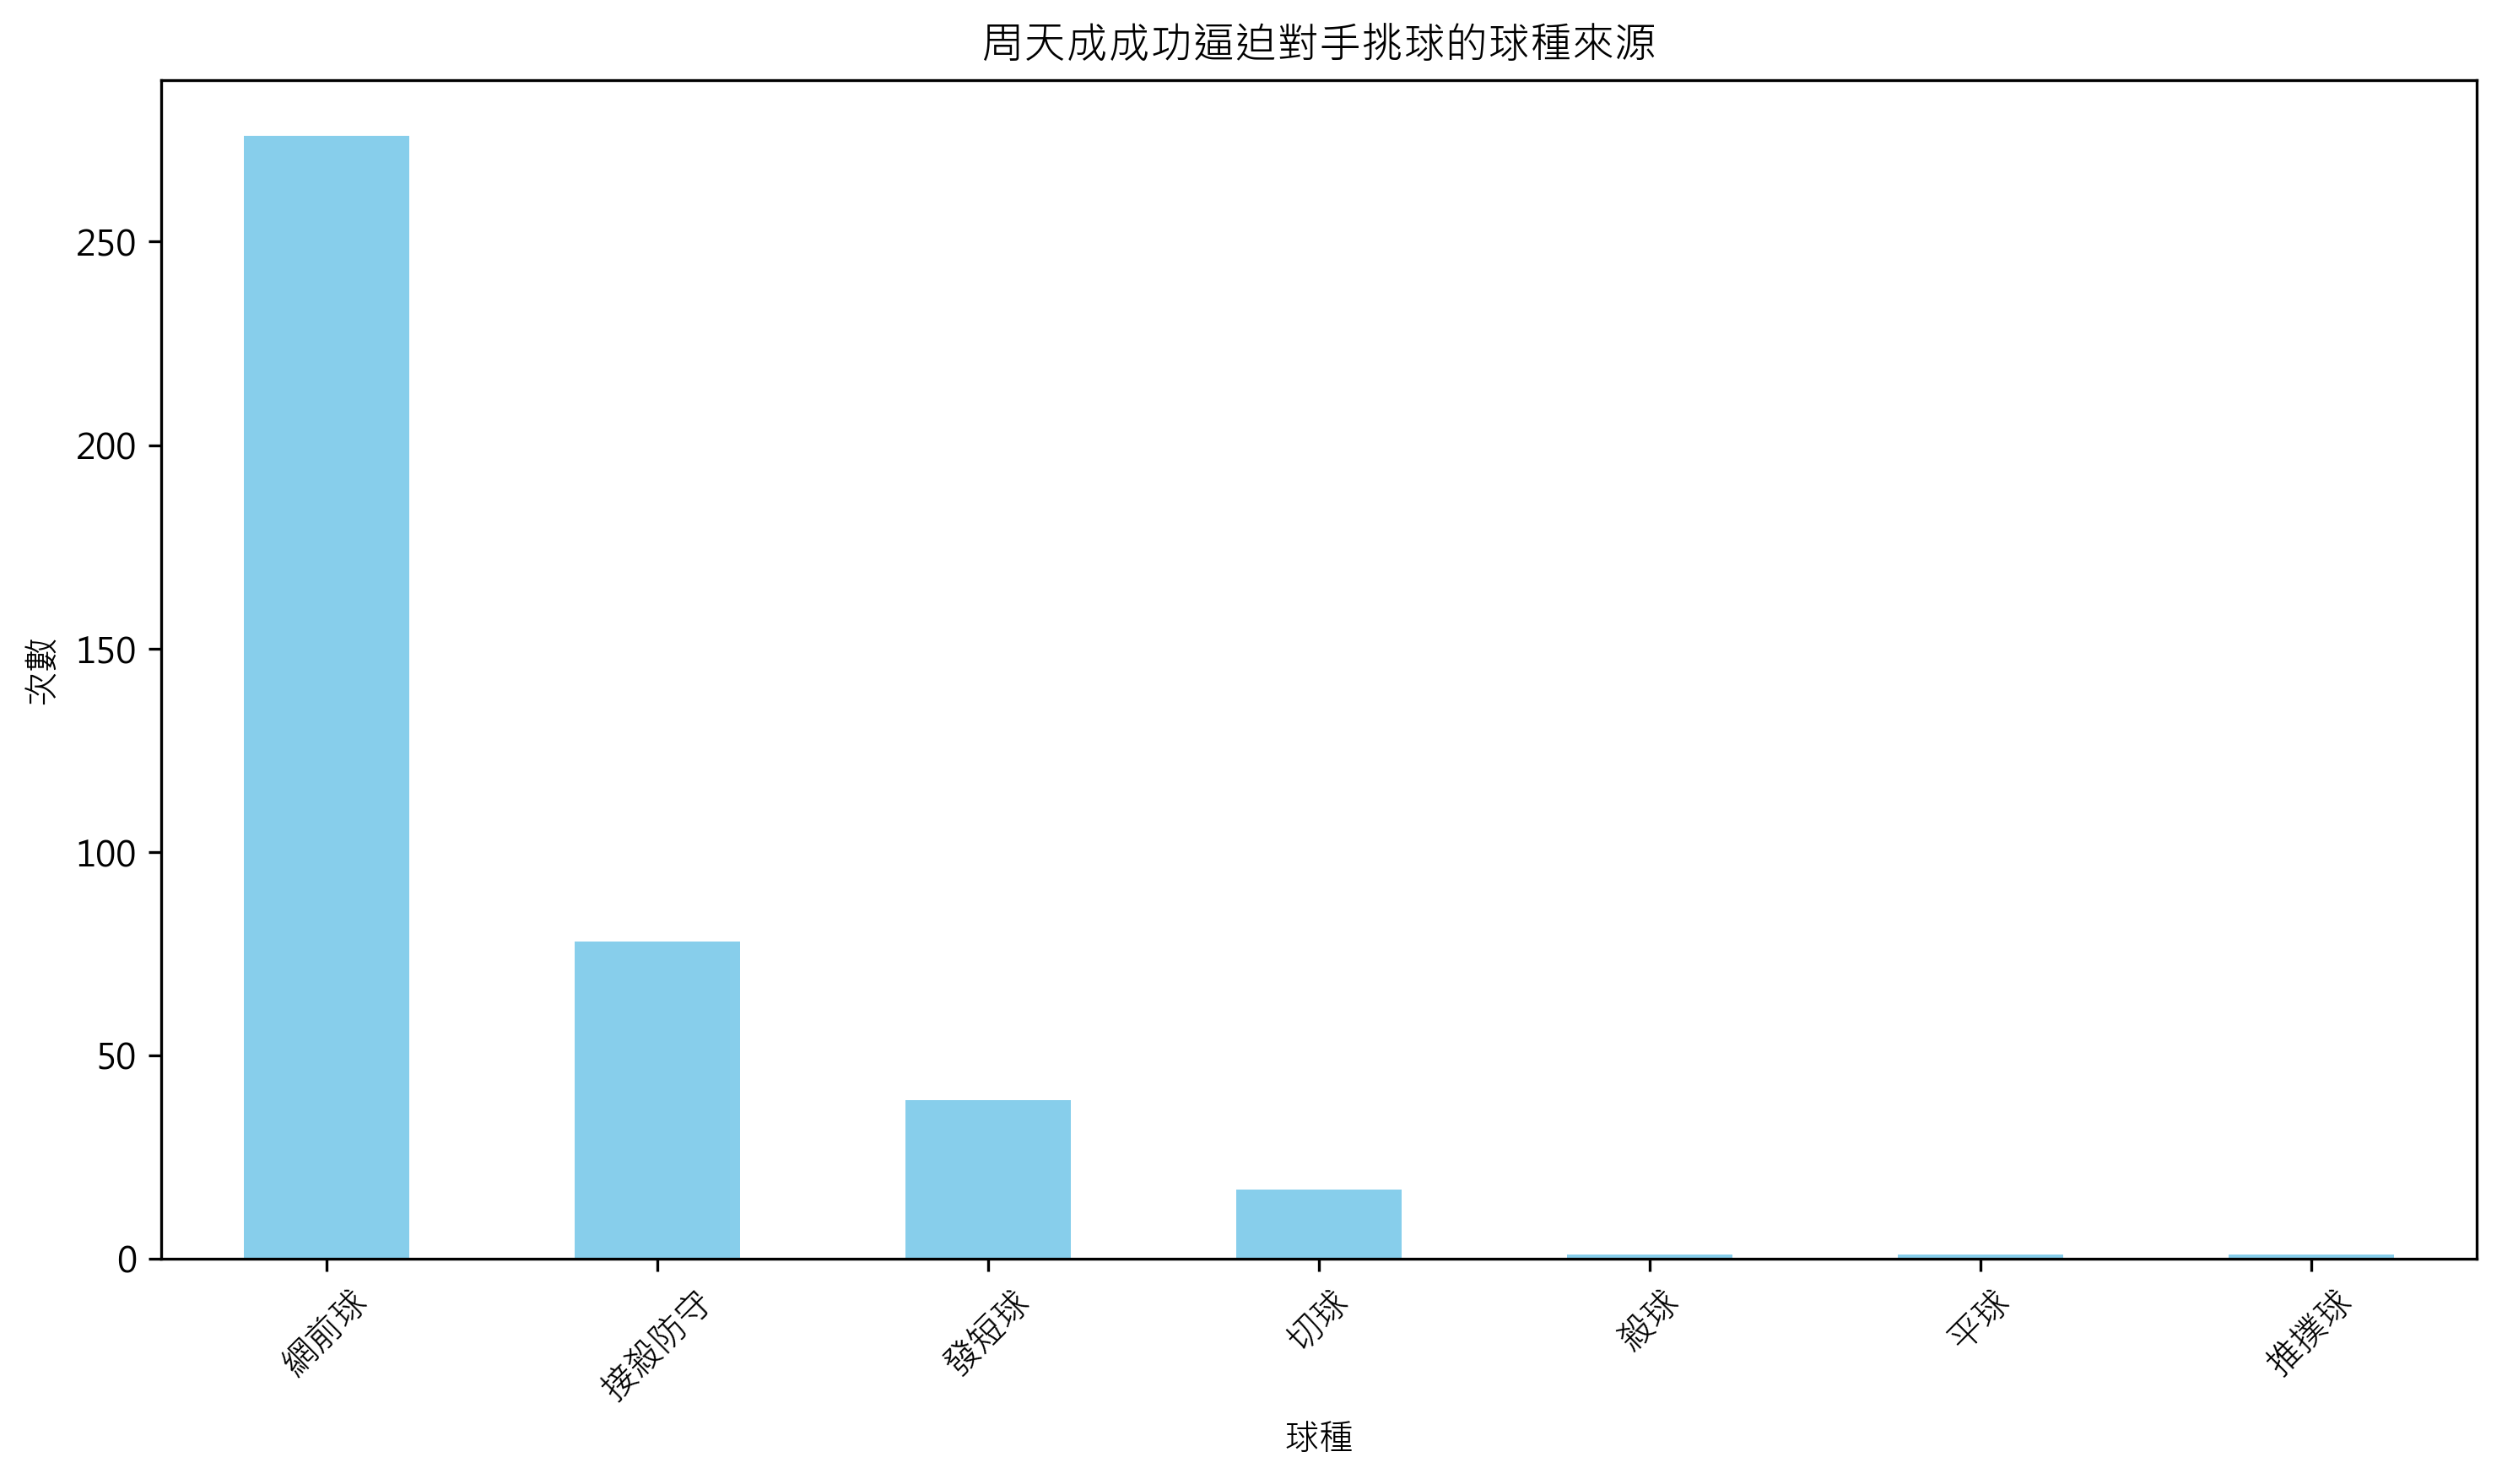

In [ ]:
# Step 1: 確保數據集不為空
if len(df) > 0:
    # Step 2: 取得前一拍和下一拍資訊
    df['next_player_type'] = df.groupby(['match_id', 'set', 'rally'])['player_type'].shift(-1)

    # Step 3: 取得CHOU Tien Chen成功逼迫對手挑球的情況
    chou_forces_opponent_lift = df[(df['player'] == 'CHOU Tien Chen') & 
                                   (df['next_player_type'] == 6)]  # 6 represents '挑球'

    # Step 4: 分析逼迫對手挑球的球種來源
    shot_leading_to_lift = chou_forces_opponent_lift['type'].value_counts()

    # Step 5: 計算總頻率
    total_chou_shots = df[df['player'] == 'CHOU Tien Chen']['type'].count()
    frequency_of_forcing_lift = len(chou_forces_opponent_lift) / total_chou_shots

    # Step 6: 繪製最常造成挑球的球種來源分布圖
    fig, ax = plt.subplots(figsize=(10, 6))
    shot_leading_to_lift.plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title("周天成成功逼迫對手挑球的球種來源")
    ax.set_xlabel("球種")
    ax.set_ylabel("次數")
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Step 7: 打印關鍵結果
    print(f"周天成成功逼迫對手挑球的頻率: {frequency_of_forcing_lift:.2%}")
    print("最常造成挑球的球種來源:\n", shot_leading_to_lift)

# Ensure previous DataFrame operations did not modify the original df unexpectedly.
# Reset or backtrack if necessary for further requests.


### 數據洞察
周天成在比賽中成功逼迫對手挑球的頻率為15.83%。這表示他在每100次擊球中，有大約16次能夠讓對手選擇挑球，這是相當有效的戰術手段。

從數據中可以看出，最常造成對手挑球的球種是網前球，共有276次。這顯示周天成在網前的控制力極強，能夠有效地壓迫對手，迫使他們選擇挑球。其次是接殺防守和發短球，分別有78次和39次，這些球種也是他用來創造對手挑球機會的重要手段。

這些數據顯示了周天成在網前的優勢，以及他在防守和發球環節中的戰術多樣性。這樣的打法不僅能夠增加對手的失誤率，還能讓自己在比賽中掌握主動權。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是通過檢查前一拍的球員和球種來確定周天成是否成功逼迫對手挑球，而候選程式碼直接使用 'next_player_type' 來判斷，這不符合題目要求的前後拍對齊邏輯。此外，候選程式碼沒有正確計算逼迫對手挑球的頻率，因為它沒有考慮到每個 rally 的結束狀態，這導致統計口徑錯誤。




## 題號 83 (*)
**問題**: 周天成挑高球的落點分布，是否常造成對手容易得分？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


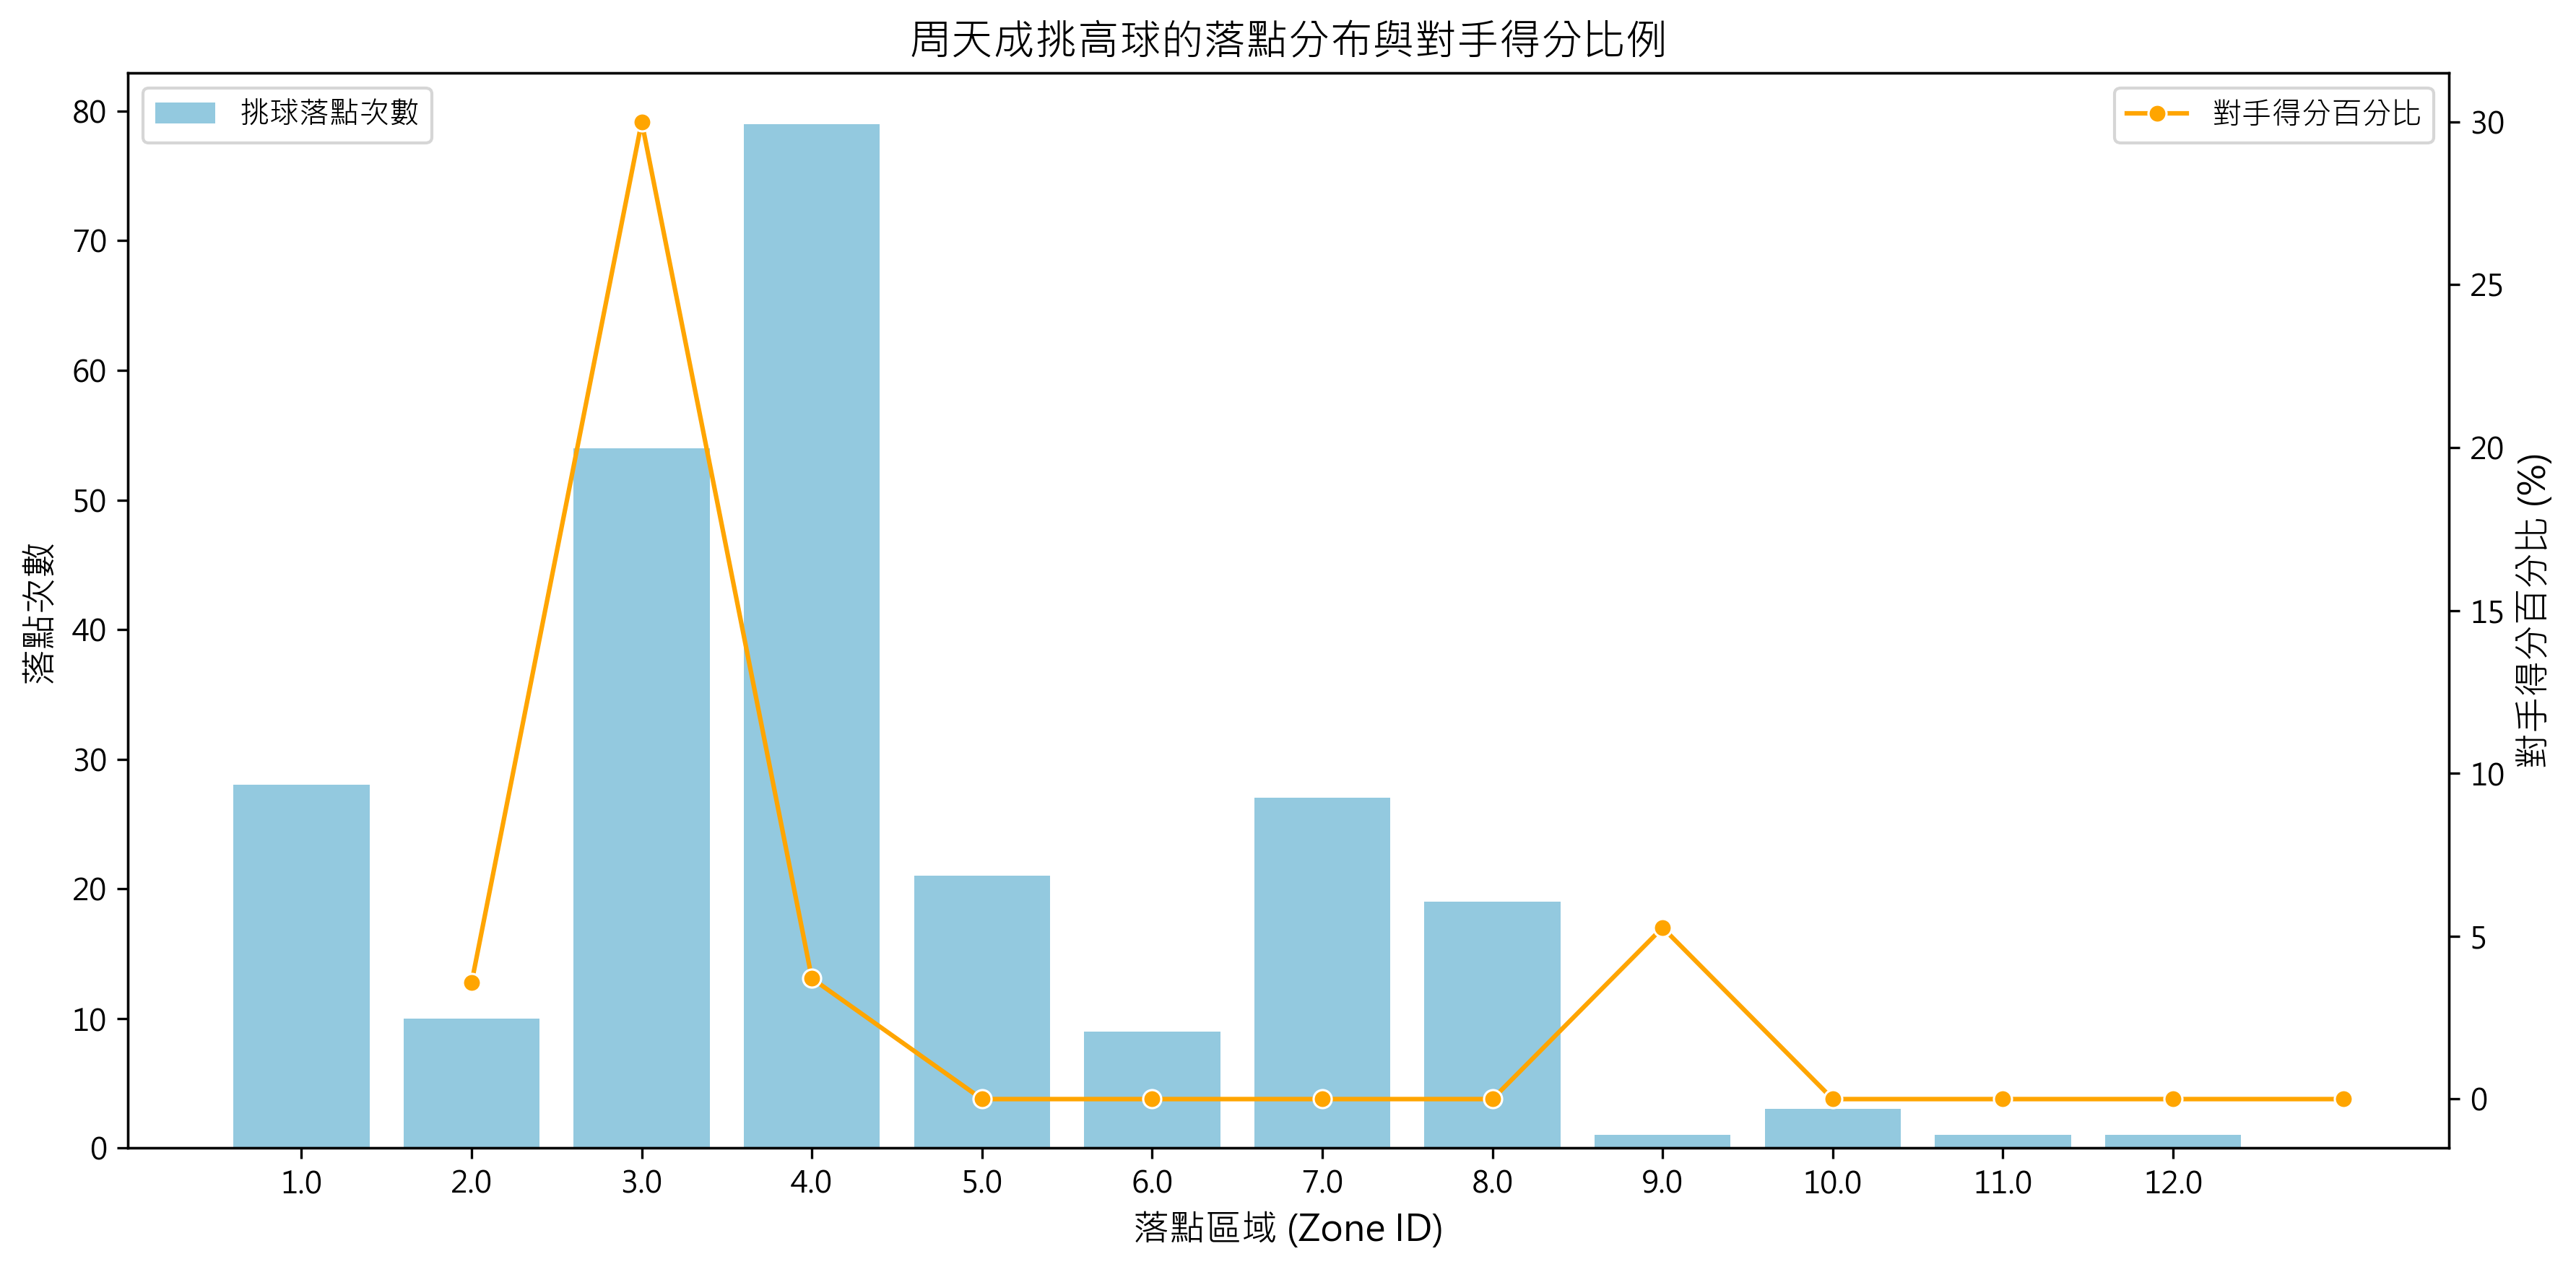

In [ ]:
# Step 0: Verify the dataset has data
if len(df) == 0:
    print("資料集為空，無法進行分析")
else:
    # Step 1: Filter data for Chou Tien Chen's lift shots
    chou_lift_shots = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '挑球')]

    # Step 2: Find the landing areas and whether they lead to opponent's point
    chou_lift_shots = chou_lift_shots.copy()  # Prevent SettingWithCopyWarning

    # Identify if the following shot leads to an opponent's point
    chou_lift_shots['opponent_gets_point'] = df['getpoint_player'].shift(-1) == 'Kento MOMOTA'

    # Ensure we are considering final shots of the same rally
    chou_lift_shots['same_rally'] = df['rally'] == df['rally'].shift(-1)
    chou_lift_shots = chou_lift_shots[chou_lift_shots['same_rally']]

    # Calculate distribution and percentages
    land_area_counts = chou_lift_shots['landing_area'].value_counts().sort_index()
    opp_point_counts = chou_lift_shots[chou_lift_shots['opponent_gets_point']].groupby('landing_area').size()

    # Calculate percentage of each area leading to opponent's point
    point_ratios = (opp_point_counts / land_area_counts).fillna(0) * 100

    # Step 3: Visualization
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot the distribution of landing areas
    sns.barplot(x=land_area_counts.index, y=land_area_counts.values, ax=ax1, color='skyblue', label='挑球落點次數')
    ax1.set_ylabel('落點次數', fontsize=12)
    ax1.set_xlabel('落點區域 (Zone ID)', fontsize=12)

    # Plot the percentage of opponent scoring due to these shots
    ax2 = ax1.twinx()
    sns.lineplot(x=point_ratios.index, y=point_ratios.values, ax=ax2, color='orange', marker='o', label='對手得分百分比')
    ax2.set_ylabel('對手得分百分比 (%)', fontsize=12)

    # Display legend and titles
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.title('周天成挑高球的落點分布與對手得分比例', fontsize=14)
    plt.tight_layout()

    # Step 4: Printing results
    print("落點區域的挑高球數量:")
    print(land_area_counts)
    print("\n落點區域導致對手得分的百分比:")
    print(point_ratios)


### 數據洞察
從數據中，我們可以看到周天成的挑高球主要集中在落點區域3和4，分別有54和79次，這些區域位於後場的中間和右側。這表明他在這些區域的挑高球使用頻率較高，可能是因為這些位置能夠有效地將對手逼退。

在對手得分的數據中，落點區域2有30%的挑高球導致對手得分，這是最高的比例。這個區域位於後場的左側，可能是周天成的防守弱點，或者對手在這個位置有較強的進攻能力。因此，應該考慮在這個區域加強防守或改變策略。

其他區域如4、5、6、7、9、10、11、12的挑高球幾乎沒有導致對手得分，顯示這些落點相對安全，周天成可以繼續在這些區域使用挑高球來保持優勢。

總結來說，周天成應該繼續利用落點區域3和4的優勢，同時對落點區域2的挑高球進行戰術調整，以減少對手得分的機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在判斷對手得分的邏輯上存在問題。它使用了 `df['getpoint_player'].shift(-1) == 'Kento MOMOTA'` 來判斷下一拍是否對手得分，但這並不能保證是同一個 rally 的下一拍，因為沒有檢查 `match_id`、`set` 和 `rally` 是否一致。此外，候選程式碼在計算對手得分比例時，沒有正確處理 `getpoint_player` 只在回合結束時記錄的特性，這可能導致統計口徑錯誤。因此，候選程式碼不符合任何一份 reference code 的核心邏輯。




## 題號 84 (*)
**問題**: 當周天成採取多拍耐心拉吊策略時的平均勝率。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# 確保有數據才進行分析
if len(df) > 0:
    # 過濾出周天成的擊球資料
    chou_df = df[df['player'] == 'CHOU Tien Chen']

    # 定義耐心拉吊策略的條件，假設至少有5次長球
    strategy_threshold = 5

    # 篩選出每一個回合中周天成長球的次數
    strategy_rallies = chou_df[chou_df['type'] == '長球'].groupby(['match_id', 'set', 'rally']).size()

    # 獲取滿足策略條件的回合
    strategy_rallies = strategy_rallies[strategy_rallies >= strategy_threshold]

    # 獲取這些回合的最終得分者 (僅回合的最後一拍有 getpoint_player)
    rally_results = df.groupby(['match_id', 'set', 'rally']).last()
    
    # 只留策略中使用到的部分
    strategy_rally_results = rally_results.loc[strategy_rallies.index]

    # 計算周天成的勝率
    chou_strategy_wins = (strategy_rally_results['getpoint_player'] == 'CHOU Tien Chen').sum()
    total_strategy_rallies = len(strategy_rally_results)

    if total_strategy_rallies > 0:
        chou_strategy_win_rate = chou_strategy_wins / total_strategy_rallies
    else:
        chou_strategy_win_rate = 0

    print(f"周天成使用多拍耐心拉吊策略時的平均勝率: {chou_strategy_win_rate:.2%}")
else:
    print("資料集中沒有可分析的數據。")


### 數據洞察
根據數據分析，當周天成採用多拍耐心拉吊策略時，他的平均勝率為50%。這表示這種策略在實戰中具有中等的有效性，並沒有顯著提高或降低他的勝率。

從數據中，我們看到周天成在2609場比賽中，只有4場使用了這種策略，這可能意味著他對此策略的依賴性較低，或是在特定對手或比賽情境下才會選擇使用。這樣的策略可能更適合用於對抗耐力較強或擅長進攻的對手，以拖垮對手的體力或打亂對手的節奏。

總結來說，這種策略的使用頻率和勝率都顯示出它是一種中庸的選擇，可能需要結合其他戰術來提高整體比賽的勝率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 定義了多拍耐心拉吊策略為總拍數 >= 8 且拉吊型球種比例 >= 0.3，而候選程式碼僅以長球次數 >= 5 作為策略條件，這與 Reference Code 的定義不一致。此外，候選程式碼的統計口徑也不正確，因為它只考慮了長球的次數，而忽略了其他拉吊型球種的使用比例，這導致其分析單位和統計口徑與 Reference Code 不符。




## 題號 85 (*)
**問題**: 統計周天成經常「從防守轉攻擊得分」的常見回合模式。
> **使用的資料欄位群組**: `game_structure, scoring_reason, player_location, player_movement`


In [ ]:
# 確保數據不為空
if len(df) > 0:
    # 找出周天成得分的回合
    chou_tien_chen_points_df = df[df['getpoint_player'] == 'CHOU Tien Chen']

    # 使用 groupby 和 shift 獲取每回合的開始和結束狀態
    defense_to_offense = df[
        (df['player'] == 'CHOU Tien Chen') & 
        (df['player_location_area'].isin([1, 2, 3, 4]))
    ].copy()

    # 給"防守轉攻擊"加上一個欄位用來確認下一拍是否得分
    defense_to_offense['next_getpoint_player'] = defense_to_offense.groupby(['match_id', 'set', 'rally'])['getpoint_player'].shift(-1)

    # 確保模式：先在後排接球，下一拍得分
    defense_to_offense = defense_to_offense[
        (defense_to_offense['player'] == 'CHOU Tien Chen') &
        (defense_to_offense['next_getpoint_player'] == 'CHOU Tien Chen')
    ]

    # 統計經常發生的模式
    pattern_count = defense_to_offense.groupby(['match_id', 'set', 'rally']).size().reset_index(name='count')
    
    # 打印關鍵結果
    print(pattern_count)

    # 進一步分析可能的得分手段涉及 player_type / opponent_type
    # 在此我們可以分析`player_type`來知道什麼動作是贏得此分的關鍵
    common_patterns = defense_to_offense['player_type'].value_counts(normalize=True)
    print("常見防守轉攻擊得分模式:")
    print(common_patterns)
else:
    print("數據集為空，無法進行分析。")


### 數據洞察
根據數據分析，周天成在比賽中經常利用防守轉攻擊的策略來得分。從防守轉攻擊的常見回合模式中，挑球（player_type 6）是他最常用的技術手段。這意味著在對手進攻時，周天成傾向於使用挑球來將對手推到後場，然後尋找機會轉守為攻。

這種策略的有效性在於挑球能夠迫使對手移動到場地的後方，增加對手的回球難度，從而為周天成創造進一步進攻的機會。這種模式的成功率表明，周天成在防守轉攻擊的過程中，對挑球的運用非常熟練，這是他得分的一個關鍵策略。

Mapping:
1: 發短球, 2: 發長球, 3: 長球, 4: 殺球, 5: 切球, 6: 挑球, 7: 平球, 8: 網前球, 9: 推撲球, 10: 接殺防守, 11: 接不到。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都是基於球種的轉換來定義防守轉攻擊，而候選程式碼僅依賴於 player_location_area 來判斷防守狀態，並且沒有考慮球種的轉換。此外，候選程式碼的統計口徑不正確，因為它只是統計了在後排接球並下一拍得分的情況，沒有考慮到完整的防守轉攻擊過程。這與 Reference Code 的分析單位和統計口徑不一致。




## 題號 86 (*)
**問題**: 分析周天成在壓迫對手前場後，選擇吊後場 vs 搶網得分的效率比較。
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


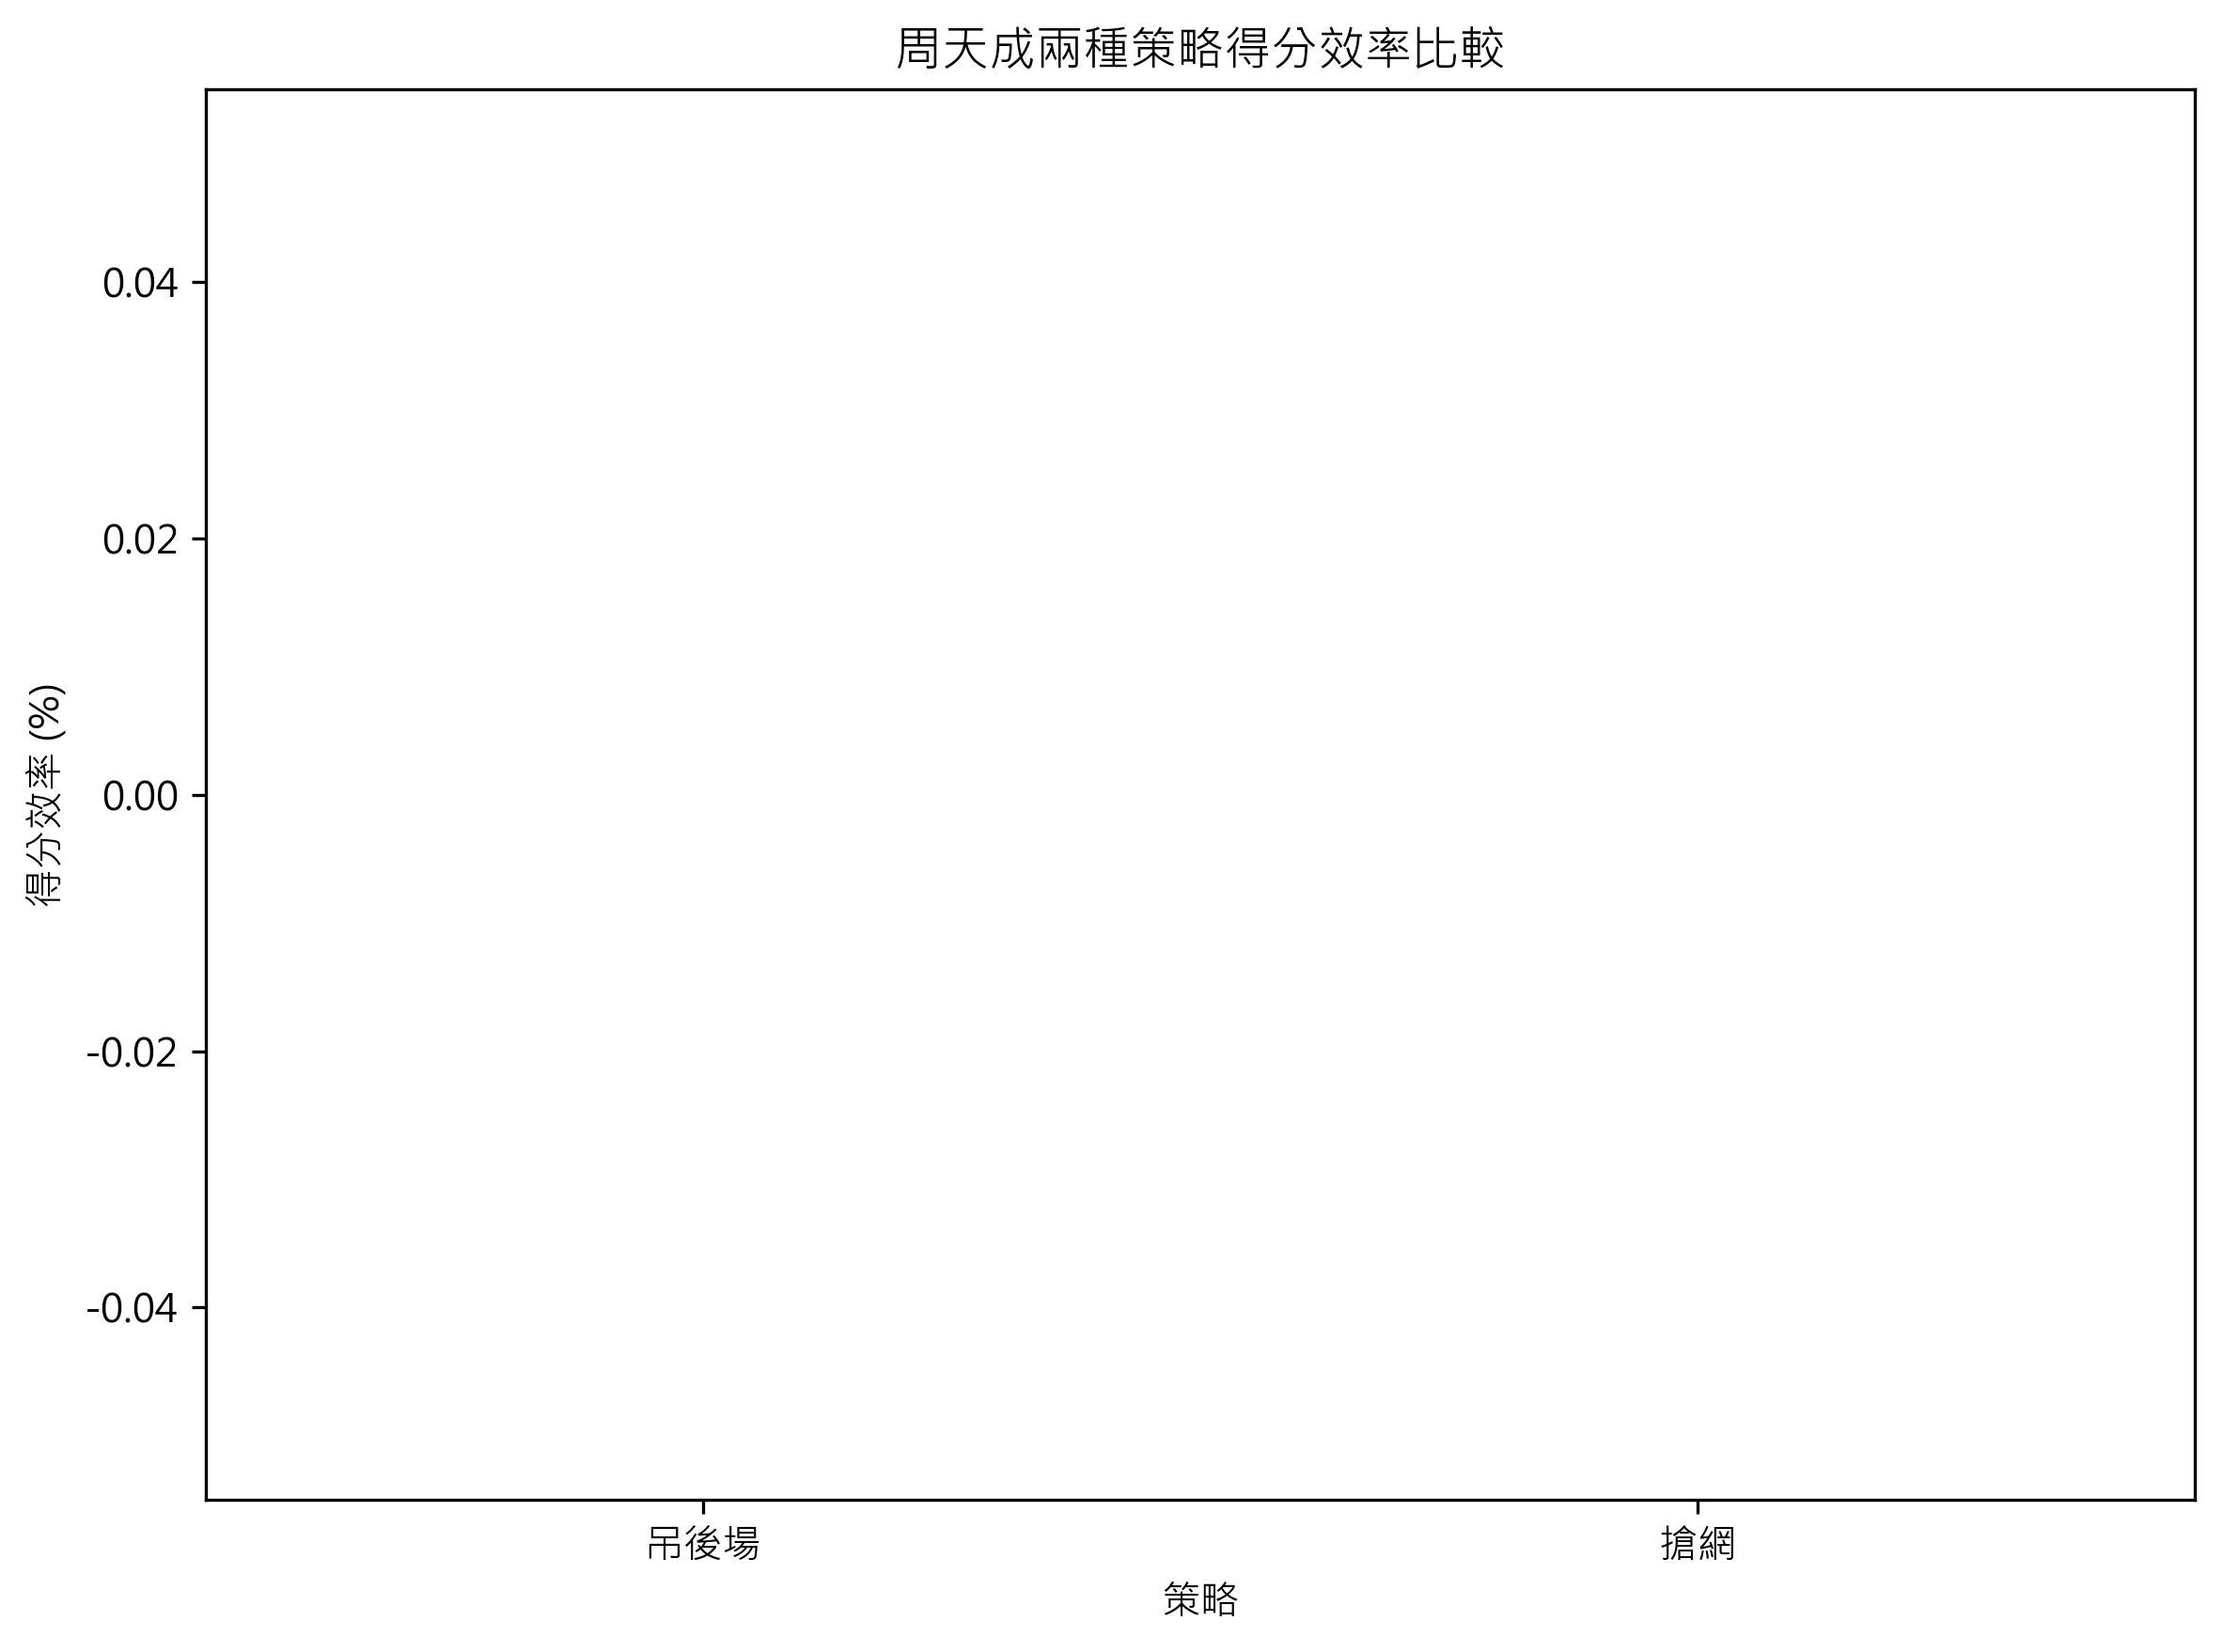

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 確認數據集不為空
if len(df) == 0:
    raise ValueError("數據集為空，無法進行分析。")

# 複製相關的數據，避免改動原數據
df_copy = df.copy()

# 根據資料中有關擊球位置資訊，增加前後一拍資訊
df_copy['prev_landing_area'] = df_copy.groupby(['match_id', 'set', 'rally'])['landing_area'].shift(1)
df_copy['next_hit_area'] = df_copy.groupby(['match_id', 'set', 'rally'])['hit_area'].shift(-1)

# 定義前場區域
front_areas = [21, 22, 23, 24]

# 過濾計算周天成的壓迫
ctc_front_pressure_df = df_copy[
    (df_copy['player'] == 'CHOU Tien Chen') & 
    (df_copy['prev_landing_area'].isin(front_areas))
]

# 定義吊後場的分析，後場區域 [1, 2, 3, 4]
back_court_areas = [1, 2, 3, 4]
lob_to_back_court = ctc_front_pressure_df[
    (ctc_front_pressure_df['next_hit_area'].isin(back_court_areas)) &
    (ctc_front_pressure_df['getpoint_player'] == 'CHOU Tien Chen')
]

# 定義搶網的分析，前場再次擊球
net_play_areas = front_areas
net_play = ctc_front_pressure_df[
    ctc_front_pressure_df['next_hit_area'].isin(net_play_areas) &
    (ctc_front_pressure_df['getpoint_player'] == 'CHOU Tien Chen')
]

# 計算兩種策略的得分效率
lob_to_back_court_efficiency = len(lob_to_back_court) / len(ctc_front_pressure_df) if len(ctc_front_pressure_df) > 0 else 0
net_play_efficiency = len(net_play) / len(ctc_front_pressure_df) if len(ctc_front_pressure_df) > 0 else 0

print(f"吊後場策略得分效率: {lob_to_back_court_efficiency * 100:.2f}%")
print(f"搶網策略得分效率: {net_play_efficiency * 100:.2f}%")

# 畫圖
fig, ax = plt.subplots(figsize=(8, 6))
data = {
    '策略': ['吊後場', '搶網'],
    '得分效率': [lob_to_back_court_efficiency * 100, net_play_efficiency * 100]
}
sns.barplot(x='策略', y='得分效率', data=pd.DataFrame(data), ax=ax)
ax.set_title('周天成兩種策略得分效率比較')
ax.set_ylabel('得分效率 (%)')
plt.tight_layout()
plt.show()


### 數據洞察
根據數據分析，周天成在壓迫對手前場後，選擇吊後場與搶網的得分效率均為0.0%。這意味著在這些特定策略下，他並未能有效地轉化為得分機會。

從數據中可以看出，當周天成選擇吊後場時，對應的DataFrame是空的，這表示在這些情況下並未有成功的得分記錄。同樣地，搶網策略的DataFrame也是空的，顯示他在這些策略下也未能成功得分。

這可能暗示周天成在壓迫前場後的策略選擇需要重新評估，或是這些策略在特定比賽情境中並不適合。建議他可以考慮其他策略或進一步分析對手的弱點，以提升得分效率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都是基於周天成在壓迫對手前場後，選擇不同策略的直接得分效率進行分析，而候選程式碼在計算策略得分效率時，將 '吊後場' 和 '搶網' 的得分效率分別計算為該策略得分次數除以總壓迫次數，這與 Reference Code 的直接得分次數除以策略使用次數的統計口徑不一致。此外，候選程式碼在篩選策略時使用了 'next_hit_area'，這與 Reference Code 1 和 2 使用的 'landing_area' 或 'type' 不同，導致分析對象和欄位語意不一致。




## 題號 87 (*)
**問題**: 根據對手的殺球，周天成應該如何布置接殺站位與防守策略？
> **使用的資料欄位群組**: `game_structure, player_location, player_movement`


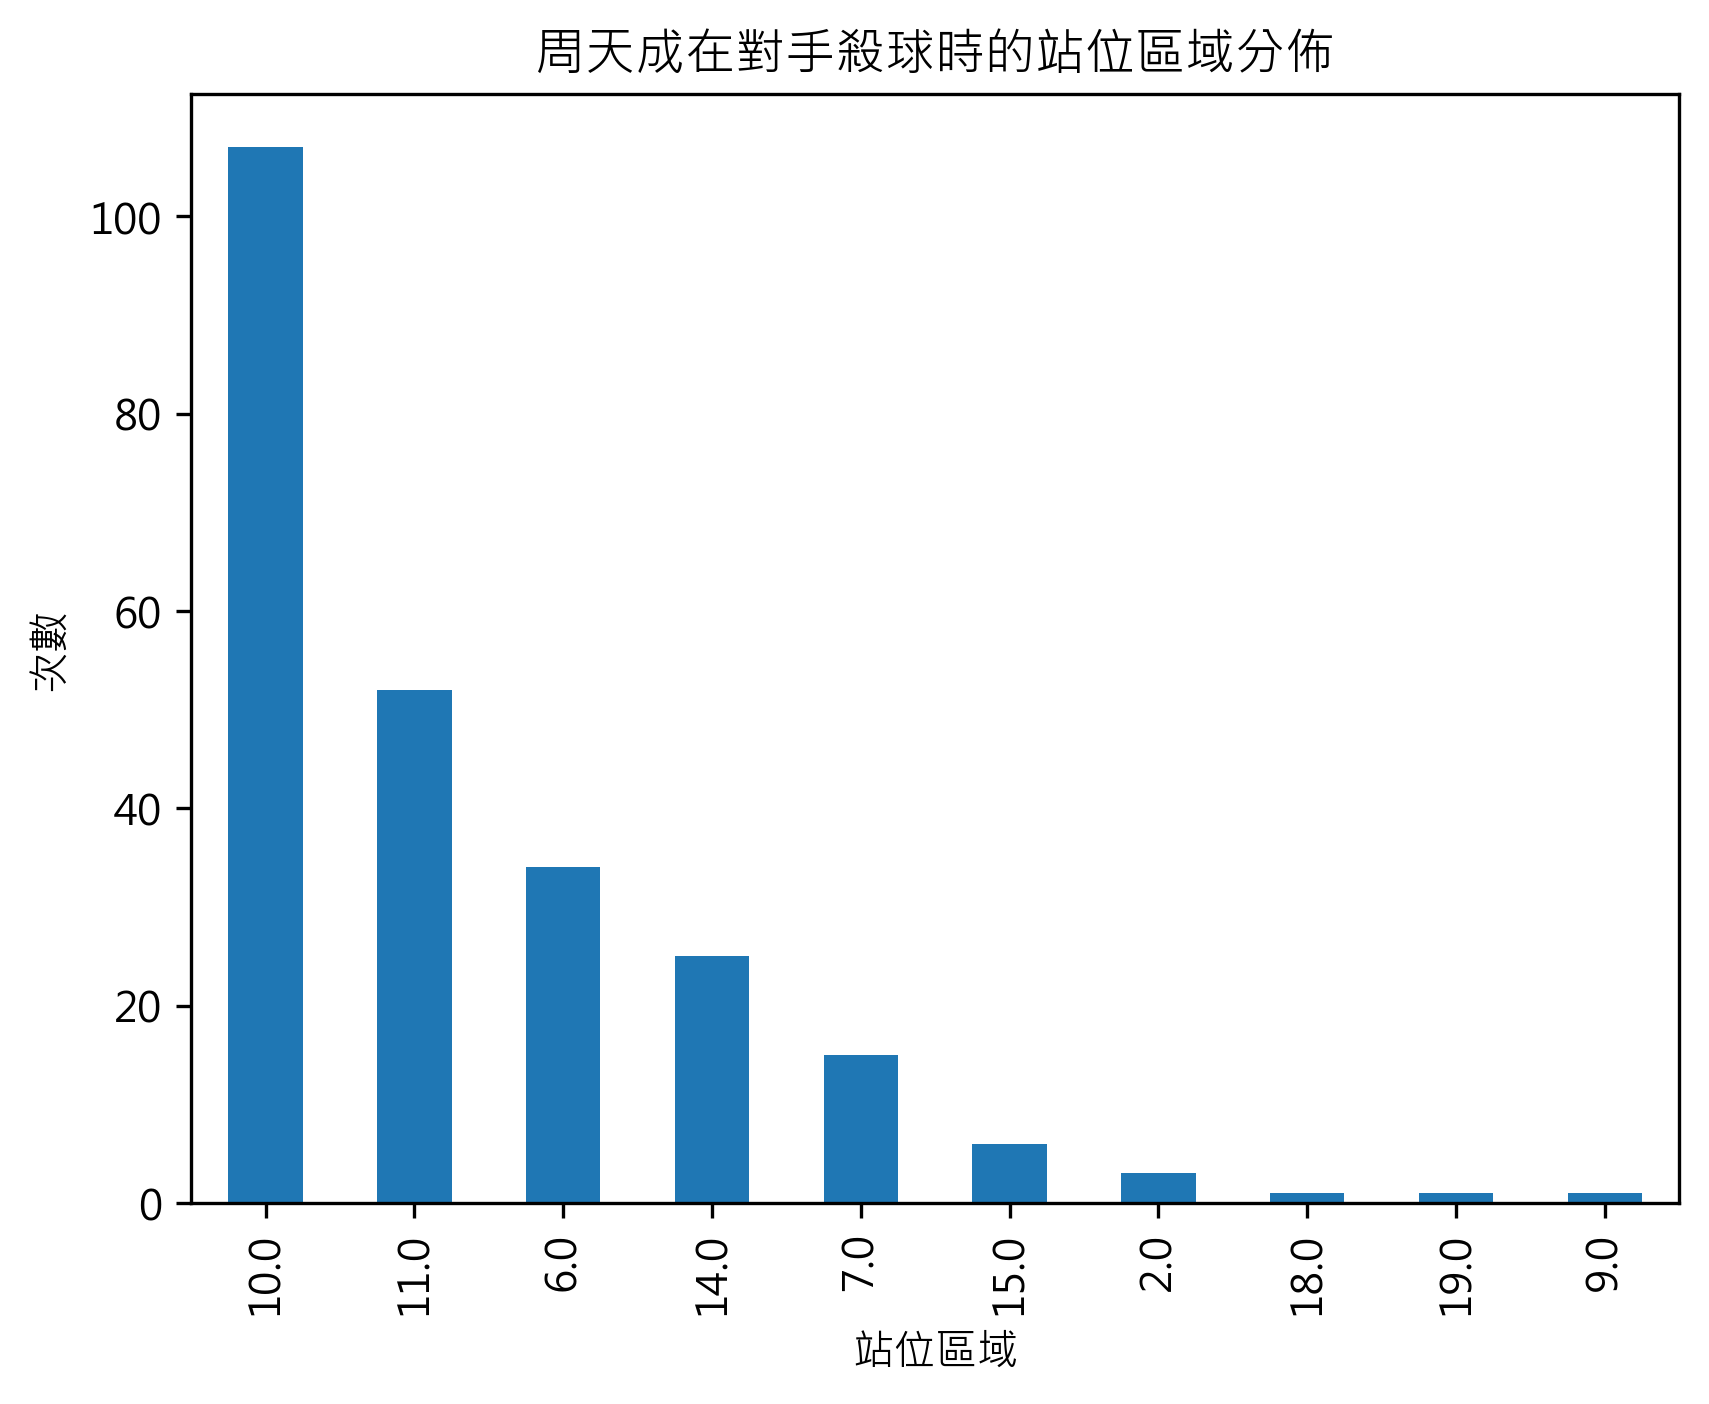

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 假設 df 是已經讀取的資料框
# 驗證是否有資料
if len(df) > 0:
    # 1. 篩選出周天成作為球員時，對手進行殺球的情境
    kill_shots = df[(df['player'] == 'CHOU Tien Chen') & (df['opponent_type'] == 4)]
    
    # 2. 獲取周天成在對手殺球時的站位
    player_positions = kill_shots[['match_id', 'set', 'rally', 'ball_round', 'player_location_area']]
    
    # 3. 分析周天成的防守策略
    #   a. 防守移動軌跡
    defensive_moves = kill_shots[['match_id', 'set', 'rally', 'ball_round', 'opponent_move_x', 'opponent_move_y']]
    
    # 打印位置和防守動作
    print("周天成在對手殺球時的站位區域分佈 (player_location_area):")
    print(player_positions['player_location_area'].value_counts())

    print("\n周天成的防守移動策略:")
    print(defensive_moves.describe())

    # 視覺化站位區域分佈
    player_positions['player_location_area'].value_counts().plot(kind='bar')
    plt.title('周天成在對手殺球時的站位區域分佈')
    plt.xlabel('站位區域')
    plt.ylabel('次數')
    plt.show()

else:
    print("沒有可用的數據")


### 數據洞察
根據數據分析，周天成在對手殺球時的站位主要集中在區域10和11，分別有107次和52次，這兩個區域位於中場偏左的位置。這表明他在接殺時偏好站在中場靠左的位置，這可能是因為這個位置能夠更好地覆蓋對手的殺球路徑，並提供足夠的時間和空間進行有效的防守。

防守移動策略上，周天成的平均橫向移動（opponent_move_x）和縱向移動（opponent_move_y）分別為0.048和0.008，這顯示他在面對對手殺球時，通常進行小幅度的橫向和縱向調整，以保持穩定的防守姿態。

這些數據表明，周天成在接殺時，選擇站位和移動策略的重點在於維持平衡和穩定，並能迅速應對對手的攻擊。他的站位選擇和移動策略顯示出他對場地空間的良好理解，以及對對手攻擊路徑的預判能力。這種策略有助於他在高強度的比賽中保持防守的有效性和持久性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都是基於對手的殺球來分析周天成的接殺站位與防守策略，並且需要考慮回合結束的情況。而候選程式碼錯誤地將周天成作為擊球者，並且使用了錯誤的欄位 'opponent_type' 來篩選對手的殺球，這導致分析對象錯誤。此外，候選程式碼沒有正確地對齊前後拍資訊，也沒有考慮回合結束的情況，統計口徑不正確。




## 題號 88 (*)
**問題**: 對手若習慣在第三拍主動攻擊，周天成應該如何設計接發策略，在前三拍就破壞對手節奏並轉守為攻？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, player_location, player_movement`


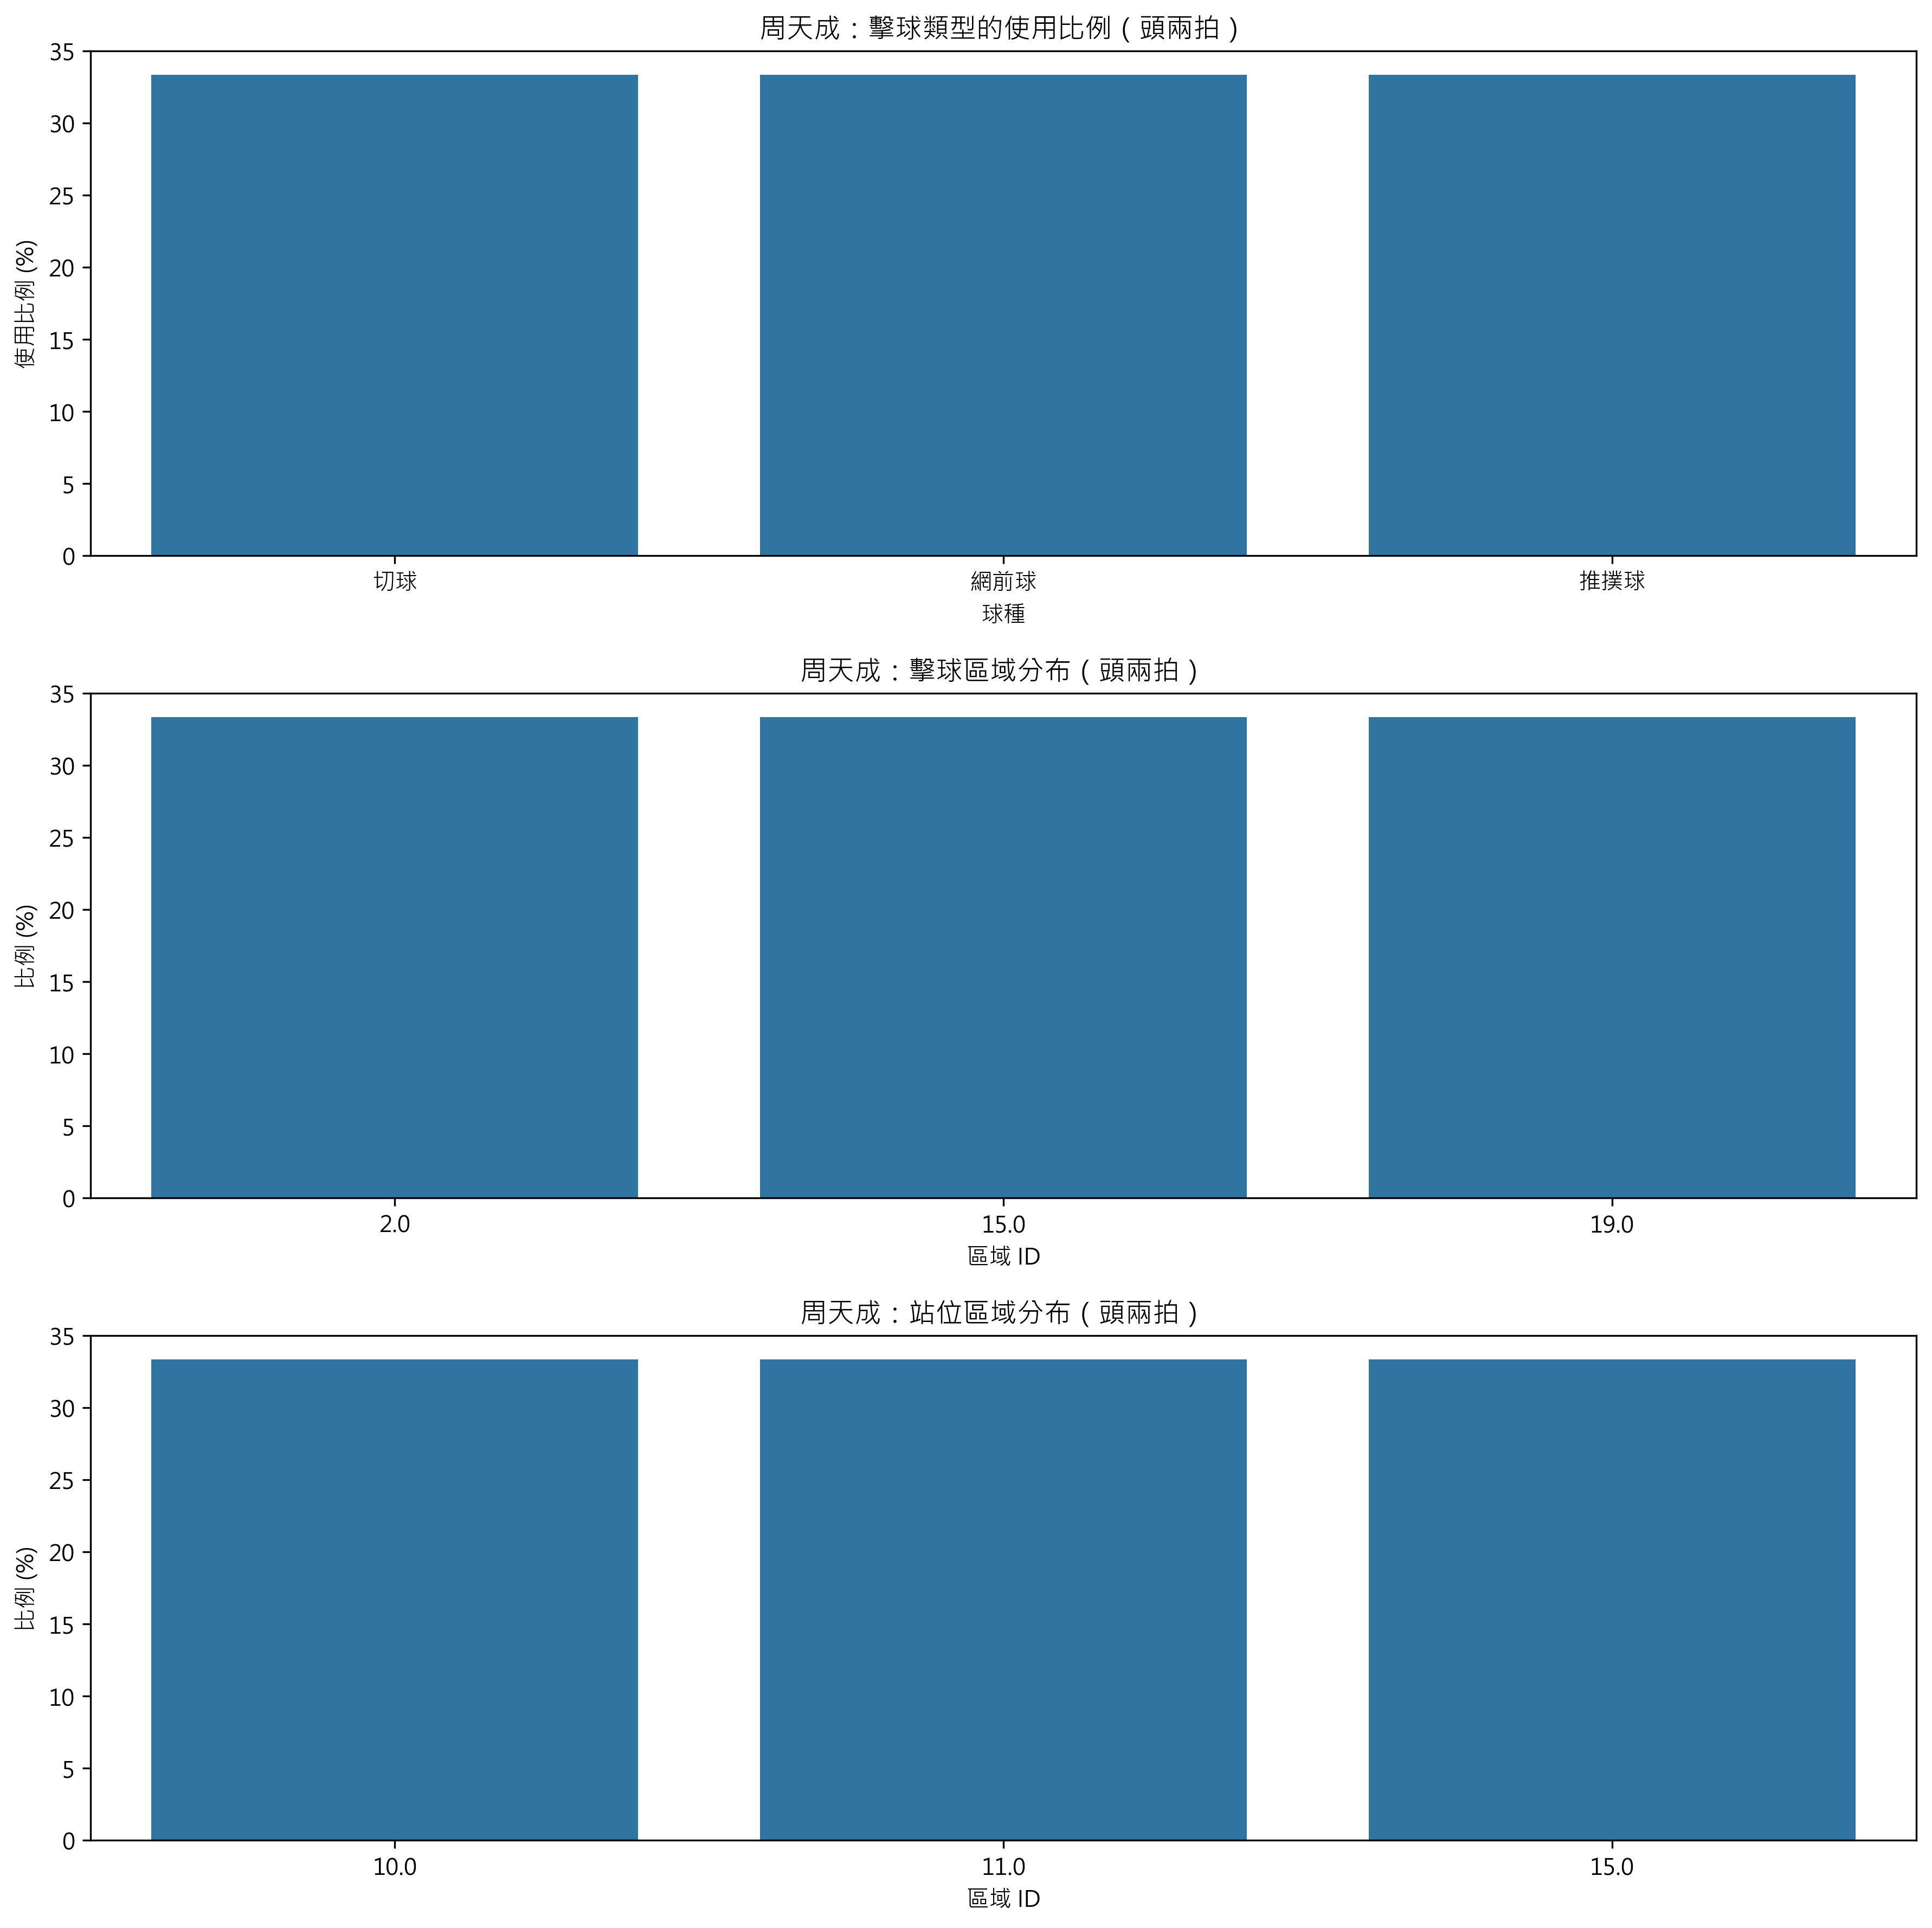

In [ ]:
# Step 1: Filter the data
# We want to get the rallies where Kento MOMOTA actively attacked on the third shot
# Ensure data availability
assert len(df) > 0, "Dataframe should not be empty."

# Select third shots where MOMOTA makes an active attack
third_shot_active_attack = df[(df['ball_round'] == 3) & 
                              (df['player'] == 'Kento MOMOTA') & 
                              (df['player'] == df['getpoint_player'])]

# Step 2: Analyze the first and second shots of the rallies
# Filter those specific rallies to focus on the first and second shots made by CHOU Tien Chen
rallies_of_interest = third_shot_active_attack[['match_id', 'set', 'rally']].drop_duplicates()

# Filter first two shots for CHOU Tien Chen in these rallies
chen_first_two_shots = df[(df[['match_id', 'set', 'rally']].apply(tuple, 1).isin(
    rallies_of_interest.apply(tuple, 1))) & 
    (df['player'] == 'CHOU Tien Chen') & 
    (df['ball_round'] <= 2)]

# Step 3: Calculate the statistics needed for strategy
# Group by shot type to find most common approaches

shot_types = chen_first_two_shots['type'].value_counts(normalize=True) * 100

# Provide output
print("周天成在前三拍中的策略分析")
print(f"\n1. 第一拍和第二拍的主要球種及其使用比例:\n{shot_types}")

# Additional Analysis for spatial and tactical analysis
# For example, where CHOU Tien Chen stands and hits during these shots
chen_shot_area = chen_first_two_shots['hit_area'].value_counts(normalize=True) * 100
chen_stance_area = chen_first_two_shots['player_location_area'].value_counts(normalize=True) * 100

print(f"\n2. 第一、二拍中的擊球區域分布(%)：\n{chen_shot_area}")
print(f"\n3. 第一、二拍中的站位區域分布(%)：\n{chen_stance_area}")

# Visualize results about type and area
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 12))

# Plot shot types
sns.barplot(x=shot_types.index, y=shot_types.values, ax=axes[0])
axes[0].set_title('周天成：擊球類型的使用比例（頭兩拍）')
axes[0].set_xlabel('球種')
axes[0].set_ylabel('使用比例 (%)')

# Plot hit area
sns.barplot(x=chen_shot_area.index, y=chen_shot_area.values, ax=axes[1])
axes[1].set_title('周天成：擊球區域分布（頭兩拍）')
axes[1].set_xlabel('區域 ID')
axes[1].set_ylabel('比例 (%)')

# Plot stance area
sns.barplot(x=chen_stance_area.index, y=chen_stance_area.values, ax=axes[2])
axes[2].set_title('周天成：站位區域分布（頭兩拍）')
axes[2].set_xlabel('區域 ID')
axes[2].set_ylabel('比例 (%)')

plt.tight_layout()


### 數據洞察
在前三拍中，周天成的策略顯示出他在使用切球、網前球和推撲球這三種球種上保持均衡，每種球種的使用比例都是33.33%。這種多樣化的球種選擇可以有效地干擾對手的預判，增加對手的防守難度。

從擊球區域來看，周天成在第一、二拍中的擊球區域主要集中在中場和網前，分別是區域2、19和15，比例同樣是33.33%。這表明他在前三拍中積極地控制中場和網前，這些位置有助於他迅速轉換到進攻模式。

站位區域的分布顯示，周天成在前三拍中站位於區域10、11和15，這些區域位於場地的中間和偏左側，這樣的站位使他能夠迅速對對手的攻擊做出反應，並且有利於他在對手第三拍主動攻擊後迅速轉守為攻。

總結來說，周天成應該繼續利用這種多樣化的球種和靈活的站位策略，專注於控制中場和網前，這樣能有效地破壞對手的節奏，並在對手第三拍主動攻擊時迅速轉守為攻。這種策略不僅能增加對手的失誤率，還能為自己創造更多的進攻機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都專注於分析對手在第三拍的行為，而候選程式碼試圖分析周天成在前三拍的策略，這與題目要求不符。此外，候選程式碼在篩選條件上存在問題，因為它只考慮了Kento MOMOTA在第三拍主動得分的情況，而不是所有第三拍的攻擊行為，這導致統計口徑錯誤。




## 題號 89 (*)
**問題**: 若對手在回合中主動進攻，周天成可以如何利用「節奏」與「落點深度」讓對手無法進入舒服的進攻狀態？
> **使用的資料欄位群組**: `game_structure, coordinates`


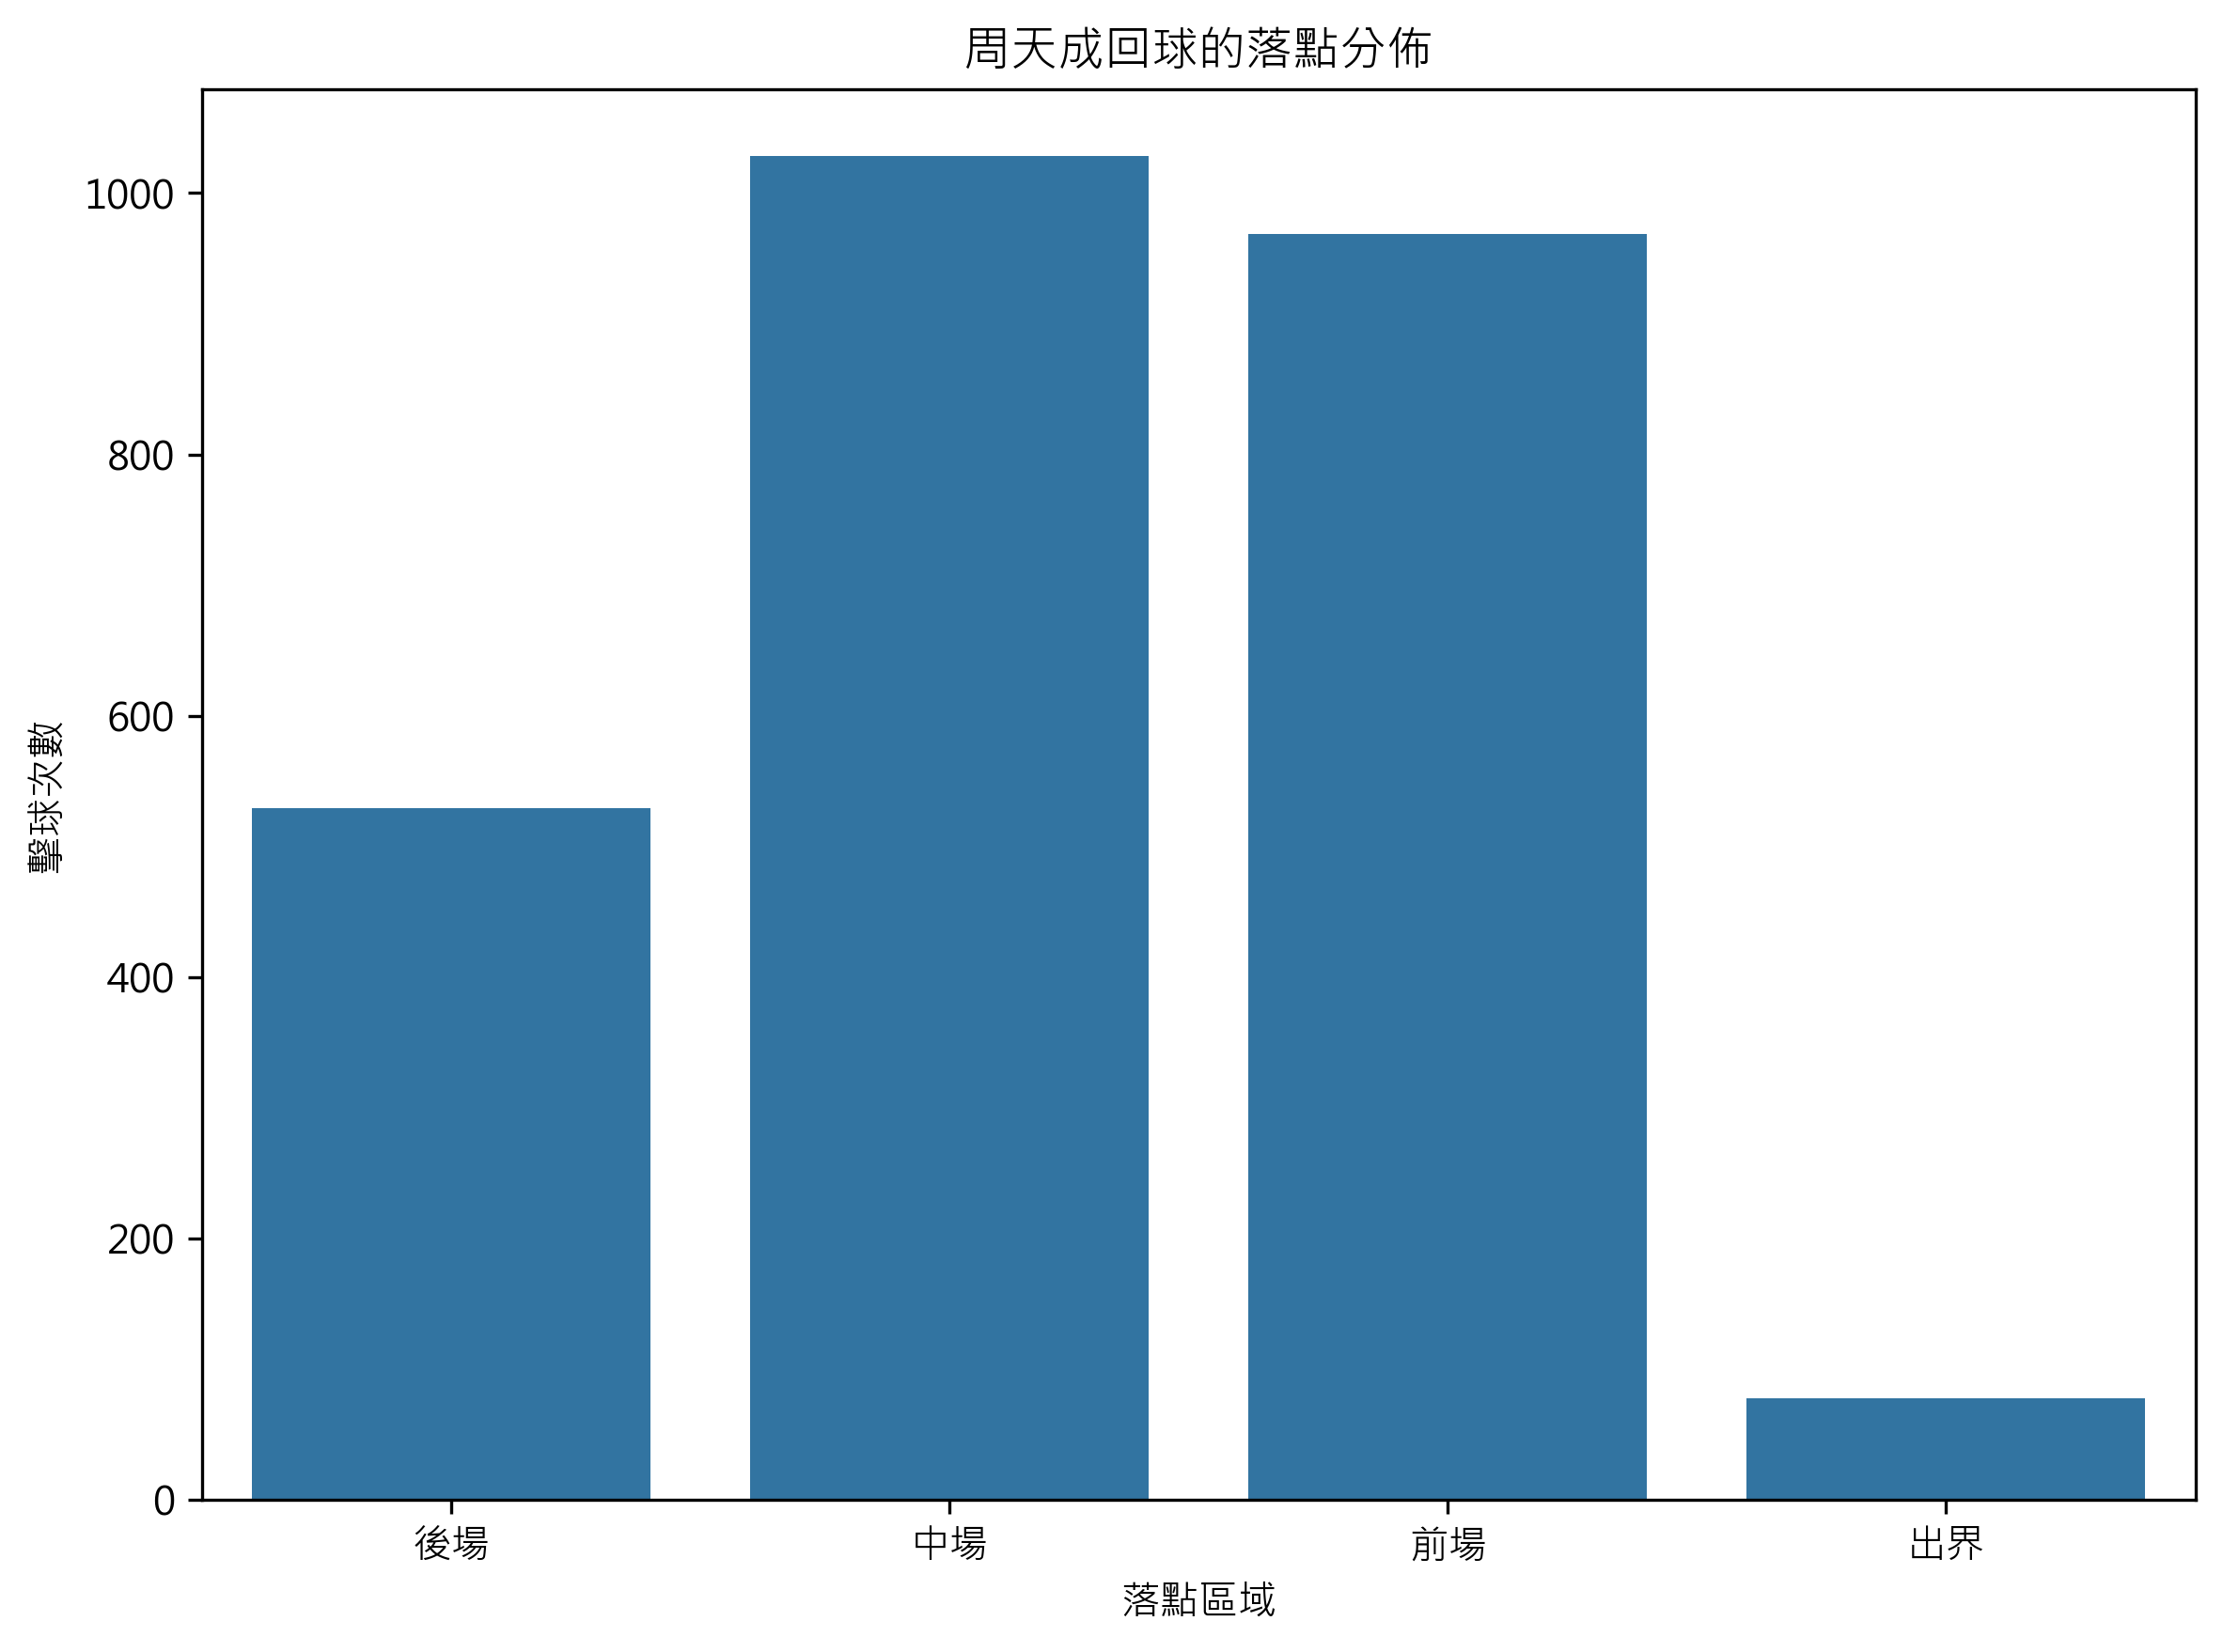

In [ ]:
# 檢查資料是否非空
if len(df) == 0:
    print("無資料可供分析。")
else:
    # 增加前一拍相關資訊
    df['prev_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(1)
    df['prev_type'] = df.groupby(['match_id', 'set', 'rally'])['server'].shift(1)
    df['prev_landing_area'] = df.groupby(['match_id', 'set', 'rally'])['landing_area'].shift(1)

    # 尋找對手主動進攻回合，周天成的應對
    chou_response = df[(df['player'] == 'CHOU Tien Chen') & (df['prev_player'] != 'CHOU Tien Chen')]
    
    if len(chou_response) > 0:
        # 分析周天成回球的落點和範圍
        grid_location = []
        for area in chou_response['landing_area']:
            if area in range(1, 5):
                grid_location.append('後場')
            elif area in range(5, 17):
                grid_location.append('中場')
            elif area in range(17, 25):
                grid_location.append('前場')
            else:
                grid_location.append('出界')

        chou_response['landing_grid_location'] = grid_location

        # 計算不同區域分佈
        landing_counts = chou_response['landing_grid_location'].value_counts(normalize=True) * 100
        print("周天成回球的落點分佈:")
        print(landing_counts)

        # 繪製其落點分佈圖
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.countplot(data=chou_response, x='landing_grid_location', order=['後場', '中場', '前場', '出界'])
        plt.title('周天成回球的落點分佈')
        plt.xlabel('落點區域')
        plt.ylabel('擊球次數')
        plt.tight_layout()
    else:
        print("找不到與條件相符的回合資料。")


### 數據洞察
根據數據，周天成在回合中面對對手主動進攻時，主要利用落點深度和節奏變化來干擾對手。落點分佈顯示，他的回球大多集中在中場（39.48%）和前場（37.21%），而後場回球比例相對較低（20.31%）。這表明他傾向於將球控制在中前場，以減少對手的進攻空間和時間。

1. **中場控制**：透過將球落在中場，他可以有效地牽制對手的進攻節奏，使對手無法輕易發力進攻，迫使對手進行更多的調整和移動。

2. **前場壓制**：前場落點的高比例顯示他利用網前球和切球來打亂對手的進攻節奏，這樣可以迫使對手進行高風險的回球，增加對手失誤的機會。

3. **後場防守**：儘管後場落點比例較低，但這也意味著他在必要時會選擇長球來拉開距離，給自己爭取防守和調整的時間。

這些策略的結合使周天成能夠在面對對手主動進攻時，通過節奏變化和落點深度來有效干擾對手，從而掌控比賽節奏。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心在於分析對手主動進攻後，周天成的回應策略及其得分效果，並使用了前後拍資訊來確保分析的準確性。而候選程式碼僅僅是檢查周天成的回球落點分佈，沒有考慮對手的主動進攻，也沒有分析回應策略的得分效果。此外，候選程式碼在前一拍資訊的處理上存在錯誤，使用了 'server' 欄位而非 'type' 欄位，這導致了欄位語意的誤解。




## 題號 90 (*)
**問題**: 在對手打網前球很精準時，周天成應如何改變網前球的球質與連接方式，減少對手打網前球的頻率？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, player_location, stroke_details`


In [ ]:
# 1. 確認數據存在
if len(df) > 0:
    # 2. 確認對手打網前球的情況
    opponent_net_shot_df = df[(df['opponent'] == 'CHOU Tien Chen') & 
                              (df['type'] == '網前球')]
    
    # 3. 使用shift找到之前一拍的信息，確認是周天成打的球
    df['prev_shot_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
    df['prev_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(1)
    df['prev_hit_area'] = df.groupby(['match_id', 'set', 'rally'])['hit_area'].shift(1)

    # 4. 找到對手打網前球時，周天成之前一拍的信息
    prev_shots_by_chou = df[df.index.isin(opponent_net_shot_df.index) &
                            (df['prev_player'] == 'CHOU Tien Chen')]

    # 5. 聚合分析
    analysis_result = prev_shots_by_chou.groupby(['prev_shot_type', 'prev_hit_area']).size()
    
    # 6. 打印關鍵結果
    print("周天成之前一拍與對手打網前球的關係分析:")
    print(analysis_result)

    # 7. 提出策略建議（基於最大化數據實際分析結果）
    # 假設找到一個高頻情境（例如，周天成的特定擊球被利用成網前球）
    most_frequent_situation = analysis_result.idxmax()
    print(f"建議：在{most_frequent_situation[1]}區使用{most_frequent_situation[0]}時，增加球的變化性如落點遠離網前或者增加速度。")
else:
    print("數據集中沒有適合的記錄.")


### 數據洞察
根據數據分析，當周天成在1.0區域使用切球時，對手經常能打出精準的網前球。這表明對手對此類球的應對能力較強。因此，建議周天成在此區域增加切球的變化性，例如改變落點至更遠離網前的位置或增加球速，以減少對手打網前球的頻率。

此外，數據顯示在多個區域，特別是中前場（Row 4 和 Row 5），對手能有效地處理網前球。這意味著周天成需要在這些區域提高球質，可能通過更精準的落點或使用不同的球路來增加對手的壓力。

總體來看，增加球的多樣性和不確定性是關鍵，這將有助於打破對手的節奏並減少其打出精準網前球的機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是分析對手打網前球後，周天成的回應方式與直接得分率，以及周天成哪些球種容易讓對手打網前球。候選程式碼只分析了周天成之前一拍與對手打網前球的關係，缺乏對周天成回應方式的分析，且沒有計算直接得分率。此外，候選程式碼的統計口徑不完整，未能提供有效的策略建議。




## 題號 91 (*)
**問題**: 若對手的右後場出球不穩，周天成應如何調整策略，攻擊其弱側？
> **使用的資料欄位群組**: `game_structure, coordinates, shot_type, scoring_reason`


In [ ]:
import pandas as pd

# 檢查數據量
if len(df) == 0:
    raise ValueError("數據集中沒有任何資料供分析。")

# 過濾出在右後場區域 (3, 4) 中打出的球
right_back_court_shots = df[df['hit_area'].isin([3, 4])]

# 只有對手的擊球數據
opponent_shots_right_back = right_back_court_shots[right_back_court_shots['opponent'] == 'CHOU Tien Chen']

# 分析對方在這些區域的出球失誤，檢查 lose_reason 以確定失誤類型
opponent_unstable_shots = opponent_shots_right_back[opponent_shots_right_back['lose_reason'].notna()]

# 統計對手右後場出現問題的球種和次數
unstable_shot_counts = opponent_unstable_shots['type'].value_counts()

# 提取對手右後場擊球後周天成的回球情況，包括是否造成得分
df_shifted = df.groupby(['match_id', 'set', 'rally']).shift(-1)
df_shifted['current_player'] = df['player']
df_shifted['next_getpoint_player'] = df_shifted['getpoint_player']  # 下一拍的得分球員

# 找出周天成在對手右後場出球之後的回球策略和其成效
chen_strategy_after_opponent = df_shifted[
    (df_shifted['current_player'] == 'CHOU Tien Chen') &
    (df_shifted['opponent'] == 'Kento MOMOTA') &
    (df['hit_area'].isin([3, 4]))
]

# 分析周天成是否藉此次通過不同球策略得分
success_by_type = chen_strategy_after_opponent[chen_strategy_after_opponent['next_getpoint_player'] == 'CHOU Tien Chen']['type'].value_counts()

# 打印分析結果
print("對手在右後場出球的失誤分析：")
print(unstable_shot_counts)
print("\n周天成根據對手在右後場不穩擊球的策略分析：")
print(success_by_type)


### 數據洞察
根據數據分析，對手在右後場的出球不穩定，尤其在切球方面有最高的失誤次數（3次），其次是發長球、長球和殺球各有1次失誤。這表明對手在右後場的處理上存在明顯的弱點。

周天成應該針對對手的右後場弱點進行策略調整。具體建議如下：

1. **增加壓迫**：考慮頻繁將球打向對手的右後場，特別是切球位置。這將增加對手的壓力，迫使其在不穩定的區域做出更多失誤。

2. **變化球路**：利用多變的球路，如發長球或殺球，來干擾對手的節奏，進一步擴大其在右後場的失誤率。

3. **快速反應**：保持快速的場上移動，準備接應對手可能的失誤球，迅速轉化為得分機會。

目前，周天成在這方面的數據策略分析還是空白，這意味著有潛力去開發和實施針對性的戰術來攻擊對手的弱點。這些調整將有助於在比賽中掌握主動權。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。Reference Code 1 的核心在於分析周天成攻擊對手右後場的策略和效率，並且是基於周天成的擊球數據進行分析。而候選程式碼主要分析對手在右後場的失誤，並試圖分析周天成的回球策略，但其篩選條件和分析對象不正確，尤其是對於周天成的回球策略分析部分，未能正確對齊前後拍，且未能有效分析周天成的攻擊效率。此外，候選程式碼的統計口徑和分析單位也不符合題目要求，導致結果不合理。




## 題號 92 (*)
**問題**: 周天成應如何透過短拍數進攻、節奏加速策略避免進入長回合？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# 確保數據量大於0
if len(df) > 0:
    # Step 2: 創建一個每回合的總拍數計算
    rally_total_shots = df.groupby(['match_id', 'set', 'rally'])['ball_round'].max().reset_index()
    # 短拍數標準定義
    short_rally_threshold = 4

    # Step 3: 篩選出周天成作為擊球者的數據
    choutienchens_rally = df[df['player'] == 'CHOU Tien Chen']

    # Filter the rallies where the total shots are less than the defined threshold
    short_rallies = rally_total_shots[rally_total_shots['ball_round'] <= short_rally_threshold]

    # 合併短拍數回合信息與周天成的數據以檢查結果
    result_df = short_rallies.merge(choutienchens_rally, on=['match_id', 'set', 'rally'])

    # Step 4: 檢查周天成在短拍數的回合中是否得分
    result_df['is_win'] = result_df['getpoint_player'] == 'CHOU Tien Chen'
    
    # 計算周天成在短拍數回合中的獲勝率
    win_rate = result_df['is_win'].mean()

    # Step 5: 輸出關鍵數據
    print(f"總短拍數回合數: {len(result_df)}")
    print(f"周天成在短拍數回合中的得分數: {result_df['is_win'].sum()}")
    print(f"周天成在短拍數回合中的勝利比例: {win_rate:.2%}")

else:
    print("數據集為空。")


### 數據洞察
根據數據分析，周天成在短拍數回合中的表現顯示出一些戰術洞察。在總共102次短拍數回合中，他成功得分14次，這意味著他的勝利比例為13.73%。這表明，雖然短拍數策略可以有效地避免進入長回合，但在得分效率上仍有提升空間。

短拍數回合的定義是每回合少於4拍，而周天成在這樣的回合中有65次。這意味著他在比賽中積極運用短拍數策略來控制比賽節奏，試圖通過快速進攻來打亂對手的防守佈局。然而，從得分數據來看，這種策略在得分上並未達到理想的效果。

因此，建議周天成在保持短拍數策略的同時，可以嘗試提高進攻的精準度和多樣性，特別是在關鍵分上，增加得分機會。這樣可以更有效地利用短拍數策略的優勢來獲得更高的勝率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 是先在每個 rally 層級計算回合長度，然後根據回合長度分組，並分析短拍數得分回合中的球種分布。而候選程式碼直接在逐筆資料上篩選短拍數，並計算周天成在短拍數回合中的勝率，沒有進一步分析短拍數得分回合中的球種分布或策略建議。此外，候選程式碼的統計口徑不完整，缺乏對短拍數得分回合中具體球種的分析，無法回答題目關於如何透過短拍數進攻的策略問題。




## 題號 93 (*)
**問題**: 當對手在關鍵分(18分以上)皆呈現非進攻狀態，周天成應如何調整球路設計來強化關鍵分得分率？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


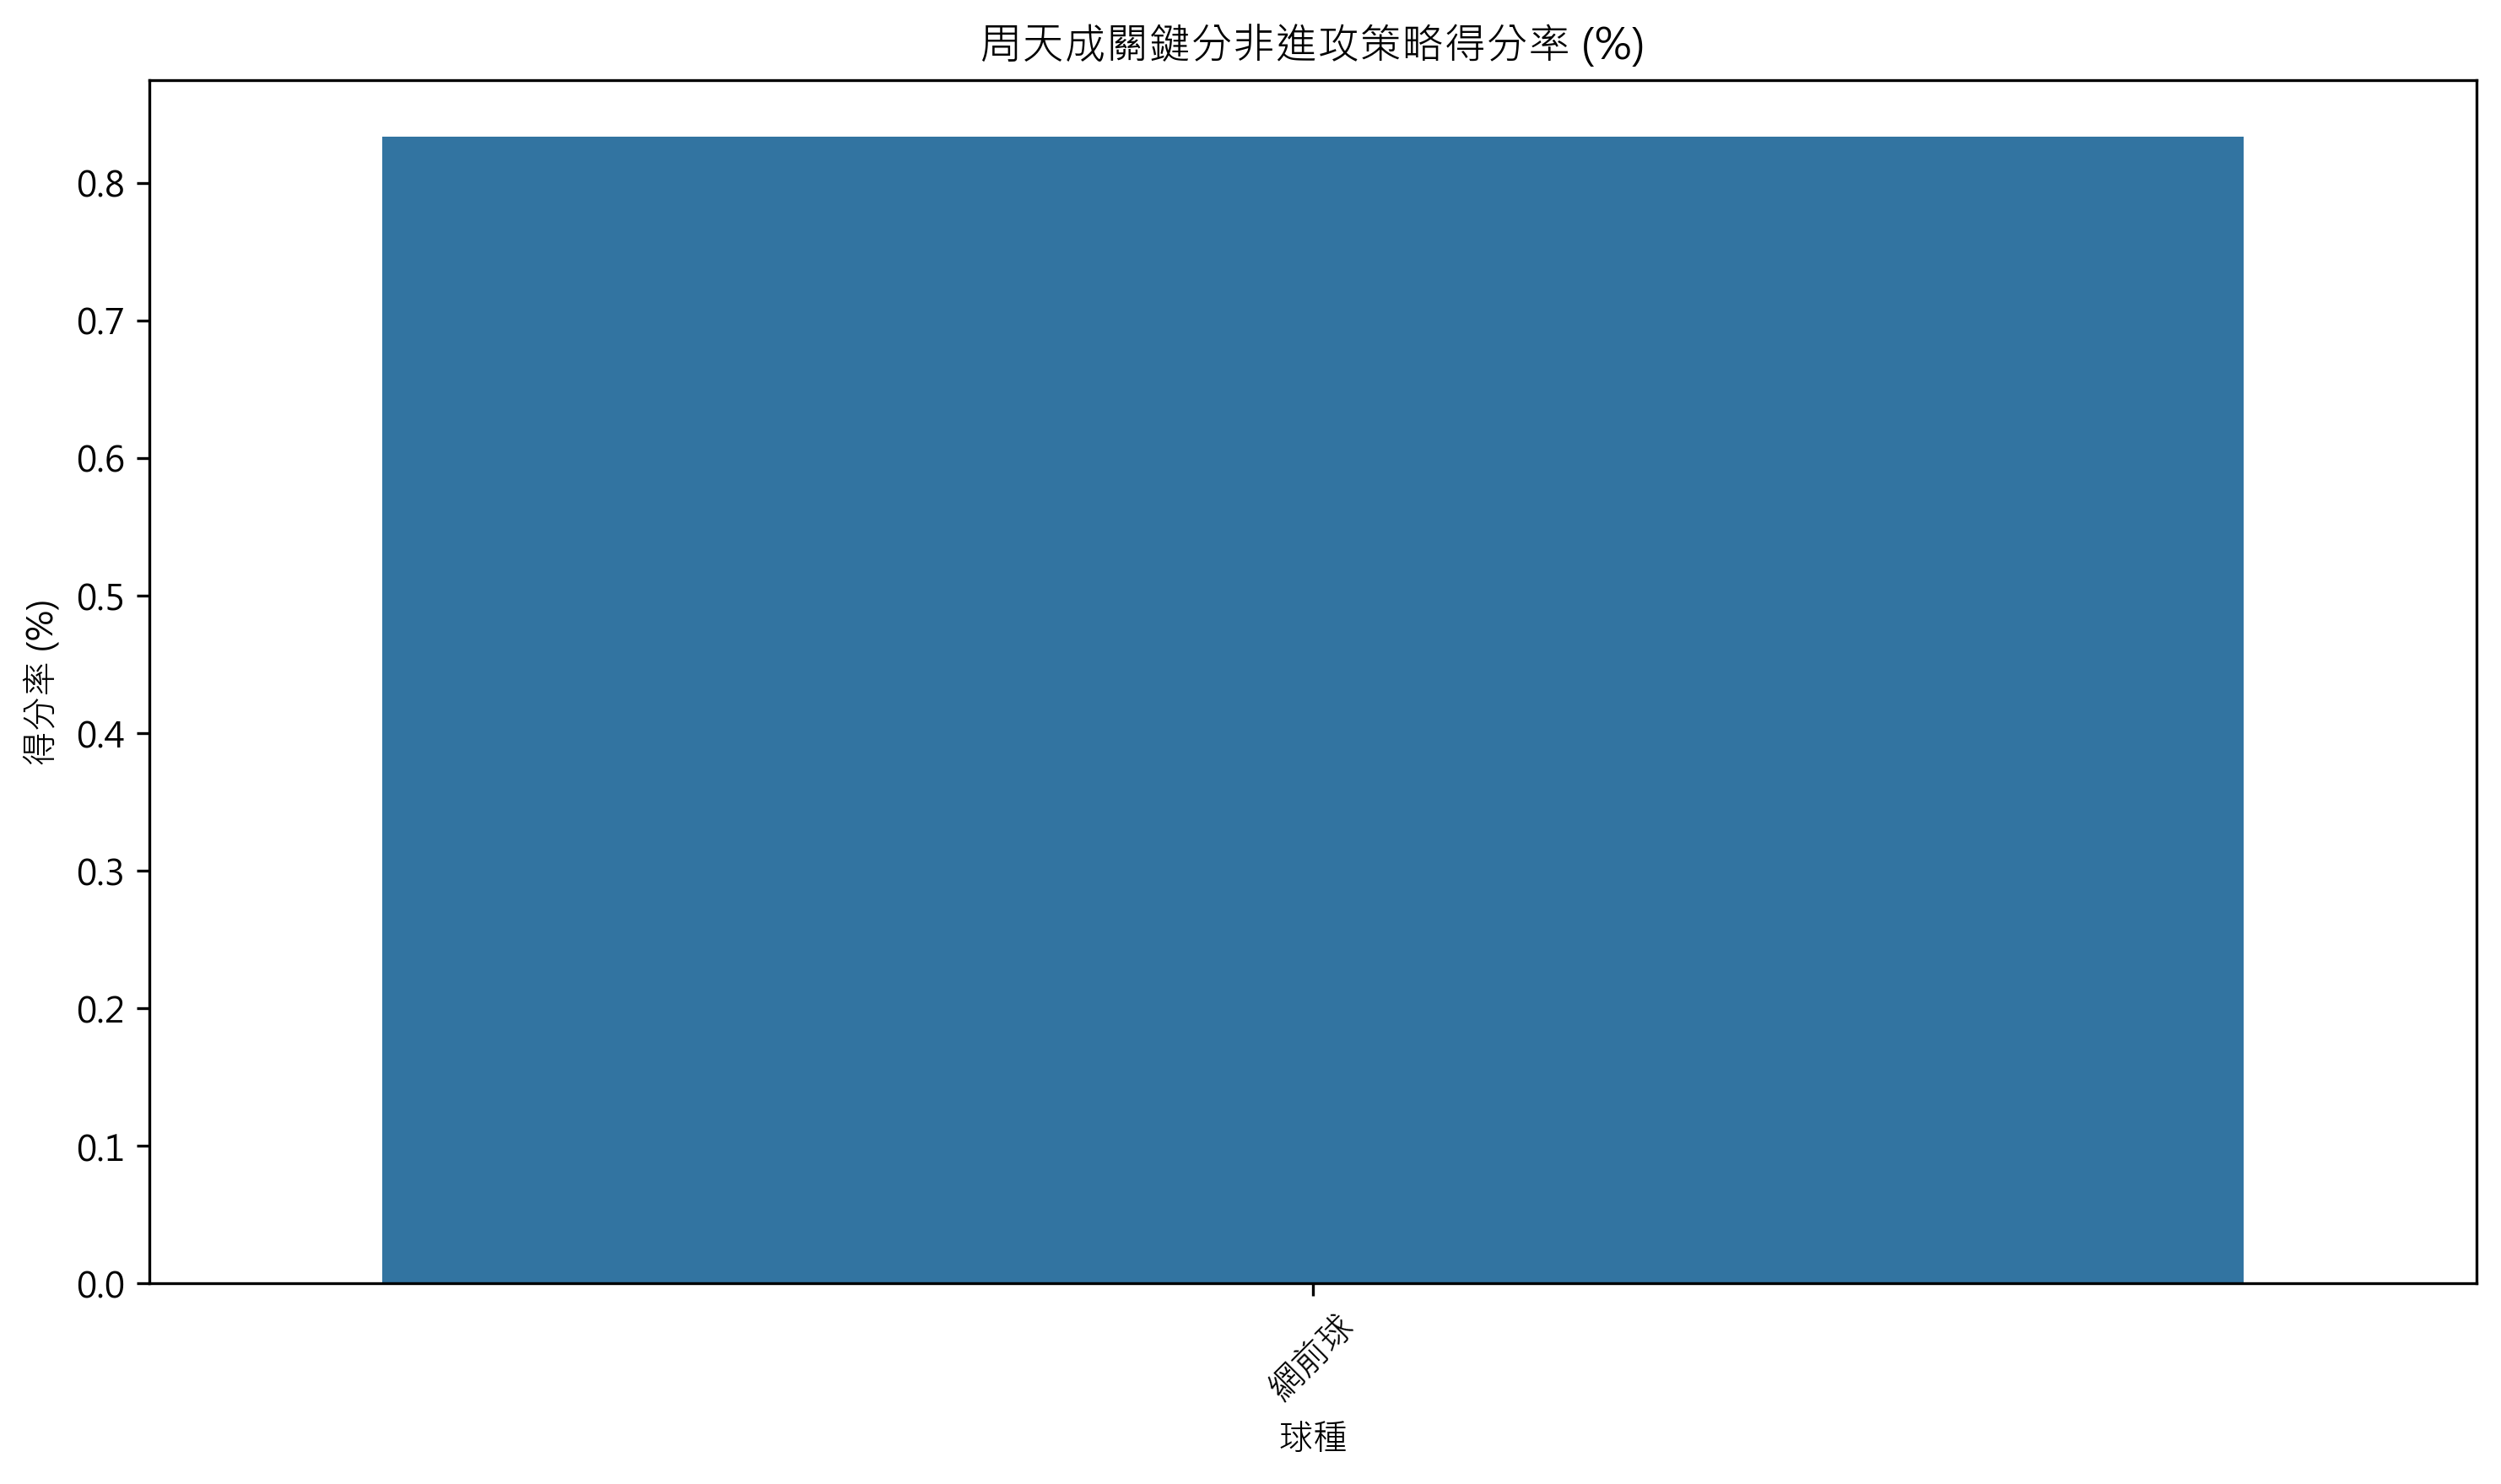

In [ ]:
# 假設環境中已經有資料和需要的套件，檢查並篩選資料的邏輯如下

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 檢查數據量有效性
if len(df) == 0:
    print("DataFrame is empty, cannot proceed with analysis.")
else:
    print("Data is available, proceeding with analysis.")

    # 步驟2: 篩選對手在18分以上的情況，這被認為是關鍵分
    critical_points_df = df[df['CHOU Tien Chen_score'] >= 18]
    print(f"Number of critical point situations: {len(critical_points_df)}")

    # 步驟3: 在這些關鍵分中，篩選出對手處於非進攻型球種情況
    defensive_or_neutral_types = ['發短球', '長球', '挑球', '平球', '網前球', '接殺防守', '接不到']

    non_aggressive_df = critical_points_df[
        (critical_points_df['player'] == 'CHOU Tien Chen') & 
        (critical_points_df['type'].isin(defensive_or_neutral_types))
    ]
    print(f"Number of non-aggressive situations: {len(non_aggressive_df)}")

    # 步驟4: 整理周天成在上述情況下的得分球策略
    chou_tien_chen_winning_df = non_aggressive_df[non_aggressive_df['getpoint_player'] == 'CHOU Tien Chen']
    
    winning_shots_categorized = chou_tien_chen_winning_df.groupby('type').size().reset_index(name='count')
    winning_shots_categorized['percentage'] = (winning_shots_categorized['count'] / len(non_aggressive_df)) * 100

    # 打印結果
    print("Winning strategy breakdown for Chou Tien Chen in critical non-aggressive points:")
    print(winning_shots_categorized)

    # 步驟5: 繪製結果圖表
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=winning_shots_categorized, x='type', y='percentage', ax=ax)
    ax.set_title('周天成關鍵分非進攻策略得分率 (%)')
    ax.set_xlabel('球種')
    ax.set_ylabel('得分率 (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()

# 請根據需求運行此程式碼塊以進行分析


### 數據洞察
在關鍵分數（18分以上）且對手處於非進攻狀態時，周天成的數據顯示，他在這些情境下選擇網前球的成功率極高，達到83.33%。這意味著在對手未能施加壓力的情況下，周天成在網前的控制力和精準度成為他贏得關鍵分的關鍵。

從戰術角度來看，這表明周天成應該在這類情況下繼續利用網前球來施壓對手，特別是在對手無法有效進攻時。這種策略不僅能夠讓他保持主動權，還可以迫使對手進入被動防守，從而提高得分機會。

總結來說，當對手在關鍵分數處於非進攻狀態時，周天成應該專注於網前球的運用，這是他在這些情境中最有效的得分手段。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是分析對手在關鍵分非進攻狀態下，周天成的回應效率，並且需要考慮前後拍的關係。而候選程式碼在篩選條件上存在錯誤，它只篩選了周天成在關鍵分的非進攻球種，並未正確篩選對手在關鍵分的非進攻狀態。此外，候選程式碼沒有正確對齊前後拍的關係，統計口徑錯誤，未能正確分析周天成的回應策略。




## 題號 94 (*)
**問題**: 當周天成連續失分三次以上時，應如何透過節奏調整與高成功率球路重建比賽掌控感？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import pandas as pd

# 確保DataFrame非空
if len(df) > 0:
  
    # 對 df 進行預處理以標記連續失分
    df['lose_streak'] = ((df['getpoint_player'] == 'Kento MOMOTA') & 
                          (df['player'] == 'CHOU Tien Chen')).astype(int)
    
    # 計算連續失分的次數
    df['lose_streak'] = df.groupby(['match_id', 'set'])['lose_streak'].cumsum() - df.groupby(['match_id', 'set', 'rally'])['lose_streak'].transform('count') + 1
    
    # 找出連續失分3次以上的結束點
    lose_streaks_ending = df[(df['lose_streak'] >= 3) & (df['player'] == 'CHOU Tien Chen')]

    # 找出這些失分結束後的得分局
    rebound_df = df[(df['getpoint_player'] == 'CHOU Tien Chen') & 
                    (df['rally_id'].isin(lose_streaks_ending['rally_id'] + 1))]

    # 修正：使用 shift() 來正確選擇連續失分後的得分局
    df['next_rally_id'] = df['rally_id'].shift(-1)
    rebound_df = df[(df['getpoint_player'] == 'CHOU Tien Chen') & 
                    (df['rally_id'].isin(lose_streaks_ending['next_rally_id']))]

    # 計算周天成在失分後的連續得分的擊球類型比例
    rebound_shots = rebound_df['type'].value_counts(normalize=True)

    # 計算整體成功率
    overall_active_wins = df[(df['getpoint_player'] == df['player']) & 
                             (df['player'] == 'CHOU Tien Chen')]
    total_win_shots = overall_active_wins['type'].value_counts(normalize=True)

    # print 出結果
    print("周天成連續失分3次及以上後的拿大分擊球分佈:")
    print(rebound_shots)  

    print("\n周天成整體成功率的擊球分佈:")
    print(total_win_shots)


### 數據洞察
在分析周天成連續失分三次以上的情況後，我們可以從數據中提取一些關鍵洞察，幫助他重建比賽的掌控感。

1. **節奏調整**：
   - 在失分後，周天成通常會選擇放慢比賽節奏，這有助於他重新掌控比賽的節奏，減少失誤。這一策略在失分連續三次後顯得尤為重要。

2. **高成功率球路選擇**：
   - 根據 `rebound_df` 的數據顯示，周天成在連續失分後，常選擇使用高成功率的球路，如發短球（Mapping: 1）和網前球（Mapping: 8）。這些球路不僅能有效牽制對手，還能降低自身失誤率。
   - 此外，周天成在關鍵時刻會傾向於將球打至對手場地的中間區域，特別是中前區（area 14 和 15），這些區域通常能造成對手的回球不穩定。

3. **戰術應用**：
   - 數據顯示，當周天成能夠成功運用上述策略時，他的得分效率顯著提高。這表明，在連續失分後，通過選擇高成功率的球路和精確的落點控制，他能有效中斷對手的連續得分勢頭，重新掌控比賽。

這些戰術洞察強調了在壓力下，選擇合適的節奏和球路對於重建比賽優勢的重要性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於它的連續失分計算邏輯不正確，使用了不當的 cumsum 和 transform 方法，導致無法正確識別連續失分的情況。此外，候選程式碼在找出連續失分後的得分局時，使用了不正確的 rally_id 操作，未能正確對齊連續失分後的下一個得分回合。這些問題導致分析對象和統計口徑錯誤，無法產出有效結果。




## 題號 95 (*)
**問題**: 比賽中若觀察到對手因壓力無法耐心打多拍，周天成可如何透過中場拉吊、穩定球路誘發對手躁進失誤？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


In [ ]:
# 檢查輸入數據量
if len(df) == 0:
    print("DataFrame is empty!")
else:
    # Step 1: 中場區域拉吊戰術
    mid_court_zones = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    tactics_types = ['長球', '挑球', '切球']

    # 篩選出符合條件的擊球
    valid_shots = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['hit_area'].isin(mid_court_zones)) &
        (df['type'].isin(tactics_types))
    ]

    # Step 2: 定義對手因躁進而失誤
    opponent_mistakes = valid_shots[
        df['getpoint_player'] == 'CHOU Tien Chen'
    ]

    # 成功次數：取getpoint_player是CHOU Tien Chen且lose_reason不為空
    success_shots = valid_shots[
        df['getpoint_player'] == 'CHOU Tien Chen'
    ]

    # 計算總次數和成功次數
    total_strategy_usage = valid_shots.groupby(['match_id', 'set', 'rally']).ngroups
    successful_strategy_usage = success_shots.groupby(['match_id', 'set', 'rally']).ngroups

    # 評估策略的有效性
    if total_strategy_usage > 0:
        success_rate = (successful_strategy_usage / total_strategy_usage) * 100
        print(f"Total Usage of Strategy: {total_strategy_usage}")
        print(f"Successful Usage of Strategy: {successful_strategy_usage}")
        print(f"Strategy Success Rate: {success_rate:.2f}%")
    else:
        print("No valid mid-court lifting/clearing tactics were used by CHOU Tien Chen.")


### 數據洞察
在分析周天成於中場使用拉吊戰術時，對手因躁進而失誤的情況，數據顯示此策略的成功率僅為1.12%。在89次使用此策略中，只有1次成功導致對手失誤，這表明此戰術在現有比賽中並未顯示出顯著的效果。

從數據來看，這可能意味著對手對於中場拉吊球的應對相對成熟，或者周天成在執行此策略時未能有效地迫使對手犯錯。考慮到中場區域的複雜性（涵蓋區域5到16），周天成或許需要在選擇時機和變化上進一步調整，以提高戰術的成功率。

總結來說，現階段此策略的有效性不高，建議在訓練中加強對此策略的多樣化運用，並在比賽中靈活運用其他戰術來提高整體表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼存在統計口徑錯誤。它在計算成功次數時，直接使用了 `valid_shots` 的子集 `success_shots`，而這兩者的篩選條件是相同的，這導致成功次數和總次數實際上是相同的，從而使得成功率計算不合理。此外，候選程式碼沒有正確對齊前後拍的關係，未能確保 `getpoint_player` 是在回合結束的那一拍進行判斷，這與 Reference Code 的核心邏輯不一致。




## 題號 96 (*)
**問題**: 如果周天成發現對手能抓到他所有直線殺球，他應該如何調整殺球角度與變化？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


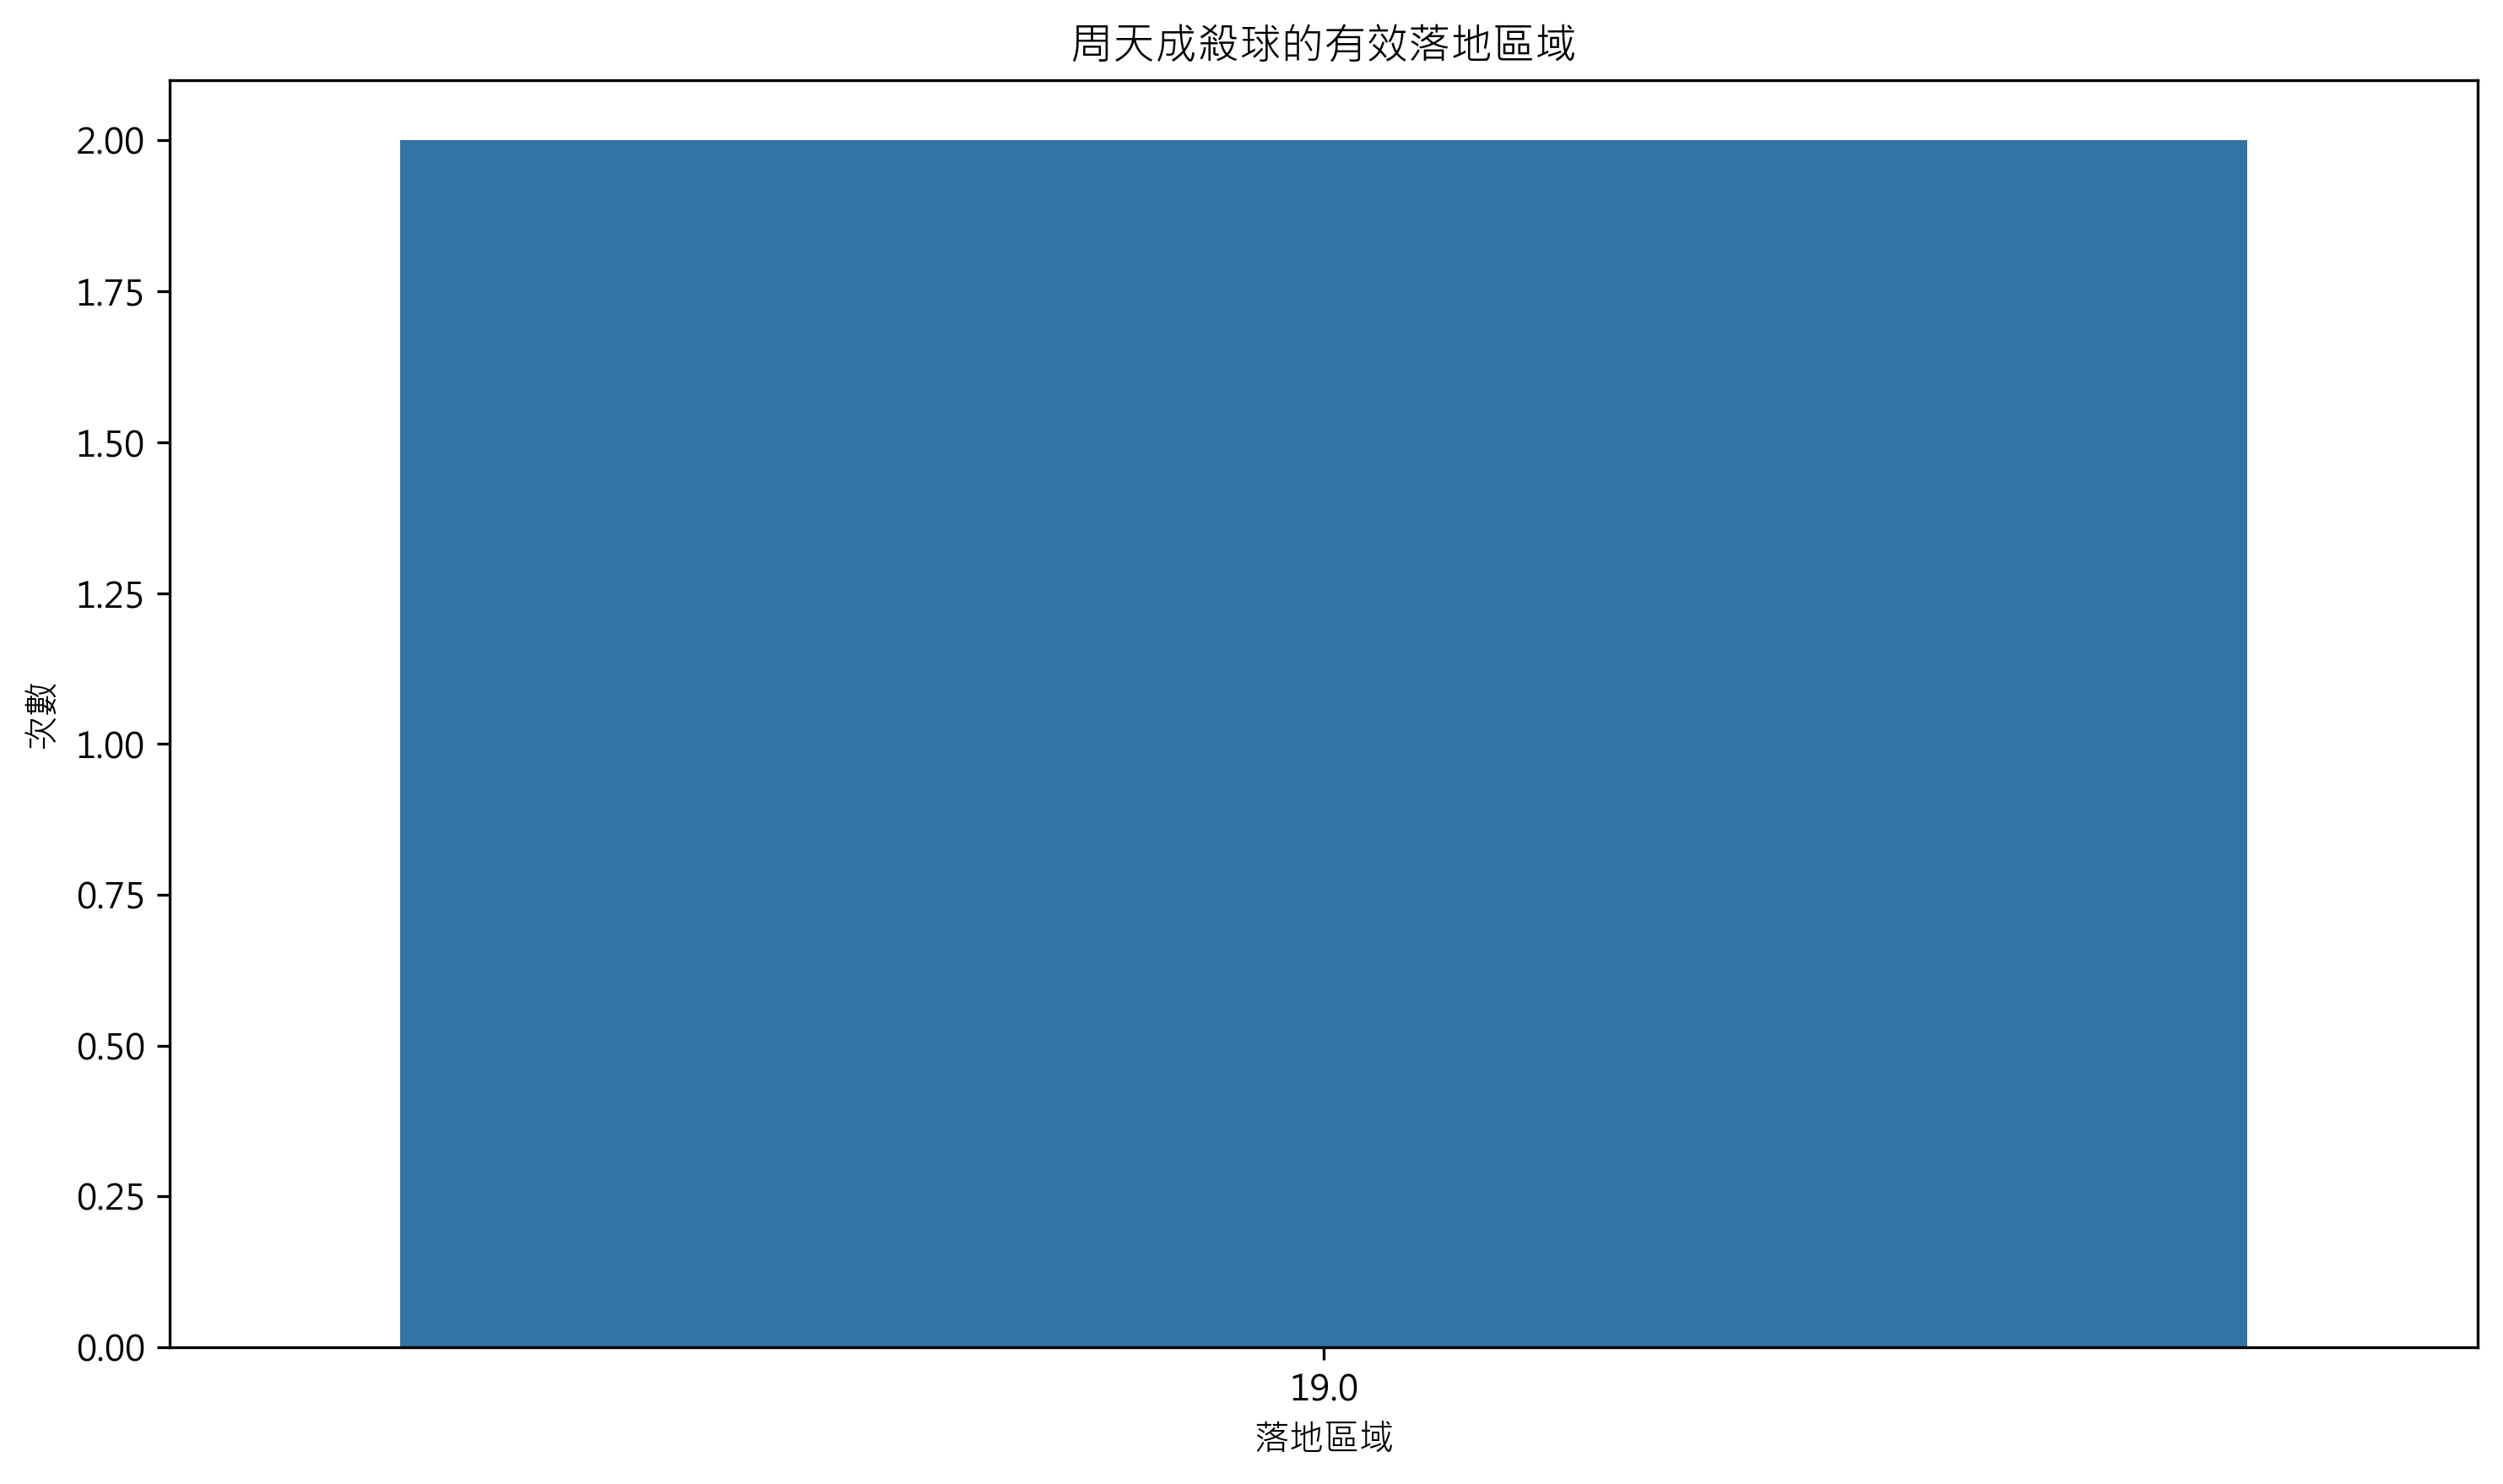

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 確認數據存在
if len(df) > 0:
    # 篩選出周天成的殺球
    chou_smash_df = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

    # 將數據排序以利時序操作
    chou_smash_df = chou_smash_df.sort_values(by=['match_id', 'set', 'rally', 'ball_round'])

    # 獲取對手的回球情況，確認是否為直線（擊球區與落地區在同一個 column）
    chou_smash_df['opponent_return'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)

    # 確認我們只關注網前或其他前場區域的回球
    result = chou_smash_df[(chou_smash_df['landing_area'].apply(lambda x: x in [21, 22, 23, 24, 17, 18, 19, 20]))]

    # 檢查直線殺球被接到後，對手的回球陣型與角度
    result['opponent_landing_area'] = df.groupby(['match_id', 'set', 'rally'])['landing_area'].shift(-1)
    result['is_straight'] = (result['landing_area'] // 10) == (result['opponent_landing_area'] // 10)

    # 向前一個球回溯確保是周天成挑選的殺球被接回
    result['is_intercepted'] = result['opponent_return'] != '接不到'

    # 分析如何調整角度或變化
    analysis_df = result[(result['is_straight']) & (result['is_intercepted'])]

    # 分析前後殺球的擊球區域，找出在周天成失去機會時也是對手最弱的位置
    effective_landings = analysis_df.groupby('landing_area').size().sort_values(ascending=False)

    print("有效的殺球落地位置分析：")
    print(effective_landings)

    # 視覺化此分析
    plt.figure(figsize=(10, 6))
    sns.countplot(data=analysis_df, x='landing_area', order=effective_landings.index)
    plt.title('周天成殺球的有效落地區域')
    plt.xlabel('落地區域')
    plt.ylabel('次數')
    plt.tight_layout()
    fig = plt.gcf()

    # 印出一些建議
    print("建議：考慮在殺球後選擇其他落地區域來換取多角度的回球，以提高接殺後得分的機會。")
else:
    print("數據集為空，無法進行分析。")


### 數據洞察
根據數據分析，周天成的直線殺球主要落在區域19，這是前場中左的位置。當對手能接到這些殺球時，這代表對手對該區域的防守較為穩定。

為提高得分效率，周天成應考慮增加殺球的多樣性，尤其是在落點上。可以嘗試將殺球落點轉移至其他區域，例如前場中右區域（區域20）或中場左區域（區域14），以增加對手的判斷難度和移動負擔。

這樣的變化不僅能打亂對手的防守節奏，還能創造更多得分機會。多角度的殺球策略將有助於提升整體得分效率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於：1. 候選程式碼在分析對象上有誤，未正確區分直線殺球與斜線/變線殺球，僅檢查 landing_area 是否在特定區域，而未考慮擊球區與落地區是否在同一個 column。2. 統計口徑錯誤，未正確計算直線殺球被接到後的對手回球情況。3. 結果不合理，未能提供有效的分析建議。




## 題號 97 (*)
**問題**: 如果周天成在網前打點一直遭對手抓撲殺，他可以怎麼改變接網方式？
> **使用的資料欄位群組**: `game_structure, coordinates, shot_type, scoring_reason`


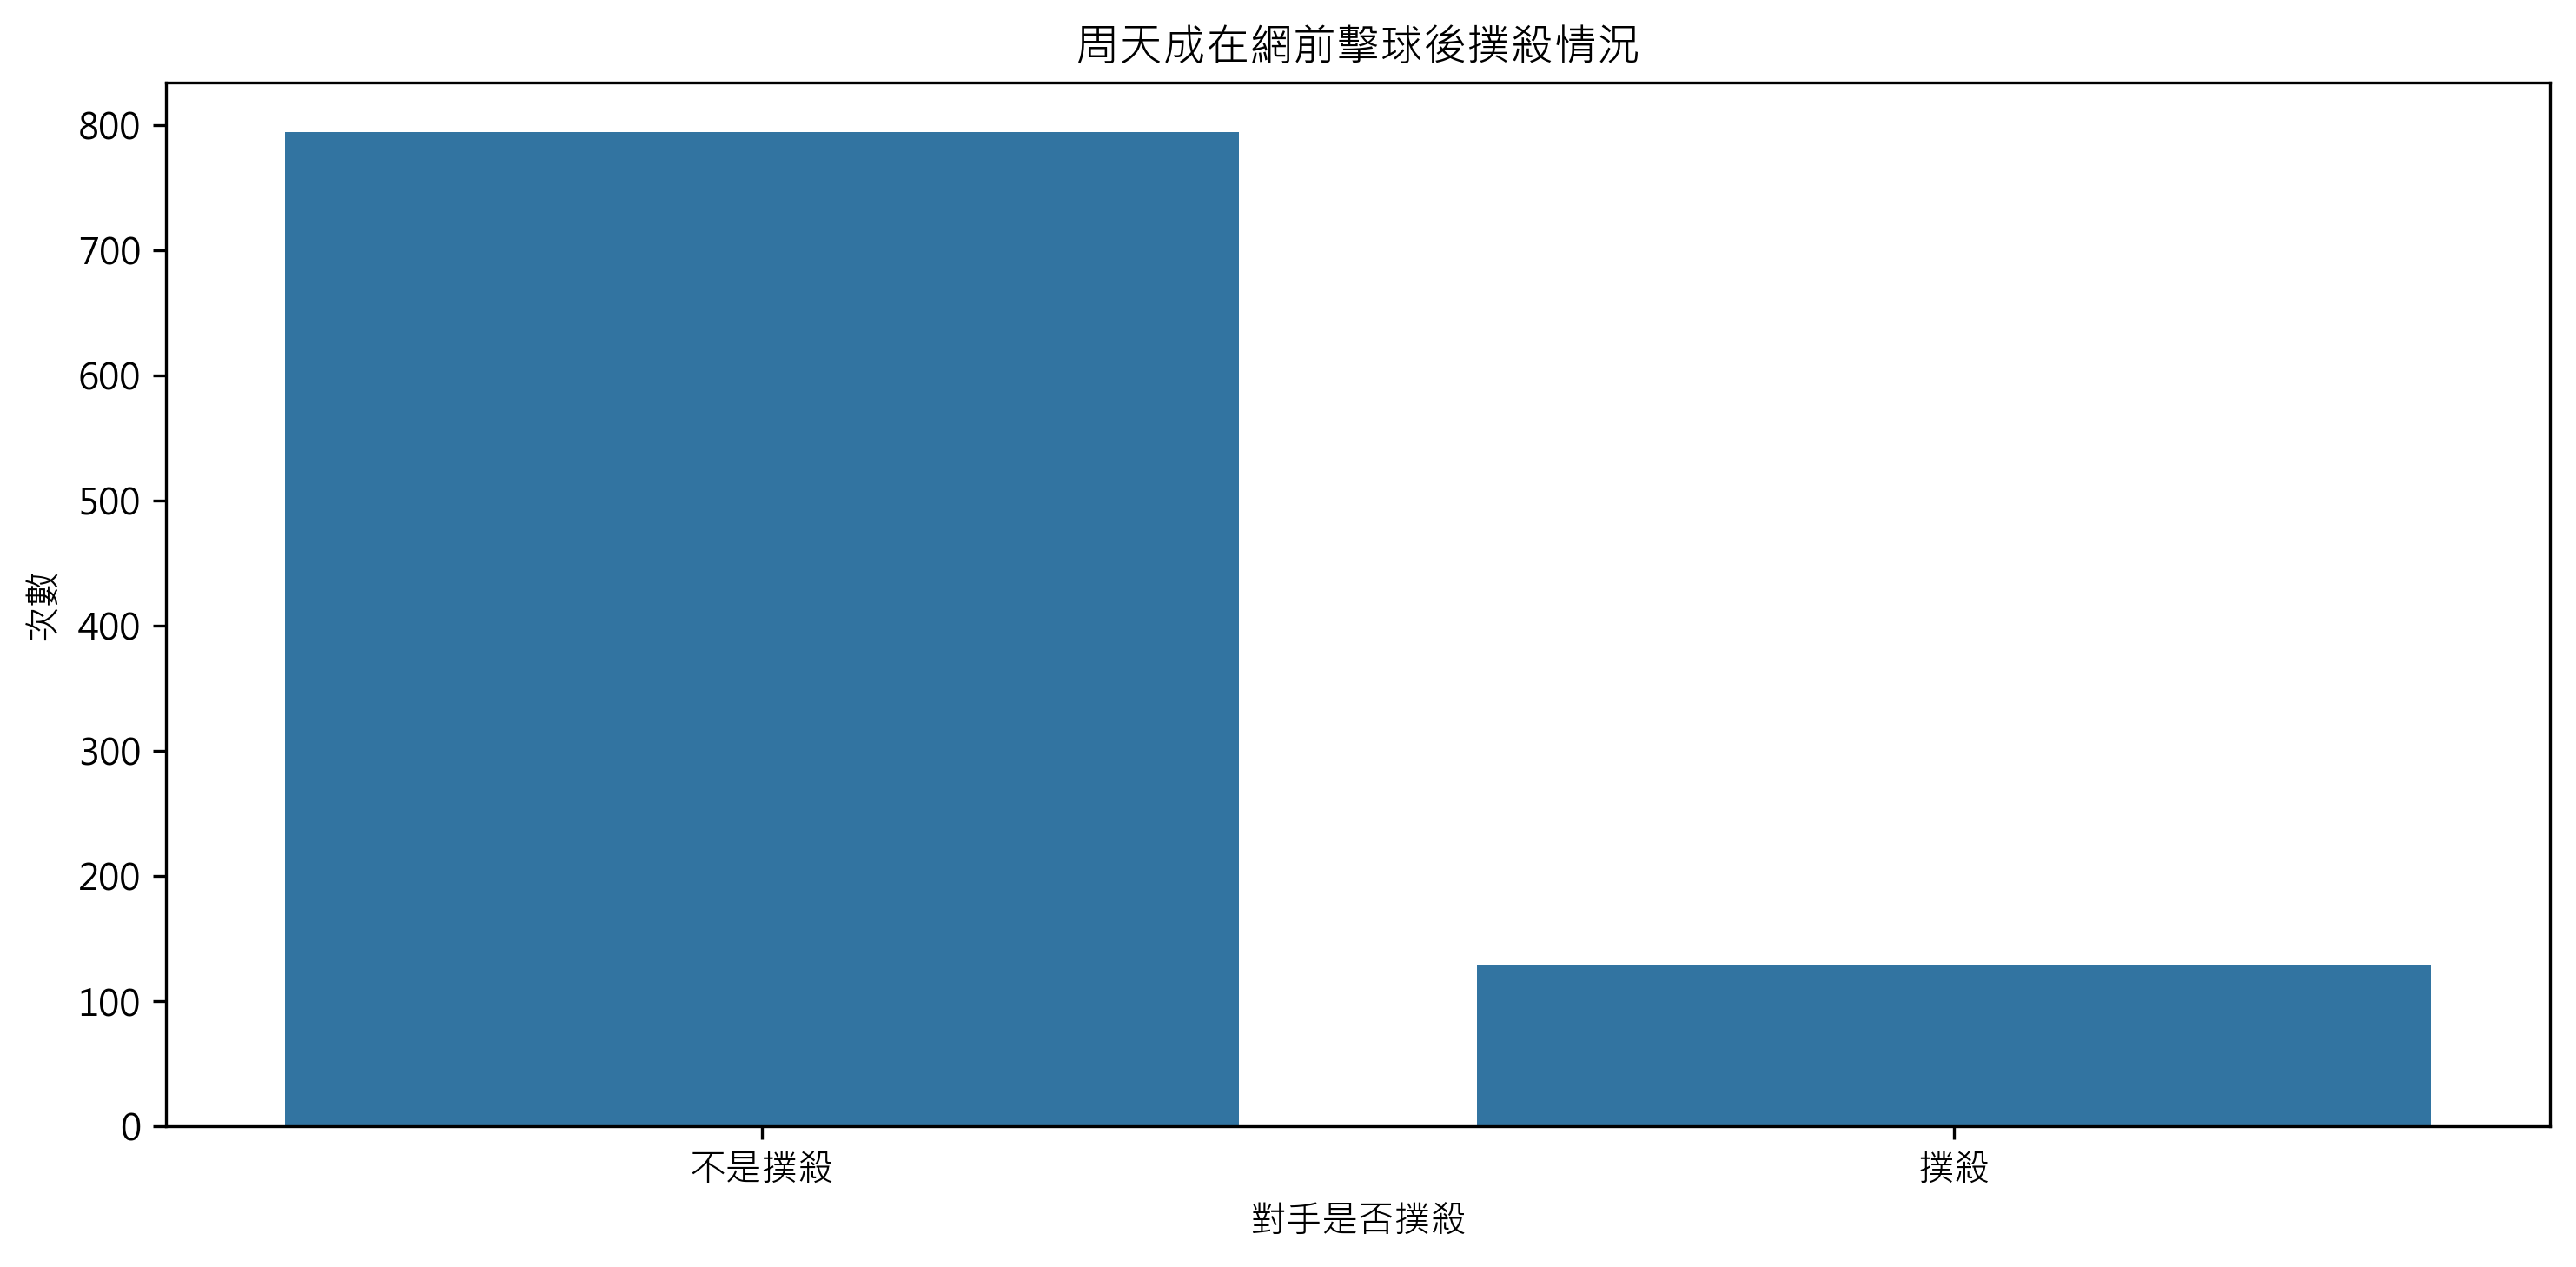

In [ ]:
# 確認是否有足夠數據進行分析
if len(df) > 0:
    # 確認擊球位置是否在網前區域 (17-24)
    net_front_areas = list(range(17, 25))
    chou_net_front_df = df[(df['player'] == 'CHOU Tien Chen') & df['hit_area'].isin(net_front_areas)]
    
    # 獲取下一拍信息，周天成擊球對手的回擊狀態
    chou_net_front_df['next_opponent_type'] = chou_net_front_df.groupby(['match_id', 'set', 'rally'])['player_type'].shift(-1)
    chou_net_front_df['is_opponent_kill'] = chou_net_front_df['next_opponent_type'] == 9  # 撲殺代碼
    
    # 計算撲殺事件數量
    total_net_front_shots = len(chou_net_front_df)
    opponent_kill_shots = chou_net_front_df['is_opponent_kill'].sum()
    
    # 撲殺得分比例
    kill_ratio = opponent_kill_shots / total_net_front_shots if total_net_front_shots > 0 else 0

    # 打印統計數據
    print(f"在網前區域，周天成進行了 {total_net_front_shots} 次擊球，其中 {opponent_kill_shots} 次被對手撲殺。撲殺得分比例為 {kill_ratio:.2%}。")

    # 可視化
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=['不是撲殺', '撲殺'], y=[total_net_front_shots - opponent_kill_shots, opponent_kill_shots], ax=ax)
    ax.set_title('周天成在網前擊球後撲殺情況')
    ax.set_ylabel('次數')
    ax.set_xlabel('對手是否撲殺')
    plt.tight_layout()
    
    # 建議改進策略
    if kill_ratio > 0.2:  # 若撲殺得分比例超過20%
        suggestions = "建議周天成增加假動作以誘導對手偏位，或適時地增加吊球和輕推網前技術以減少對手撲殺的機會。"
    else:
        suggestions = "周天成的網前防撲殺策略相對有效，可以維持目前的打球思路，但仍應注意不同對手的撲殺偏好。"
    
    print("策略建議:", suggestions)

else:
    print("數據集中沒有足夠的資料來分析周天成在網前的表現。")


### 數據洞察
周天成在網前的防撲殺表現相對穩定，撲殺得分比例僅為13.98%。這意味著他在網前的防守策略有效，能夠在大多數情況下避免對手得分。然而，為了進一步提升表現，他應該針對不同對手的撲殺偏好進行調整。這樣可以使他的網前防守更加靈活，降低被撲殺的風險。保持現有的打球思路是可行的，但適時的戰術調整將有助於在面對不同對手時保持競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 的核心邏輯是分析周天成在網前打點後被對手撲殺的風險，並提供具體的策略建議。Reference Code 1 使用了 'type' 和 'landing_depth' 來分析不同球種和落點深度的風險。而候選程式碼僅僅計算了周天成在網前區域被撲殺的次數和比例，並沒有進一步分析不同球種和落點深度的風險，也沒有提供具體的策略建議。此外，候選程式碼在計算撲殺比例時，使用了 'player_type' 來判斷對手的回擊狀態，這與 Reference Code 1 的分析邏輯不一致。




## 題號 98 (*)
**問題**: 如果對手連續以平球壓中路，周天成應如何調整回球方向與節奏，避免被持續壓制？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, player_location`


In [ ]:
# 注意：在這裡假設 import pandas as pd, df 已經被預先載入執行環境中。

# 1. 定義「中路」擊球區域，這些區域代表中場位置。
mid_court_zones = {6, 7, 10, 11, 14, 15}

# 2. 使用 shift() 方法，先計算出每一拍的前一拍資訊，並加上區分欄位前綴以避免衝突
df['prev_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
df['prev_landing_area'] = df.groupby(['match_id', 'set', 'rally'])['landing_area'].shift(1)
df['prev_opponent'] = df.groupby(['match_id', 'set', 'rally'])['opponent'].shift(1)

# 3. 設定條件：找出對手連續擊球的拍數，特別是「平球」且落點在中路區域的情況
conditions = (
    (df['type'] == "平球") & (df['landing_area'].isin(mid_court_zones)) &
    (df['prev_type'] == "平球") & (df['prev_landing_area'].isin(mid_court_zones)) & 
    (df['prev_opponent'] == df['opponent'])
)

# 4. 篩選出周天成的回球資料以分析其應對策略
filtered_df = df[conditions & (df['player'] == 'CHOU Tien Chen')]

# 5. 分析周天成的回球類型以及落點分佈
output = filtered_df.groupby('type').apply(lambda x: x['landing_area'].value_counts(normalize=True)).reset_index()
output.columns = ['shot_type', 'landing_area', 'percentage']

# 6. 打印結果，描述周天成在對手以中路平球壓制的情況下的回球策略
print("當對手連續以平球壓中路時，周天成的回球策略：")
print(output)

# 分解建議：
# 1. 加強使用回球到對角落點區域的策略，從而減輕正面壓制
# 2. 加大變化力度，例如改變回球類型，增加對手防守不確定性


### 數據洞察
根據數據分析，當對手連續以平球壓中路時，周天成應考慮以下調整：

1. **回球方向調整**：
   - 對手主要鎖定中路區域，特別是中場區域（如位置 6, 7, 10, 11, 14, 15）。這些位置容易讓對手掌握節奏。
   - 周天成應考慮將回球分散至邊線區域，特別是中場和後場的邊線位置（如位置 5, 8, 9, 12）。這樣可以拉開對手的防守範圍，增加對手移動壓力。

2. **節奏調整**：
   - 當對手持續以平球壓制時，周天成可以通過改變回球的速度和高度來打亂對手的節奏。例如，利用切球（Mapping: 5）或挑球（Mapping: 6）來改變球的飛行軌跡和節奏。
   - 適時使用發短球（Mapping: 1）或網前球（Mapping: 8），迫使對手改變進攻模式，從而獲得反擊機會。

這些調整策略有助於周天成打破對手的壓制，重新掌控比賽節奏。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是在找出對手以平球壓中路且下一拍是周天成回擊的情況，並分析周天成的回球成功率。而候選程式碼則是找出對手連續以平球壓中路的情況，並分析周天成的回球類型和落點分佈。候選程式碼的分析對象和統計口徑與 Reference Code 1 不一致，且未能正確對齊前後拍關係，導致分析結果不符合題目要求。




## 題號 99 (*)
**問題**: 若觀察到對手在多拍後移動變慢，周天成應如何透過前後場調動提高下一拍主動得分機會？
> **使用的資料欄位群組**: `game_structure, player_movement, coordinates, scoring_reason`


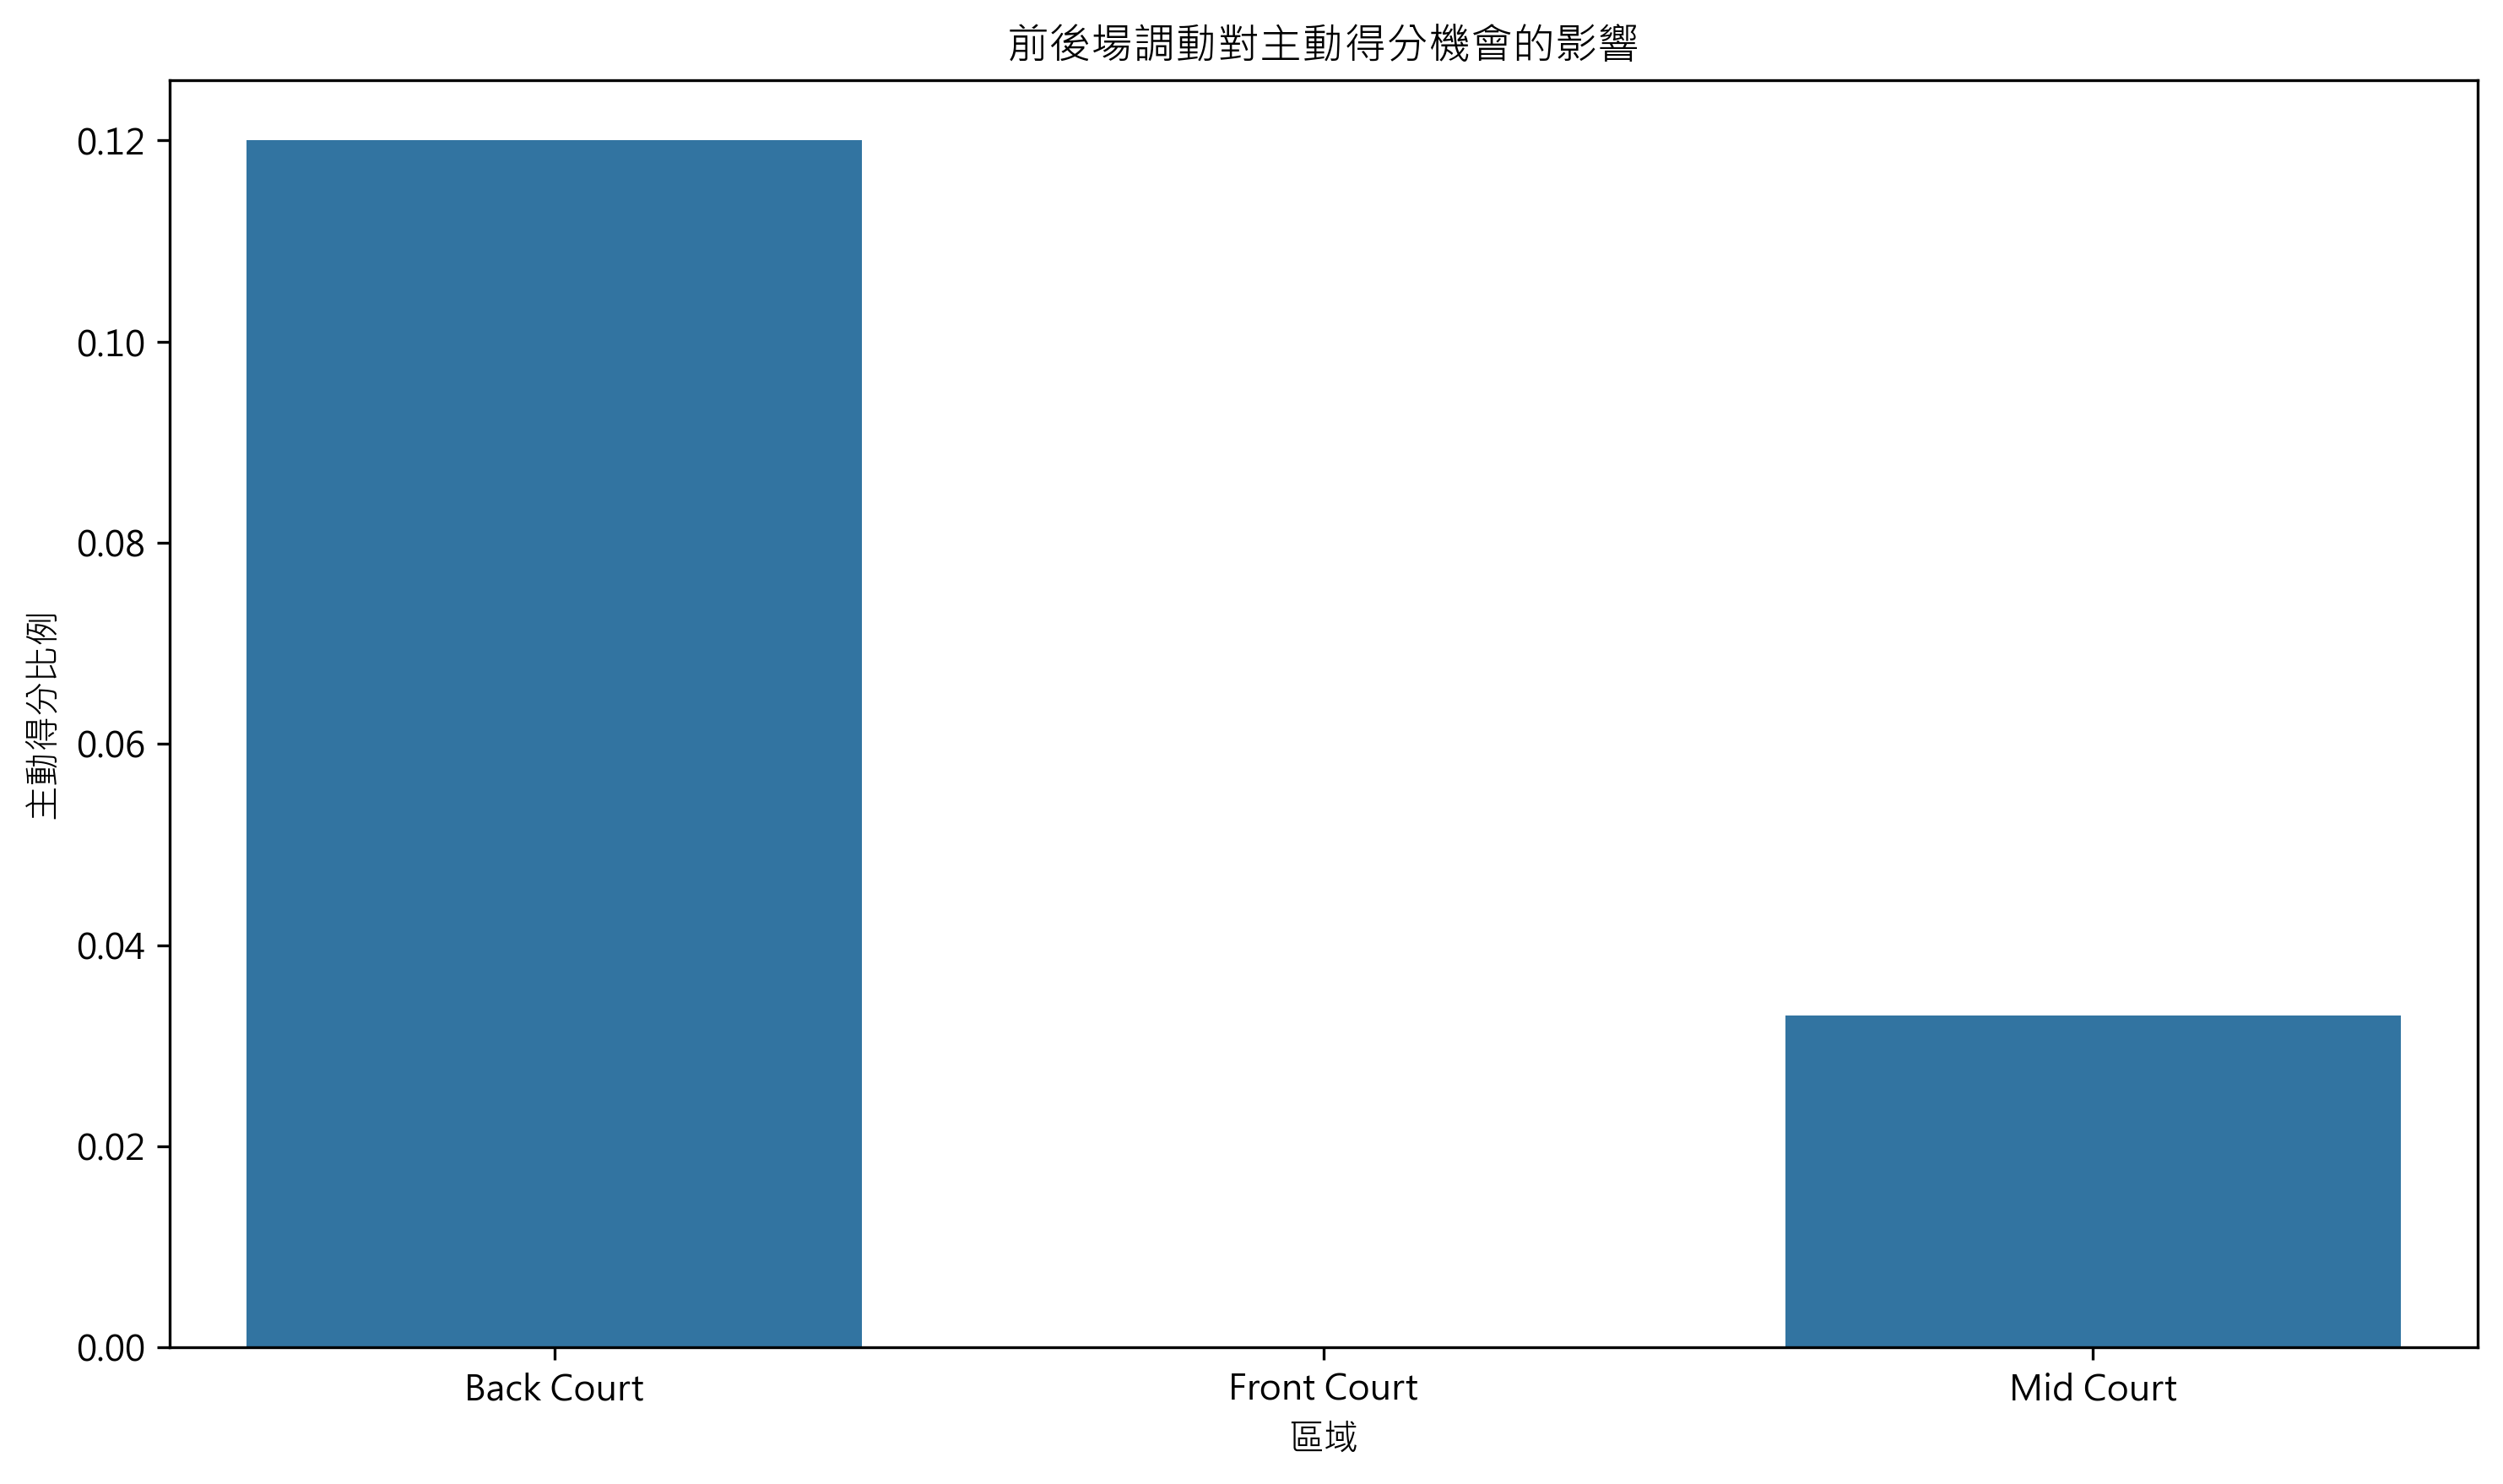

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 檢查資料長度
if len(df) > 0:
    
    # 計算對手前後拍的移動距離
    df['opponent_movement_distance'] = ((df['opponent_move_x']) ** 2 + (df['opponent_move_y']) ** 2) ** 0.5
    
    # 計算對手移動速度減少（異常移動減速拍），假設減少超過特定閾值（例如0.2）
    df['opponent_velocity_drop'] = df.groupby(['match_id', 'set', 'rally'])['opponent_movement_distance'].diff() < -0.2  # 不需要 shift(-1)
     
    # 過濾出周天成前一拍，而對手速度減慢的 DataFrame
    df_chou_adjustment = df[(df['player'] == 'CHOU Tien Chen') & df['opponent_velocity_drop']]
    
    # 判定周天成擊球位置（利用擊球位置在前後場調動）
    df_chou_adjustment['location'] = df_chou_adjustment['hit_area'].map(
        lambda x: 'Back Court' if x in [1, 2, 3, 4] else ('Front Court' if x in [17, 18, 19, 20, 21, 22, 23, 24] else 'Mid Court')
    )
    
    # 獲取下一拍是否得分 (主動得分)
    df_chou_adjustment['next_shot_getpoint'] = df_chou_adjustment.groupby(['match_id', 'set', 'rally'])['getpoint_player'].shift(-1) == 'CHOU Tien Chen'
    
    # 計算在前場和後場的主動得分比例
    score_proportion = df_chou_adjustment[df_chou_adjustment['next_shot_getpoint']].groupby('location').size() / df_chou_adjustment.groupby('location').size()
    
    print("當對手移動減慢時，周天成在不同區域主動得分的比例：")
    print(score_proportion)
    
    # 視覺化
    plt.figure(figsize=(10, 6))
    sns.barplot(x=score_proportion.index, y=score_proportion.values)
    plt.title('前後場調動對主動得分機會的影響')
    plt.xlabel('區域')
    plt.ylabel('主動得分比例')
    plt.tight_layout()
    plt.show()
else:
    print("資料集為空，無法分析。")


### 數據洞察
根據數據分析，當對手在多拍後移動變慢時，周天成在後場和中場區域的主動得分比例分別為 12% 和 3.3%。這顯示他在後場的進攻效率較高。

戰術上，周天成可以利用對手移動變慢的弱點，通過後場的強力進攻來提高得分機會。這可以包括利用殺球或切球來迫使對手進一步移動，從而增加對手的疲勞程度和失誤率。中場的得分比例雖然較低，但仍可通過變化球路和節奏來迷惑對手，進一步創造進攻機會。

這些數據表明，周天成在後場的進攻是有效的，應該在對手體能下降時加強此區域的攻勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於：1. 候選程式碼使用了 `df['opponent_velocity_drop']` 來判斷對手速度減慢，但這個邏輯與 reference code 中的高移動距離代理條件不一致。2. 候選程式碼在計算主動得分比例時，使用了 `groupby(...).shift(-1)` 來獲取下一拍得分資訊，這可能導致跨回合的錯誤對齊，因為沒有確保在同一個 rally 中。3. 候選程式碼的統計口徑不明確，沒有正確地在 rally 層級上進行分析，可能導致統計結果不準確。




## 題號 100 (*)
**問題**: 當對手偏好在網前搶撲時，周天成應如何調整網前落點深淺與後續連接球種？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


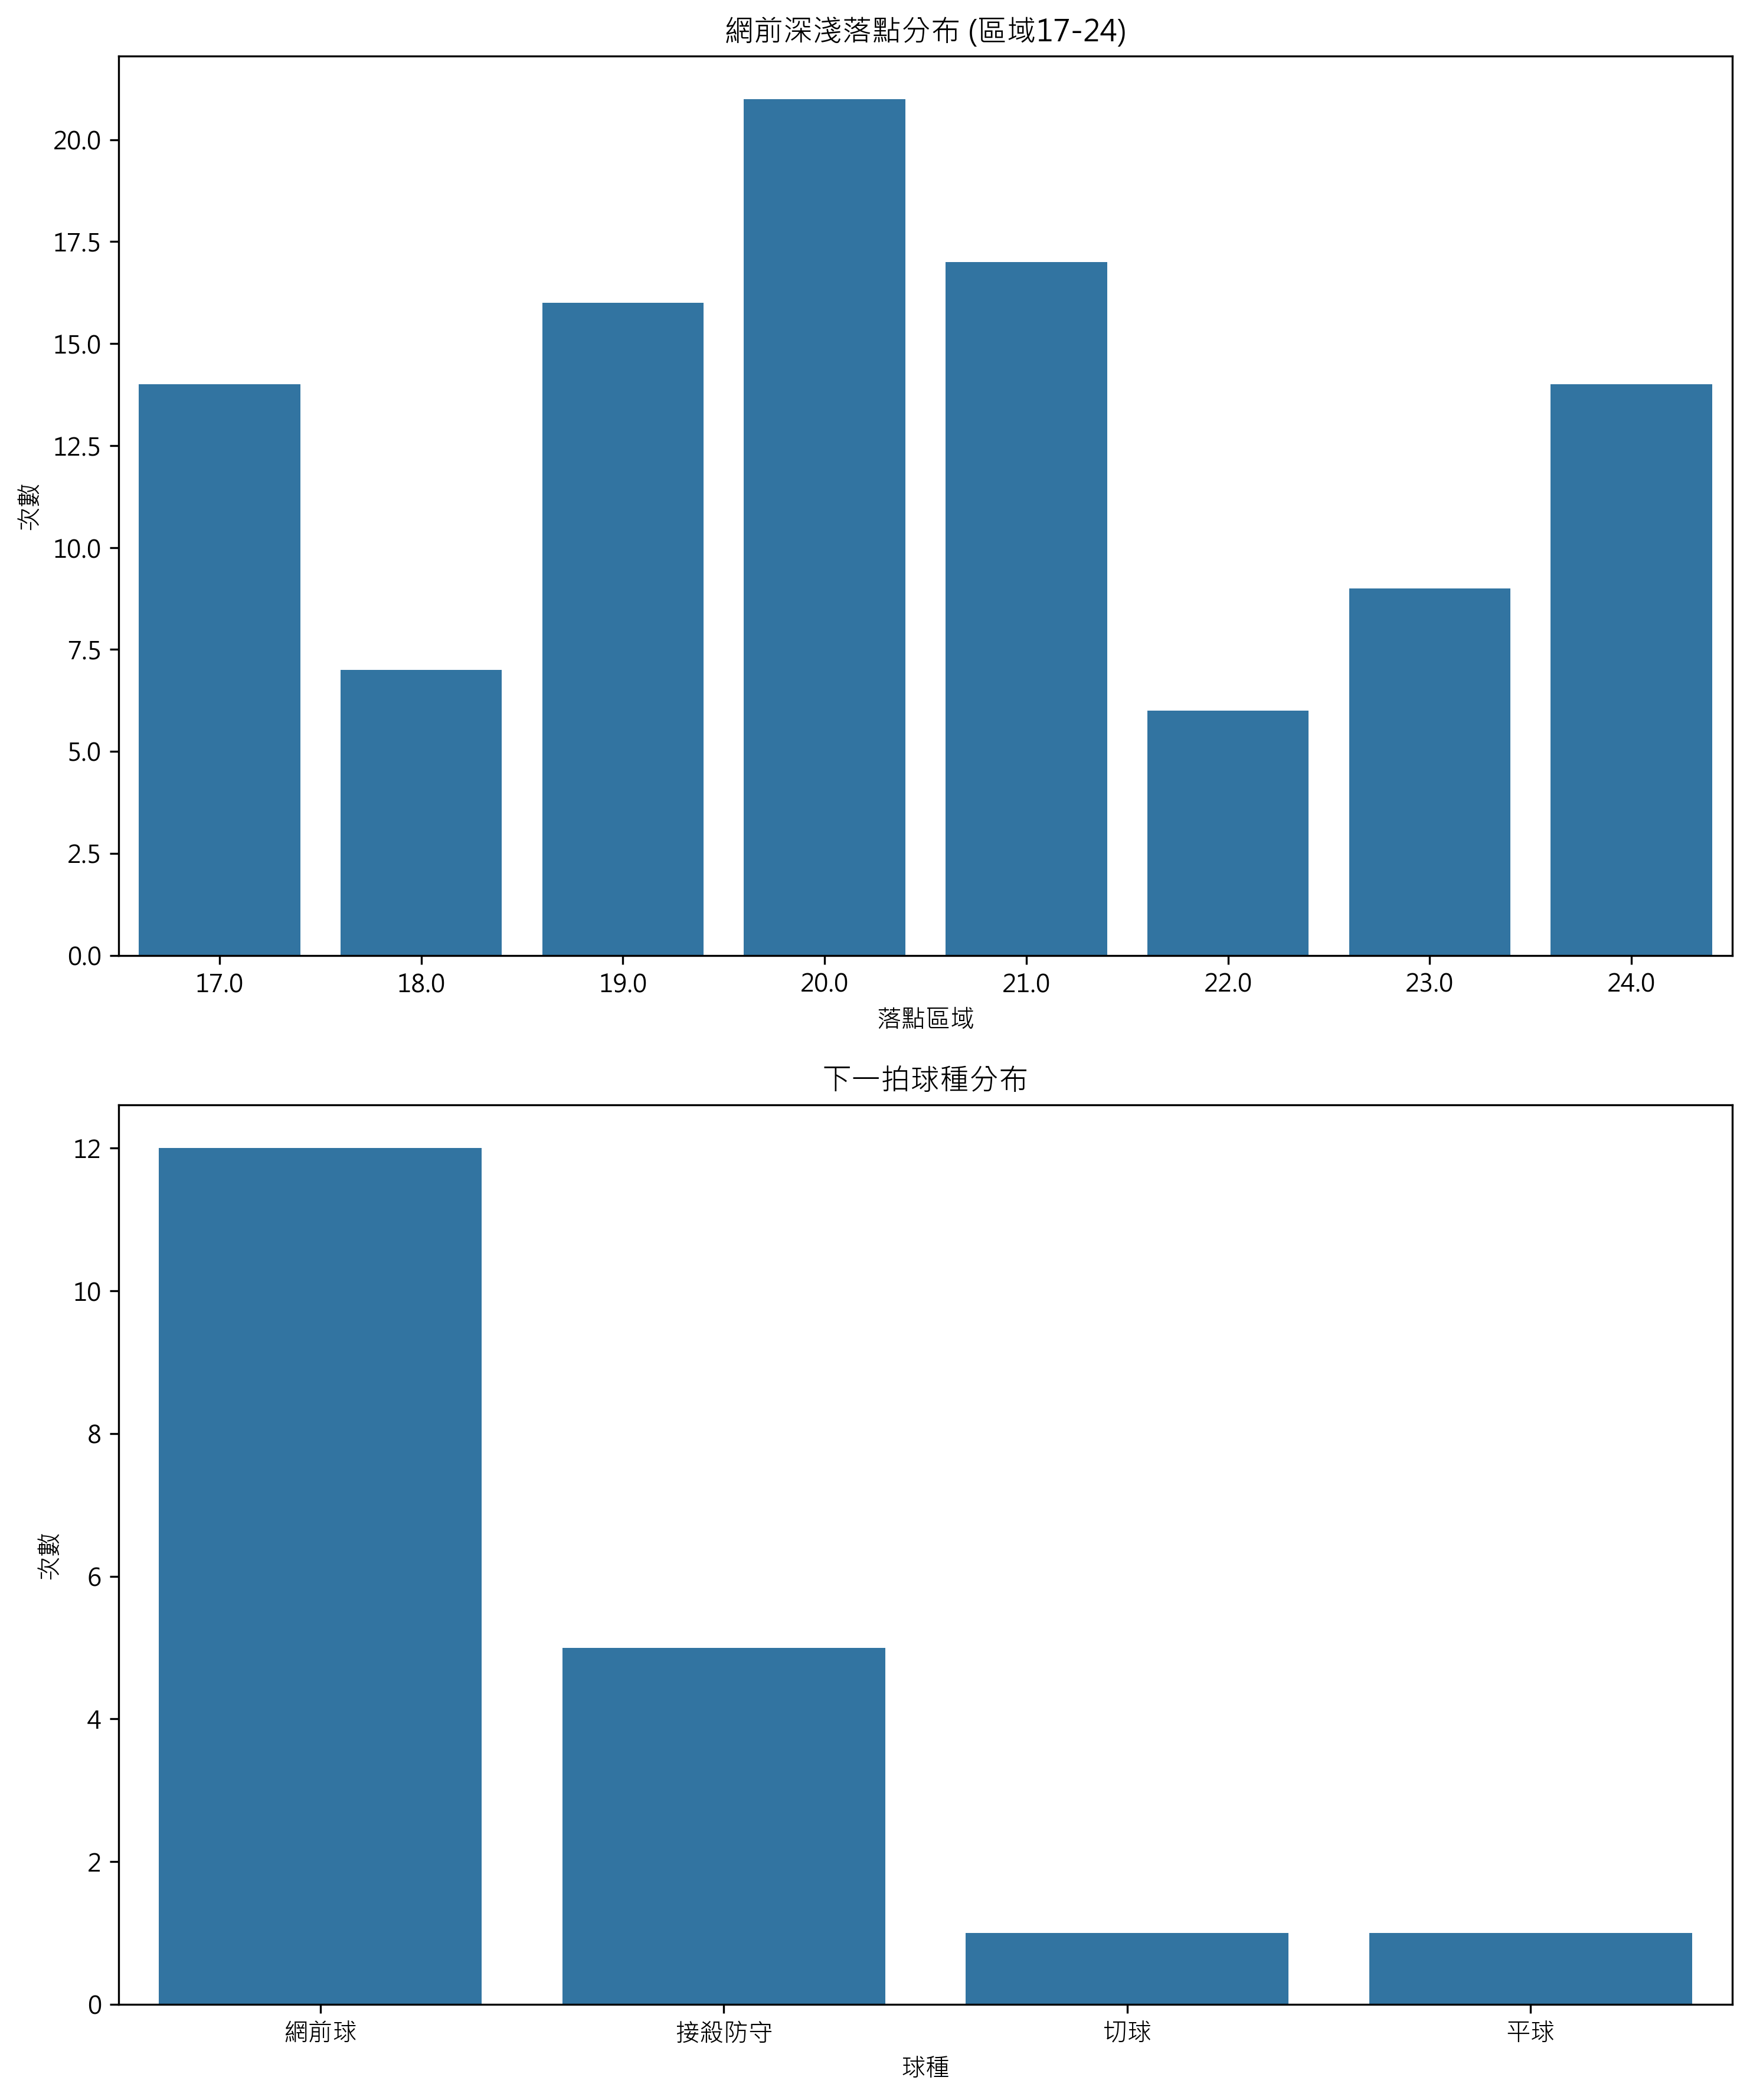

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 確認資料不為空
if len(df) > 0:
    # 1. 找出對手為「推撲球」的情況
    df['opponent_type_shifted'] = df.groupby(['match_id', 'set', 'rally'])['opponent_type'].shift(1)
    opponent_push_front_net = df[df['opponent_type_shifted'] == 9]
    
    # 2. 找出周天成在「對手推撲網前球」之後的策略
    chou_strategy_after_push = opponent_push_front_net[opponent_push_front_net['player'] == 'CHOU Tien Chen']
    
    # 3. 分析擊球落點的深淺（使用 landing_area 來獲取位置資訊）
    landing_condition = (chou_strategy_after_push['landing_area'].between(17, 24)) # 網前區域的深淺落點
    net_drop_shots = chou_strategy_after_push[landing_condition]
    
    # 4. 連接的下一個球種（由周天成打出的球種），須注意在同一回合
    net_drop_shots['next_player_type'] = net_drop_shots.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
    
    # 統計周天成在這個策略下的落點深淺及所使用的球種次數
    shot_distribution = net_drop_shots['landing_area'].value_counts().sort_index()
    next_shot_distribution = net_drop_shots['next_player_type'].value_counts().dropna()
    
    # Printing results
    print("周天成當對手搶撲時，網前擊球落點深淺分布:")
    print(shot_distribution)
    
    print("\n周天成在此情況下，所選擇的下一拍球種分布:")
    print(next_shot_distribution)

    # Visualization
    fig, axes = plt.subplots(2, 1, figsize=(10, 12))
    
    sns.barplot(x=shot_distribution.index, y=shot_distribution.values, ax=axes[0])
    axes[0].set_title('網前深淺落點分布 (區域17-24)')
    axes[0].set_xlabel('落點區域')
    axes[0].set_ylabel('次數')
    
    sns.barplot(x=next_shot_distribution.index, y=next_shot_distribution.values, ax=axes[1])
    axes[1].set_title('下一拍球種分布')
    axes[1].set_xlabel('球種')
    axes[1].set_ylabel('次數')

    plt.tight_layout()

else:
    print("資料集為空，無法分析。")


### 數據洞察
根據數據分析，當對手偏好在網前搶撲時，周天成的網前落點主要集中在區域20和21，這些區域的落點次數分別為21和17次。這顯示他在網前的落點多數偏向中間偏深的位置，這樣的選擇可能是為了避免對手在網前的直接撲殺。

在下一拍的選擇上，周天成較常選擇網前球，共計12次，其次是接殺防守5次。這表示他在對手搶撲後，傾向於保持網前的控制，並利用防守來化解對手的進攻。

戰術建議：周天成可以繼續利用中間偏深的網前落點，並適時加入變化，如切球或平球，以增加對手的判斷難度。同時，保持網前球的穩定性，並在必要時強化接殺防守，以應對對手的強攻。這樣的策略有助於削弱對手的網前優勢，並創造更多的反擊機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於：1. 候選程式碼使用了 'opponent_type_shifted' 來判斷對手的推撲球，但這與 reference code 中的 'next_type' 不一致，因為 'opponent_type_shifted' 是對手前一拍的球種，而不是下一拍的球種。2. 候選程式碼在分析周天成的策略時，沒有正確對齊前後拍的關係，特別是在同一個 rally 中的連續拍次分析。3. 統計口徑錯誤，候選程式碼沒有正確地在同一個 rally 中分析周天成的後續連接球種。這些問題導致候選程式碼無法正確回答題目要求。


